<a href="https://colab.research.google.com/github/Deon-codes/CCL-Lab5-Assignment2-DynamoDB/blob/main/real_building_globalbuildingatlas_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-building test: GlobalBuildingAtlas → our 3D ULPIN pipeline

## Purpose

The previous notebook used **synthetic parcel/building polygons** to verify that our geometry and identity pipeline works.

This notebook goes one step further:

**real GlobalBuildingAtlas building data → real footprint/height evidence → our 3D building envelope → map + 3D model.**

We are NOT training a model here.

We are NOT pretending GlobalBuildingAtlas is Indian cadastral/ULPIN data.

We are using its building geometry as a **global physical-building evidence source** and then connecting that geometry to our own project-level property model.

GlobalBuildingAtlas provides global building polygons, heights and LoD1 building models. Its documentation explicitly warns that some areas can be missing or lack height attributes, and that the product is ML-derived and can contain errors.


In [5]:
!pip -q install geopandas shapely pyproj requests huggingface_hub trimesh mapbox_earcut pydeck plotly
!pip -q install pyogrio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.8 MB/s eta 0:00:00


In [6]:
import os
import json
import math
from pathlib import Path

import geopandas as gpd
from shapely.geometry import box, shape, Polygon, mapping
from shapely.ops import transform
from pyproj import Transformer
from huggingface_hub import HfApi, hf_hub_download, snapshot_download

print("Libraries ready.")


Libraries ready.


## 1. Choose a real test location

We'll start with Mumbai because it is a convenient India test area.

The coordinates below are only the **region of interest**, not a claim that they identify a specific property.

Once this works, change them to a building you have permission to use.


In [7]:
# Mumbai test region
CENTER_LAT = 19.0760
CENTER_LON = 72.8777

# Small bounding box around the test point.
DELTA_LAT = 0.01
DELTA_LON = 0.01

ROI = box(
    CENTER_LON - DELTA_LON,
    CENTER_LAT - DELTA_LAT,
    CENTER_LON + DELTA_LON,
    CENTER_LAT + DELTA_LAT
)

print("ROI:", ROI.bounds)


ROI: (72.8677, 19.066, 72.88770000000001, 19.086000000000002)


## 2. Download the small GlobalBuildingAtlas tile index

The representative `lod1.geojson` is only an index telling us which geographic tiles exist.

We use the index first instead of downloading the ~1 TB repository.

Mumbai lies around longitude 72.88E and latitude 19.08N, so the geographic tile is expected to be the 5° × 5° tile covering 70–75E and 15–20N.

The code below does not hard-code the file path; it reads the published tile index and finds the intersecting tile.


In [8]:
REPO = "zhu-xlab/GBA.LoD1"

index_path = hf_hub_download(
    repo_id=REPO,
    filename="representative/lod1.geojson",
    repo_type="dataset"
)

tile_index = gpd.read_file(index_path)

print("Index columns:")
print(tile_index.columns.tolist())
print()
print(tile_index.head())


lod1.geojson:   0%|          | 0.00/205k [00:00<?, ?B/s]

Index columns:
['tile', 'geometry']

                       tile                                           geometry
0  europe/w045_n65_w040_n60  POLYGON ((-40 60, -40 65, -45 65, -45 60, -40 ...
1  europe/e035_n45_e040_n40      POLYGON ((40 40, 40 45, 35 45, 35 40, 40 40))
2  europe/e045_n55_e050_n50      POLYGON ((50 50, 50 55, 45 55, 45 50, 50 50))
3  europe/e010_n50_e015_n45      POLYGON ((15 45, 15 50, 10 50, 10 45, 15 45))
4  europe/e030_n45_e035_n40      POLYGON ((35 40, 35 45, 30 45, 30 40, 35 40))


In [9]:
# Make sure the index uses WGS84 for the spatial lookup.
if tile_index.crs is None:
    tile_index = tile_index.set_crs("EPSG:4326")

tile_index = tile_index.to_crs("EPSG:4326")

hits = tile_index[tile_index.geometry.intersects(ROI)]

print("Tiles intersecting Mumbai ROI:")
display(hits)


Tiles intersecting Mumbai ROI:


,tile,geometry
375,asiawest/e070_n20_e075_n15,"POLYGON ((75 15, 75 20, 70 20, 70 15, 75 15))"


## 3. Find the actual repository file for the selected tile

GlobalBuildingAtlas is large, so we only download files that match the selected geographic tile.

The code searches the repository tree and prints the candidate files it finds.

Do NOT download the whole dataset.


In [10]:
# Try to infer a tile/name field from the representative index.
candidate_columns = [
    c for c in tile_index.columns
    if any(k in c.lower() for k in ["tile", "path", "file", "name", "id"])
]
print("Possible tile/path columns:", candidate_columns)

for c in candidate_columns:
    print("\nCOLUMN:", c)
    print(hits[c].head(10).tolist())


Possible tile/path columns: ['tile']

COLUMN: tile
['asiawest/e070_n20_e075_n15']


### Important

If the previous cell shows a tile/path value, copy the displayed tile name into `TILE_QUERY`.

The repository is split into directories and the exact data-file layout can evolve, so we intentionally inspect rather than assume a path.


In [11]:
# ---- SET THIS FROM THE DISPLAY ABOVE IF NECESSARY ----
# Example expected style: e070_n20_e075_n15
TILE_QUERY = "asiawest/e070_n20_e075_n15"

if not TILE_QUERY:
    raise ValueError(
        "Set TILE_QUERY from the tile/path printed above, then rerun this cell."
    )


## 4. Download only the matching tile files

The repository contains separate polygon/LoD1 material. This step looks for files whose paths contain the selected tile name and avoids downloading unrelated regions.


In [12]:
api = HfApi()

# List file metadata only, then filter locally.
repo_files = api.list_repo_files(
    repo_id=REPO,
    repo_type="dataset"
)

matches = [
    f for f in repo_files
    if TILE_QUERY.lower() in f.lower()
    and (
        f.lower().endswith(".json")
        or f.lower().endswith(".geojson")
        or f.lower().endswith(".zip")
        or f.lower().endswith(".tif")
        or f.lower().endswith(".tiff")
    )
]

print("Matching files:")
for f in matches[:50]:
    print(f)

print("\nTotal matches:", len(matches))


Matching files:
LoD1/asiawest/e070_n20_e075_n15.json
Polygon/asiawest/e070_n20_e075_n15.geojson

Total matches: 2


## 5. Download the smallest useful building file

Prefer a `.geojson` building file if one is available.

If only a LoD1 JSON / ZIP is present, inspect it before writing a parser. Do not silently assume its schema.


In [13]:
geo_matches = [
    f for f in matches
    if f.lower().endswith(".geojson")
]

if geo_matches:
    chosen_file = geo_matches[0]
    print("Chosen GeoJSON:", chosen_file)

    local_file = hf_hub_download(
        repo_id=REPO,
        filename=chosen_file,
        repo_type="dataset"
    )

    print("Downloaded:", local_file)
else:
    print("No GeoJSON tile found.")
    print("Inspect the matching JSON/ZIP names above before continuing.")


Chosen GeoJSON: Polygon/asiawest/e070_n20_e075_n15.geojson


Polygon/asiawest/e070_n20_e075_n15.geojs(…): reconstructing file:   0%|          |  0.00B / 7.03GB            

Polygon/asiawest/e070_n20_e075_n15.geojs(…): downloading bytes:           |  0.00B            

Downloaded: /root/.cache/huggingface/hub/datasets--zhu-xlab--GBA.LoD1/snapshots/9da24b3a8dce436a7420d5c3589de718d7ba14d6/Polygon/asiawest/e070_n20_e075_n15.geojson


## 6. Load REAL building polygons

This is the first point at which the geometry is no longer our synthetic rectangle.

We clip to the Mumbai ROI and show how many real building features are available.


In [14]:
from huggingface_hub import hf_hub_download

REPO = "zhu-xlab/GBA.LoD1"

POLYGON_FILE = "Polygon/asiawest/e070_n20_e075_n15.geojson"

polygon_path = hf_hub_download(
    repo_id=REPO,
    filename=POLYGON_FILE,
    repo_type="dataset"
)

print("Downloaded:")
print(polygon_path)

Downloaded:
/root/.cache/huggingface/hub/datasets--zhu-xlab--GBA.LoD1/snapshots/9da24b3a8dce436a7420d5c3589de718d7ba14d6/Polygon/asiawest/e070_n20_e075_n15.geojson


In [15]:
import geopandas as gpd

# Our ROI was created in WGS84 / EPSG:4326.
roi_gdf = gpd.GeoDataFrame(
    {"id": [1]},
    geometry=[ROI],
    crs="EPSG:4326"
)

# Convert ROI to the SAME CRS as GlobalBuildingAtlas.
roi_3857 = roi_gdf.to_crs("EPSG:3857").geometry.iloc[0]

# Read only buildings intersecting the converted ROI.
roi_buildings = gpd.read_file(
    polygon_path,
    bbox=roi_3857,
    engine="pyogrio"
)

print("Buildings in ROI:", len(roi_buildings))
print("Original CRS:", roi_buildings.crs)
print("Columns:")
print(roi_buildings.columns.tolist())

display(roi_buildings.head())

Buildings in ROI: 8284
Original CRS: EPSG:3857
Columns:
['source', 'id', 'region', 'geometry']


,source,id,region,geometry
0,google,7JFJ3V9P+8XV9,IND,"POLYGON ((8113795.017 2162985.964, 8113791.509..."
1,google,7JFJ3V9J+RVMX,IND,"POLYGON ((8113212.687 2163133.428, 8113205.695..."
2,google,7JFJ3VGM+7XV8,IND,"POLYGON ((8113517.752 2163853.747, 8113510.492..."
3,google,7JFJ3VFM+VQFM,IND,"POLYGON ((8113463.461 2163727.309, 8113452.154..."
4,google,7JFJ3VFM+MXJ2,IND,"POLYGON ((8113509.167 2163671.313, 8113510.124..."


In [16]:
# Convert the selected buildings back to WGS84 for map/display work.
roi_buildings_wgs84 = roi_buildings.to_crs("EPSG:4326")

print("Buildings after loading:", len(roi_buildings_wgs84))
display(roi_buildings_wgs84.head())

Buildings after loading: 8284


,source,id,region,geometry
0,google,7JFJ3V9P+8XV9,IND,"POLYGON ((72.88746 19.06836, 72.88743 19.06839..."
1,google,7JFJ3V9J+RVMX,IND,"POLYGON ((72.88223 19.06961, 72.88217 19.06964..."
2,google,7JFJ3VGM+7XV8,IND,"POLYGON ((72.88497 19.07573, 72.8849 19.07577,..."
3,google,7JFJ3VFM+VQFM,IND,"POLYGON ((72.88448 19.07466, 72.88438 19.07476..."
4,google,7JFJ3VFM+MXJ2,IND,"POLYGON ((72.88489 19.07418, 72.8849 19.07421,..."


In [17]:
!pip -q install overturemaps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.1 MB/s eta 0:00:00


In [18]:
!pip -q install -U duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 70.0 MB/s eta 0:00:00


In [19]:
# CELL 7
# Install DuckDB and its HTTP/S3 extension properly

!pip -q install -U duckdb

import duckdb

print("DuckDB version:")
print(duckdb.__version__)

con = duckdb.connect()

# Install extensions first, then load them.
con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute("SET s3_region='us-west-2';")

print("\nDuckDB + spatial + httpfs loaded successfully.")

DuckDB version:
1.5.5


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


DuckDB + spatial + httpfs loaded successfully.


In [20]:
# CELL 8
# Lightweight check: do Overture buildings in our Mumbai ROI
# actually contain height and floor-count information?

minx, miny, maxx, maxy = ROI.bounds

query = f"""
SELECT
    COUNT(*) AS total_buildings,

    COUNT(height) AS buildings_with_height,

    COUNT(num_floors) AS buildings_with_num_floors,

    MIN(height) AS min_height,

    MAX(height) AS max_height,

    MIN(num_floors) AS min_num_floors,

    MAX(num_floors) AS max_num_floors

FROM read_parquet(
    's3://overturemaps-us-west-2/release/2026-08-19.0/theme=buildings/type=building/*',
    filename=true,
    hive_partitioning=1
)

WHERE
    bbox.xmin <= {maxx}
    AND bbox.xmax >= {minx}
    AND bbox.ymin <= {maxy}
    AND bbox.ymax >= {miny}
"""

print("Checking Overture for Mumbai ROI...")
print(f"BBox: {minx}, {miny}, {maxx}, {maxy}")

check = con.execute(query).fetchdf()

display(check)

Checking Overture for Mumbai ROI...
BBox: 72.8677, 19.066, 72.88770000000001, 19.086000000000002


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_buildings,buildings_with_height,buildings_with_num_floors,min_height,max_height,min_num_floors,max_num_floors
0,5527,5,50,1.0,4.0,1,13


In [21]:
# CELL 9
# Download the exact Mumbai LoD1 tile from Hugging Face.

from huggingface_hub import hf_hub_download
import json
from pathlib import Path

REPO = "zhu-xlab/GBA.LoD1"

LOD1_FILE = "LoD1/asiawest/e070_n20_e075_n15.json"

print("Downloading:")
print(LOD1_FILE)

lod1_path = hf_hub_download(
    repo_id=REPO,
    filename=LOD1_FILE,
    repo_type="dataset"
)

print("\nDownloaded successfully:")
print(lod1_path)

print("\nFile size:")
print(round(Path(lod1_path).stat().st_size / (1024 * 1024), 2), "MB")

Downloading:
LoD1/asiawest/e070_n20_e075_n15.json


LoD1/asiawest/e070_n20_e075_n15.json: reconstructing file:   0%|          |  0.00B / 1.40GB            

LoD1/asiawest/e070_n20_e075_n15.json: downloading bytes:           |  0.00B            


Downloaded successfully:
/root/.cache/huggingface/hub/datasets--zhu-xlab--GBA.LoD1/snapshots/9da24b3a8dce436a7420d5c3589de718d7ba14d6/LoD1/asiawest/e070_n20_e075_n15.json

File size:
1331.43 MB


In [22]:
# CELL 10
# Safely inspect the beginning of the 1.33 GB LoD1 JSON.
# DO NOT load the whole file into memory.

from pathlib import Path

FILE_PATH = Path(lod1_path)

print("File exists:", FILE_PATH.exists())
print("File size:", round(FILE_PATH.stat().st_size / (1024**3), 2), "GB")

with open(FILE_PATH, "rb") as f:
    first_bytes = f.read(5000)

print("\nFirst 5000 bytes:\n")
print(first_bytes.decode("utf-8", errors="replace"))

File exists: True
File size: 1.3 GB

First 5000 bytes:

{"osm755199584IND": {"height": 8.8114595413208, "var": 1.7855720520019531}, "osm819895507IND": {"height": 6.9296979904174805, "var": 2.0246124267578125}, "google7JCJHW5W+4G9HIND": {"height": 6.581506729125977, "var": 1.1976652145385742}, "google7JCJHWJ9+75CPIND": {"height": 1.6489012241363525, "var": 0.4213789701461792}, "google7JCJHW5Q+39WWIND": {"height": 7.62141227722168, "var": 0.5987052917480469}, "google7JCJGX7W+5FF3IND": {"height": 2.1980743408203125, "var": 0.07782125473022461}, "google7JCJGX6V+7HVXIND": {"height": 2.230316638946533, "var": 0.35913753509521484}, "google7JCJHX7M+425WIND": {"height": 1.809312105178833, "var": 0.08261823654174805}, "google7JCJHWR7+2RGXIND": {"height": 9.074758529663086, "var": 1.7238311767578125}, "google7JCJHWH8+9FF3IND": {"height": 0.6889647841453552, "var": 0.1309550702571869}, "google7JCJHX4X+W52RIND": {"height": 4.03767728805542, "var": 0.13149595260620117}, "google7JCJGX7W+8G47IND": {"h

In [23]:
!pip -q install ijson
import ijson

print("Reading first 5 building records...\n")

with open(lod1_path, "rb") as f:

    for i, (building_id, data) in enumerate(ijson.kvitems(f, "")):

        print("--------------------------------")
        print("Building ID:", building_id)
        print("Fields:", list(data.keys()))

        for key, value in data.items():
            print(f"{key}: {value}    (type: {type(value).__name__})")

        if i >= 4:
            break

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.9/149.9 kB 11.4 MB/s eta 0:00:00
Reading first 5 building records...

--------------------------------
Building ID: osm755199584IND
Fields: ['height', 'var']
height: 8.8114595413208    (type: Decimal)
var: 1.7855720520019531    (type: Decimal)
--------------------------------
Building ID: osm819895507IND
Fields: ['height', 'var']
height: 6.9296979904174805    (type: Decimal)
var: 2.0246124267578125    (type: Decimal)
--------------------------------
Building ID: google7JCJHW5W+4G9HIND
Fields: ['height', 'var']
height: 6.581506729125977    (type: Decimal)
var: 1.1976652145385742    (type: Decimal)
--------------------------------
Building ID: google7JCJHWJ9+75CPIND
Fields: ['height', 'var']
height: 1.6489012241363525    (type: Decimal)
var: 0.4213789701461792    (type: Decimal)
--------------------------------
Building ID: google7JCJHW5Q+39WWIND
Fields: ['height', 'var']
height: 7.62141227722168    (type: Decimal)
var: 0.5987052917480469  

In [24]:
# CELL 12
# Verify that the polygon ID can be mapped to the LoD1 key.

# Take the first real Mumbai building we downloaded.
row = roi_buildings.iloc[0]

source = str(row["source"])
building_id = str(row["id"])
region = str(row["region"])

candidate_lod1_id = f"{source}{building_id}{region}"

print("Polygon source :", source)
print("Polygon ID     :", building_id)
print("Polygon region :", region)

print("\nConstructed LoD1 key:")
print(candidate_lod1_id)

print("\nChecking whether this exact key exists in the 1.3 GB LoD1 file...")

import subprocess

result = subprocess.run(
    [
        "grep",
        "-F",
        "-m", "1",
        f'"{candidate_lod1_id}"',
        lod1_path
    ],
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print("\n✅ MATCH FOUND")
    print(result.stdout[:500])
else:
    print("\n❌ NO MATCH FOUND")
    print("grep return code:", result.returncode)

Polygon source : google
Polygon ID     : 7JFJ3V9P+8XV9
Polygon region : IND

Constructed LoD1 key:
google7JFJ3V9P+8XV9IND

Checking whether this exact key exists in the 1.3 GB LoD1 file...

✅ MATCH FOUND
{"osm755199584IND": {"height": 8.8114595413208, "var": 1.7855720520019531}, "osm819895507IND": {"height": 6.9296979904174805, "var": 2.0246124267578125}, "google7JCJHW5W+4G9HIND": {"height": 6.581506729125977, "var": 1.1976652145385742}, "google7JCJHWJ9+75CPIND": {"height": 1.6489012241363525, "var": 0.4213789701461792}, "google7JCJHW5Q+39WWIND": {"height": 7.62141227722168, "var": 0.5987052917480469}, "google7JCJGX7W+5FF3IND": {"height": 2.1980743408203125, "var": 0.07782125473022461}, "google7


In [25]:
# CELL 13
# Stream the 1.3 GB LoD1 JSON until we find our exact building.
# Nothing else from the huge file is loaded into memory.

import ijson

target_id = candidate_lod1_id

print("Looking for:")
print(target_id)
print("\nStreaming LoD1 data...")

found = None

with open(lod1_path, "rb") as f:
    for building_id, data in ijson.kvitems(f, ""):

        if building_id == target_id:
            found = data
            break

if found is None:
    print("\n❌ Exact LoD1 record was not found.")
else:
    print("\n✅ EXACT RECORD FOUND")
    print("Building ID:", target_id)
    print("Height:", found.get("height"))
    print("Variance:", found.get("var"))

Looking for:
google7JFJ3V9P+8XV9IND

Streaming LoD1 data...

✅ EXACT RECORD FOUND
Building ID: google7JFJ3V9P+8XV9IND
Height: 3.221924066543579
Variance: 1.287653923034668


In [26]:
# CELL 14
# REAL GBA building footprint + REAL GBA height -> 3D building

import trimesh
import plotly.graph_objects as go
from shapely.ops import transform
from pyproj import Transformer

# ---------------------------------------------------------
# 1. Use the SAME real polygon row we selected earlier
# ---------------------------------------------------------

target_row = row

polygon_id = str(target_row["id"])
polygon_source = str(target_row["source"])
polygon_region = str(target_row["region"])

real_footprint_3857 = target_row.geometry

print("Building ID :", polygon_id)
print("Source      :", polygon_source)
print("Region      :", polygon_region)
print("Geometry    :", real_footprint_3857.geom_type)

# ---------------------------------------------------------
# 2. Convert GBA footprint from EPSG:3857 to metres
# ---------------------------------------------------------

to_utm = Transformer.from_crs(
    "EPSG:3857",
    "EPSG:32643",
    always_xy=True
).transform

real_footprint_utm = transform(
    to_utm,
    real_footprint_3857
)

print("\nReal footprint area:",
      round(real_footprint_utm.area, 2), "m²")

print("Real footprint bounds:")
print(real_footprint_utm.bounds)

# ---------------------------------------------------------
# 3. Use the EXACT LoD1 height we extracted
# ---------------------------------------------------------

REAL_HEIGHT_M = float(found["height"])
GBA_VARIANCE = float(found["var"])

print("\nREAL GBA height :", REAL_HEIGHT_M, "m")
print("GBA variance    :", GBA_VARIANCE)

# ---------------------------------------------------------
# 4. Create 3D geometry from the REAL footprint
# ---------------------------------------------------------

if real_footprint_utm.geom_type == "Polygon":

    real_building_mesh = trimesh.creation.extrude_polygon(
        real_footprint_utm,
        height=REAL_HEIGHT_M
    )

elif real_footprint_utm.geom_type == "MultiPolygon":

    meshes = []

    for poly in real_footprint_utm.geoms:
        if not poly.is_empty and poly.area > 0:
            meshes.append(
                trimesh.creation.extrude_polygon(
                    poly,
                    height=REAL_HEIGHT_M
                )
            )

    real_building_mesh = trimesh.util.concatenate(meshes)

else:
    raise ValueError(
        f"Unsupported geometry type: {real_footprint_utm.geom_type}"
    )

print("\n✅ REAL 3D BUILDING CREATED")
print("Vertices:", len(real_building_mesh.vertices))
print("Faces   :", len(real_building_mesh.faces))
print("Volume  :", round(real_building_mesh.volume, 2), "m³")

# ---------------------------------------------------------
# 5. Display the actual 3D geometry
# ---------------------------------------------------------

v = real_building_mesh.vertices
f = real_building_mesh.faces

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=v[:, 0],
        y=v[:, 1],
        z=v[:, 2],
        i=f[:, 0],
        j=f[:, 1],
        k=f[:, 2],
        opacity=0.75,
        hovertemplate=(
            f"Building: {polygon_id}<br>"
            f"Height: {REAL_HEIGHT_M:.2f} m<br>"
            f"Source: GlobalBuildingAtlas"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title=f"REAL GBA Building → 3D | {polygon_id}",
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Elevation (m)",
        aspectmode="data"
    )
)

fig.show()

# ---------------------------------------------------------
# 6. Save the real generated 3D building
# ---------------------------------------------------------

output_file = "real_gba_building.glb"

real_building_mesh.export(output_file)

print("\n✅ Saved:", output_file)

Building ID : 7JFJ3V9P+8XV9
Source      : google
Region      : IND
Geometry    : Polygon

Real footprint area: 17.52 m²
Real footprint bounds:
(277700.6630647355, 2109727.520877831, 277706.54172503896, 2109733.424634214)

REAL GBA height : 3.221924066543579 m
GBA variance    : 1.287653923034668

✅ REAL 3D BUILDING CREATED
Vertices: 8
Faces   : 12
Volume  : 56.46 m³



✅ Saved: real_gba_building.glb


In [27]:
# CELL 15
# Find the largest real building footprints in our Mumbai ROI.
# We will use one of these for the actual 3D test.

import geopandas as gpd

candidates = roi_buildings.copy()

# Calculate footprint area in metres.
candidates_metric = candidates.to_crs("EPSG:32643")
candidates["area_m2"] = candidates_metric.geometry.area

# Sort by footprint area.
largest = candidates.sort_values(
    "area_m2",
    ascending=False
).head(20).copy()

# Convert centroids to latitude/longitude for easy inspection.
largest_wgs84 = largest.to_crs("EPSG:4326")
centroids = largest_wgs84.geometry.centroid

largest["longitude"] = centroids.x.values
largest["latitude"] = centroids.y.values

display(
    largest[
        [
            "source",
            "id",
            "region",
            "area_m2",
            "longitude",
            "latitude"
        ]
    ].reset_index(drop=True)
)

/tmp/ipykernel_1177/1861212174.py:21: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




,source,id,region,area_m2,longitude,latitude
0,google,7JFJ3VF8+4WM9,IND,14961.340988,72.867307,19.072833
1,google,7JFJ3VM9+9MG8,IND,4750.931838,72.869209,19.083434
2,google,7JFJ3VPG+2X67,IND,3650.348723,72.877388,19.085031
3,google,7JFJ3VGG+G3C8,IND,3566.368087,72.875145,19.076309
4,google,7JFJ3VMG+RQ45,IND,3472.228879,72.876962,19.084501
5,google,7JFJ3VGF+HWVG,IND,2669.173470,72.874802,19.076486
6,google,7JFJ3VHG+5PQR,IND,2627.416005,72.876848,19.077973
7,google,7JFJ3VGF+7WWH,IND,2539.189294,72.874837,19.075738
8,google,7JFJ3VPP+736W,IND,2292.719923,72.885142,19.085674
9,google,7JFJ3VGC+HHRX,IND,2226.793951,72.871400,19.076496


In [28]:
# CELL 16
# Match the 20 largest real GBA footprints to their real LoD1
# height/variance values.

import ijson

# Use the 20 largest buildings we already selected.
top_buildings = largest[
    ["source", "id", "region", "area_m2", "longitude", "latitude"]
].copy()

# Build the exact LoD1 keys we verified earlier:
target_keys = {
    f"{row['source']}{row['id']}{row['region']}": row["id"]
    for _, row in top_buildings.iterrows()
}

print("Buildings we are looking for:", len(target_keys))
print("Streaming LoD1 height data...")

height_records = {}

with open(lod1_path, "rb") as f:

    for lod1_id, data in ijson.kvitems(f, ""):

        if lod1_id in target_keys:
            polygon_id = target_keys[lod1_id]

            height_records[polygon_id] = {
                "height_m": float(data["height"]),
                "variance": float(data["var"])
            }

            # Stop once all target buildings are found.
            if len(height_records) == len(target_keys):
                break

print("\nMatched height records:", len(height_records))

# Add height information to our candidate table.
top_buildings["height_m"] = top_buildings["id"].map(
    lambda x: height_records.get(x, {}).get("height_m")
)

top_buildings["variance"] = top_buildings["id"].map(
    lambda x: height_records.get(x, {}).get("variance")
)

print("\nCandidates with real GBA height:")
display(
    top_buildings.sort_values(
        ["height_m", "area_m2"],
        ascending=[False, False]
    ).reset_index(drop=True)
)

Buildings we are looking for: 20
Streaming LoD1 height data...

Matched height records: 20

Candidates with real GBA height:


,source,id,region,area_m2,longitude,latitude,height_m,variance
0,google,7JFJ3VFM+PCC2,IND,2047.823522,72.883504,19.074301,13.592111,13.808846
1,google,7JFJ3VM9+9MG8,IND,4750.931838,72.869209,19.083434,11.543274,11.545774
2,google,7JFJ3VF8+4WM9,IND,14961.340988,72.867307,19.072833,10.762010,10.741249
3,google,7JFJ3VPP+736W,IND,2292.719923,72.885142,19.085674,7.831023,4.120850
4,google,7JFJ3VGC+HHRX,IND,2226.793951,72.871400,19.076496,7.431118,0.348831
5,google,7JFJ3VPG+2X67,IND,3650.348723,72.877388,19.085031,7.086458,4.060577
6,google,7JFJ3VHG+8HMP,IND,1815.832514,72.876425,19.078341,7.032589,2.984632
7,google,7JFJ3VFG+659H,IND,1827.092907,72.875495,19.073039,6.655400,0.529406
8,google,7JFJ3VHF+JR9R,IND,1633.175530,72.874601,19.079045,6.551709,1.567822
9,google,7JFJ3VGG+P9J6,IND,1962.824195,72.875879,19.076831,6.122141,4.293732


In [29]:
# CELL 17
# Select a real Mumbai building with a reasonably large footprint
# and relatively low GBA height variance.

SELECTED_ID = "7JFJ3VGC+HHRX"

selected_row = roi_buildings[
    roi_buildings["id"].astype(str) == SELECTED_ID
].iloc[0]

selected_footprint = selected_row.geometry

selected_height = float(
    top_buildings.loc[
        top_buildings["id"].astype(str) == SELECTED_ID,
        "height_m"
    ].iloc[0]
)

selected_variance = float(
    top_buildings.loc[
        top_buildings["id"].astype(str) == SELECTED_ID,
        "variance"
    ].iloc[0]
)

selected_area = float(
    top_buildings.loc[
        top_buildings["id"].astype(str) == SELECTED_ID,
        "area_m2"
    ].iloc[0]
)

print("SELECTED REAL BUILDING")
print("----------------------")
print("ID       :", SELECTED_ID)
print("Source   :", selected_row["source"])
print("Region   :", selected_row["region"])
print("Area     :", round(selected_area, 2), "m²")
print("Height   :", round(selected_height, 2), "m")
print("Variance :", round(selected_variance, 2))

print("\nGeometry type:", selected_footprint.geom_type)

# Convert to WGS84 for a geographic inspection.
selected_gdf = gpd.GeoDataFrame(
    [selected_row],
    geometry="geometry",
    crs=roi_buildings.crs
).to_crs("EPSG:4326")

display(selected_gdf[["source", "id", "region", "geometry"]])

SELECTED REAL BUILDING
----------------------
ID       : 7JFJ3VGC+HHRX
Source   : google
Region   : IND
Area     : 2226.79 m²
Height   : 7.43 m
Variance : 0.35

Geometry type: Polygon


,source,id,region,geometry
6197,google,7JFJ3VGC+HHRX,IND,"POLYGON ((72.87125 19.07615, 72.8718 19.07672,..."


In [30]:
# CELL 18
# Create a 3D model from the REAL GBA footprint + REAL GBA height,
# then show the same building on its real geographic location.

import trimesh
import plotly.graph_objects as go
import pydeck as pdk
from shapely.ops import transform
from pyproj import Transformer

# ---------------------------------------------------------
# 1. Get the real building footprint
# ---------------------------------------------------------

footprint_3857 = selected_footprint

# Convert EPSG:3857 -> UTM 43N (metres)
to_utm = Transformer.from_crs(
    "EPSG:3857",
    "EPSG:32643",
    always_xy=True
).transform

footprint_utm = transform(
    to_utm,
    footprint_3857
)

print("REAL BUILDING")
print("-------------")
print("ID:", SELECTED_ID)
print("Footprint area:", round(footprint_utm.area, 2), "m²")
print("Height:", round(selected_height, 2), "m")
print("Variance:", round(selected_variance, 2))

# ---------------------------------------------------------
# 2. Create 3D geometry from actual data
# ---------------------------------------------------------

building_3d = trimesh.creation.extrude_polygon(
    footprint_utm,
    height=selected_height
)

print("\n3D MODEL")
print("--------")
print("Vertices:", len(building_3d.vertices))
print("Faces:", len(building_3d.faces))
print("Volume:", round(building_3d.volume, 2), "m³")

# ---------------------------------------------------------
# 3. Export the real 3D building
# ---------------------------------------------------------

building_3d.export("selected_real_mumbai_building.glb")

print("\nSaved:")
print("selected_real_mumbai_building.glb")

# ---------------------------------------------------------
# 4. Plot local-coordinate 3D model
# ---------------------------------------------------------

v = building_3d.vertices
f = building_3d.faces

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=v[:, 0],
        y=v[:, 1],
        z=v[:, 2],
        i=f[:, 0],
        j=f[:, 1],
        k=f[:, 2],

        # Let Plotly shade the building based on elevation.
        intensity=v[:, 2],
        intensitymode="vertex",

        opacity=0.9,

        lighting=dict(
            ambient=0.8,
            diffuse=0.9,
            specular=0.4,
            roughness=0.5,
            fresnel=0.2
        ),

        flatshading=False,

        hovertemplate=(
            f"Building ID: {SELECTED_ID}<br>"
            f"Source: GlobalBuildingAtlas<br>"
            f"Height: {selected_height:.2f} m<br>"
            f"Footprint: {selected_area:.2f} m²"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="REAL BUILDING — GBA Footprint + GBA Height",
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",
        aspectmode="data",

        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.1)
        )
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

# ---------------------------------------------------------
# 5. Geographic map
# ---------------------------------------------------------

selected_wgs84 = selected_gdf.iloc[0].geometry

coords = [
    [float(x), float(y)]
    for x, y in selected_wgs84.exterior.coords
]

map_data = [{
    "polygon": coords,
    "building_id": SELECTED_ID,
    "height_m": selected_height,
    "area_m2": selected_area,
    "source": "GlobalBuildingAtlas",
    "region": "IND"
}]

view = pdk.ViewState(
    longitude=float(selected_gdf.geometry.centroid.x.iloc[0]),
    latitude=float(selected_gdf.geometry.centroid.y.iloc[0]),
    zoom=18,
    pitch=50,
    bearing=0
)

layer = pdk.Layer(
    "PolygonLayer",
    data=map_data,
    get_polygon="polygon",
    get_elevation="height_m",
    extruded=True,
    pickable=True,
    stroked=True
)

deck = pdk.Deck(
    layers=[layer],
    initial_view_state=view,
    tooltip={
        "html": (
            "<b>Building:</b> {building_id}<br/>"
            "<b>Height:</b> {height_m} m<br/>"
            "<b>Footprint:</b> {area_m2} m²<br/>"
            "<b>Source:</b> {source}<br/>"
            "<b>Region:</b> {region}"
        )
    }
)

deck.show()

REAL BUILDING
-------------
ID: 7JFJ3VGC+HHRX
Footprint area: 2226.79 m²
Height: 7.43 m
Variance: 0.35

3D MODEL
--------
Vertices: 36
Faces: 68
Volume: 16547.57 m³

Saved:
selected_real_mumbai_building.glb


/tmp/ipykernel_1177/2289818138.py:142: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/tmp/ipykernel_1177/2289818138.py:143: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




<IPython.core.display.Javascript object>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.4 MB/s eta 0:00:00
Loading CubiCasa5K from Hugging Face...


README.md:   0%|          | 0.00/7.86k [00:00<?, ?B/s]


Actual floor-plan sample loaded.
Image ID: 0
Filename: high_quality_architectural_6652_png.rf.I7QXjwgcrX8UkgomE8y8.png
Image size: 4163 x 1883
Number of annotations: 6


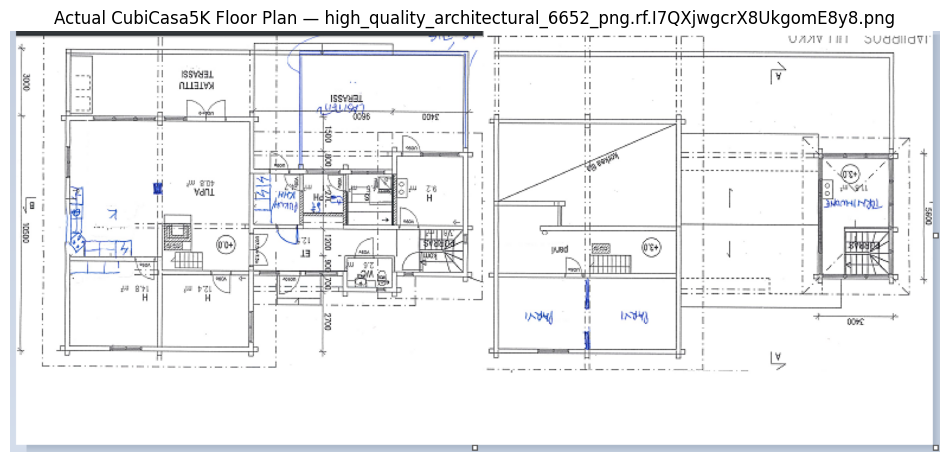

In [31]:
# CELL 19
# Get ONE actual floor-plan image + its annotations.
# Streaming prevents us from downloading the whole 2 GB dataset.

!pip -q install -U datasets

from datasets import load_dataset
import matplotlib.pyplot as plt

print("Loading CubiCasa5K from Hugging Face...")

floorplans = load_dataset(
    "phungpx/cubicassa5k-coco",
    split="train",
    streaming=True
)

sample = next(iter(floorplans))

print("\nActual floor-plan sample loaded.")
print("Image ID:", sample["image_id"])
print("Filename:", sample["file_name"])
print("Image size:", sample["width"], "x", sample["height"])
print("Number of annotations:", len(sample["annotations"]))

plt.figure(figsize=(12, 10))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(f"Actual CubiCasa5K Floor Plan — {sample['file_name']}")
plt.show()

In [32]:
# CELL 20
# Inspect the columnar COCO-style annotations returned by Hugging Face.

annotations = sample["annotations"]

print("Annotation columns:")
print(list(annotations.keys()))

print("\nNumber of annotations per column:")
for key, value in annotations.items():
    print(
        f"{key}: "
        f"type={type(value).__name__}, "
        f"length={len(value) if hasattr(value, '__len__') else 'N/A'}"
    )

print("\nFirst annotation:")
for key, value in annotations.items():
    if hasattr(value, "__len__") and not isinstance(value, str):
        print(f"{key}: {value[0]}")
    else:
        print(f"{key}: {value}")

Annotation columns:
['id', 'category_id', 'bbox', 'area', 'iscrowd', 'segmentation']

Number of annotations per column:
id: type=list, length=106
category_id: type=list, length=106
bbox: type=list, length=106
area: type=list, length=106
iscrowd: type=list, length=106
segmentation: type=list, length=106

First annotation:
id: 1
category_id: 5
bbox: [267.5299987792969, 402.4200134277344, 394.1300048828125, 610.3900146484375]
area: 240573.015625
iscrowd: 0
segmentation: [[661.6599731445312, 1012.8099975585938, 267.5299987792969, 1012.8099975585938, 267.5299987792969, 402.4200134277344, 661.6599731445312, 402.4200134277344]]


In [33]:
# CELL 21
# Inspect the actual category metadata supplied by the Hugging Face dataset.

print("Sample top-level fields:")
print(sample.keys())

print("\nLooking for category metadata...")

for key, value in sample.items():
    print(
        f"{key}: "
        f"type={type(value).__name__}"
    )

# Common places where the dataset may store category definitions.
for key in ["categories", "category", "labels", "features"]:
    if key in sample:
        print(f"\n--- {key} ---")
        print(str(sample[key])[:5000])

Sample top-level fields:
dict_keys(['image_id', 'file_name', 'image', 'width', 'height', 'annotations', 'split'])

Looking for category metadata...
image_id: type=int
file_name: type=str
image: type=PngImageFile
width: type=int
height: type=int
annotations: type=dict
split: type=str


In [34]:
# CELL 22
# Inspect the dataset-level schema/feature definitions.
# This is where category/label information may be stored.

print("Dataset feature schema:")
print(floorplans.features)

print("\n\nAnnotation feature schema:")
print(floorplans.features["annotations"])

print("\n\nFull annotation feature details:")
print(floorplans.features["annotations"].feature)

Dataset feature schema:
{'image_id': Value('int64'), 'file_name': Value('string'), 'image': Image(mode=None, decode=True), 'width': Value('int32'), 'height': Value('int32'), 'annotations': {'id': List(Value('int64')), 'category_id': List(Value('int32')), 'bbox': List(List(Value('float32'))), 'area': List(Value('float32')), 'iscrowd': List(Value('int32')), 'segmentation': List(List(List(Value('float32'))))}, 'split': Value('string')}


Annotation feature schema:
{'id': List(Value('int64')), 'category_id': List(Value('int32')), 'bbox': List(List(Value('float32'))), 'area': List(Value('float32')), 'iscrowd': List(Value('int32')), 'segmentation': List(List(List(Value('float32'))))}


Full annotation feature details:


AttributeError: 'dict' object has no attribute 'feature'

In [ ]:
# CELL 23
# Draw the ACTUAL CubiCasa5K annotation polygons over the actual floor-plan image.
#
# We are NOT running an AI model here.
# These polygons come directly from the dataset annotations.

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

annotations = sample["annotations"]

category_names = {
    1: "bathroom",
    2: "bed",
    3: "door",
    4: "kitchen",
    5: "room",
    6: "stairs",
    7: "wall",
    8: "window",
}

fig, ax = plt.subplots(figsize=(16, 10))

# Show the actual source floor-plan image.
ax.imshow(sample["image"])

# Overlay the actual annotation polygons.
for i in range(len(annotations["id"])):

    category_id = annotations["category_id"][i]
    segments = annotations["segmentation"][i]

    category_name = category_names.get(
        category_id,
        f"unknown_{category_id}"
    )

    # A segmentation can contain multiple polygons.
    for segment in segments:

        if len(segment) < 6:
            continue

        # Convert flat [x,y,x,y,...] → [(x,y), (x,y), ...]
        points = [
            (segment[j], segment[j + 1])
            for j in range(0, len(segment), 2)
        ]

        polygon = MplPolygon(
            points,
            closed=True,
            fill=False,
            linewidth=1
        )

        ax.add_patch(polygon)

        # Label approximately at the polygon center.
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]

        ax.text(
            sum(xs) / len(xs),
            sum(ys) / len(ys),
            category_name,
            fontsize=7
        )

ax.set_title(
    f"CubiCasa5K Ground-Truth Annotations — {sample['file_name']}"
)

ax.set_xlim(0, sample["width"])
ax.set_ylim(sample["height"], 0)

plt.show()

# Print category statistics for this particular floor plan.
print("\nCategory counts in this floor plan:")

from collections import Counter

counts = Counter(
    annotations["category_id"]
)

for category_id, count in sorted(counts.items()):
    print(
        f"{category_id}: "
        f"{category_names.get(category_id, 'unknown')} "
        f"→ {count}"
    )

In [35]:
# CELL 24
# Use the ACTUAL CubiCasa5K room polygons and extrude them into 3D.
#
# This is ground-truth geometry from the dataset.
# No AI is being used yet.

import trimesh
import plotly.graph_objects as go
from shapely.geometry import Polygon

annotations = sample["annotations"]

ROOM_CATEGORY_ID = 5

# Example floor height for this test.
# This is an INPUT assumption because a 2D floor plan does not contain
# absolute vertical elevation by itself.
FLOOR_HEIGHT_M = 3.0
FLOOR_BASE_Z_M = 0.0

room_meshes = []
room_info = []

for i in range(len(annotations["id"])):

    category_id = annotations["category_id"][i]

    if category_id != ROOM_CATEGORY_ID:
        continue

    segments = annotations["segmentation"][i]

    for segment in segments:

        if len(segment) < 6:
            continue

        points = [
            (segment[j], segment[j + 1])
            for j in range(0, len(segment), 2)
        ]

        polygon = Polygon(points)

        if polygon.is_empty or polygon.area <= 0:
            continue

        # Repair invalid polygons if necessary.
        if not polygon.is_valid:
            polygon = polygon.buffer(0)

        if polygon.is_empty:
            continue

        mesh = trimesh.creation.extrude_polygon(
            polygon,
            height=FLOOR_HEIGHT_M
        )

        mesh.apply_translation(
            [0, 0, FLOOR_BASE_Z_M]
        )

        room_meshes.append(mesh)

        room_info.append({
            "annotation_id": annotations["id"][i],
            "area_2d_px": polygon.area,
            "z_bottom": FLOOR_BASE_Z_M,
            "z_top": FLOOR_BASE_Z_M + FLOOR_HEIGHT_M
        })

print("Room volumes created:", len(room_meshes))

for idx, info in enumerate(room_info):
    print(
        f"Room {idx + 1}: "
        f"2D area={info['area_2d_px']:.2f} px², "
        f"Z={info['z_bottom']}→{info['z_top']} m"
    )

# -------------------------
# Visualize
# -------------------------

fig = go.Figure()

for idx, mesh in enumerate(room_meshes):

    v = mesh.vertices
    f = mesh.faces

    fig.add_trace(
        go.Mesh3d(
            x=v[:, 0],
            y=v[:, 1],
            z=v[:, 2],
            i=f[:, 0],
            j=f[:, 1],
            k=f[:, 2],
            opacity=0.55,
            name=f"Room {idx + 1}",
            hovertemplate=(
                f"Room {idx + 1}<br>"
                f"Z: {FLOOR_BASE_Z_M} → "
                f"{FLOOR_BASE_Z_M + FLOOR_HEIGHT_M} m"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Ground-Truth Floor Plan → 3D Room Volumes",
    scene=dict(
        xaxis_title="Floor-plan X",
        yaxis_title="Floor-plan Y",
        zaxis_title="Elevation Z (m)",
        aspectmode="data"
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

Room volumes created: 14
Room 1: 2D area=240572.99 px², Z=0.0→3.0 m
Room 2: 2D area=150624.62 px², Z=0.0→3.0 m
Room 3: 2D area=272556.24 px², Z=0.0→3.0 m
Room 4: 2D area=7919.28 px², Z=0.0→3.0 m
Room 5: 2D area=161443.83 px², Z=0.0→3.0 m
Room 6: 2D area=123457.08 px², Z=0.0→3.0 m
Room 7: 2D area=90688.01 px², Z=0.0→3.0 m
Room 8: 2D area=45753.86 px², Z=0.0→3.0 m
Room 9: 2D area=45704.17 px², Z=0.0→3.0 m
Room 10: 2D area=330376.42 px², Z=0.0→3.0 m
Room 11: 2D area=178421.45 px², Z=0.0→3.0 m
Room 12: 2D area=147813.27 px², Z=0.0→3.0 m
Room 13: 2D area=123180.74 px², Z=0.0→3.0 m
Room 14: 2D area=122728.81 px², Z=0.0→3.0 m


In [36]:
# CELL 25
# Determine the overall 2D extent of the actual annotated floor plan.
# Still no scaling or building matching.

annotations = sample["annotations"]

all_x = []
all_y = []

for segments in annotations["segmentation"]:
    for segment in segments:

        for j in range(0, len(segment), 2):
            all_x.append(segment[j])
            all_y.append(segment[j + 1])

min_x = min(all_x)
max_x = max(all_x)
min_y = min(all_y)
max_y = max(all_y)

width_px = max_x - min_x
height_px = max_y - min_y

print("ANNOTATED FLOOR-PLAN EXTENT")
print("---------------------------")
print("Min X:", min_x)
print("Max X:", max_x)
print("Min Y:", min_y)
print("Max Y:", max_y)

print("\nWidth :", round(width_px, 2), "pixels")
print("Height:", round(height_px, 2), "pixels")

print("\nImage size:")
print("Width :", sample["width"], "pixels")
print("Height:", sample["height"], "pixels")

ANNOTATED FLOOR-PLAN EXTENT
---------------------------
Min X: 247.52999877929688
Max X: 3957.52001953125
Min Y: 296.67999267578125
Max Y: 1447.3599853515625

Width : 3709.99 pixels
Height: 1150.68 pixels

Image size:
Width : 4163 pixels
Height: 1883 pixels


In [37]:
# CELL 26
# Download the trained Yytsi floor-plan segmentation model
# and its configuration. We are NOT running inference yet.

from huggingface_hub import hf_hub_download
from pathlib import Path

MODEL_REPO = "Yytsi/floorplan-to-3d-walls"

print("Downloading model weights...")

weights_path = hf_hub_download(
    repo_id=MODEL_REPO,
    filename="best.safetensors"
)

print("Weights downloaded:")
print(weights_path)

print("\nDownloading model configuration...")

config_path = hf_hub_download(
    repo_id=MODEL_REPO,
    filename="config.yaml"
)

print("Config downloaded:")
print(config_path)

print("\nFile sizes:")

print(
    "best.safetensors:",
    round(Path(weights_path).stat().st_size / (1024**2), 2),
    "MB"
)

print(
    "config.yaml:",
    round(Path(config_path).stat().st_size / 1024, 2),
    "KB"
)

best.safetensors: reconstructing file:   0%|          |  0.00B / 97.9MB            

best.safetensors: downloading bytes:           |  0.00B            

Weights downloaded:
/root/.cache/huggingface/hub/models--Yytsi--floorplan-to-3d-walls/snapshots/68843a3ab7b12aa03b23c36f955a0d8099b4e2ee/best.safetensors



config.yaml:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

Config downloaded:
/root/.cache/huggingface/hub/models--Yytsi--floorplan-to-3d-walls/snapshots/68843a3ab7b12aa03b23c36f955a0d8099b4e2ee/config.yaml

File sizes:
best.safetensors: 93.32 MB
config.yaml: 1.0 KB


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.9 MB/s eta 0:00:00
Building ResNet34-UNet...
Loading trained weights...
Missing keys: 0
Unexpected keys: 0

Input image:
Width : 4163
Height: 1883

Model input tensor: (1, 3, 512, 512)

Running Yytsi inference...
Inference complete.
Prediction shape: (512, 512)

Predicted pixel counts:
0 - floor :    7504573 pixels ( 95.73%)
1 - wall  :      50008 pixels (  0.64%)
2 - door  :      68573 pixels (  0.87%)
3 - window:     215775 pixels (  2.75%)


/tmp/ipykernel_1177/4098800675.py:179: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)



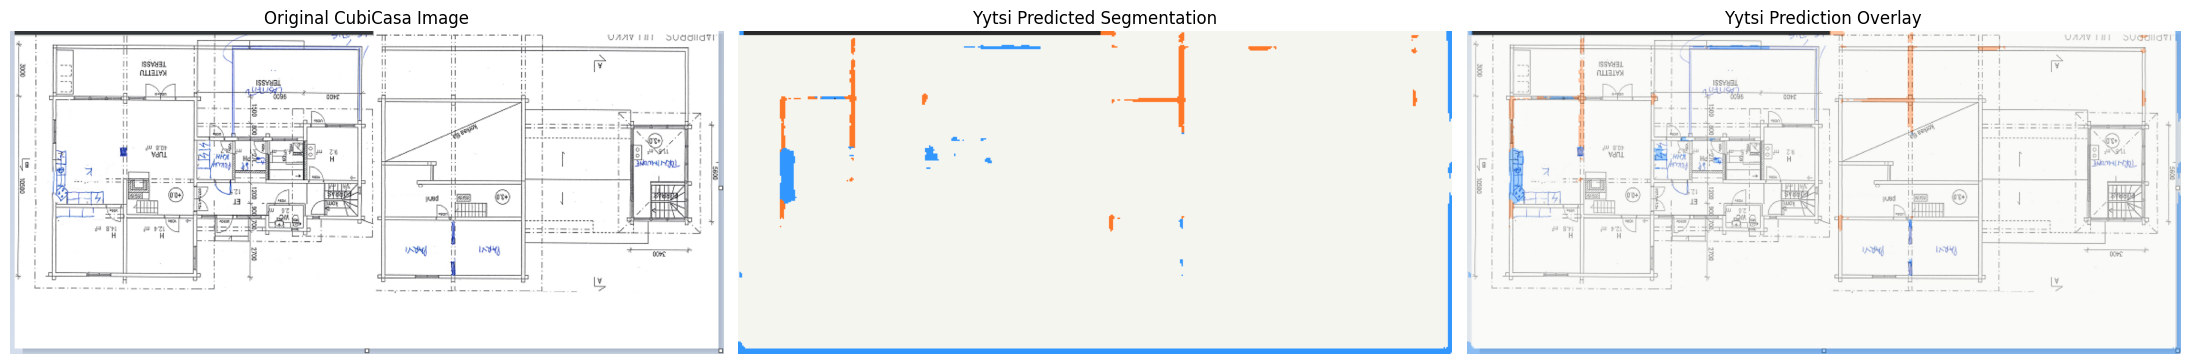


✅ Yytsi inference finished successfully.


In [38]:
# CELL 26
# Run the exact CubiCasa5K image currently in `sample`
# through the actual Yytsi trained model.

!pip -q install -U segmentation-models-pytorch safetensors pyyaml

import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from safetensors.torch import load_file
import segmentation_models_pytorch as smp

# ---------------------------------------------------------
# 1. Model configuration from Yytsi
# ---------------------------------------------------------

IMAGE_SIZE = 512

CLASS_NAMES = [
    "floor",
    "wall",
    "door",
    "window"
]

# ImageNet normalization used by the Yytsi training pipeline.
IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)

# ---------------------------------------------------------
# 2. Build the SAME model architecture
# ---------------------------------------------------------

print("Building ResNet34-UNet...")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,   # weights will come from best.safetensors
    in_channels=3,
    classes=4
)

# ---------------------------------------------------------
# 3. Load Yytsi's trained weights
# ---------------------------------------------------------

print("Loading trained weights...")

state_dict = load_file(weights_path)

# Handle possible prefixes defensively.
clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):
        key = key[len("module."):]

    if key.startswith("model."):
        key = key[len("model."):]

    clean_state_dict[key] = value

missing, unexpected = model.load_state_dict(
    clean_state_dict,
    strict=False
)

print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

if missing:
    print("First missing keys:", missing[:10])

if unexpected:
    print("First unexpected keys:", unexpected[:10])

model.eval()

# ---------------------------------------------------------
# 4. Use the EXACT CubiCasa image already loaded
# ---------------------------------------------------------

image = sample["image"].convert("RGB")

print("\nInput image:")
print("Width :", image.width)
print("Height:", image.height)

# ---------------------------------------------------------
# 5. Aspect-preserving letterbox → 512 × 512
# ---------------------------------------------------------

orig_w, orig_h = image.size

scale = min(
    IMAGE_SIZE / orig_w,
    IMAGE_SIZE / orig_h
)

new_w = int(round(orig_w * scale))
new_h = int(round(orig_h * scale))

resized = image.resize(
    (new_w, new_h),
    Image.Resampling.BILINEAR
)

# ImageNet-mean padding.
pad_rgb = tuple(
    int(round(x * 255))
    for x in IMAGENET_MEAN
)

canvas = Image.new(
    "RGB",
    (IMAGE_SIZE, IMAGE_SIZE),
    pad_rgb
)

left = (IMAGE_SIZE - new_w) // 2
top = (IMAGE_SIZE - new_h) // 2

canvas.paste(
    resized,
    (left, top)
)

# ---------------------------------------------------------
# 6. ImageNet normalization
# ---------------------------------------------------------

arr = np.asarray(canvas).astype(np.float32) / 255.0

arr = (
    arr - IMAGENET_MEAN
) / IMAGENET_STD

# HWC → CHW → batch
tensor = torch.from_numpy(
    arr.transpose(2, 0, 1)
).unsqueeze(0).float()

print("\nModel input tensor:", tuple(tensor.shape))

# ---------------------------------------------------------
# 7. Run ACTUAL inference
# ---------------------------------------------------------

print("\nRunning Yytsi inference...")

with torch.no_grad():
    logits = model(tensor)

prediction_512 = logits.argmax(dim=1)[0].cpu().numpy()

print("Inference complete.")
print("Prediction shape:", prediction_512.shape)

# ---------------------------------------------------------
# 8. Undo letterboxing
# ---------------------------------------------------------

cropped_prediction = prediction_512[
    top:top + new_h,
    left:left + new_w
]

# Resize prediction back to original image dimensions.
pred_image = Image.fromarray(
    cropped_prediction.astype(np.uint8),
    mode="L"
)

pred_image = pred_image.resize(
    (orig_w, orig_h),
    Image.Resampling.NEAREST
)

prediction = np.asarray(
    pred_image,
    dtype=np.uint8
)

# ---------------------------------------------------------
# 9. Print predicted pixel distribution
# ---------------------------------------------------------

print("\nPredicted pixel counts:")

for class_id, class_name in enumerate(CLASS_NAMES):

    count = int(
        np.sum(prediction == class_id)
    )

    percentage = (
        count / prediction.size * 100
    )

    print(
        f"{class_id} - {class_name:6s}: "
        f"{count:10d} pixels "
        f"({percentage:6.2f}%)"
    )

# ---------------------------------------------------------
# 10. Visualize prediction
# ---------------------------------------------------------

# Colors are ONLY for visualization.
colors = np.array([
    [245, 245, 240],   # floor
    [40, 40, 40],      # wall
    [255, 120, 40],    # door
    [50, 150, 255],    # window
], dtype=np.uint8)

color_mask = colors[prediction]

fig, axes = plt.subplots(
    1, 3,
    figsize=(22, 8)
)

# Original
axes[0].imshow(image)
axes[0].set_title("Original CubiCasa Image")
axes[0].axis("off")

# Raw predicted classes
axes[1].imshow(color_mask)
axes[1].set_title("Yytsi Predicted Segmentation")
axes[1].axis("off")

# Overlay
axes[2].imshow(image)
axes[2].imshow(color_mask, alpha=0.45)
axes[2].set_title("Yytsi Prediction Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Yytsi inference finished successfully.")

In [39]:
# CELL 27
# Quantitative comparison:
# Yytsi prediction vs CubiCasa5K ground-truth polygons.
#
# We compare the classes that both systems actually represent:
#   wall  = CubiCasa category 7 ↔ Yytsi class 1
#   door  = CubiCasa category 3 ↔ Yytsi class 2
#   window = CubiCasa category 8 ↔ Yytsi class 3
#
# Room/bathroom/kitchen/etc. are NOT compared because Yytsi does not
# predict those classes.

from PIL import Image, ImageDraw
import numpy as np

GT_TO_MODEL = {
    "wall":   {"gt_category": 7, "model_class": 1},
    "door":   {"gt_category": 3, "model_class": 2},
    "window": {"gt_category": 8, "model_class": 3},
}

# ---------------------------------------------------------
# 1. Create ground-truth binary masks from the actual
#    CubiCasa polygons.
# ---------------------------------------------------------

width = sample["width"]
height = sample["height"]

gt_masks = {}

for class_name, mapping in GT_TO_MODEL.items():

    mask_img = Image.new(
        "L",
        (width, height),
        0
    )

    draw = ImageDraw.Draw(mask_img)

    for i, category_id in enumerate(
        annotations["category_id"]
    ):

        if category_id != mapping["gt_category"]:
            continue

        for segment in annotations["segmentation"][i]:

            if len(segment) < 6:
                continue

            points = [
                (
                    float(segment[j]),
                    float(segment[j + 1])
                )
                for j in range(0, len(segment), 2)
            ]

            draw.polygon(
                points,
                fill=1
            )

    gt_masks[class_name] = np.asarray(
        mask_img,
        dtype=bool
    )

# ---------------------------------------------------------
# 2. Sanity check prediction dimensions
# ---------------------------------------------------------

print("Ground truth shape:", gt_masks["wall"].shape)
print("Yytsi prediction shape:", prediction.shape)

assert prediction.shape == (
    height,
    width
), "Prediction and ground truth dimensions do not match."

# ---------------------------------------------------------
# 3. Calculate pixel-level metrics
# ---------------------------------------------------------

def calculate_metrics(gt, pred):

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    iou = (
        tp / (tp + fp + fn)
        if (tp + fp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "ground_truth_pixels": int(gt.sum()),
        "predicted_pixels": int(pred.sum()),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "precision": precision,
        "recall": recall,
        "IoU": iou,
        "F1": f1,
    }

results = {}

for class_name, mapping in GT_TO_MODEL.items():

    gt = gt_masks[class_name]

    pred = (
        prediction == mapping["model_class"]
    )

    results[class_name] = calculate_metrics(
        gt,
        pred
    )

# ---------------------------------------------------------
# 4. Print results
# ---------------------------------------------------------

print("\nYytsi vs CubiCasa Ground Truth")
print("=" * 70)

for class_name, metrics in results.items():

    print(f"\n{class_name.upper()}")

    print(
        "GT pixels       :",
        metrics["ground_truth_pixels"]
    )

    print(
        "Predicted pixels:",
        metrics["predicted_pixels"]
    )

    print(
        "IoU             :",
        f"{metrics['IoU']:.4f}"
    )

    print(
        "Precision       :",
        f"{metrics['precision']:.4f}"
    )

    print(
        "Recall          :",
        f"{metrics['recall']:.4f}"
    )

    print(
        "F1              :",
        f"{metrics['F1']:.4f}"
    )

Ground truth shape: (1883, 4163)
Yytsi prediction shape: (1883, 4163)

Yytsi vs CubiCasa Ground Truth

WALL
GT pixels       : 383714
Predicted pixels: 50008
IoU             : 0.0001
Precision       : 0.0013
Recall          : 0.0002
F1              : 0.0003

DOOR
GT pixels       : 130340
Predicted pixels: 68573
IoU             : 0.0000
Precision       : 0.0000
Recall          : 0.0000
F1              : 0.0000

WINDOW
GT pixels       : 62787
Predicted pixels: 215775
IoU             : 0.0091
Precision       : 0.0117
Recall          : 0.0401
F1              : 0.0181


In [40]:
# CELL 28
# Ask the official CubiCasa5K Zenodo record what files are available.
# We are NOT downloading the dataset yet.

import requests

ZENODO_API = "https://zenodo.org/api/records/2613548"

print("Checking official CubiCasa5K Zenodo record...")

response = requests.get(
    ZENODO_API,
    timeout=60
)

response.raise_for_status()

record = response.json()

print("Record title:")
print(record.get("metadata", {}).get("title"))

print("\nAvailable files:")

for file_info in record.get("files", []):
    print(
        file_info.get("key"),
        " | ",
        file_info.get("size"),
        "bytes"
    )

Checking official CubiCasa5K Zenodo record...
Record title:
CubiCasa5k

Available files:
cubicasa5k.zip  |  5469495706 bytes


In [41]:
# CELL 29
# Inspect the original 5.47 GB CubiCasa5K ZIP remotely.
# We DO NOT download the whole archive.

!pip -q install remotezip

from remotezip import RemoteZip

# The direct Zenodo download URL from the API record we queried earlier.
zip_url = record["files"][0]["links"]["self"]

print("Opening remote CubiCasa5K ZIP...")
print("This should NOT download the whole 5.47 GB file.")

with RemoteZip(
    zip_url,
    timeout=60
) as z:

    # Only inspect filenames containing "6652".
    matches = [
        name
        for name in z.namelist()
        if "6652" in name
    ]

print("\nMatching files:")
for name in matches:
    print(name)

print("\nNumber of matches:", len(matches))

Opening remote CubiCasa5K ZIP...
This should NOT download the whole 5.47 GB file.

Matching files:
cubicasa5k/high_quality_architectural/6652/
cubicasa5k/high_quality_architectural/6652/F2_scaled.png
cubicasa5k/high_quality_architectural/6652/F1_scaled.png
cubicasa5k/high_quality_architectural/6652/F1_original.png
cubicasa5k/high_quality_architectural/6652/F2_original.png
cubicasa5k/high_quality_architectural/6652/model.svg

Number of matches: 6


cubicasa5k/high_quality_architectural/6652/model.svg

SVG downloaded successfully.
SVG size: 138.01 KB
Saved: cubicasa_6652_model.svg
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.5 MB/s eta 0:00:00
Rendered: cubicasa_6652_model_from_svg.png
Rendered dimensions: (1024, 394)


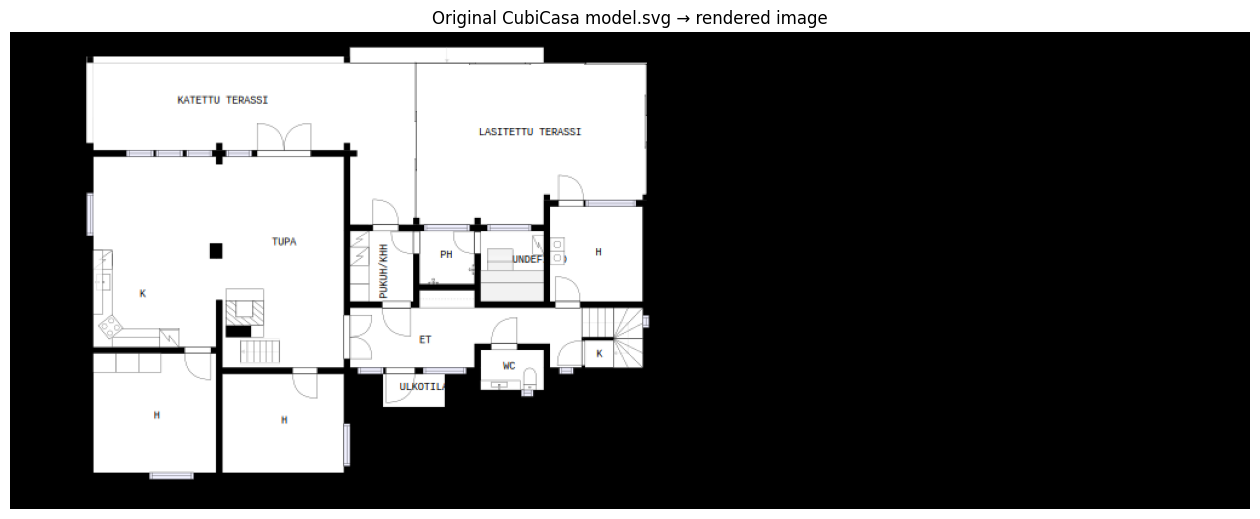

In [42]:
# CELL 30
# Download ONLY the original CubiCasa5K model.svg for sample 6652.
# Then render it to a PNG so we can inspect the exact SVG representation.

from remotezip import RemoteZip
from io import BytesIO
from pathlib import Path
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

SVG_PATH = "cubicasa5k/high_quality_architectural/6652/model.svg"

print("Downloading only:")
print(SVG_PATH)

with RemoteZip(
    zip_url,
    timeout=120
) as z:

    svg_bytes = z.read(SVG_PATH)

print("\nSVG downloaded successfully.")
print("SVG size:", round(len(svg_bytes) / 1024, 2), "KB")

# Save locally for inspection/reuse.
svg_file = Path("cubicasa_6652_model.svg")
svg_file.write_bytes(svg_bytes)

print("Saved:", svg_file)

# ---------------------------------------------------------
# Render SVG → PNG
# ---------------------------------------------------------

!pip -q install cairosvg

import cairosvg

rendered_png = "cubicasa_6652_model_from_svg.png"

cairosvg.svg2png(
    bytestring=svg_bytes,
    write_to=rendered_png,
    output_width=1024
)

print("Rendered:", rendered_png)

# ---------------------------------------------------------
# Display the SVG-derived image
# ---------------------------------------------------------

svg_image = Image.open(rendered_png).convert("RGB")

print("Rendered dimensions:", svg_image.size)

plt.figure(figsize=(16, 8))
plt.imshow(svg_image)
plt.axis("off")
plt.title("Original CubiCasa model.svg → rendered image")
plt.show()

In [43]:
# CELL 31
# Read the exact configuration shipped with the Yytsi checkpoint.

import yaml

with open(config_path, "r") as f:
    yytsi_config = yaml.safe_load(f)

print("Yytsi config:")
print("=" * 70)

for key, value in yytsi_config.items():
    print(f"{key}: {value}")

Yytsi config:
data: {'data_dir': 'data/cubicasa5k', 'image_size': [512, 512], 'num_workers': 4, 'normalize': True, 'letterbox': True}
model: {'encoder_name': 'resnet34', 'encoder_weights': 'imagenet'}
optim: {'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 8}
train: {'epochs': 30, 'log_every': 20, 'device': 'auto', 'checkpoint_every': 0}
output: {'run_dir': 'runs/v2'}


Structural-only SVG prepared.
SVG native size:
Width : 3980.2100219726562
Height: 1532.8096466064453

Letterbox:
Scale   : 0.12863642802101297
Inner W : 512
Inner H : 197

Final model image: (512, 512)
Letterbox offset: 0 157
Tensor: (1, 3, 512, 512)

Inference complete.
Prediction shape: (512, 512)


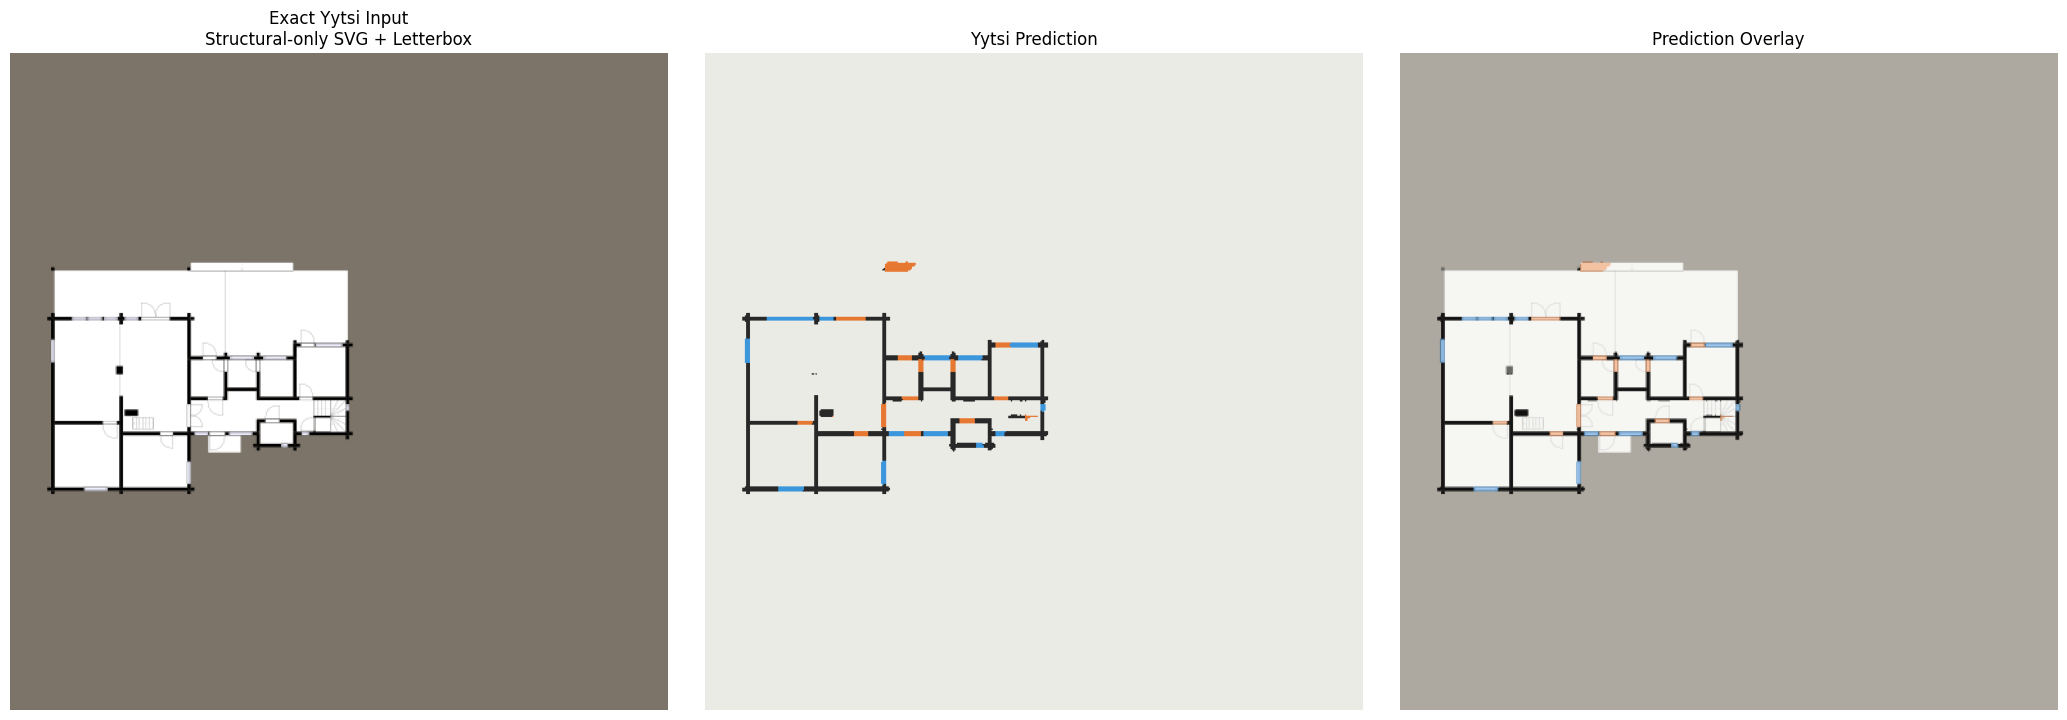


Predicted pixels:
floor :   257375 pixels ( 98.18%)
wall  :     3222 pixels (  1.23%)
door  :      741 pixels (  0.28%)
window:      806 pixels (  0.31%)


In [44]:
# CELL 32
# Run Yytsi using the ORIGINAL CubiCasa model.svg and
# Yytsi's own structural-only preprocessing.

import xml.etree.ElementTree as ET
from io import BytesIO

import cairosvg
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------------------------------------
# 1. Yytsi settings from its config/source
# ---------------------------------------------------------

TARGET_W = 512
TARGET_H = 512

IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)

# Classes used by Yytsi.
CLASS_NAMES = [
    "floor",
    "wall",
    "door",
    "window"
]

# ---------------------------------------------------------
# 2. Remove non-structural SVG content
#    (same tokens used by Yytsi's renderer)
# ---------------------------------------------------------

DROP_TOKENS = {
    "FixedFurniture",
    "FixedFurnitureSet",
    "Faucet",
    "Hanger",
    "Railing",
    "InnerDrain",
    "OuterDrain",
    "OuterCircle",
    "Dimension",
    "DimensionMark",
    "Direction",
    "TextLabel",
    "Name",
    "SpaceDimensionsLabel",
    "electricitySign",
}

svg_tree = ET.parse(svg_file)
root = svg_tree.getroot()

def prune_element(elem):
    for child in list(elem):

        tokens = (child.get("class") or "").split()

        if any(token in DROP_TOKENS for token in tokens):
            elem.remove(child)
        else:
            prune_element(child)

prune_element(root)

filtered_svg_bytes = ET.tostring(root)

print("Structural-only SVG prepared.")

# ---------------------------------------------------------
# 3. Read the SVG's native dimensions
# ---------------------------------------------------------

viewbox = (root.get("viewBox") or "").split()

svg_w = float(
    root.get("width")
    or (viewbox[2] if len(viewbox) == 4 else 0)
)

svg_h = float(
    root.get("height")
    or (viewbox[3] if len(viewbox) == 4 else 0)
)

print("SVG native size:")
print("Width :", svg_w)
print("Height:", svg_h)

# ---------------------------------------------------------
# 4. Yytsi letterbox calculation
# ---------------------------------------------------------

scale = min(
    TARGET_W / svg_w,
    TARGET_H / svg_h
)

inner_w = max(
    1,
    int(round(svg_w * scale))
)

inner_h = max(
    1,
    int(round(svg_h * scale))
)

print("\nLetterbox:")
print("Scale   :", scale)
print("Inner W :", inner_w)
print("Inner H :", inner_h)

# ---------------------------------------------------------
# 5. Render STRUCTURAL-ONLY SVG
# ---------------------------------------------------------

png_bytes = cairosvg.svg2png(
    bytestring=filtered_svg_bytes,
    output_width=inner_w,
    output_height=inner_h,
    background_color="rgb(124,116,104)"
)

inner_image = Image.open(
    BytesIO(png_bytes)
).convert("RGB")

# ---------------------------------------------------------
# 6. Center letterbox to 512 × 512
# ---------------------------------------------------------

canvas = Image.new(
    "RGB",
    (TARGET_W, TARGET_H),
    (124, 116, 104)
)

left = (TARGET_W - inner_w) // 2
top = (TARGET_H - inner_h) // 2

canvas.paste(
    inner_image,
    (left, top)
)

print("\nFinal model image:", canvas.size)
print("Letterbox offset:", left, top)

# ---------------------------------------------------------
# 7. ImageNet normalization
# ---------------------------------------------------------

image_np = np.asarray(
    canvas
).astype(np.float32) / 255.0

image_np = (
    image_np - IMAGENET_MEAN
) / IMAGENET_STD

tensor = torch.from_numpy(
    image_np.transpose(2, 0, 1)
).unsqueeze(0).float()

print("Tensor:", tuple(tensor.shape))

# ---------------------------------------------------------
# 8. Run the trained Yytsi model
# ---------------------------------------------------------

model.eval()

with torch.no_grad():
    logits = model(tensor)

pred_512 = logits.argmax(
    dim=1
)[0].cpu().numpy()

print("\nInference complete.")
print("Prediction shape:", pred_512.shape)

# ---------------------------------------------------------
# 9. Visualize the exact image given to Yytsi
#    and its prediction
# ---------------------------------------------------------

VIS_COLORS = np.array([
    [235, 235, 230],   # floor
    [40, 40, 40],      # wall
    [230, 120, 50],    # door
    [60, 150, 220],    # window
], dtype=np.uint8)

pred_rgb = VIS_COLORS[pred_512]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7)
)

axes[0].imshow(canvas)
axes[0].set_title(
    "Exact Yytsi Input\nStructural-only SVG + Letterbox"
)
axes[0].axis("off")

axes[1].imshow(pred_rgb)
axes[1].set_title(
    "Yytsi Prediction"
)
axes[1].axis("off")

axes[2].imshow(canvas)
axes[2].imshow(
    pred_rgb,
    alpha=0.45
)
axes[2].set_title(
    "Prediction Overlay"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10. Pixel distribution
# ---------------------------------------------------------

print("\nPredicted pixels:")

for class_id, class_name in enumerate(CLASS_NAMES):

    count = int(
        np.sum(pred_512 == class_id)
    )

    percentage = (
        count / pred_512.size * 100
    )

    print(
        f"{class_name:6s}: "
        f"{count:8d} pixels "
        f"({percentage:6.2f}%)"
    )

SVG: 3980.2100219726562 × 1532.8096466064453
Yytsi content area: 512 × 197
Letterbox offset: 0 157

EXACT YYTSI GROUND-TRUTH COMPARISON

FLOOR
GT pixels       : 257386
Predicted pixels: 257375
IoU             : 0.9979
Precision       : 0.9990
Recall          : 0.9989
F1              : 0.9989

WALL
GT pixels       : 3371
Predicted pixels: 3222
IoU             : 0.8924
Precision       : 0.9649
Recall          : 0.9223
F1              : 0.9431

DOOR
GT pixels       : 584
Predicted pixels: 741
IoU             : 0.7208
Precision       : 0.7490
Recall          : 0.9503
F1              : 0.8377

WINDOW
GT pixels       : 803
Predicted pixels: 806
IoU             : 0.9718
Precision       : 0.9839
Recall          : 0.9875
F1              : 0.9857


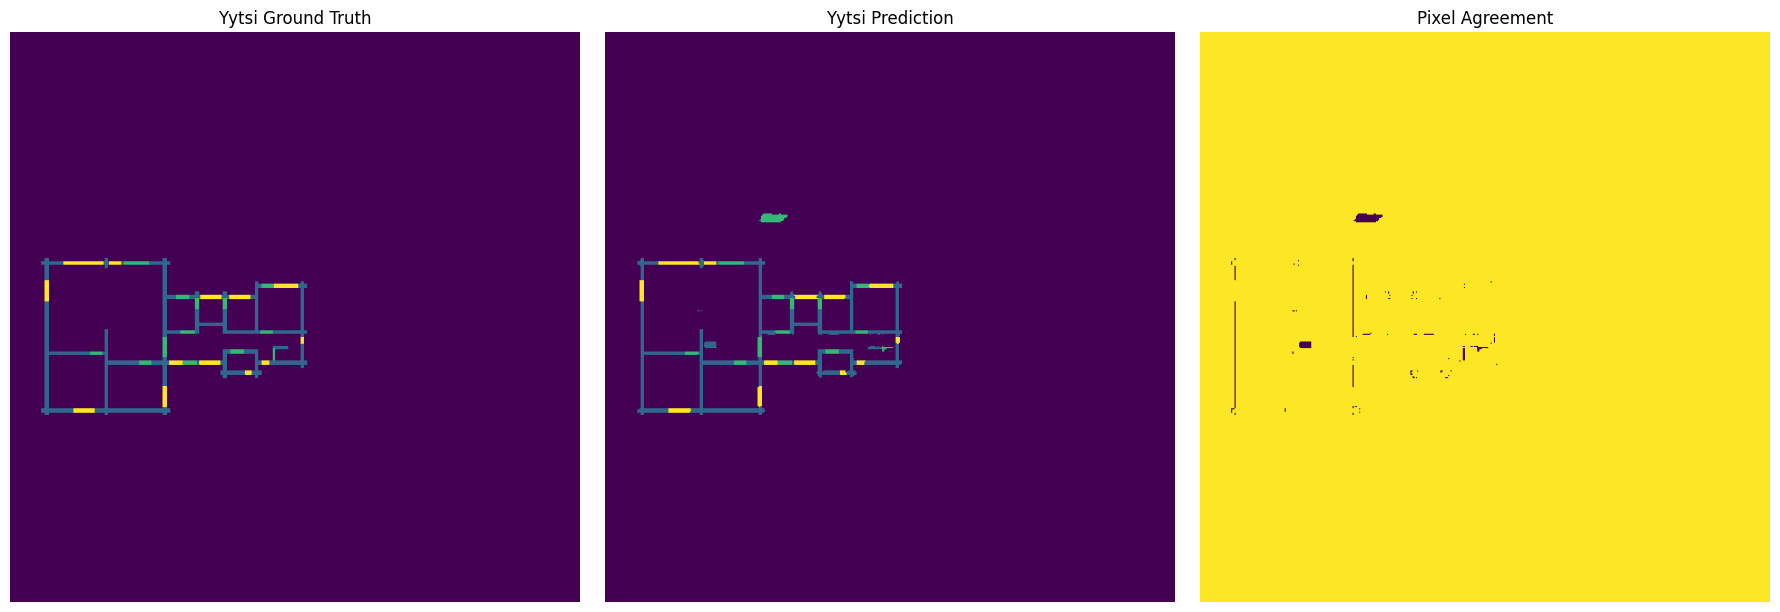

In [45]:
# CELL 33
# Create the ground-truth mask exactly the way Yytsi's own
# repository does, then compare it to our prediction.

import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

CLASS_TO_ID = {
    "floor": 0,
    "wall": 1,
    "door": 2,
    "window": 3,
}

PAINT_ORDER = ["wall", "door", "window"]

TOKEN_TO_CLASS = {
    "Window": "window",
    "Door": "door",
    "Wall": "wall",
}

SVG_NS = "{http://www.w3.org/2000/svg}"
POLYGON_TAG = f"{SVG_NS}polygon"
RECT_TAG = f"{SVG_NS}rect"


def is_hidden(elem):
    if elem.get("display") == "none":
        return True
    if elem.get("visibility") == "hidden":
        return True

    style = (elem.get("style") or "").replace(" ", "")

    return (
        "display:none" in style
        or "visibility:hidden" in style
    )


def polygon_points(elem):
    raw = (elem.get("points") or "").replace(",", " ").split()
    coords = [float(x) for x in raw]
    return list(zip(coords[0::2], coords[1::2]))


def rect_points(elem):
    x = float(elem.get("x", 0))
    y = float(elem.get("y", 0))
    w = float(elem.get("width", 0))
    h = float(elem.get("height", 0))

    return [
        (x, y),
        (x + w, y),
        (x + w, y + h),
        (x, y + h),
    ]


def classify(tokens):
    for token, cls in TOKEN_TO_CLASS.items():
        if token in tokens:
            return cls
    return None


def collect(elem, inherited, out):
    if is_hidden(elem):
        return

    own = elem.get("class")

    tokens = inherited | (
        set(own.split())
        if own
        else set()
    )

    points = None

    if elem.tag == POLYGON_TAG:
        points = polygon_points(elem)

    elif elem.tag == RECT_TAG:
        points = rect_points(elem)

    if points is not None and len(points) >= 3:

        cls = classify(tokens)

        if cls is not None:
            out.setdefault(cls, []).append(points)

    for child in elem:
        collect(child, tokens, out)


# ---------------------------------------------------------
# 1. Read original SVG
# ---------------------------------------------------------

root = ET.parse(svg_file).getroot()

viewbox = (
    root.get("viewBox") or ""
).split()

svg_w = float(
    root.get("width")
    or viewbox[2]
)

svg_h = float(
    root.get("height")
    or viewbox[3]
)

print("SVG:", svg_w, "×", svg_h)


# ---------------------------------------------------------
# 2. Same letterbox dimensions as Yytsi
# ---------------------------------------------------------

scale = min(
    512 / svg_w,
    512 / svg_h
)

inner_w = max(
    1,
    int(round(svg_w * scale))
)

inner_h = max(
    1,
    int(round(svg_h * scale))
)

top = (512 - inner_h) // 2
left = (512 - inner_w) // 2

print(
    "Yytsi content area:",
    inner_w,
    "×",
    inner_h
)

print(
    "Letterbox offset:",
    left,
    top
)


# ---------------------------------------------------------
# 3. Extract SVG structural polygons
# ---------------------------------------------------------

polys_by_class = {}

collect(
    root,
    set(),
    polys_by_class
)


# ---------------------------------------------------------
# 4. Rasterize exact Yytsi ground truth
# ---------------------------------------------------------

mask_inner = Image.new(
    "L",
    (inner_w, inner_h),
    color=CLASS_TO_ID["floor"]
)

draw = ImageDraw.Draw(mask_inner)

for cls in PAINT_ORDER:

    class_id = CLASS_TO_ID[cls]

    for pts in polys_by_class.get(cls, []):

        scaled = [
            (
                x * inner_w / svg_w,
                y * inner_h / svg_h
            )
            for x, y in pts
        ]

        draw.polygon(
            scaled,
            fill=class_id
        )


# ---------------------------------------------------------
# 5. Put mask into same 512×512 canvas
# ---------------------------------------------------------

gt_mask = np.full(
    (512, 512),
    CLASS_TO_ID["floor"],
    dtype=np.uint8
)

gt_mask[
    top:top + inner_h,
    left:left + inner_w
] = np.asarray(mask_inner)


# ---------------------------------------------------------
# 6. Compare prediction vs exact Yytsi GT
# ---------------------------------------------------------

CLASS_NAMES = [
    "floor",
    "wall",
    "door",
    "window"
]


def metrics_for_class(gt, pred):

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()

    precision = (
        tp / (tp + fp)
        if tp + fp else 0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn else 0
    )

    iou = (
        tp / (tp + fp + fn)
        if tp + fp + fn else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall else 0
    )

    return precision, recall, iou, f1


print("\nEXACT YYTSI GROUND-TRUTH COMPARISON")
print("=" * 70)

for class_id, class_name in enumerate(CLASS_NAMES):

    gt = gt_mask == class_id
    pred = pred_512 == class_id

    precision, recall, iou, f1 = metrics_for_class(
        gt,
        pred
    )

    print(f"\n{class_name.upper()}")

    print(
        "GT pixels       :",
        int(gt.sum())
    )

    print(
        "Predicted pixels:",
        int(pred.sum())
    )

    print(
        "IoU             :",
        f"{iou:.4f}"
    )

    print(
        "Precision       :",
        f"{precision:.4f}"
    )

    print(
        "Recall          :",
        f"{recall:.4f}"
    )

    print(
        "F1              :",
        f"{f1:.4f}"
    )


# ---------------------------------------------------------
# 7. Visual comparison
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

axes[0].imshow(gt_mask)
axes[0].set_title("Yytsi Ground Truth")
axes[0].axis("off")

axes[1].imshow(pred_512)
axes[1].set_title("Yytsi Prediction")
axes[1].axis("off")

axes[2].imshow(
    gt_mask == pred_512
)
axes[2].set_title("Pixel Agreement")
axes[2].axis("off")

plt.tight_layout()
plt.show()

wall  : 0 polygons extracted
door  : 8 polygons extracted
window: 7 polygons extracted

Total predicted polygons: 15
wall  : 0
door  : 8
window: 7


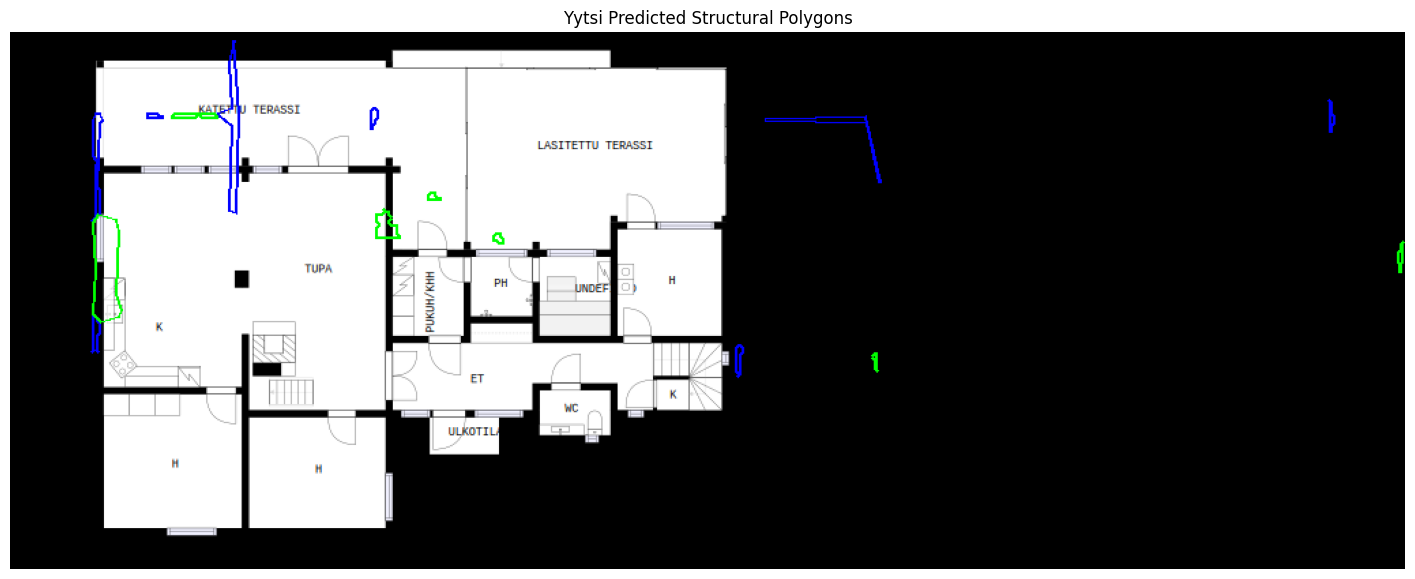


Example polygon records:

Class: door | area: 21.5 model pixels
SVG points: [(2083.3911833763123, 893.9924854040146), (2075.617335677147, 893.9924854040146), (2067.8434879779816, 901.7663331031798), (2067.8434879779816, 963.9571146965026), (2075.617335677147, 971.7309623956679), (2075.617335677147, 979.5048100948333), (2083.3911833763123, 971.7309623956679), (2083.3911833763123, 917.3140285015105)]

Class: door | area: 28.5 model pixels
SVG points: [(233.2154309749603, 808.4801607131958), (233.2154309749603, 909.5401808023452), (240.98927867412564, 901.7663331031798), (248.763126373291, 909.5401808023452), (248.763126373291, 862.8970946073532), (256.53697407245636, 855.1232469081879), (256.53697407245636, 831.8017038106918), (248.763126373291, 824.0278561115265)]

Class: door | area: 4.5 model pixels
SVG points: [(388.6923849582672, 233.2154309749603), (388.6923849582672, 240.98927867412564), (435.3354711532593, 240.98927867412564), (427.56162345409393, 240.98927867412564), (419.78777

In [46]:
# CELL 34
# Convert Yytsi's predicted segmentation masks into vector polygons.
#
# This is deterministic post-processing:
# AI = predicts pixels
# Geometry stage = converts those pixels into polygons
#
# Classes:
#   1 = wall
#   2 = door
#   3 = window

!pip -q install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

PREDICTED_CLASSES = {
    1: "wall",
    2: "door",
    3: "window"
}

MIN_CONTOUR_AREA_PX = 3.0

predicted_polygons = []

# ---------------------------------------------------------
# 1. Extract contours from each predicted class
# ---------------------------------------------------------

for class_id, class_name in PREDICTED_CLASSES.items():

    binary = (
        prediction_512 == class_id
    ).astype(np.uint8) * 255

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    class_count = 0

    for contour in contours:

        area_px = cv2.contourArea(contour)

        if area_px < MIN_CONTOUR_AREA_PX:
            continue

        # Simplify the contour slightly.
        perimeter = cv2.arcLength(
            contour,
            True
        )

        epsilon = 0.01 * perimeter

        approx = cv2.approxPolyDP(
            contour,
            epsilon,
            True
        )

        points_512 = [
            (
                float(p[0][0]),
                float(p[0][1])
            )
            for p in approx
        ]

        # -------------------------------------------------
        # Convert from 512×512 model coordinates back to
        # original SVG coordinates.
        # -------------------------------------------------

        points_svg = []

        for x, y in points_512:

            x_svg = x / scale

            y_svg = (
                (y - top) / scale
            )

            # Ignore polygons entirely inside letterbox padding.
            if (
                y_svg < 0
                or y_svg > svg_h
            ):
                continue

            points_svg.append(
                (x_svg, y_svg)
            )

        if len(points_svg) < 3:
            continue

        predicted_polygons.append({
            "class": class_name,
            "class_id": class_id,
            "area_px": float(area_px),
            "points_512": points_512,
            "points_svg": points_svg
        })

        class_count += 1

    print(
        f"{class_name:6s}: "
        f"{class_count} polygons extracted"
    )

# ---------------------------------------------------------
# 2. Summary
# ---------------------------------------------------------

print(
    "\nTotal predicted polygons:",
    len(predicted_polygons)
)

for class_name in PREDICTED_CLASSES.values():

    count = sum(
        p["class"] == class_name
        for p in predicted_polygons
    )

    print(
        f"{class_name:6s}: {count}"
    )

# ---------------------------------------------------------
# 3. Visualize polygons on the ORIGINAL SVG rendering
# ---------------------------------------------------------

# Rendered SVG image from Cell 30.
display_image = svg_image.copy()

# Match SVG coordinates to the rendered image dimensions.
render_w, render_h = display_image.size

overlay = display_image.copy()
draw = ImageDraw.Draw(
    overlay
)

outline_colors = {
    "wall": "red",
    "door": "blue",
    "window": "lime"
}

for poly in predicted_polygons:

    pts = []

    for x_svg, y_svg in poly["points_svg"]:

        x_img = (
            x_svg / svg_w
        ) * render_w

        y_img = (
            y_svg / svg_h
        ) * render_h

        pts.append(
            (
                int(round(x_img)),
                int(round(y_img))
            )
        )

    if len(pts) >= 3:

        draw.line(
            pts + [pts[0]],
            fill=outline_colors[poly["class"]],
            width=2
        )

plt.figure(
    figsize=(18, 8)
)

plt.imshow(overlay)
plt.axis("off")
plt.title(
    "Yytsi Predicted Structural Polygons"
)

plt.show()

# ---------------------------------------------------------
# 4. Show a few extracted polygon records
# ---------------------------------------------------------

print("\nExample polygon records:")

for poly in predicted_polygons[:10]:

    print(
        "\nClass:",
        poly["class"],
        "| area:",
        round(poly["area_px"], 2),
        "model pixels"
    )

    print(
        "SVG points:",
        poly["points_svg"][:8]
    )

Yytsi-style polygon extraction
wall   : 1 polygons
door   : 3 polygons
window : 5 polygons

Total polygons: 9


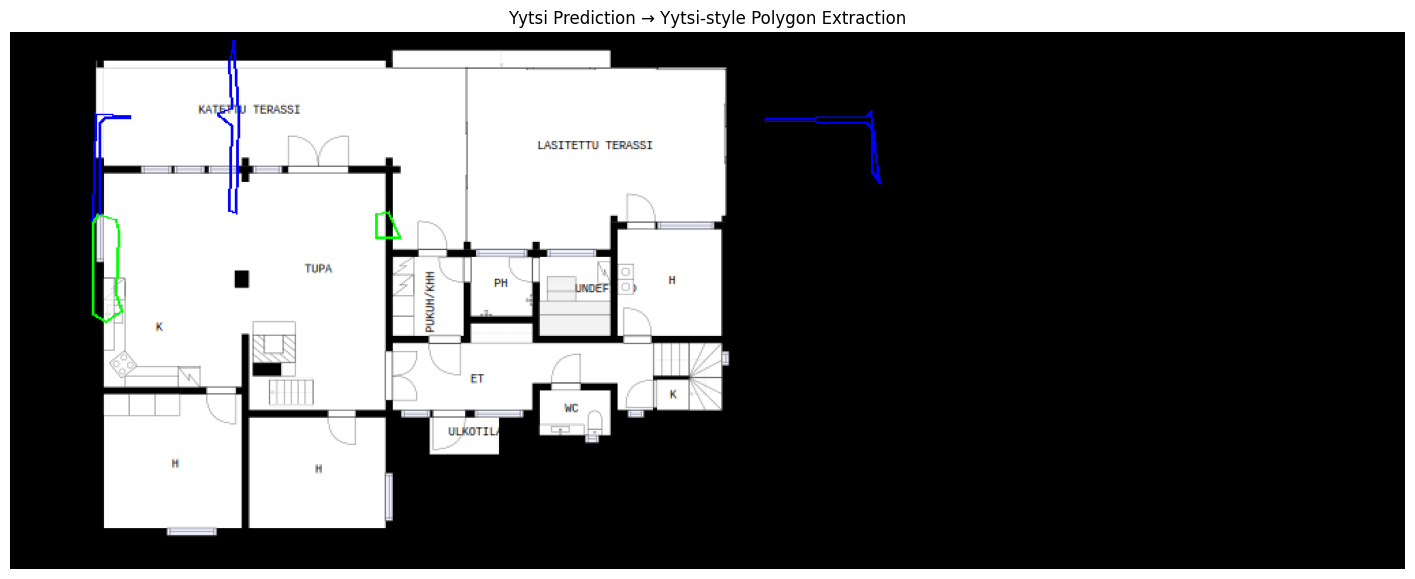


Sample wall polygons:

Area: 510.0 px²
Outer vertices: 4
Holes: 0


In [47]:
# CELL 35
# Reproduce Yytsi's documented/current polygon extraction:
#
# 1. morphological closing (3x3)
# 2. cv2.findContours(..., RETR_CCOMP, ...)
# 3. Douglas-Peucker simplification (epsilon=1.5)
# 4. discard tiny polygons (<30 px²)
#
# This is the correct AI -> geometry boundary.

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Yytsi constants from its current extract_polygons.py
CLOSING_KERNEL_PX = 3
APPROX_EPSILON_PX = 1.5
MIN_POLYGON_AREA_PX = 30.0

CLASS_MAP = {
    1: "wall",
    2: "door",
    3: "window",
}

predicted_polygons_yytsi = {
    "wall": [],
    "door": [],
    "window": [],
}

for class_id, class_name in CLASS_MAP.items():

    # -----------------------------------------------------
    # 1. Binary mask for this class
    # -----------------------------------------------------

    binary = (
        prediction_512 == class_id
    ).astype(np.uint8)

    if binary.sum() == 0:
        continue

    # -----------------------------------------------------
    # 2. Morphological closing
    # -----------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            CLOSING_KERNEL_PX,
            CLOSING_KERNEL_PX
        )
    )

    closed = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel
    )

    # -----------------------------------------------------
    # 3. CCOMP contours
    #    This preserves outer contours + holes.
    # -----------------------------------------------------

    contours, hierarchy = cv2.findContours(
        closed,
        cv2.RETR_CCOMP,
        cv2.CHAIN_APPROX_NONE
    )

    if hierarchy is None:
        continue

    hierarchy = hierarchy[0]

    # -----------------------------------------------------
    # 4. Group holes under their parent contour
    # -----------------------------------------------------

    holes_by_parent = {}

    for i, (_, _, _, parent) in enumerate(hierarchy):

        if parent != -1:
            holes_by_parent.setdefault(
                parent,
                []
            ).append(i)

    # -----------------------------------------------------
    # 5. Outer polygons
    # -----------------------------------------------------

    for i, (_, _, _, parent) in enumerate(hierarchy):

        if parent != -1:
            continue

        area = cv2.contourArea(
            contours[i]
        )

        if area < MIN_POLYGON_AREA_PX:
            continue

        # Douglas-Peucker simplification
        simplified = cv2.approxPolyDP(
            contours[i],
            APPROX_EPSILON_PX,
            True
        )

        outer = (
            simplified
            .reshape(-1, 2)
            .astype(float)
            .tolist()
        )

        if len(outer) < 3:
            continue

        holes = []

        for hole_idx in holes_by_parent.get(i, []):

            hole_area = cv2.contourArea(
                contours[hole_idx]
            )

            if hole_area < MIN_POLYGON_AREA_PX:
                continue

            simplified_hole = cv2.approxPolyDP(
                contours[hole_idx],
                APPROX_EPSILON_PX,
                True
            )

            hole = (
                simplified_hole
                .reshape(-1, 2)
                .astype(float)
                .tolist()
            )

            if len(hole) >= 3:
                holes.append(hole)

        predicted_polygons_yytsi[class_name].append({
            "outer": outer,
            "holes": holes,
            "area_px": float(area),
        })


# ---------------------------------------------------------
# 6. Print results
# ---------------------------------------------------------

print("Yytsi-style polygon extraction")
print("=" * 60)

for class_name, polygons in predicted_polygons_yytsi.items():

    print(
        f"{class_name:7s}: "
        f"{len(polygons)} polygons"
    )

print(
    "\nTotal polygons:",
    sum(
        len(v)
        for v in predicted_polygons_yytsi.values()
    )
)

# ---------------------------------------------------------
# 7. Draw the extracted polygons over the SVG-rendered plan
# ---------------------------------------------------------

# Use the 1024px SVG rendering we created earlier.
render_w, render_h = svg_image.size

overlay = svg_image.copy()

from PIL import ImageDraw

draw = ImageDraw.Draw(overlay)

line_colors = {
    "wall": "red",
    "door": "blue",
    "window": "lime",
}

for class_name, polygons in predicted_polygons_yytsi.items():

    for poly in polygons:

        pts = []

        for x_512, y_512 in poly["outer"]:

            # Convert 512-model coordinates
            # back into original SVG coordinates.
            x_svg = x_512 / scale
            y_svg = (y_512 - top) / scale

            # Ignore letterbox-only locations.
            if (
                x_svg < 0
                or x_svg > svg_w
                or y_svg < 0
                or y_svg > svg_h
            ):
                continue

            # SVG → rendered 1024px image
            x_img = (
                x_svg / svg_w
            ) * render_w

            y_img = (
                y_svg / svg_h
            ) * render_h

            pts.append(
                (
                    int(round(x_img)),
                    int(round(y_img))
                )
            )

        if len(pts) >= 3:

            draw.line(
                pts + [pts[0]],
                fill=line_colors[class_name],
                width=2
            )

# Display
plt.figure(figsize=(18, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title("Yytsi Prediction → Yytsi-style Polygon Extraction")
plt.show()

# ---------------------------------------------------------
# 8. Print sample wall polygons
# ---------------------------------------------------------

print("\nSample wall polygons:")

for poly in predicted_polygons_yytsi["wall"][:5]:

    print(
        "\nArea:",
        round(poly["area_px"], 2),
        "px²"
    )

    print(
        "Outer vertices:",
        len(poly["outer"])
    )

    print(
        "Holes:",
        len(poly["holes"])
    )

AI MASK → POLYGON FIDELITY

WALL
Original mask pixels     : 769
Polygonized pixels       : 768
Mask → polygon IoU       : 0.9987

DOOR
Original mask pixels     : 1038
Polygonized pixels       : 704
Mask → polygon IoU       : 0.5722

WINDOW
Original mask pixels     : 3573
Polygonized pixels       : 3126
Mask → polygon IoU       : 0.8480


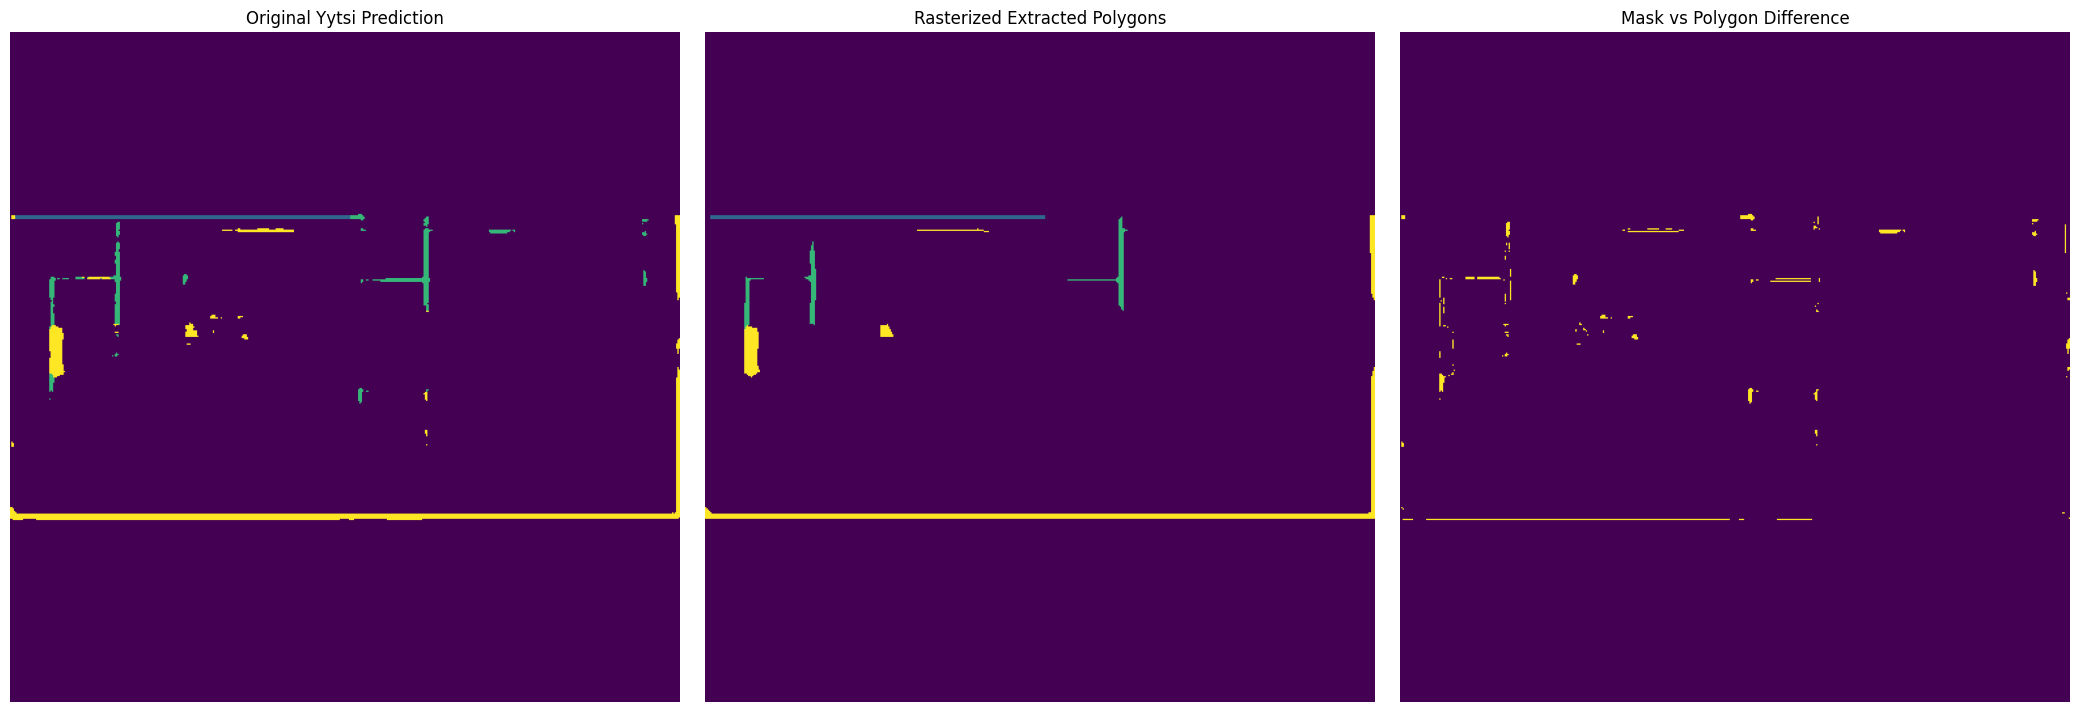

In [48]:
# CELL 36
# Validate the AI -> vector-geometry conversion.
#
# We take the polygons extracted in Cell 35,
# rasterize them back onto the 512x512 grid,
# and compare that rasterized geometry with the
# ORIGINAL Yytsi prediction mask.
#
# If these match well, our polygon representation is
# preserving the AI output correctly.

from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Rasterize the extracted polygons back to 512x512
# ---------------------------------------------------------

polygon_mask = np.zeros_like(
    prediction_512,
    dtype=np.uint8
)

class_ids = {
    "wall": 1,
    "door": 2,
    "window": 3
}

for class_name, class_id in class_ids.items():

    for poly in predicted_polygons_yytsi[class_name]:

        # Draw outer ring
        if len(poly["outer"]) >= 3:

            pts = [
                (
                    int(round(x)),
                    int(round(y))
                )
                for x, y in poly["outer"]
            ]

            ImageDraw.Draw(
                Image.fromarray(polygon_mask)
            )

            # Use a temporary PIL image for safe polygon filling.
            tmp = Image.fromarray(
                polygon_mask.copy()
            )

            draw = ImageDraw.Draw(tmp)

            draw.polygon(
                pts,
                fill=class_id
            )

            # Draw holes as background/floor.
            for hole in poly["holes"]:

                if len(hole) >= 3:

                    hole_pts = [
                        (
                            int(round(x)),
                            int(round(y))
                        )
                        for x, y in hole
                    ]

                    draw.polygon(
                        hole_pts,
                        fill=0
                    )

            polygon_mask = np.asarray(
                tmp,
                dtype=np.uint8
            )

# ---------------------------------------------------------
# 2. Compare original model mask vs polygonized mask
# ---------------------------------------------------------

def iou_for_class(gt_mask, pred_mask):

    intersection = np.logical_and(
        gt_mask,
        pred_mask
    ).sum()

    union = np.logical_or(
        gt_mask,
        pred_mask
    ).sum()

    return (
        intersection / union
        if union > 0
        else 0.0
    )


print("AI MASK → POLYGON FIDELITY")
print("=" * 65)

for class_name, class_id in class_ids.items():

    original = (
        prediction_512 == class_id
    )

    reconstructed = (
        polygon_mask == class_id
    )

    original_pixels = int(
        original.sum()
    )

    reconstructed_pixels = int(
        reconstructed.sum()
    )

    iou = iou_for_class(
        original,
        reconstructed
    )

    print(f"\n{class_name.upper()}")

    print(
        "Original mask pixels     :",
        original_pixels
    )

    print(
        "Polygonized pixels       :",
        reconstructed_pixels
    )

    print(
        "Mask → polygon IoU       :",
        f"{iou:.4f}"
    )

# ---------------------------------------------------------
# 3. Visual comparison
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7)
)

axes[0].imshow(
    prediction_512
)

axes[0].set_title(
    "Original Yytsi Prediction"
)

axes[0].axis("off")

axes[1].imshow(
    polygon_mask
)

axes[1].set_title(
    "Rasterized Extracted Polygons"
)

axes[1].axis("off")

# Highlight differences
difference = (
    prediction_512 != polygon_mask
)

axes[2].imshow(
    difference
)

axes[2].set_title(
    "Mask vs Polygon Difference"
)

axes[2].axis("off")

plt.tight_layout()
plt.show()

In [49]:
# CELL 37
# Inspect the ORIGINAL CubiCasa SVG for dimension / measurement information.
#
# We are NOT changing geometry yet.
# We want to know whether the source floor plan itself contains
# dimensions or scale information we can use.

import xml.etree.ElementTree as ET
from collections import Counter

root = ET.parse(svg_file).getroot()

# Count SVG elements by class/token.
class_counter = Counter()

text_elements = []
dimension_elements = []

def inspect_element(elem):

    classes = (elem.get("class") or "").split()

    for c in classes:
        class_counter[c] += 1

    # Capture elements that may contain measurement text.
    tag = elem.tag.split("}")[-1]

    text_value = (
        elem.text.strip()
        if elem.text and elem.text.strip()
        else ""
    )

    if text_value:
        text_elements.append({
            "tag": tag,
            "class": classes,
            "text": text_value[:200],
            "attrs": dict(elem.attrib)
        })

    if any(
        token.lower() in {
            "dimension",
            "dimensionmark",
            "spacedimensionslabel"
        }
        for token in classes
    ):
        dimension_elements.append({
            "tag": tag,
            "class": classes,
            "text": text_value[:200],
            "attrs": dict(elem.attrib)
        })

    for child in elem:
        inspect_element(child)

inspect_element(root)

print("Important SVG classes found:")
for name, count in class_counter.most_common():
    print(f"{name}: {count}")

print("\nTotal text-bearing elements:", len(text_elements))
print("Total dimension-related elements:", len(dimension_elements))

print("\nDimension-related elements:")
for item in dimension_elements[:30]:
    print("\n---")
    print("tag   :", item["tag"])
    print("class :", item["class"])
    print("text  :", item["text"])
    print("attrs :", item["attrs"])

print("\nSample text-bearing elements:")
for item in text_elements[:30]:
    print("\n---")
    print("tag   :", item["tag"])
    print("class :", item["class"])
    print("text  :", item["text"])

Important SVG classes found:
Wall: 88
DimensionMark: 76
Panel: 45
FixedFurniture: 42
TextLabel: 40
BoundaryPolygon: 40
Window: 29
Regular: 29
Glass: 29
Direction: 28
Name: 28
External: 22
Space: 19
Dimension: 19
Visual: 19
SpaceDimensionsLabel: 19
NameLabel: 19
DimensionMeasureLabel: 19
PanelArea: 16
Door: 15
Beside: 15
Threshold: 15
Swing: 14
Positive: 10
Right: 10
WalkinLine: 10
Steps: 10
ShowerScreen: 10
Railing: 8
Left: 6
Negative: 6
Flight: 6
Closet: 6
ElectricalAppliance: 6
Column: 5
FreeShape: 5
Stairs: 5
electricitySign: 5
Room: 4
Winding: 4
SaunaBench: 4
Bench: 4
Chimney: 4
Pipe: 4
Outdoor: 3
Shower: 3
BaseCabinet: 3
Elevated: 3
Floor: 2
Floorplan: 2
Kitchen: 2
UserDefined: 2
Undefined: 2
Bath: 2
FixedFurnitureSet: 2
Handle: 2
Indicator: 2
Sink: 2
InnerPolygon: 2
OuterDrain: 2
InnerDrain: 2
Faucet: 2
WallCabinet: 2
SelectionControls: 2
rotateControl: 2
ResizeNControl: 2
ResizeNEControl: 2
ResizeEControl: 2
ResizeSEControl: 2
ResizeSControl: 2
ResizeSWControl: 2
ResizeWControl:

In [50]:
# CELL 38
# Inspect the internal structure of a few SVG Dimension groups.
#
# We want to connect:
#   pixel/SVG geometry
#          ↕
#   text such as "3.94 m x 6.10 m"
#
# This is the basis for deriving a real-world metres-per-SVG-unit scale.

import xml.etree.ElementTree as ET

SVG_NS = "{http://www.w3.org/2000/svg}"

root = ET.parse(svg_file).getroot()

dimension_groups = []

def find_dimension_groups(elem):

    classes = (elem.get("class") or "").split()

    if "Dimension" in classes:
        dimension_groups.append(elem)

    for child in elem:
        find_dimension_groups(child)

find_dimension_groups(root)

print(
    "Dimension groups found:",
    len(dimension_groups)
)

# Inspect first 3 only.
for idx, group in enumerate(dimension_groups[:3]):

    print("\n" + "=" * 80)
    print("DIMENSION GROUP", idx)
    print("=" * 80)

    print("Group attributes:")
    print(group.attrib)

    print("\nDescendants:")

    def print_descendants(elem, depth=0):

        tag = elem.tag.split("}")[-1]
        classes = elem.get("class", "")
        text = (
            elem.text.strip()
            if elem.text and elem.text.strip()
            else ""
        )

        attrs = {
            k: v
            for k, v in elem.attrib.items()
            if k not in {"style"}
        }

        print(
            "  " * depth
            + f"<{tag}> "
            + f"class={classes!r} "
            + f"text={text!r}"
        )

        if attrs:
            print(
                "  " * depth
                + f"attrs={attrs}"
            )

        for child in elem:
            print_descendants(
                child,
                depth + 1
            )

    print_descendants(group)

Dimension groups found: 19

DIMENSION GROUP 0
Group attributes:
{'transform': 'matrix(1,0,0,1,1198.7802,1098.6076)', 'class': 'Dimension'}

Descendants:
<g> class='Dimension' text=''
attrs={'transform': 'matrix(1,0,0,1,1198.7802,1098.6076)', 'class': 'Dimension'}
  <g> class='Visual' text=''
  attrs={'transform': 'matrix(1,0,0,1,0,0)', 'class': 'Visual'}
    <g> class='DimensionMark' text=''
    attrs={'id': 'mark1', 'fill': '#000000', 'stroke': 'none', 'transform': 'matrix(1,0,0,1,98.2961,0)', 'class': 'DimensionMark'}
      <polygon> class='' text=''
      attrs={'points': '-5,5,0,0,5,5'}
    <g> class='DimensionMark' text=''
    attrs={'id': 'mark2', 'fill': '#000000', 'stroke': 'none', 'transform': 'matrix(1,0,0,1,196.5922,52.2056)', 'class': 'DimensionMark'}
      <polygon> class='' text=''
      attrs={'points': '-5,-5,0,0,-5,5'}
    <g> class='DimensionMark' text=''
    attrs={'id': 'mark3', 'fill': '#000000', 'stroke': 'none', 'transform': 'matrix(1,0,0,1,98.2961,104.4112)', 'c

In [51]:
# CELL 39
# Derive the real-world scale from the SVG's own dimension objects.
#
# We use:
#   DimensionMark coordinates
#   +
#   metric dimension text such as "3.94 m x 6.10 m"
#
# Then calculate SVG-units-per-metre for each dimension group.

import re
import math
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd

root = ET.parse(svg_file).getroot()

# ---------------------------------------------------------
# Helper: extract translation from SVG matrix(...)
# ---------------------------------------------------------

def get_translation(transform_string):

    if not transform_string:
        return 0.0, 0.0

    match = re.search(
        r"matrix\(\s*[-\d.eE]+\s*,\s*[-\d.eE]+\s*,"
        r"\s*[-\d.eE]+\s*,\s*[-\d.eE]+\s*,"
        r"\s*([-\d.eE]+)\s*,\s*([-\d.eE]+)\s*\)",
        transform_string
    )

    if not match:
        return 0.0, 0.0

    return (
        float(match.group(1)),
        float(match.group(2))
    )


dimension_results = []

for group_idx, group in enumerate(dimension_groups):

    # -----------------------------------------------------
    # 1. Extract metric dimension text
    # -----------------------------------------------------

    metric_texts = []

    for elem in group.iter():

        if elem.tag.split("}")[-1] != "text":
            continue

        text = (
            elem.text.strip()
            if elem.text
            else ""
        )

        if "m" in text:

            metric_texts.append(text)

    if not metric_texts:
        continue

    # Prefer text like:
    # "3.94 m x 6.10 m"
    metric_text = None

    for text in metric_texts:

        if re.search(
            r"(\d+(?:\.\d+)?)\s*m\s*x\s*(\d+(?:\.\d+)?)\s*m",
            text
        ):
            metric_text = text
            break

    if metric_text is None:
        continue

    match = re.search(
        r"(\d+(?:\.\d+)?)\s*m\s*x\s*(\d+(?:\.\d+)?)\s*m",
        metric_text
    )

    if not match:
        continue

    dim_a_m = float(match.group(1))
    dim_b_m = float(match.group(2))

    # -----------------------------------------------------
    # 2. Extract the four DimensionMark positions
    # -----------------------------------------------------

    marks = {}

    for elem in group.iter():

        classes = (
            elem.get("class") or ""
        ).split()

        if "DimensionMark" not in classes:
            continue

        mark_id = elem.get("id")

        if mark_id is None:
            continue

        x, y = get_translation(
            elem.get("transform")
        )

        marks[mark_id] = (
            x,
            y
        )

    if len(marks) < 4:
        continue

    # -----------------------------------------------------
    # 3. Calculate horizontal / vertical dimensions
    #
    # mark1 ↔ mark3 = vertical extent
    # mark2 ↔ mark4 = horizontal extent
    # -----------------------------------------------------

    p1 = np.array(marks["mark1"])
    p2 = np.array(marks["mark2"])
    p3 = np.array(marks["mark3"])
    p4 = np.array(marks["mark4"])

    vertical_svg = np.linalg.norm(
        p1 - p3
    )

    horizontal_svg = np.linalg.norm(
        p2 - p4
    )

    # Determine which metric number corresponds to horizontal.
    # Usually the SVG width corresponds to the first number.
    scale_horizontal = horizontal_svg / dim_a_m
    scale_vertical = vertical_svg / dim_b_m

    # Also calculate the alternate orientation.
    alt_horizontal = horizontal_svg / dim_b_m
    alt_vertical = vertical_svg / dim_a_m

    dimension_results.append({
        "group": group_idx,
        "metric_text": metric_text,
        "horizontal_svg": horizontal_svg,
        "vertical_svg": vertical_svg,
        "metric_a_m": dim_a_m,
        "metric_b_m": dim_b_m,
        "scale_horizontal": scale_horizontal,
        "scale_vertical": scale_vertical,
        "alt_horizontal": alt_horizontal,
        "alt_vertical": alt_vertical
    })

# ---------------------------------------------------------
# 4. Display results
# ---------------------------------------------------------

df_scale = pd.DataFrame(
    dimension_results
)

print(
    "Dimension groups with usable metric labels:",
    len(df_scale)
)

display(
    df_scale[
        [
            "group",
            "metric_text",
            "horizontal_svg",
            "vertical_svg",
            "metric_a_m",
            "metric_b_m",
            "scale_horizontal",
            "scale_vertical"
        ]
    ]
)

# ---------------------------------------------------------
# 5. Estimate the dominant scale
# ---------------------------------------------------------

valid_scales = []

for _, r in df_scale.iterrows():

    if (
        math.isfinite(r["scale_horizontal"])
        and math.isfinite(r["scale_vertical"])
        and r["scale_horizontal"] > 0
        and r["scale_vertical"] > 0
    ):

        valid_scales.append(
            r["scale_horizontal"]
        )

        valid_scales.append(
            r["scale_vertical"]
        )

valid_scales = np.array(
    valid_scales
)

print("\nSCALE SUMMARY")
print("=" * 60)

print(
    "Median SVG units / metre:",
    np.median(valid_scales)
)

print(
    "Mean SVG units / metre:",
    np.mean(valid_scales)
)

print(
    "Std deviation:",
    np.std(valid_scales)
)

print(
    "Minimum:",
    np.min(valid_scales)
)

print(
    "Maximum:",
    np.max(valid_scales)
)

Dimension groups with usable metric labels: 19


,group,metric_text,horizontal_svg,vertical_svg,metric_a_m,metric_b_m,scale_horizontal,scale_vertical
0,0,1.97 m x 1.04 m,196.5922,104.4112,1.97,1.04,99.792995,100.395385
1,1,3.94 m x 6.10 m,394.1324,610.3913,3.94,6.10,100.033604,100.064148
2,2,3.94 m x 3.82 m,394.1324,382.1696,3.94,3.82,100.033604,100.044398
3,3,4.10 m x 6.76 m,410.2255,676.1868,4.10,6.76,100.055000,100.027633
4,4,0.91 m x 0.87 m,90.8781,87.1337,0.91,0.87,99.866044,100.153678
5,5,9.39 m x 1.92 m,939.2026,191.8993,9.39,1.92,100.021576,99.947552
6,6,7.40 m x 5.19 m,740.4364,519.0430,7.40,5.19,100.058973,100.008285
7,7,10.35 m x 2.81 m,1035.2160,280.5508,10.35,2.81,100.020870,99.840142
8,8,3.90 m x 3.16 m,390.2255,316.3741,3.90,3.16,100.057821,100.118386
9,9,2.98 m x 3.05 m,297.6449,304.6825,2.98,3.05,99.880839,99.895902



SCALE SUMMARY
Median SVG units / metre: 100.01457736449694
Mean SVG units / metre: 99.99040342087986
Std deviation: 0.1382426280714221
Minimum: 99.64410852713178
Maximum: 100.3953846153846


Scale:
SVG units / metre : 100.01457736449694
Metres / SVG unit : 0.009998542476018888

Local origin:
X0: 247.52999877929688
Y0: 296.67999267578125

METRIC 2D GEOMETRY

WALL: 1 polygons
  polygon 0: width=2.550 m, height=0.020 m

DOOR: 3 polygons
  polygon 0: width=0.140 m, height=0.390 m
  polygon 1: width=0.080 m, height=0.630 m
  polygon 2: width=0.450 m, height=0.710 m

WINDOW: 5 polygons
  polygon 0: width=5.109 m, height=1.150 m
  polygon 1: width=0.110 m, height=0.390 m
  polygon 2: width=0.090 m, height=0.090 m
  polygon 3: width=0.540 m, height=0.020 m
  polygon 4: width=0.030 m, height=0.640 m

ANNOTATED FLOOR-PLAN EXTENT
---------------------------
Width : 37.094 m
Height: 11.505 m
Approx. bounding area: 426.78 m²


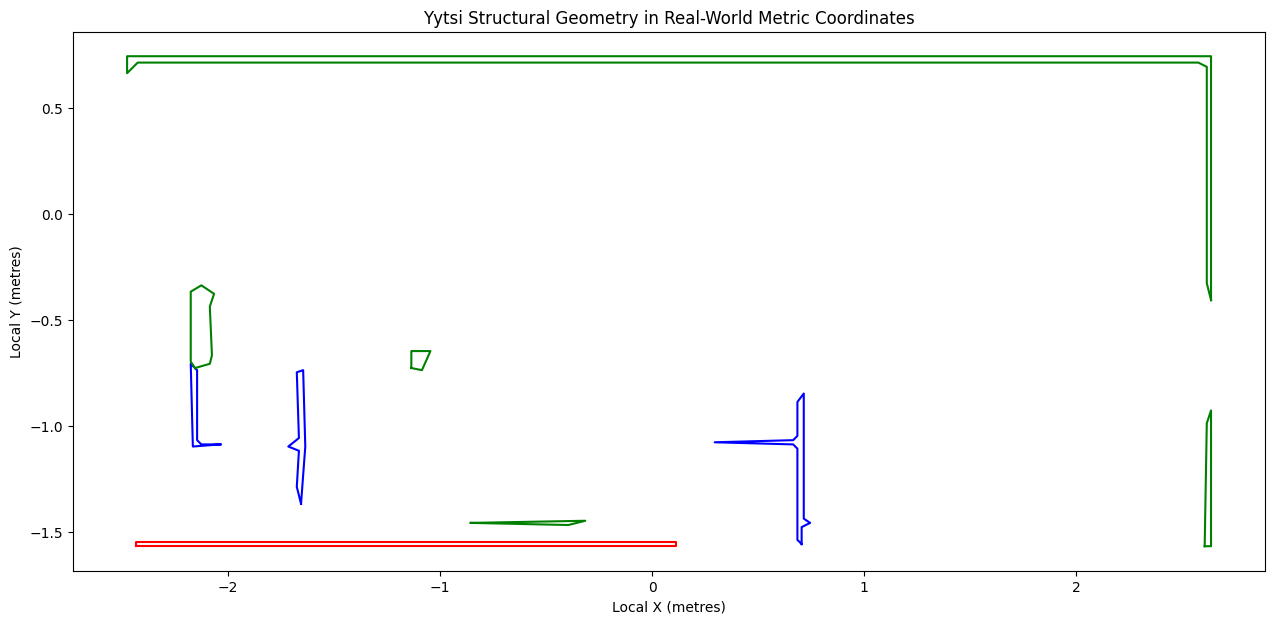

In [52]:
# CELL 40
# Convert Yytsi's extracted polygons:
#
# SVG coordinates
#       ↓
# real-world metres
#
# Scale is derived from the 19 embedded dimension measurements.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Use the robust scale we just measured
# ---------------------------------------------------------

SVG_UNITS_PER_METRE = float(
    np.median(valid_scales)
)

METRES_PER_SVG_UNIT = (
    1.0 / SVG_UNITS_PER_METRE
)

print("Scale:")
print(
    "SVG units / metre :",
    SVG_UNITS_PER_METRE
)

print(
    "Metres / SVG unit :",
    METRES_PER_SVG_UNIT
)

# ---------------------------------------------------------
# 2. Use the annotated floor-plan extent as the local
#    coordinate origin.
#
# This does NOT georeference the floor plan.
# It only gives us a clean local metric coordinate system.
# ---------------------------------------------------------

X0 = min_x
Y0 = min_y

print("\nLocal origin:")
print("X0:", X0)
print("Y0:", Y0)

# ---------------------------------------------------------
# 3. Convert predicted polygons to metres
# ---------------------------------------------------------

metric_polygons = []

for class_name, polygons in predicted_polygons_yytsi.items():

    for polygon_index, poly in enumerate(polygons):

        metric_outer = []

        for x_svg, y_svg in poly["outer"]:

            x_m = (
                (x_svg - X0)
                * METRES_PER_SVG_UNIT
            )

            y_m = (
                (y_svg - Y0)
                * METRES_PER_SVG_UNIT
            )

            metric_outer.append(
                (x_m, y_m)
            )

        metric_holes = []

        for hole in poly["holes"]:

            metric_hole = []

            for x_svg, y_svg in hole:

                x_m = (
                    (x_svg - X0)
                    * METRES_PER_SVG_UNIT
                )

                y_m = (
                    (y_svg - Y0)
                    * METRES_PER_SVG_UNIT
                )

                metric_hole.append(
                    (x_m, y_m)
                )

            metric_holes.append(
                metric_hole
            )

        metric_polygons.append({
            "class": class_name,
            "index": polygon_index,
            "outer_m": metric_outer,
            "holes_m": metric_holes,
            "area_px": poly["area_px"]
        })

# ---------------------------------------------------------
# 4. Print metric geometry summary
# ---------------------------------------------------------

print("\nMETRIC 2D GEOMETRY")
print("=" * 65)

for class_name in [
    "wall",
    "door",
    "window"
]:

    items = [
        p
        for p in metric_polygons
        if p["class"] == class_name
    ]

    print(
        f"\n{class_name.upper()}:",
        len(items),
        "polygons"
    )

    for item in items[:10]:

        xs = [
            p[0]
            for p in item["outer_m"
            ]
        ]

        ys = [
            p[1]
            for p in item["outer_m"]
        ]

        print(
            f"  polygon {item['index']}: "
            f"width={max(xs)-min(xs):.3f} m, "
            f"height={max(ys)-min(ys):.3f} m"
        )

# ---------------------------------------------------------
# 5. Compute the full annotated floor-plan extent in metres
# ---------------------------------------------------------

floor_width_m = (
    (max_x - min_x)
    * METRES_PER_SVG_UNIT
)

floor_height_m = (
    (max_y - min_y)
    * METRES_PER_SVG_UNIT
)

print("\nANNOTATED FLOOR-PLAN EXTENT")
print("---------------------------")
print(
    "Width :",
    round(floor_width_m, 3),
    "m"
)

print(
    "Height:",
    round(floor_height_m, 3),
    "m"
)

print(
    "Approx. bounding area:",
    round(
        floor_width_m * floor_height_m,
        2
    ),
    "m²"
)

# ---------------------------------------------------------
# 6. Visualize the converted metric polygons
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 7)
)

for poly in metric_polygons:

    colour = {
        "wall": "red",
        "door": "blue",
        "window": "green"
    }[poly["class"]]

    pts = poly["outer_m"]

    xs = [
        p[0]
        for p in pts
    ]

    ys = [
        p[1]
        for p in pts
    ]

    ax.plot(
        xs + [xs[0]],
        ys + [ys[0]],
        color=colour,
        linewidth=1.5
    )

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(
    "Local X (metres)"
)

ax.set_ylabel(
    "Local Y (metres)"
)

ax.set_title(
    "Yytsi Structural Geometry in Real-World Metric Coordinates"
)

plt.show()

F1 image: (785, 355)
F2 image: (785, 355)

Floor groups found:
['Floor-1', 'Floor-2']

Floor-1
Room              : 4
Wall              : 52
Door              : 13
Window            : 15
Dimension         : 14
Space             : 14
BoundaryPolygon   : 38

Floor-2
Wall              : 36
Door              : 2
Window            : 14
Dimension         : 5
Space             : 5
BoundaryPolygon   : 2


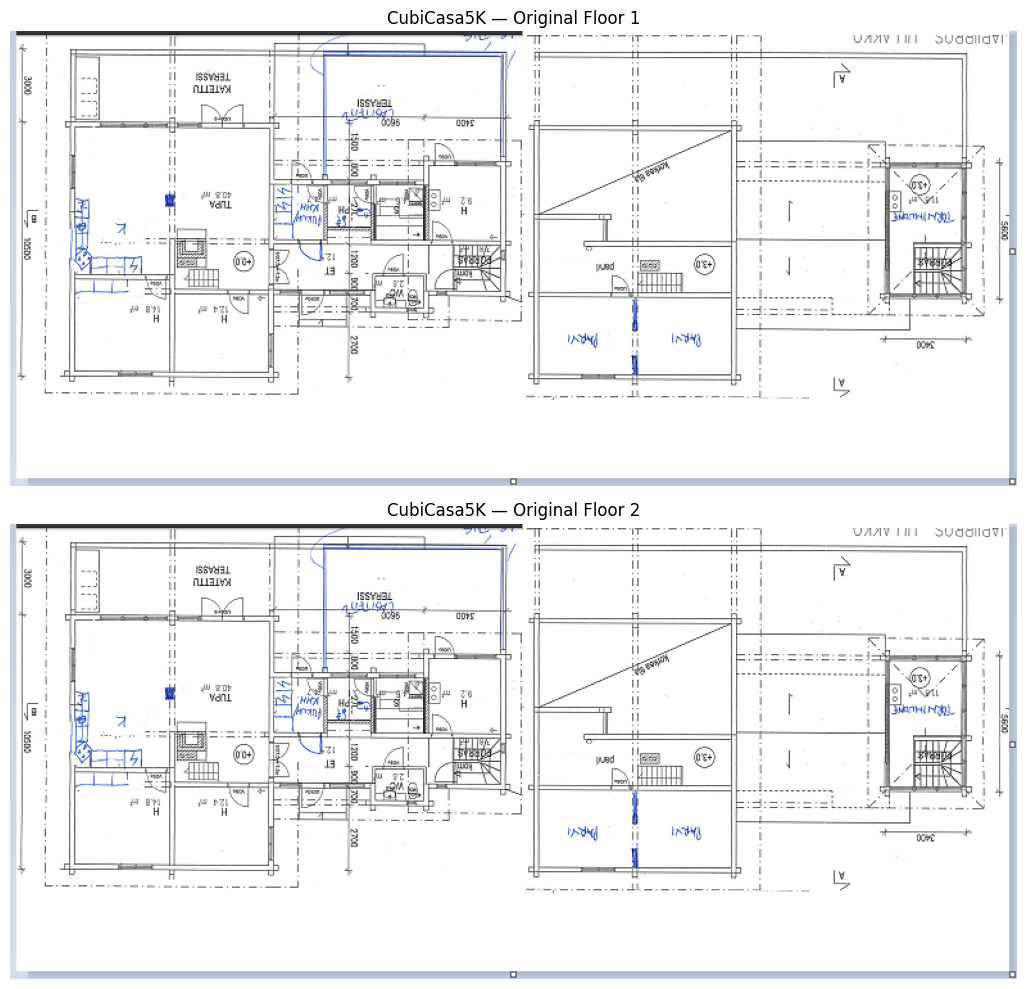

In [53]:
# CELL 41
# Inspect the ORIGINAL CubiCasa model.svg for its floor structure.
#
# We already know the SVG contains Floor-1 and Floor-2.
# Now we inspect those groups and display their original floor images.

from remotezip import RemoteZip
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

# ---------------------------------------------------------
# 1. Download the two original floor images only
# ---------------------------------------------------------

F1_PATH = "cubicasa5k/high_quality_architectural/6652/F1_original.png"
F2_PATH = "cubicasa5k/high_quality_architectural/6652/F2_original.png"

with RemoteZip(
    zip_url,
    timeout=120
) as z:

    f1_bytes = z.read(F1_PATH)
    f2_bytes = z.read(F2_PATH)

f1_image = Image.open(
    BytesIO(f1_bytes)
).convert("RGB")

f2_image = Image.open(
    BytesIO(f2_bytes)
).convert("RGB")

print("F1 image:", f1_image.size)
print("F2 image:", f2_image.size)

# ---------------------------------------------------------
# 2. Find Floor-1 / Floor-2 groups in the SVG
# ---------------------------------------------------------

root = ET.parse(svg_file).getroot()

floor_groups = {}

def search_floors(elem):

    classes = (
        elem.get("class") or ""
    ).split()

    element_id = elem.get("id")

    for floor_name in [
        "Floor-1",
        "Floor-2"
    ]:

        if (
            floor_name in classes
            or element_id == floor_name
        ):
            floor_groups[floor_name] = elem

    for child in elem:
        search_floors(child)

search_floors(root)

print("\nFloor groups found:")
print(
    list(floor_groups.keys())
)

# ---------------------------------------------------------
# 3. Count important structural elements per floor
# ---------------------------------------------------------

for floor_name, group in floor_groups.items():

    counts = {}

    for elem in group.iter():

        for class_name in (
            elem.get("class") or ""
        ).split():

            counts[class_name] = (
                counts.get(class_name, 0) + 1
            )

    print("\n" + "=" * 60)
    print(floor_name)
    print("=" * 60)

    for key in [
        "Room",
        "Wall",
        "Door",
        "Window",
        "Dimension",
        "Space",
        "BoundaryPolygon"
    ]:

        if key in counts:
            print(
                f"{key:18s}:",
                counts[key]
            )

# ---------------------------------------------------------
# 4. Show the two actual floor images
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10)
)

axes[0].imshow(f1_image)
axes[0].set_title(
    "CubiCasa5K — Original Floor 1"
)
axes[0].axis("off")

axes[1].imshow(f2_image)
axes[1].set_title(
    "CubiCasa5K — Original Floor 2"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [54]:
# CELL 42
# Compare the 2D spatial extent of Floor-1 and Floor-2
# from the ORIGINAL CubiCasa SVG.
#
# This is still purely 2D.
# We are NOT creating 3D yet.

import re
import math
import xml.etree.ElementTree as ET
import numpy as np

root = ET.parse(svg_file).getroot()

SVG_NS = "{http://www.w3.org/2000/svg}"

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------

def parse_matrix(transform):
    """
    Parse a simple SVG matrix(a,b,c,d,e,f).
    """
    if not transform:
        return np.eye(3)

    m = re.match(
        r"matrix\(\s*"
        r"([-\d.eE]+),\s*"
        r"([-\d.eE]+),\s*"
        r"([-\d.eE]+),\s*"
        r"([-\d.eE]+),\s*"
        r"([-\d.eE]+),\s*"
        r"([-\d.eE]+)"
        r"\s*\)",
        transform
    )

    if not m:
        return np.eye(3)

    a, b, c, d, e, f = map(
        float,
        m.groups()
    )

    return np.array([
        [a, c, e],
        [b, d, f],
        [0, 0, 1]
    ])


def get_local_points(elem):

    tag = elem.tag.split("}")[-1]

    if tag == "polygon":

        raw = (
            elem.get("points") or ""
        ).replace(",", " ").split()

        nums = [
            float(x)
            for x in raw
        ]

        return list(
            zip(
                nums[0::2],
                nums[1::2]
            )
        )

    if tag == "rect":

        x = float(
            elem.get("x", 0)
        )

        y = float(
            elem.get("y", 0)
        )

        w = float(
            elem.get("width", 0)
        )

        h = float(
            elem.get("height", 0)
        )

        return [
            (x, y),
            (x + w, y),
            (x + w, y + h),
            (x, y + h)
        ]

    return []


def transform_points(points, matrix):

    if not points:
        return []

    out = []

    for x, y in points:

        p = np.array([
            x,
            y,
            1.0
        ])

        q = matrix @ p

        out.append(
            (
                q[0],
                q[1]
            )
        )

    return out


# ---------------------------------------------------------
# Find the two actual floor groups
# ---------------------------------------------------------

floor_groups = {}

def find_floor_groups(elem):

    classes = (
        elem.get("class") or ""
    ).split()

    element_id = elem.get("id")

    for name in [
        "Floor-1",
        "Floor-2"
    ]:

        if (
            name in classes
            or element_id == name
        ):
            floor_groups[name] = elem

    for child in elem:
        find_floor_groups(child)


find_floor_groups(root)

print(
    "Floor groups:",
    list(floor_groups.keys())
)


# ---------------------------------------------------------
# Compute transformed geometric bounds for each floor
# ---------------------------------------------------------

floor_results = {}

for floor_name, floor_group in floor_groups.items():

    all_points = []

    def walk(elem, parent_matrix):

        local_matrix = parse_matrix(
            elem.get("transform")
        )

        current_matrix = (
            parent_matrix @ local_matrix
        )

        points = get_local_points(elem)

        if points:

            transformed = transform_points(
                points,
                current_matrix
            )

            all_points.extend(
                transformed
            )

        for child in elem:
            walk(
                child,
                current_matrix
            )

    walk(
        floor_group,
        np.eye(3)
    )

    if not all_points:

        print(
            f"\n{floor_name}: no geometric points found"
        )

        continue

    xs = [
        p[0]
        for p in all_points
    ]

    ys = [
        p[1]
        for p in all_points
    ]

    min_x_floor = min(xs)
    max_x_floor = max(xs)

    min_y_floor = min(ys)
    max_y_floor = max(ys)

    width_svg = (
        max_x_floor
        - min_x_floor
    )

    height_svg = (
        max_y_floor
        - min_y_floor
    )

    width_m = (
        width_svg
        * METRES_PER_SVG_UNIT
    )

    height_m = (
        height_svg
        * METRES_PER_SVG_UNIT
    )

    floor_results[floor_name] = {
        "min_x_svg": min_x_floor,
        "max_x_svg": max_x_floor,
        "min_y_svg": min_y_floor,
        "max_y_svg": max_y_floor,
        "width_svg": width_svg,
        "height_svg": height_svg,
        "width_m": width_m,
        "height_m": height_m
    }

    print("\n" + "=" * 65)
    print(floor_name)

    print(
        "SVG width :",
        round(width_svg, 2)
    )

    print(
        "SVG height:",
        round(height_svg, 2)
    )

    print(
        "Metric width :",
        round(width_m, 3),
        "m"
    )

    print(
        "Metric height:",
        round(height_m, 3),
        "m"
    )


# ---------------------------------------------------------
# Compare the two floor extents
# ---------------------------------------------------------

if (
    "Floor-1" in floor_results
    and "Floor-2" in floor_results
):

    f1 = floor_results["Floor-1"]
    f2 = floor_results["Floor-2"]

    print("\n" + "=" * 65)
    print("FLOOR 1 vs FLOOR 2")
    print("=" * 65)

    print(
        "Floor 1 width :",
        round(f1["width_m"], 3),
        "m"
    )

    print(
        "Floor 2 width :",
        round(f2["width_m"], 3),
        "m"
    )

    print(
        "Floor 1 height:",
        round(f1["height_m"], 3),
        "m"
    )

    print(
        "Floor 2 height:",
        round(f2["height_m"], 3),
        "m"
    )

    print("\nExtent difference:")
    print(
        "Width difference :",
        round(
            abs(
                f1["width_m"]
                - f2["width_m"]
            ),
            3
        ),
        "m"
    )

    print(
        "Height difference:",
        round(
            abs(
                f1["height_m"]
                - f2["height_m"]
            ),
            3
        ),
        "m"
    )

Floor groups: ['Floor-1', 'Floor-2']

Floor-1
SVG width : 2072.94
SVG height: 1454.09
Metric width : 20.726 m
Metric height: 14.539 m

Floor-2
SVG width : 3980.21
SVG height: 1466.76
Metric width : 39.796 m
Metric height: 14.665 m

FLOOR 1 vs FLOOR 2
Floor 1 width : 20.726 m
Floor 2 width : 39.796 m
Floor 1 height: 14.539 m
Floor 2 height: 14.665 m

Extent difference:
Width difference : 19.07 m
Height difference: 0.127 m


In [55]:
# CELL 43
# Compare the STRUCTURAL extents of Floor 1 vs Floor 2.
#
# We intentionally ignore:
#   Dimension
#   TextLabel
#   furniture
#   doors/windows
#
# We look at:
#   Wall
#   BoundaryPolygon
#
# This is a better approximation of the actual floor footprint.

import numpy as np
import xml.etree.ElementTree as ET

root = ET.parse(svg_file).getroot()


def extract_structural_points(
    floor_group,
    allowed_classes=("Wall", "BoundaryPolygon")
):
    """
    Extract transformed polygon/rect geometry belonging to
    structural classes only.
    """

    points = []

    def walk(elem, parent_matrix):

        local_matrix = parse_matrix(
            elem.get("transform")
        )

        current_matrix = (
            parent_matrix @ local_matrix
        )

        classes = (
            elem.get("class") or ""
        ).split()

        is_structural = any(
            c in classes
            for c in allowed_classes
        )

        tag = elem.tag.split("}")[-1]

        if is_structural:

            local_points = get_local_points(elem)

            if local_points:

                transformed = transform_points(
                    local_points,
                    current_matrix
                )

                points.extend(
                    transformed
                )

        for child in elem:

            walk(
                child,
                current_matrix
            )

    walk(
        floor_group,
        np.eye(3)
    )

    return points


structural_results = {}

for floor_name, floor_group in floor_groups.items():

    points = extract_structural_points(
        floor_group
    )

    if not points:

        print(
            f"{floor_name}: no structural geometry found"
        )

        continue

    xs = [
        p[0]
        for p in points
    ]

    ys = [
        p[1]
        for p in points
    ]

    min_x = min(xs)
    max_x = max(xs)
    min_y = min(ys)
    max_y = max(ys)

    width_svg = max_x - min_x
    height_svg = max_y - min_y

    width_m = (
        width_svg
        * METRES_PER_SVG_UNIT
    )

    height_m = (
        height_svg
        * METRES_PER_SVG_UNIT
    )

    structural_results[floor_name] = {
        "min_x": min_x,
        "max_x": max_x,
        "min_y": min_y,
        "max_y": max_y,
        "width_svg": width_svg,
        "height_svg": height_svg,
        "width_m": width_m,
        "height_m": height_m,
        "point_count": len(points)
    }

    print("\n" + "=" * 65)
    print(f"{floor_name} — STRUCTURAL EXTENT")
    print("=" * 65)

    print(
        "Structural points:",
        len(points)
    )

    print(
        "Width :",
        round(width_m, 3),
        "m"
    )

    print(
        "Height:",
        round(height_m, 3),
        "m"
    )

# ---------------------------------------------------------
# Compare the structural extents
# ---------------------------------------------------------

if (
    "Floor-1" in structural_results
    and "Floor-2" in structural_results
):

    f1 = structural_results["Floor-1"]
    f2 = structural_results["Floor-2"]

    print("\n" + "=" * 65)
    print("STRUCTURAL FLOOR COMPARISON")
    print("=" * 65)

    print(
        "Floor 1:",
        round(f1["width_m"], 3),
        "×",
        round(f1["height_m"], 3),
        "m"
    )

    print(
        "Floor 2:",
        round(f2["width_m"], 3),
        "×",
        round(f2["height_m"], 3),
        "m"
    )

    print(
        "\nWidth difference:",
        round(
            abs(
                f1["width_m"]
                - f2["width_m"]
            ),
            3
        ),
        "m"
    )

    print(
        "Height difference:",
        round(
            abs(
                f1["height_m"]
                - f2["height_m"]
            ),
            3
        ),
        "m"
    )

Floor-1: no structural geometry found
Floor-2: no structural geometry found


In [56]:
# CELL 43 — corrected structural extent extraction
#
# Uses the ACTUAL SVG structure we just inspected:
#
#   Wall group
#      └── polygon
#
# We deliberately avoid recursively treating Window/Panel/etc.
# inside a Wall group as wall geometry.

import numpy as np
import xml.etree.ElementTree as ET

root = ET.parse(svg_file).getroot()


GEOMETRY_TAGS = {
    "polygon",
    "rect",
    "path"
}


def extract_direct_structural_geometry(
    floor_group,
    structural_classes=("Wall", "BoundaryPolygon")
):

    points = []

    def walk(elem, parent_matrix):

        local_matrix = parse_matrix(
            elem.get("transform")
        )

        current_matrix = (
            parent_matrix @ local_matrix
        )

        classes = (
            elem.get("class") or ""
        ).split()

        is_structural_group = any(
            c in classes
            for c in structural_classes
        )

        tag = elem.tag.split("}")[-1]

        # -------------------------------------------------
        # If this is a structural group, collect only
        # its DIRECT geometry children.
        #
        # This prevents:
        # Wall
        #   └── Window
        #        └── polygon
        #
        # from accidentally becoming wall geometry.
        # -------------------------------------------------

        if is_structural_group:

            for child in elem:

                child_tag = (
                    child.tag.split("}")[-1]
                )

                if child_tag not in GEOMETRY_TAGS:
                    continue

                child_points = (
                    get_local_points(child)
                )

                if child_points:

                    child_matrix = (
                        current_matrix
                        @ parse_matrix(
                            child.get("transform")
                        )
                    )

                    transformed = (
                        transform_points(
                            child_points,
                            child_matrix
                        )
                    )

                    points.extend(
                        transformed
                    )

            # IMPORTANT:
            # Do not recursively descend into this structural
            # group after collecting its direct geometry.
            return

        # -------------------------------------------------
        # Continue searching for structural groups.
        # -------------------------------------------------

        for child in elem:

            walk(
                child,
                current_matrix
            )

    walk(
        floor_group,
        np.eye(3)
    )

    return points


structural_results = {}

for floor_name, floor_group in floor_groups.items():

    points = extract_direct_structural_geometry(
        floor_group
    )

    print("\n" + "=" * 70)
    print(f"{floor_name} — STRUCTURAL GEOMETRY")
    print("=" * 70)

    print(
        "Structural points found:",
        len(points)
    )

    if not points:

        print(
            "No structural geometry found."
        )
        continue

    xs = [
        p[0]
        for p in points
    ]

    ys = [
        p[1]
        for p in points
    ]

    min_x = min(xs)
    max_x = max(xs)
    min_y = min(ys)
    max_y = max(ys)

    width_svg = (
        max_x - min_x
    )

    height_svg = (
        max_y - min_y
    )

    width_m = (
        width_svg
        * METRES_PER_SVG_UNIT
    )

    height_m = (
        height_svg
        * METRES_PER_SVG_UNIT
    )

    structural_results[floor_name] = {
        "min_x": min_x,
        "max_x": max_x,
        "min_y": min_y,
        "max_y": max_y,
        "width_svg": width_svg,
        "height_svg": height_svg,
        "width_m": width_m,
        "height_m": height_m
    }

    print(
        "SVG width :",
        round(width_svg, 3)
    )

    print(
        "SVG height:",
        round(height_svg, 3)
    )

    print(
        "Metric width :",
        round(width_m, 3),
        "m"
    )

    print(
        "Metric height:",
        round(height_m, 3),
        "m"
    )


# ---------------------------------------------------------
# Compare floors
# ---------------------------------------------------------

if (
    "Floor-1" in structural_results
    and "Floor-2" in structural_results
):

    f1 = structural_results["Floor-1"]
    f2 = structural_results["Floor-2"]

    print("\n" + "=" * 70)
    print("FLOOR 1 vs FLOOR 2 — STRUCTURAL EXTENTS")
    print("=" * 70)

    print(
        "Floor 1:",
        round(f1["width_m"], 3),
        "×",
        round(f1["height_m"], 3),
        "m"
    )

    print(
        "Floor 2:",
        round(f2["width_m"], 3),
        "×",
        round(f2["height_m"], 3),
        "m"
    )

    print(
        "\nWidth difference:",
        round(
            abs(
                f1["width_m"]
                - f2["width_m"]
            ),
            3
        ),
        "m"
    )

    print(
        "Height difference:",
        round(
            abs(
                f1["height_m"]
                - f2["height_m"]
            ),
            3
        ),
        "m"
    )


Floor-1 — STRUCTURAL GEOMETRY
Structural points found: 390
SVG width : 1848.76
SVG height: 1352.22
Metric width : 18.485 m
Metric height: 13.52 m

Floor-2 — STRUCTURAL GEOMETRY
Structural points found: 152
SVG width : 1832.81
SVG height: 1092.49
Metric width : 18.325 m
Metric height: 10.923 m

FLOOR 1 vs FLOOR 2 — STRUCTURAL EXTENTS
Floor 1: 18.485 × 13.52 m
Floor 2: 18.325 × 10.923 m

Width difference: 0.159 m
Height difference: 2.597 m


Floor 1 wall polygons: 52
Floor 2 wall polygons: 36


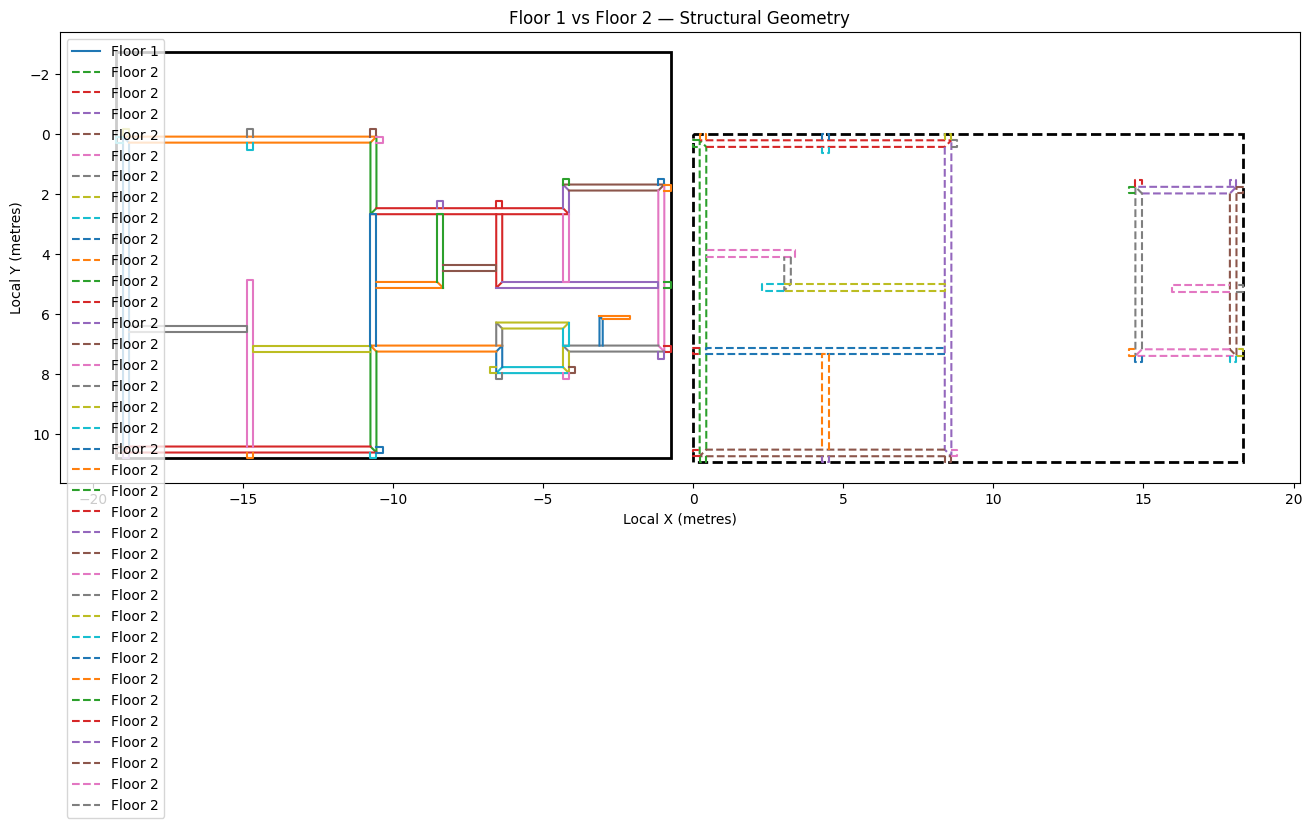

In [57]:
# CELL 44
# Visualize the actual structural wall geometry of Floor 1 and Floor 2
# in the SAME SVG coordinate system.
#
# Still 100% 2D. No 3D generation yet.

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

def extract_wall_polygons(floor_group):
    """
    Extract only direct polygon geometry belonging to Wall groups.
    """
    polygons = []

    def walk(elem, parent_matrix):

        local_matrix = parse_matrix(
            elem.get("transform")
        )

        current_matrix = (
            parent_matrix @ local_matrix
        )

        classes = (
            elem.get("class") or ""
        ).split()

        if "Wall" in classes:

            # Only direct geometry children of Wall.
            for child in elem:

                child_tag = (
                    child.tag.split("}")[-1]
                )

                if child_tag not in {
                    "polygon",
                    "rect",
                    "path"
                }:
                    continue

                pts = get_local_points(child)

                if pts:

                    child_matrix = (
                        current_matrix
                        @ parse_matrix(
                            child.get("transform")
                        )
                    )

                    transformed = transform_points(
                        pts,
                        child_matrix
                    )

                    polygons.append(
                        transformed
                    )

            return

        for child in elem:
            walk(
                child,
                current_matrix
            )

    walk(
        floor_group,
        np.eye(3)
    )

    return polygons


floor1_walls = extract_wall_polygons(
    floor_groups["Floor-1"]
)

floor2_walls = extract_wall_polygons(
    floor_groups["Floor-2"]
)

print("Floor 1 wall polygons:", len(floor1_walls))
print("Floor 2 wall polygons:", len(floor2_walls))


# ---------------------------------------------------------
# Convert SVG coordinates to metres using our verified scale
# ---------------------------------------------------------

def svg_to_metric(points):
    return [
        (
            (x - min_x) * METRES_PER_SVG_UNIT,
            (y - min_y) * METRES_PER_SVG_UNIT
        )
        for x, y in points
    ]


floor1_metric = [
    svg_to_metric(p)
    for p in floor1_walls
]

floor2_metric = [
    svg_to_metric(p)
    for p in floor2_walls
]


# ---------------------------------------------------------
# Plot both floors together
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 10)
)

# Floor 1
for poly in floor1_metric:

    if len(poly) < 2:
        continue

    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]

    ax.plot(
        xs,
        ys,
        linewidth=1.5,
        label="Floor 1"
        if not any(
            line.get_label() == "Floor 1"
            for line in ax.lines
        )
        else None
    )

# Floor 2
for poly in floor2_metric:

    if len(poly) < 2:
        continue

    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]

    ax.plot(
        xs,
        ys,
        linewidth=1.5,
        linestyle="--",
        label="Floor 2"
    )

# ---------------------------------------------------------
# Bounding boxes
# ---------------------------------------------------------

f1 = structural_results["Floor-1"]
f2 = structural_results["Floor-2"]

f1_x0 = (f1["min_x"] - min_x) * METRES_PER_SVG_UNIT
f1_x1 = (f1["max_x"] - min_x) * METRES_PER_SVG_UNIT
f1_y0 = (f1["min_y"] - min_y) * METRES_PER_SVG_UNIT
f1_y1 = (f1["max_y"] - min_y) * METRES_PER_SVG_UNIT

f2_x0 = (f2["min_x"] - min_x) * METRES_PER_SVG_UNIT
f2_x1 = (f2["max_x"] - min_x) * METRES_PER_SVG_UNIT
f2_y0 = (f2["min_y"] - min_y) * METRES_PER_SVG_UNIT
f2_y1 = (f2["max_y"] - min_y) * METRES_PER_SVG_UNIT

ax.add_patch(
    Rectangle(
        (f1_x0, f1_y0),
        f1_x1 - f1_x0,
        f1_y1 - f1_y0,
        fill=False,
        linewidth=2
    )
)

ax.add_patch(
    Rectangle(
        (f2_x0, f2_y0),
        f2_x1 - f2_x0,
        f2_y1 - f2_y0,
        fill=False,
        linewidth=2,
        linestyle="--"
    )
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel("Local X (metres)")
ax.set_ylabel("Local Y (metres)")

ax.set_title(
    "Floor 1 vs Floor 2 — Structural Geometry"
)

ax.legend()

ax.invert_yaxis()

plt.show()

Valid Floor 1 polygons: 52
Valid Floor 2 polygons: 36

STRUCTURAL BOUNDS
Floor 1: -19.229, -0.157 → -0.744, 10.797
Floor 2: 0.000, 0.000 → 18.325, 10.923

FOOTPRINT DIMENSIONS
Floor 1 : 18.485 × 10.954 m
Floor 2 : 18.325 × 10.923 m

FLOOR 2 EDGE OFFSETS RELATIVE TO FLOOR 1
Left   setback : 19.229 m
Right  setback : -19.070 m
Top    setback : -0.127 m
Bottom setback : 0.157 m

BOUNDING-BOX OVERLAP
Overlap width  : 0.000 m
Overlap height : 0.000 m
Overlap area   : 0.000 m²

ACTUAL STRUCTURAL GEOMETRY OVERLAP
Floor 1 structural area : 20.564 m²
Floor 2 structural area : 17.924 m²
Intersection area       : 0.000 m²
Intersection / Floor 1 : 0.00%
Intersection / Floor 2 : 0.00%


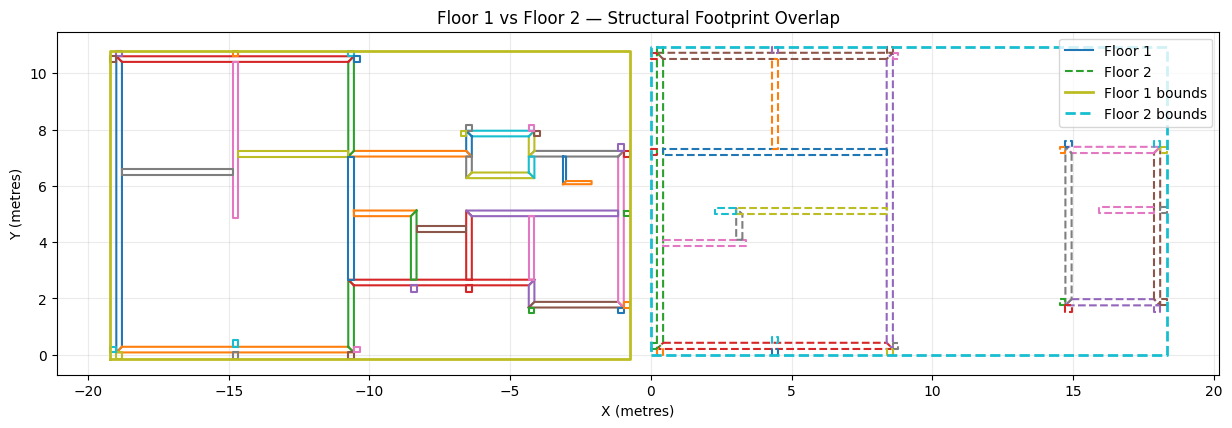

In [58]:
# ============================================================
# FLOOR 1 vs FLOOR 2 — FOOTPRINT OVERLAP + SETBACK ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import unary_union

# ------------------------------------------------------------
# 1. Convert extracted wall polygons into Shapely polygons
# ------------------------------------------------------------

def make_valid_polygons(metric_polygons):
    polys = []

    for pts in metric_polygons:
        if len(pts) < 3:
            continue

        poly = Polygon(pts)

        if not poly.is_valid:
            poly = poly.buffer(0)

        if not poly.is_empty and poly.area > 0:
            polys.append(poly)

    return polys


floor1_polys = make_valid_polygons(floor1_metric)
floor2_polys = make_valid_polygons(floor2_metric)

print("Valid Floor 1 polygons:", len(floor1_polys))
print("Valid Floor 2 polygons:", len(floor2_polys))


# ------------------------------------------------------------
# 2. Build structural envelopes
#
# We use the union of the wall geometry and then its bounding
# envelope for a stable footprint comparison.
# ------------------------------------------------------------

floor1_union = unary_union(floor1_polys)
floor2_union = unary_union(floor2_polys)

f1_minx, f1_miny, f1_maxx, f1_maxy = floor1_union.bounds
f2_minx, f2_miny, f2_maxx, f2_maxy = floor2_union.bounds

print("\n" + "=" * 70)
print("STRUCTURAL BOUNDS")
print("=" * 70)

print(
    f"Floor 1: "
    f"{f1_minx:.3f}, {f1_miny:.3f} → "
    f"{f1_maxx:.3f}, {f1_maxy:.3f}"
)

print(
    f"Floor 2: "
    f"{f2_minx:.3f}, {f2_miny:.3f} → "
    f"{f2_maxx:.3f}, {f2_maxy:.3f}"
)


# ------------------------------------------------------------
# 3. Bounding-box dimensions
# ------------------------------------------------------------

f1_width  = f1_maxx - f1_minx
f1_height = f1_maxy - f1_miny

f2_width  = f2_maxx - f2_minx
f2_height = f2_maxy - f2_miny

print("\n" + "=" * 70)
print("FOOTPRINT DIMENSIONS")
print("=" * 70)

print(f"Floor 1 : {f1_width:.3f} × {f1_height:.3f} m")
print(f"Floor 2 : {f2_width:.3f} × {f2_height:.3f} m")


# ------------------------------------------------------------
# 4. Calculate raw edge offsets
#
# Positive means Floor 2 is inside Floor 1 on that side.
# Negative means Floor 2 extends beyond Floor 1.
# ------------------------------------------------------------

left_setback   = f2_minx - f1_minx
right_setback  = f1_maxx - f2_maxx

bottom_setback = f2_miny - f1_miny
top_setback    = f1_maxy - f2_maxy

print("\n" + "=" * 70)
print("FLOOR 2 EDGE OFFSETS RELATIVE TO FLOOR 1")
print("=" * 70)

print(f"Left   setback : {left_setback:.3f} m")
print(f"Right  setback : {right_setback:.3f} m")
print(f"Top    setback : {top_setback:.3f} m")
print(f"Bottom setback : {bottom_setback:.3f} m")


# ------------------------------------------------------------
# 5. Bounding-box overlap
# ------------------------------------------------------------

overlap_minx = max(f1_minx, f2_minx)
overlap_maxx = min(f1_maxx, f2_maxx)

overlap_miny = max(f1_miny, f2_miny)
overlap_maxy = min(f1_maxy, f2_maxy)

if overlap_maxx > overlap_minx and overlap_maxy > overlap_miny:

    overlap_width = overlap_maxx - overlap_minx
    overlap_height = overlap_maxy - overlap_miny
    overlap_area = overlap_width * overlap_height

else:

    overlap_width = 0
    overlap_height = 0
    overlap_area = 0


print("\n" + "=" * 70)
print("BOUNDING-BOX OVERLAP")
print("=" * 70)

print(f"Overlap width  : {overlap_width:.3f} m")
print(f"Overlap height : {overlap_height:.3f} m")
print(f"Overlap area   : {overlap_area:.3f} m²")


# ------------------------------------------------------------
# 6. Actual polygon-union overlap
#
# This is more meaningful than just bounding-box overlap.
# ------------------------------------------------------------

actual_intersection = floor1_union.intersection(
    floor2_union
)

intersection_area = actual_intersection.area

floor1_area = floor1_union.area
floor2_area = floor2_union.area

if floor1_area > 0:
    overlap_vs_floor1 = (
        intersection_area / floor1_area
    )
else:
    overlap_vs_floor1 = 0

if floor2_area > 0:
    overlap_vs_floor2 = (
        intersection_area / floor2_area
    )
else:
    overlap_vs_floor2 = 0


print("\n" + "=" * 70)
print("ACTUAL STRUCTURAL GEOMETRY OVERLAP")
print("=" * 70)

print(f"Floor 1 structural area : {floor1_area:.3f} m²")
print(f"Floor 2 structural area : {floor2_area:.3f} m²")
print(f"Intersection area       : {intersection_area:.3f} m²")

print(
    f"Intersection / Floor 1 : "
    f"{overlap_vs_floor1 * 100:.2f}%"
)

print(
    f"Intersection / Floor 2 : "
    f"{overlap_vs_floor2 * 100:.2f}%"
)


# ------------------------------------------------------------
# 7. Plot everything together
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 10))

# Floor 1 structural polygons
for poly in floor1_polys:

    x, y = poly.exterior.xy

    ax.plot(
        x,
        y,
        linewidth=1.5,
        label="Floor 1"
        if "Floor 1" not in ax.get_legend_handles_labels()[1]
        else None
    )


# Floor 2 structural polygons
for poly in floor2_polys:

    x, y = poly.exterior.xy

    ax.plot(
        x,
        y,
        linestyle="--",
        linewidth=1.5,
        label="Floor 2"
        if "Floor 2" not in ax.get_legend_handles_labels()[1]
        else None
    )


# Floor 1 bounding box
ax.plot(
    [
        f1_minx,
        f1_maxx,
        f1_maxx,
        f1_minx,
        f1_minx
    ],
    [
        f1_miny,
        f1_miny,
        f1_maxy,
        f1_maxy,
        f1_miny
    ],
    linewidth=2,
    label="Floor 1 bounds"
)


# Floor 2 bounding box
ax.plot(
    [
        f2_minx,
        f2_maxx,
        f2_maxx,
        f2_minx,
        f2_minx
    ],
    [
        f2_miny,
        f2_miny,
        f2_maxy,
        f2_maxy,
        f2_miny
    ],
    linestyle="--",
    linewidth=2,
    label="Floor 2 bounds"
)


# Actual intersection
if not actual_intersection.is_empty:

    geoms = (
        list(actual_intersection.geoms)
        if actual_intersection.geom_type == "MultiPolygon"
        else [actual_intersection]
    )

    for geom in geoms:

        x, y = geom.exterior.xy

        ax.plot(
            x,
            y,
            linewidth=3,
            label="Structural overlap"
            if "Structural overlap"
            not in ax.get_legend_handles_labels()[1]
            else None
        )


ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("X (metres)")
ax.set_ylabel("Y (metres)")

ax.set_title(
    "Floor 1 vs Floor 2 — Structural Footprint Overlap"
)

ax.legend()

ax.grid(True, alpha=0.25)

plt.show()

Floor-1: 1 matching elements
Floor-2: 1 matching elements

FOUND FLOOR GROUPS
Floor-1: FOUND
Floor-2: FOUND

Floor-1 TRANSFORM CHAIN
No transforms on floor or ancestors.

Combined matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Floor-2 TRANSFORM CHAIN
No transforms on floor or ancestors.

Combined matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

RAW WALL POLYGONS
Floor-1: 52
Floor-2: 36

COMMON SVG COORDINATES

Floor-1
X: 224.180 → 2072.940
Y: 358.570 → 1454.090
Width : 1848.760
Height: 1095.520

Floor-2
X: 2147.400 → 3980.210
Y: 374.270 → 1466.760
Width : 1832.810
Height: 1092.490


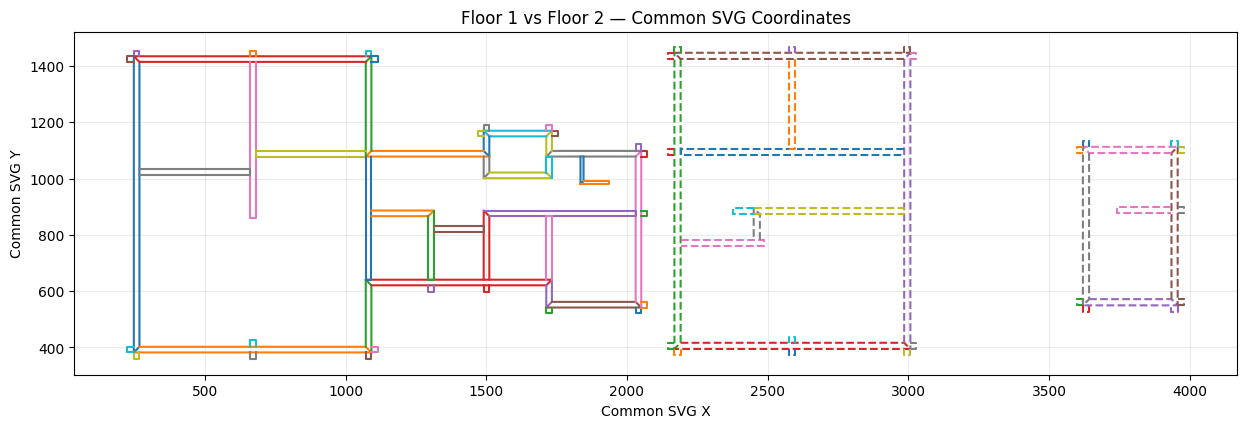

In [59]:
# ============================================================
# FIX: FIND FLOOR GROUPS ROBUSTLY + RECOVER THEIR COORDINATES
# ============================================================

import re
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import unary_union


# ------------------------------------------------------------
# 1. Find the SVG root
# ------------------------------------------------------------

# If your SVG root variable has a different name, change only
# this line.

svg_root = root


# ------------------------------------------------------------
# 2. Find Floor-1 / Floor-2 by CLASS, ID, or substring
# ------------------------------------------------------------

def find_floor_group(root, floor_name):

    matches = []

    for elem in root.iter():

        cls = elem.attrib.get("class", "")
        elem_id = elem.attrib.get("id", "")

        text = f"{cls} {elem_id}"

        if floor_name in text:
            matches.append(elem)

    print(
        f"{floor_name}: {len(matches)} matching elements"
    )

    # Prefer an actual group containing structural elements.
    for elem in matches:

        descendants = list(elem.iter())

        has_wall = any(
            "Wall" in d.attrib.get("class", "")
            for d in descendants
        )

        if has_wall:
            return elem

    # Otherwise return first match.
    if matches:
        return matches[0]

    return None


floor1_elem = find_floor_group(
    svg_root,
    "Floor-1"
)

floor2_elem = find_floor_group(
    svg_root,
    "Floor-2"
)


print("\n" + "=" * 70)
print("FOUND FLOOR GROUPS")
print("=" * 70)

print(
    "Floor-1:",
    "FOUND" if floor1_elem is not None else "NOT FOUND"
)

print(
    "Floor-2:",
    "FOUND" if floor2_elem is not None else "NOT FOUND"
)


# ------------------------------------------------------------
# 3. Build parent map
# ------------------------------------------------------------

parent_map = {
    child: parent
    for parent in svg_root.iter()
    for child in parent
}


# ------------------------------------------------------------
# 4. Parse SVG transforms
# ------------------------------------------------------------

def parse_matrix(transform):

    if not transform:
        return np.eye(3)

    m = re.search(
        r"matrix\s*\(\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)"
        r"\s*\)",
        transform
    )

    if not m:
        return np.eye(3)

    a, b, c, d, e, f = map(
        float,
        m.groups()
    )

    return np.array([
        [a, c, e],
        [b, d, f],
        [0, 0, 1]
    ])


def get_full_transform(elem):

    chain = []

    current = elem

    while current is not None:

        transform = current.attrib.get(
            "transform"
        )

        if transform:
            chain.append(transform)

        current = parent_map.get(current)

    chain.reverse()

    matrix = np.eye(3)

    for transform in chain:
        matrix = matrix @ parse_matrix(
            transform
        )

    return matrix, chain


# ------------------------------------------------------------
# 5. Print actual transform chains
# ------------------------------------------------------------

floor_matrices = {}

for name, elem in [
    ("Floor-1", floor1_elem),
    ("Floor-2", floor2_elem)
]:

    if elem is None:
        continue

    matrix, chain = get_full_transform(
        elem
    )

    floor_matrices[name] = matrix

    print("\n" + "=" * 70)
    print(name, "TRANSFORM CHAIN")
    print("=" * 70)

    if chain:

        for i, transform in enumerate(chain):
            print(
                f"{i}: {transform}"
            )

    else:
        print(
            "No transforms on floor or ancestors."
        )

    print("\nCombined matrix:")
    print(matrix)


# ------------------------------------------------------------
# 6. Extract wall polygons
# ------------------------------------------------------------

def parse_points(points_string):

    nums = re.findall(
        r"[-+]?(?:\d*\.\d+|\d+\.?)"
        r"(?:[eE][-+]?\d+)?",
        points_string
    )

    nums = [
        float(x)
        for x in nums
    ]

    return [
        (nums[i], nums[i + 1])
        for i in range(
            0,
            len(nums) - 1,
            2
        )
    ]


def extract_wall_polygons(floor_elem):

    polygons = []

    for elem in floor_elem.iter():

        cls = elem.attrib.get(
            "class",
            ""
        )

        # Only structural wall groups
        if "Wall" not in cls:
            continue

        for child in elem:

            if not child.tag.endswith(
                "polygon"
            ):
                continue

            points = child.attrib.get(
                "points"
            )

            if not points:
                continue

            pts = parse_points(points)

            if len(pts) >= 3:
                polygons.append(pts)

    return polygons


floor1_raw = extract_wall_polygons(
    floor1_elem
)

floor2_raw = extract_wall_polygons(
    floor2_elem
)


print("\n" + "=" * 70)
print("RAW WALL POLYGONS")
print("=" * 70)

print(
    "Floor-1:",
    len(floor1_raw)
)

print(
    "Floor-2:",
    len(floor2_raw)
)


# ------------------------------------------------------------
# 7. Transform into COMMON SVG coordinates
# ------------------------------------------------------------

def apply_matrix(points, matrix):

    pts = np.asarray(
        points,
        dtype=float
    )

    ones = np.ones(
        (len(pts), 1)
    )

    h = np.hstack([
        pts,
        ones
    ])

    result = h @ matrix.T

    return result[:, :2]


def transform_polygons(
    polygons,
    matrix
):

    result = []

    for pts in polygons:

        transformed = apply_matrix(
            pts,
            matrix
        )

        result.append(
            [
                tuple(p)
                for p in transformed
            ]
        )

    return result


floor1_common = transform_polygons(
    floor1_raw,
    floor_matrices["Floor-1"]
)

floor2_common = transform_polygons(
    floor2_raw,
    floor_matrices["Floor-2"]
)


# ------------------------------------------------------------
# 8. Common coordinate bounds
# ------------------------------------------------------------

def polygon_bounds(polygons):

    all_pts = np.vstack([
        np.asarray(p)
        for p in polygons
    ])

    return (
        all_pts[:, 0].min(),
        all_pts[:, 1].min(),
        all_pts[:, 0].max(),
        all_pts[:, 1].max()
    )


b1 = polygon_bounds(
    floor1_common
)

b2 = polygon_bounds(
    floor2_common
)


print("\n" + "=" * 70)
print("COMMON SVG COORDINATES")
print("=" * 70)

print("\nFloor-1")
print(
    f"X: {b1[0]:.3f} → {b1[2]:.3f}"
)
print(
    f"Y: {b1[1]:.3f} → {b1[3]:.3f}"
)
print(
    f"Width : {b1[2] - b1[0]:.3f}"
)
print(
    f"Height: {b1[3] - b1[1]:.3f}"
)

print("\nFloor-2")
print(
    f"X: {b2[0]:.3f} → {b2[2]:.3f}"
)
print(
    f"Y: {b2[1]:.3f} → {b2[3]:.3f}"
)
print(
    f"Width : {b2[2] - b2[0]:.3f}"
)
print(
    f"Height: {b2[3] - b2[1]:.3f}"
)


# ------------------------------------------------------------
# 9. Plot ONLY the common coordinate geometry
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 10)
)

for pts in floor1_common:

    pts = np.asarray(pts)

    ax.plot(
        pts[:, 0],
        pts[:, 1],
        linewidth=1.5
    )


for pts in floor2_common:

    pts = np.asarray(pts)

    ax.plot(
        pts[:, 0],
        pts[:, 1],
        linestyle="--",
        linewidth=1.5
    )


ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_title(
    "Floor 1 vs Floor 2 — Common SVG Coordinates"
)

ax.set_xlabel(
    "Common SVG X"
)

ax.set_ylabel(
    "Common SVG Y"
)

ax.grid(
    True,
    alpha=0.25
)

plt.show()

In [60]:
import numpy as np
from shapely.geometry import Polygon
from shapely.ops import unary_union

# ============================================================
# REBUILD WALL POLYGONS FROM THE ALREADY-LOADED SVG
# ============================================================

def parse_points(points_str):
    vals = [float(x) for x in points_str.replace(",", " ").split()]
    return list(zip(vals[::2], vals[1::2]))


def get_floor_group(root, floor_name):
    for elem in root.iter():
        classes = elem.attrib.get("class", "").split()
        if floor_name in classes:
            return elem
    return None


def extract_wall_polygons(floor_group):
    polygons = []

    for elem in floor_group.iter():
        classes = elem.attrib.get("class", "").split()

        # Only actual wall groups
        if "Wall" not in classes:
            continue

        # Direct polygon children of this wall
        for child in elem:
            tag = child.tag.split("}")[-1]

            if tag != "polygon":
                continue

            pts = child.attrib.get("points")
            if not pts:
                continue

            try:
                coords = parse_points(pts)
                if len(coords) >= 3:
                    poly = Polygon(coords)

                    if poly.is_valid and poly.area > 0:
                        polygons.append(poly)
                    elif not poly.is_empty:
                        fixed = poly.buffer(0)
                        if not fixed.is_empty and fixed.area > 0:
                            polygons.append(fixed)

            except Exception:
                pass

    return polygons


# ============================================================
# FIND FLOOR GROUPS
# ============================================================

floor1_group = get_floor_group(root, "Floor-1")
floor2_group = get_floor_group(root, "Floor-2")

if floor1_group is None or floor2_group is None:
    raise RuntimeError("Could not find Floor-1 or Floor-2 in the SVG.")

print("Floor groups found:")
print("Floor-1:", floor1_group is not None)
print("Floor-2:", floor2_group is not None)


# ============================================================
# EXTRACT WALL POLYGONS
# ============================================================

floor1_wall_polygons = extract_wall_polygons(floor1_group)
floor2_wall_polygons = extract_wall_polygons(floor2_group)

print()
print("Wall polygons:")
print("Floor-1:", len(floor1_wall_polygons))
print("Floor-2:", len(floor2_wall_polygons))


# ============================================================
# COMMON SVG COORDINATES
# ============================================================

def polygon_bounds(polygons):
    union = unary_union(polygons)
    return union.bounds


b1 = polygon_bounds(floor1_wall_polygons)
b2 = polygon_bounds(floor2_wall_polygons)

print()
print("=" * 70)
print("COMMON SVG COORDINATES")
print("=" * 70)

print()
print("Floor-1")
print(f"X: {b1[0]:.3f} → {b1[2]:.3f}")
print(f"Y: {b1[1]:.3f} → {b1[3]:.3f}")
print(f"Width : {b1[2]-b1[0]:.3f}")
print(f"Height: {b1[3]-b1[1]:.3f}")

print()
print("Floor-2")
print(f"X: {b2[0]:.3f} → {b2[2]:.3f}")
print(f"Y: {b2[1]:.3f} → {b2[3]:.3f}")
print(f"Width : {b2[2]-b2[0]:.3f}")
print(f"Height: {b2[3]-b2[1]:.3f}")


# ============================================================
# ALIGN FLOOR-1 AND FLOOR-2
# ============================================================

# Floor-2 is already in the common SVG coordinate system.
# Convert each floor into a local metric-like coordinate system
# using the same origin convention.

x0 = min(b1[0], b2[0])
y0 = min(b1[1], b2[1])

floor1_common = [
    Polygon([
        ((x - x0), (y - y0))
        for x, y in poly.exterior.coords
    ])
    for poly in floor1_wall_polygons
]

floor2_common = [
    Polygon([
        ((x - x0), (y - y0))
        for x, y in poly.exterior.coords
    ])
    for poly in floor2_wall_polygons
]


# ============================================================
# UNION
# ============================================================

floor1_union = unary_union(floor1_common)
floor2_union = unary_union(floor2_common)

print()
print("=" * 70)
print("FLOOR ALIGNMENT")
print("=" * 70)

print(f"Common origin X0: {x0:.3f}")
print(f"Common origin Y0: {y0:.3f}")

print()
print("Floor-1 aligned bounds:")
print(
    f"{floor1_union.bounds[0]:.3f}, "
    f"{floor1_union.bounds[1]:.3f} → "
    f"{floor1_union.bounds[2]:.3f}, "
    f"{floor1_union.bounds[3]:.3f}"
)

print()
print("Floor-2 aligned bounds:")
print(
    f"{floor2_union.bounds[0]:.3f}, "
    f"{floor2_union.bounds[1]:.3f} → "
    f"{floor2_union.bounds[2]:.3f}, "
    f"{floor2_union.bounds[3]:.3f}"
)

Floor groups found:
Floor-1: True
Floor-2: True

Wall polygons:
Floor-1: 52
Floor-2: 36

COMMON SVG COORDINATES

Floor-1
X: 224.180 → 2072.940
Y: 358.570 → 1454.090
Width : 1848.760
Height: 1095.520

Floor-2
X: 2147.400 → 3980.210
Y: 374.270 → 1466.760
Width : 1832.810
Height: 1092.490

FLOOR ALIGNMENT
Common origin X0: 224.180
Common origin Y0: 358.570

Floor-1 aligned bounds:
0.000, 0.000 → 1848.760, 1095.520

Floor-2 aligned bounds:
1923.220, 15.700 → 3756.030, 1108.190


In [61]:
# ============================================================
# FLOOR-TO-FLOOR SPATIAL RELATIONSHIP
# ============================================================

SVG_PER_M = 100.01457736449694
M_PER_SVG = 1.0 / SVG_PER_M

# Bounds in the COMMON SVG coordinate system
f1 = floor1_union.bounds
f2 = floor2_union.bounds

f1_minx, f1_miny, f1_maxx, f1_maxy = f1
f2_minx, f2_miny, f2_maxx, f2_maxy = f2

print("=" * 70)
print("FLOOR-TO-FLOOR SPATIAL RELATIONSHIP")
print("=" * 70)

print()
print("Floor 1:")
print(f"X: {f1_minx:.3f} → {f1_maxx:.3f}")
print(f"Y: {f1_miny:.3f} → {f1_maxy:.3f}")

print()
print("Floor 2:")
print(f"X: {f2_minx:.3f} → {f2_maxx:.3f}")
print(f"Y: {f2_miny:.3f} → {f2_maxy:.3f}")


# ------------------------------------------------------------
# GAP BETWEEN THE TWO FLOOR BOUNDS
# ------------------------------------------------------------

horizontal_gap = max(
    0.0,
    max(f1_minx, f2_minx) - min(f1_maxx, f2_maxx)
)

vertical_gap = max(
    0.0,
    max(f1_miny, f2_miny) - min(f1_maxy, f2_maxy)
)

print()
print("=" * 70)
print("BOUNDING-BOX GAP")
print("=" * 70)

print(f"Horizontal gap: {horizontal_gap:.3f} SVG units")
print(f"Horizontal gap: {horizontal_gap * M_PER_SVG:.3f} m")

print(f"Vertical gap  : {vertical_gap:.3f} SVG units")
print(f"Vertical gap  : {vertical_gap * M_PER_SVG:.3f} m")


# ------------------------------------------------------------
# CENTER POSITIONS
# ------------------------------------------------------------

f1_cx = (f1_minx + f1_maxx) / 2
f1_cy = (f1_miny + f1_maxy) / 2

f2_cx = (f2_minx + f2_maxx) / 2
f2_cy = (f2_miny + f2_maxy) / 2

dx = f2_cx - f1_cx
dy = f2_cy - f1_cy

print()
print("=" * 70)
print("FLOOR CENTERS")
print("=" * 70)

print(f"Floor 1 center: ({f1_cx:.3f}, {f1_cy:.3f})")
print(f"Floor 2 center: ({f2_cx:.3f}, {f2_cy:.3f})")

print()
print(f"Center ΔX: {dx:.3f} SVG units = {dx * M_PER_SVG:.3f} m")
print(f"Center ΔY: {dy:.3f} SVG units = {dy * M_PER_SVG:.3f} m")


# ------------------------------------------------------------
# OVERLAP TEST
# ------------------------------------------------------------

intersection = floor1_union.intersection(floor2_union)

print()
print("=" * 70)
print("GEOMETRIC OVERLAP")
print("=" * 70)

print(f"Intersection area: {intersection.area:.6f} SVG²")

if intersection.is_empty:
    print("Result: NO GEOMETRIC OVERLAP")
else:
    print("Result: GEOMETRIC OVERLAP EXISTS")

print()
print("This is the raw SVG relationship.")
print("No artificial translation has been applied.")

FLOOR-TO-FLOOR SPATIAL RELATIONSHIP

Floor 1:
X: 0.000 → 1848.760
Y: 0.000 → 1095.520

Floor 2:
X: 1923.220 → 3756.030
Y: 15.700 → 1108.190

BOUNDING-BOX GAP
Horizontal gap: 74.460 SVG units
Horizontal gap: 0.744 m
Vertical gap  : 0.000 SVG units
Vertical gap  : 0.000 m

FLOOR CENTERS
Floor 1 center: (924.380, 547.760)
Floor 2 center: (2839.625, 561.945)

Center ΔX: 1915.245 SVG units = 19.150 m
Center ΔY: 14.185 SVG units = 0.142 m

GEOMETRIC OVERLAP
Intersection area: 0.000000 SVG²
Result: NO GEOMETRIC OVERLAP

This is the raw SVG relationship.
No artificial translation has been applied.


In [62]:
# ============================================================
# FLOOR 1 ↔ FLOOR 2 GEOMETRY CORRESPONDENCE
# ============================================================

from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
import numpy as np

print("=" * 70)
print("FLOOR 1 ↔ FLOOR 2 GEOMETRY CORRESPONDENCE")
print("=" * 70)

# ------------------------------------------------------------
# Convert each wall polygon into its exterior boundary
# ------------------------------------------------------------

def polygon_edges(poly):
    coords = list(poly.exterior.coords)
    return [
        LineString([coords[i], coords[i + 1]])
        for i in range(len(coords) - 1)
    ]


f1_edges = []
for i, poly in enumerate(floor1_wall_polygons):
    for edge in polygon_edges(poly):
        f1_edges.append((i, edge))

f2_edges = []
for i, poly in enumerate(floor2_wall_polygons):
    for edge in polygon_edges(poly):
        f2_edges.append((i, edge))


# ------------------------------------------------------------
# Normalize edge geometry into local floor coordinates
# ------------------------------------------------------------

def normalize_floor_edges(edges, bounds):
    minx, miny, _, _ = bounds

    result = []

    for poly_id, edge in edges:
        coords = [
            (x - minx, y - miny)
            for x, y in edge.coords
        ]

        result.append(
            (poly_id, LineString(coords))
        )

    return result


f1_local_edges = normalize_floor_edges(f1_edges, floor1_union.bounds)
f2_local_edges = normalize_floor_edges(f2_edges, floor2_union.bounds)


# ------------------------------------------------------------
# Compare edge lengths and orientations
# ------------------------------------------------------------

def edge_signature(edge):
    coords = list(edge.coords)

    x1, y1 = coords[0]
    x2, y2 = coords[-1]

    dx = x2 - x1
    dy = y2 - y1

    length = np.hypot(dx, dy)

    angle = np.degrees(np.arctan2(dy, dx)) % 180

    return length, angle


f1_signatures = [
    (pid, *edge_signature(edge))
    for pid, edge in f1_local_edges
]

f2_signatures = [
    (pid, *edge_signature(edge))
    for pid, edge in f2_local_edges
]


# ------------------------------------------------------------
# Find likely matching edges
# ------------------------------------------------------------

print()
print("Likely corresponding edges")
print("-" * 70)

matches = []

for pid1, length1, angle1 in f1_signatures:

    best = None

    for pid2, length2, angle2 in f2_signatures:

        length_error = abs(length1 - length2)

        angle_error = min(
            abs(angle1 - angle2),
            180 - abs(angle1 - angle2)
        )

        # Relative length error
        rel_error = length_error / max(length1, 1.0)

        score = rel_error + angle_error / 180.0

        if best is None or score < best["score"]:
            best = {
                "floor1_polygon": pid1,
                "floor2_polygon": pid2,
                "length1": length1,
                "length2": length2,
                "length_error": length_error,
                "angle_error": angle_error,
                "score": score
            }

    if best is not None:
        matches.append(best)


# ------------------------------------------------------------
# Print strongest matches
# ------------------------------------------------------------

matches.sort(key=lambda x: x["score"])

for m in matches[:30]:

    print(
        f"F1 wall {m['floor1_polygon']:2d}  ↔  "
        f"F2 wall {m['floor2_polygon']:2d} | "
        f"L1={m['length1']:.1f}  "
        f"L2={m['length2']:.1f} | "
        f"ΔL={m['length_error']:.1f} | "
        f"Δangle={m['angle_error']:.1f}° | "
        f"score={m['score']:.4f}"
    )


# ------------------------------------------------------------
# Overall footprint dimensions in metres
# ------------------------------------------------------------

print()
print("=" * 70)
print("LOCAL FLOOR FOOTPRINTS")
print("=" * 70)

f1_width = (
    floor1_union.bounds[2] -
    floor1_union.bounds[0]
)

f1_height = (
    floor1_union.bounds[3] -
    floor1_union.bounds[1]
)

f2_width = (
    floor2_union.bounds[2] -
    floor2_union.bounds[0]
)

f2_height = (
    floor2_union.bounds[3] -
    floor2_union.bounds[1]
)

print(
    f"Floor 1: "
    f"{f1_width * M_PER_SVG:.3f} × "
    f"{f1_height * M_PER_SVG:.3f} m"
)

print(
    f"Floor 2: "
    f"{f2_width * M_PER_SVG:.3f} × "
    f"{f2_height * M_PER_SVG:.3f} m"
)

FLOOR 1 ↔ FLOOR 2 GEOMETRY CORRESPONDENCE

Likely corresponding edges
----------------------------------------------------------------------
F1 wall  0  ↔  F2 wall  0 | L1=1052.6  L2=1052.7 | ΔL=0.1 | Δangle=0.0° | score=0.0001
F1 wall  5  ↔  F2 wall 22 | L1=337.7  L2=336.8 | ΔL=0.8 | Δangle=0.0° | score=0.0024
F1 wall 15  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 15  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 17  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 17  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 18  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 18  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 21  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 24  ↔  F2 wall 17 | L1=20.0  L2=20.1 | ΔL=0.1 | Δangle=0.0° | score=0.0035
F1 wall 25  ↔  F2 wall 

In [63]:
# ============================================================
# ROBUST FLOOR CORRESPONDENCE
# Ignore tiny wall fragments and compare substantial edges
# ============================================================

from shapely.geometry import LineString
import numpy as np

MIN_EDGE_LENGTH = 100.0   # ~1 metre

def get_substantial_edges(polygons, bounds):
    minx, miny, _, _ = bounds
    result = []

    for poly_id, poly in enumerate(polygons):
        coords = list(poly.exterior.coords)

        for edge_id in range(len(coords) - 1):
            x1, y1 = coords[edge_id]
            x2, y2 = coords[edge_id + 1]

            length = np.hypot(x2 - x1, y2 - y1)

            if length < MIN_EDGE_LENGTH:
                continue

            # local coordinates
            p1 = (x1 - minx, y1 - miny)
            p2 = (x2 - minx, y2 - miny)

            line = LineString([p1, p2])

            angle = np.degrees(
                np.arctan2(
                    p2[1] - p1[1],
                    p2[0] - p1[0]
                )
            ) % 180

            result.append({
                "polygon": poly_id,
                "edge": edge_id,
                "line": line,
                "length": length,
                "angle": angle,
                "midpoint": line.centroid
            })

    return result


f1_edges = get_substantial_edges(
    floor1_wall_polygons,
    floor1_union.bounds
)

f2_edges = get_substantial_edges(
    floor2_wall_polygons,
    floor2_union.bounds
)


print("=" * 70)
print("SUBSTANTIAL STRUCTURAL EDGES")
print("=" * 70)

print(f"Floor 1 edges >= 1 m: {len(f1_edges)}")
print(f"Floor 2 edges >= 1 m: {len(f2_edges)}")


# ============================================================
# MATCH BY LENGTH + ORIENTATION
# ============================================================

matches = []

for e1 in f1_edges:

    best = None

    for e2 in f2_edges:

        length_error = abs(e1["length"] - e2["length"])

        relative_length_error = (
            length_error /
            max(e1["length"], e2["length"])
        )

        angle_error = min(
            abs(e1["angle"] - e2["angle"]),
            180 - abs(e1["angle"] - e2["angle"])
        )

        # Ignore matches with very different orientation
        if angle_error > 5:
            continue

        score = (
            relative_length_error
            + angle_error / 180.0
        )

        if best is None or score < best["score"]:
            best = {
                "e1": e1,
                "e2": e2,
                "score": score,
                "length_error": length_error,
                "angle_error": angle_error
            }

    if best is not None:
        matches.append(best)


matches.sort(key=lambda x: x["score"])


# ============================================================
# DISPLAY BEST MATCHES
# ============================================================

print()
print("=" * 70)
print("BEST SUBSTANTIAL EDGE MATCHES")
print("=" * 70)

for m in matches[:25]:

    e1 = m["e1"]
    e2 = m["e2"]

    print(
        f"F1 wall {e1['polygon']:2d}, edge {e1['edge']:2d}"
        f" ↔ "
        f"F2 wall {e2['polygon']:2d}, edge {e2['edge']:2d}"
    )

    print(
        f"   length: "
        f"{e1['length']:.1f} ↔ {e2['length']:.1f} SVG"
        f"   Δ={m['length_error']:.1f}"
    )

    print(
        f"   angle : "
        f"{e1['angle']:.1f}° ↔ {e2['angle']:.1f}°"
        f"   Δ={m['angle_error']:.1f}°"
    )

    print(
        f"   midpoint F1: "
        f"({e1['midpoint'].x:.1f}, {e1['midpoint'].y:.1f})"
    )

    print(
        f"   midpoint F2: "
        f"({e2['midpoint'].x:.1f}, {e2['midpoint'].y:.1f})"
    )

    print(
        f"   score: {m['score']:.5f}"
    )

    print()

SUBSTANTIAL STRUCTURAL EDGES
Floor 1 edges >= 1 m: 45
Floor 2 edges >= 1 m: 27

BEST SUBSTANTIAL EDGE MATCHES
F1 wall  0, edge  2 ↔ F2 wall  0, edge  2
   length: 1052.6 ↔ 1052.7 SVG   Δ=0.2
   angle : 90.0° ↔ 90.0°   Δ=0.0°
   midpoint F1: (247.5, 908.7)
   midpoint F2: (245.7, 905.3)
   score: 0.00014

F1 wall  5, edge  0 ↔ F2 wall 22, edge  2
   length: 337.7 ↔ 336.8 SVG   Δ=0.8
   angle : 0.0° ↔ 0.0°   Δ=0.0°
   midpoint F1: (1882.3, 542.0)
   midpoint F2: (1865.9, 534.0)
   score: 0.00243

F1 wall  0, edge  0 ↔ F2 wall  0, edge  0
   length: 1012.6 ↔ 1008.7 SVG   Δ=3.9
   angle : 90.0° ↔ 90.0°   Δ=0.0°
   midpoint F1: (267.5, 908.7)
   midpoint F2: (267.7, 905.3)
   score: 0.00380

F1 wall  6, edge  0 ↔ F2 wall 23, edge  0
   length: 516.6 ↔ 519.4 SVG   Δ=2.8
   angle : 90.0° ↔ 90.0°   Δ=0.0°
   midpoint F1: (2031.1, 820.3)
   midpoint F2: (2012.3, 815.7)
   score: 0.00539

F1 wall  5, edge  2 ↔ F2 wall  4, edge  0
   length: 297.6 ↔ 295.7 SVG   Δ=2.0
   angle : 0.0° ↔ 0.0°   Δ=0.

In [64]:
import numpy as np
import math

# ================================================================
# ROBUST FLOOR-TO-FLOOR ALIGNMENT
# ================================================================

print("=" * 70)
print("ROBUST FLOOR-TO-FLOOR ALIGNMENT")
print("=" * 70)


# ------------------------------------------------
# 1. Helpers
# ------------------------------------------------

def edge_info(p1, p2):
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)

    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]

    length = np.hypot(dx, dy)

    angle = math.degrees(math.atan2(dy, dx)) % 180.0

    midpoint = (p1 + p2) / 2.0

    return {
        "p1": p1,
        "p2": p2,
        "length": length,
        "angle": angle,
        "midpoint": midpoint,
    }


def polygon_edges(poly):
    """
    Return all edges of a polygon.

    Supports:
      - shapely Polygon
      - Nx2 numpy/list coordinate arrays
    """
    if hasattr(poly, "exterior"):
        coords = np.asarray(poly.exterior.coords[:-1], dtype=float)
    else:
        coords = np.asarray(poly, dtype=float)

    edges = []

    for i in range(len(coords)):
        p1 = coords[i]
        p2 = coords[(i + 1) % len(coords)]

        e = edge_info(p1, p2)

        if e["length"] > 1e-6:
            edges.append(e)

    return edges


# ------------------------------------------------
# 2. Extract substantial edges
# ------------------------------------------------

MIN_EDGE_LENGTH = 100.0   # SVG units ≈ 1 metre

f1_edges = []
f2_edges = []

for wi, poly in enumerate(floor1_polys):
    for ei, e in enumerate(polygon_edges(poly)):
        if e["length"] >= MIN_EDGE_LENGTH:
            e["wall"] = wi
            e["edge"] = ei
            f1_edges.append(e)

for wi, poly in enumerate(floor2_polys):
    for ei, e in enumerate(polygon_edges(poly)):
        if e["length"] >= MIN_EDGE_LENGTH:
            e["wall"] = wi
            e["edge"] = ei
            f2_edges.append(e)


print()
print(f"F1 substantial edges: {len(f1_edges)}")
print(f"F2 substantial edges: {len(f2_edges)}")


# ------------------------------------------------
# 3. Generate candidate matches
#
# We use length + orientation only initially.
# Midpoint is NOT used to decide correspondence,
# because that is exactly what we're trying to estimate.
# ------------------------------------------------

candidates = []

for i, a in enumerate(f1_edges):

    for j, b in enumerate(f2_edges):

        length_delta = abs(a["length"] - b["length"])

        # orientation difference modulo 180°
        angle_delta = abs(a["angle"] - b["angle"])
        angle_delta = min(angle_delta, 180.0 - angle_delta)

        # Relative length error
        length_error = length_delta / max(a["length"], b["length"])

        # Reject obviously different edges
        if length_error > 0.04:
            continue

        if angle_delta > 3.0:
            continue

        score = (
            length_error
            + angle_delta / 180.0
        )

        candidates.append(
            (
                score,
                i,
                j,
                length_delta,
                angle_delta,
            )
        )


candidates.sort(key=lambda x: x[0])


print()
print(f"Candidate edge matches: {len(candidates)}")


# ------------------------------------------------
# 4. Greedy one-to-one matching
#
# Prevent one F2 edge from being matched to
# many identical F1 edges.
# ------------------------------------------------

used_f1 = set()
used_f2 = set()

matches = []

for score, i, j, dl, da in candidates:

    if i in used_f1:
        continue

    if j in used_f2:
        continue

    used_f1.add(i)
    used_f2.add(j)

    matches.append(
        {
            "f1": i,
            "f2": j,
            "score": score,
            "length_delta": dl,
            "angle_delta": da,
        }
    )


print(f"One-to-one matches: {len(matches)}")


# ------------------------------------------------
# 5. Print the strongest matches
# ------------------------------------------------

print()
print("-" * 70)
print("STRONG ONE-TO-ONE MATCHES")
print("-" * 70)

for m in matches[:20]:

    a = f1_edges[m["f1"]]
    b = f2_edges[m["f2"]]

    print(
        f"F1 wall {a['wall']:2d}, edge {a['edge']:2d}"
        f" ↔ "
        f"F2 wall {b['wall']:2d}, edge {b['edge']:2d}"
    )

    print(
        f"   length: "
        f"{a['length']:.2f} ↔ {b['length']:.2f}"
        f"   Δ={m['length_delta']:.2f}"
    )

    print(
        f"   angle : "
        f"{a['angle']:.2f}° ↔ {b['angle']:.2f}°"
        f"   Δ={m['angle_delta']:.2f}°"
    )

    print()


# ------------------------------------------------
# 6. Estimate translation from matched midpoints
#
# At this stage we deliberately assume:
#
#       rotation ≈ 0
#       scale    ≈ 1
#
# because the SVG evidence already shows this.
# ------------------------------------------------

translations = []

for m in matches:

    a = f1_edges[m["f1"]]
    b = f2_edges[m["f2"]]

    delta = a["midpoint"] - b["midpoint"]

    translations.append(delta)


translations = np.asarray(translations)


if len(translations) > 0:

    # Robust median translation
    translation = np.median(translations, axis=0)

    residuals = translations - translation

    distances = np.linalg.norm(residuals, axis=1)

    print("=" * 70)
    print("ROBUST TRANSLATION ESTIMATE")
    print("=" * 70)

    print(
        f"ΔX: {translation[0]:.3f} SVG"
    )

    print(
        f"ΔY: {translation[1]:.3f} SVG"
    )

    print(
        f"ΔX: {translation[0] / 100.01457736449694:.4f} m"
    )

    print(
        f"ΔY: {translation[1] / 100.01457736449694:.4f} m"
    )

    print()
    print(
        f"Median residual: "
        f"{np.median(distances):.3f} SVG"
    )

    print(
        f"Mean residual: "
        f"{np.mean(distances):.3f} SVG"
    )

    print(
        f"Max residual: "
        f"{np.max(distances):.3f} SVG"
    )


# ------------------------------------------------
# 7. Determine whether translation is actually needed
# ------------------------------------------------

if len(translations) >= 3:

    median_residual = np.median(distances)

    print()
    print("=" * 70)
    print("ALIGNMENT DECISION")
    print("=" * 70)

    if median_residual < 10.0:

        print("RESULT: Floors are already closely aligned.")
        print(
            "No significant additional translation is "
            "supported by the structural edges."
        )

    elif median_residual < 30.0:

        print("RESULT: Small alignment offset detected.")
        print(
            "Use the robust translation, but keep rotation ≈ 0 "
            "and scale ≈ 1."
        )

    else:

        print("RESULT: Significant disagreement remains.")
        print(
            "Do NOT apply the translation yet."
        )
        print(
            "The correspondence set likely contains "
            "incorrect structural matches."
        )

ROBUST FLOOR-TO-FLOOR ALIGNMENT

F1 substantial edges: 0
F2 substantial edges: 0

Candidate edge matches: 0
One-to-one matches: 0

----------------------------------------------------------------------
STRONG ONE-TO-ONE MATCHES
----------------------------------------------------------------------


In [65]:
import numpy as np
import math

print("=" * 70)
print("REBUILDING STRUCTURAL EDGES FROM WALL POLYGONS")
print("=" * 70)


# ================================================================
# 1. Find the actual wall-polygon variables
# ================================================================

possible_f1 = [
    "floor1_wall_polygons",
    "floor1_polygons",
    "floor1_polys",
]

possible_f2 = [
    "floor2_wall_polygons",
    "floor2_polygons",
    "floor2_polys",
]


def get_existing_variable(names):
    for name in names:
        if name in globals():
            value = globals()[name]

            if value is not None and len(value) > 0:
                print(f"Using variable: {name}")
                print(f"Number of objects: {len(value)}")
                return value

    return None


f1_source = get_existing_variable(possible_f1)
f2_source = get_existing_variable(possible_f2)


if f1_source is None or f2_source is None:
    raise RuntimeError(
        "Could not find the existing Floor-1/Floor-2 wall polygon "
        "variables. Do not continue with alignment yet."
    )


# ================================================================
# 2. Convert polygon representations into coordinate arrays
# ================================================================

def polygon_to_coords(poly):

    # Shapely Polygon
    if hasattr(poly, "exterior"):
        coords = np.asarray(
            poly.exterior.coords,
            dtype=float
        )

    # Dictionary representation
    elif isinstance(poly, dict):

        if "points" in poly:
            coords = np.asarray(
                poly["points"],
                dtype=float
            )

        elif "coordinates" in poly:
            coords = np.asarray(
                poly["coordinates"],
                dtype=float
            )

        else:
            raise ValueError(
                f"Unknown polygon dictionary keys: {poly.keys()}"
            )

    # Plain coordinate list
    else:
        coords = np.asarray(poly, dtype=float)

    # Normalize shape
    coords = coords.reshape(-1, 2)

    # Remove duplicated closing point
    if len(coords) > 1 and np.allclose(coords[0], coords[-1]):
        coords = coords[:-1]

    return coords


# ================================================================
# 3. Extract edges
# ================================================================

def extract_edges(polygons, min_length=100.0):

    edges = []

    for wall_index, poly in enumerate(polygons):

        coords = polygon_to_coords(poly)

        if len(coords) < 2:
            continue

        for edge_index in range(len(coords)):

            p1 = coords[edge_index]
            p2 = coords[(edge_index + 1) % len(coords)]

            dx = p2[0] - p1[0]
            dy = p2[1] - p1[1]

            length = np.hypot(dx, dy)

            if length < min_length:
                continue

            angle = math.degrees(
                math.atan2(dy, dx)
            ) % 180.0

            midpoint = (p1 + p2) / 2.0

            edges.append({
                "wall": wall_index,
                "edge": edge_index,
                "p1": p1,
                "p2": p2,
                "length": length,
                "angle": angle,
                "midpoint": midpoint,
            })

    return edges


# ================================================================
# 4. Build substantial edge lists
# ================================================================

MIN_EDGE_LENGTH = 100.0

f1_edges = extract_edges(
    f1_source,
    MIN_EDGE_LENGTH
)

f2_edges = extract_edges(
    f2_source,
    MIN_EDGE_LENGTH
)


print()
print("=" * 70)
print("EDGE EXTRACTION")
print("=" * 70)

print(
    f"Floor 1 wall polygons : {len(f1_source)}"
)

print(
    f"Floor 2 wall polygons : {len(f2_source)}"
)

print(
    f"Floor 1 substantial edges >= {MIN_EDGE_LENGTH:.0f} SVG : "
    f"{len(f1_edges)}"
)

print(
    f"Floor 2 substantial edges >= {MIN_EDGE_LENGTH:.0f} SVG : "
    f"{len(f2_edges)}"
)


# ================================================================
# 5. Show the actual extracted edges
# ================================================================

print()
print("-" * 70)
print("FLOOR 1 SAMPLE EDGES")
print("-" * 70)

for e in f1_edges[:10]:

    print(
        f"wall {e['wall']:2d}, edge {e['edge']:2d} | "
        f"L={e['length']:.1f} | "
        f"angle={e['angle']:.1f}° | "
        f"mid=({e['midpoint'][0]:.1f}, "
        f"{e['midpoint'][1]:.1f})"
    )


print()
print("-" * 70)
print("FLOOR 2 SAMPLE EDGES")
print("-" * 70)

for e in f2_edges[:10]:

    print(
        f"wall {e['wall']:2d}, edge {e['edge']:2d} | "
        f"L={e['length']:.1f} | "
        f"angle={e['angle']:.1f}° | "
        f"mid=({e['midpoint'][0]:.1f}, "
        f"{e['midpoint'][1]:.1f})"
    )


# ================================================================
# 6. Match edges
# ================================================================

candidates = []

for i, a in enumerate(f1_edges):

    for j, b in enumerate(f2_edges):

        length_delta = abs(
            a["length"] - b["length"]
        )

        relative_length_error = (
            length_delta /
            max(a["length"], b["length"])
        )

        angle_delta = abs(
            a["angle"] - b["angle"]
        )

        angle_delta = min(
            angle_delta,
            180.0 - angle_delta
        )

        if relative_length_error > 0.04:
            continue

        if angle_delta > 3.0:
            continue

        score = (
            relative_length_error
            + angle_delta / 180.0
        )

        candidates.append(
            (
                score,
                i,
                j,
                length_delta,
                angle_delta
            )
        )


candidates.sort(key=lambda x: x[0])


# ================================================================
# 7. One-to-one matching
# ================================================================

used_f1 = set()
used_f2 = set()

matches = []

for score, i, j, dl, da in candidates:

    if i in used_f1:
        continue

    if j in used_f2:
        continue

    used_f1.add(i)
    used_f2.add(j)

    matches.append({
        "f1": i,
        "f2": j,
        "score": score,
        "length_delta": dl,
        "angle_delta": da,
    })


print()
print("=" * 70)
print("STRUCTURAL EDGE CORRESPONDENCE")
print("=" * 70)

print(
    f"Candidate matches : {len(candidates)}"
)

print(
    f"One-to-one matches: {len(matches)}"
)


for m in matches[:20]:

    a = f1_edges[m["f1"]]
    b = f2_edges[m["f2"]]

    print()
    print(
        f"F1 wall {a['wall']:2d}, edge {a['edge']:2d}"
        f" ↔ "
        f"F2 wall {b['wall']:2d}, edge {b['edge']:2d}"
    )

    print(
        f"  length: "
        f"{a['length']:.2f} ↔ {b['length']:.2f}"
        f"   Δ={m['length_delta']:.2f}"
    )

    print(
        f"  angle : "
        f"{a['angle']:.2f}° ↔ {b['angle']:.2f}°"
        f"   Δ={m['angle_delta']:.2f}°"
    )


# ================================================================
# 8. Robust translation estimate
# ================================================================

if len(matches) >= 3:

    translations = []

    for m in matches:

        a = f1_edges[m["f1"]]
        b = f2_edges[m["f2"]]

        translations.append(
            a["midpoint"] - b["midpoint"]
        )

    translations = np.asarray(
        translations
    )

    translation = np.median(
        translations,
        axis=0
    )

    residuals = (
        translations - translation
    )

    residual_distances = np.linalg.norm(
        residuals,
        axis=1
    )

    print()
    print("=" * 70)
    print("ROBUST TRANSLATION")
    print("=" * 70)

    print(
        f"ΔX = {translation[0]:.3f} SVG"
    )

    print(
        f"ΔY = {translation[1]:.3f} SVG"
    )

    print(
        f"ΔX = {translation[0] / 100.01457736449694:.4f} m"
    )

    print(
        f"ΔY = {translation[1] / 100.01457736449694:.4f} m"
    )

    print()
    print(
        f"Median residual = "
        f"{np.median(residual_distances):.3f} SVG"
    )

    print(
        f"Mean residual   = "
        f"{np.mean(residual_distances):.3f} SVG"
    )

    print(
        f"Max residual    = "
        f"{np.max(residual_distances):.3f} SVG"
    )

else:

    print()
    print(
        "Not enough reliable edge correspondences "
        "to estimate alignment."
    )

REBUILDING STRUCTURAL EDGES FROM WALL POLYGONS
Using variable: floor1_wall_polygons
Number of objects: 52
Using variable: floor2_wall_polygons
Number of objects: 36

EDGE EXTRACTION
Floor 1 wall polygons : 52
Floor 2 wall polygons : 36
Floor 1 substantial edges >= 100 SVG : 45
Floor 2 substantial edges >= 100 SVG : 27

----------------------------------------------------------------------
FLOOR 1 SAMPLE EDGES
----------------------------------------------------------------------
wall  0, edge  0 | L=1012.6 | angle=90.0° | mid=(267.5, 908.7)
wall  0, edge  2 | L=1052.6 | angle=90.0° | mid=(247.5, 908.7)
wall  1, edge  0 | L=804.4 | angle=0.0° | mid=(669.7, 402.4)
wall  1, edge  2 | L=844.4 | angle=0.0° | mid=(669.7, 382.4)
wall  2, edge  0 | L=238.5 | angle=90.0° | mid=(1071.9, 521.7)
wall  2, edge  2 | L=238.5 | angle=90.0° | mid=(1091.9, 501.7)
wall  3, edge  0 | L=621.5 | angle=0.0° | mid=(1402.7, 620.9)
wall  3, edge  2 | L=661.5 | angle=0.0° | mid=(1402.7, 640.9)
wall  5, edge  0 |

In [66]:
# ================================================================
# HIGH-CONFIDENCE FLOOR ALIGNMENT
# ================================================================

SCALE = 100.01457736449694  # SVG units / metre

# Only accept very strong structural correspondence.
# Tight thresholds deliberately avoid ambiguous repeated edges.

GOOD_MATCHES = []

for m in matches:

    a = f1_edges[m["f1"]]
    b = f2_edges[m["f2"]]

    length_error = (
        abs(a["length"] - b["length"])
        / max(a["length"], b["length"])
    )

    angle_error = abs(a["angle"] - b["angle"])
    angle_error = min(angle_error, 180 - angle_error)

    if length_error <= 0.02 and angle_error <= 1.0:
        GOOD_MATCHES.append(m)


print("=" * 70)
print("HIGH-CONFIDENCE STRUCTURAL MATCHES")
print("=" * 70)

print("Matches:", len(GOOD_MATCHES))

translations = []

for m in GOOD_MATCHES:

    a = f1_edges[m["f1"]]
    b = f2_edges[m["f2"]]

    delta = a["midpoint"] - b["midpoint"]

    translations.append(delta)

    print(
        f"F1 wall {a['wall']:2d}, edge {a['edge']:2d}"
        f" ↔ "
        f"F2 wall {b['wall']:2d}, edge {b['edge']:2d}"
    )

    print(
        f"  length: {a['length']:.2f} ↔ {b['length']:.2f}"
    )

    print(
        f"  midpoint F1: "
        f"({a['midpoint'][0]:.2f}, "
        f"{a['midpoint'][1]:.2f})"
    )

    print(
        f"  midpoint F2: "
        f"({b['midpoint'][0]:.2f}, "
        f"{b['midpoint'][1]:.2f})"
    )

    print(
        f"  translation: "
        f"({delta[0]:.2f}, {delta[1]:.2f})"
    )

    print()


if len(translations) >= 2:

    translations = np.asarray(translations)

    alignment_translation = np.median(
        translations,
        axis=0
    )

    residuals = (
        translations - alignment_translation
    )

    residual_lengths = np.linalg.norm(
        residuals,
        axis=1
    )

    print("=" * 70)
    print("FINAL STRUCTURAL ALIGNMENT")
    print("=" * 70)

    print(
        f"ΔX = {alignment_translation[0]:.3f} SVG"
    )

    print(
        f"ΔY = {alignment_translation[1]:.3f} SVG"
    )

    print()

    print(
        f"ΔX = "
        f"{alignment_translation[0] / SCALE:.4f} m"
    )

    print(
        f"ΔY = "
        f"{alignment_translation[1] / SCALE:.4f} m"
    )

    print()

    print(
        f"Median residual = "
        f"{np.median(residual_lengths):.3f} SVG"
    )

    print(
        f"Max residual = "
        f"{np.max(residual_lengths):.3f} SVG"
    )

else:

    raise RuntimeError(
        "Not enough high-confidence structural matches."
    )


# ================================================================
# TRANSLATE FLOOR 2 INTO FLOOR 1 COORDINATES
# ================================================================

dx, dy = alignment_translation


def translate_polygon(poly, dx, dy):

    if hasattr(poly, "exterior"):

        coords = np.asarray(
            poly.exterior.coords,
            dtype=float
        )

        return np.column_stack([
            coords[:, 0] + dx,
            coords[:, 1] + dy
        ])

    coords = np.asarray(
        poly,
        dtype=float
    )

    return coords + np.array([dx, dy])


floor2_aligned_polygons = [
    translate_polygon(poly, dx, dy)
    for poly in f2_source
]


# ================================================================
# ALIGNED BOUNDS
# ================================================================

def polygon_bounds(polygons):

    all_points = np.vstack([
        polygon_to_coords(p)
        for p in polygons
    ])

    return (
        all_points[:, 0].min(),
        all_points[:, 1].min(),
        all_points[:, 0].max(),
        all_points[:, 1].max()
    )


f1_bounds = polygon_bounds(f1_source)
f2_aligned_bounds = polygon_bounds(
    floor2_aligned_polygons
)

print()
print("=" * 70)
print("ALIGNED STRUCTURAL BOUNDS")
print("=" * 70)

print(
    "Floor 1:"
)

print(
    f"  {f1_bounds[0]:.2f}, {f1_bounds[1]:.2f}"
    f" → "
    f"{f1_bounds[2]:.2f}, {f1_bounds[3]:.2f}"
)

print(
    "Floor 2 aligned:"
)

print(
    f"  {f2_aligned_bounds[0]:.2f}, "
    f"{f2_aligned_bounds[1]:.2f}"
    f" → "
    f"{f2_aligned_bounds[2]:.2f}, "
    f"{f2_aligned_bounds[3]:.2f}"
)

print()
print("=" * 70)
print("ALIGNED BOUNDING-BOX RELATIONSHIP")
print("=" * 70)

overlap_x = max(
    0,
    min(f1_bounds[2], f2_aligned_bounds[2])
    - max(f1_bounds[0], f2_aligned_bounds[0])
)

overlap_y = max(
    0,
    min(f1_bounds[3], f2_aligned_bounds[3])
    - max(f1_bounds[1], f2_aligned_bounds[1])
)

print(
    f"Overlap width : "
    f"{overlap_x:.2f} SVG = {overlap_x / SCALE:.3f} m"
)

print(
    f"Overlap height: "
    f"{overlap_y:.2f} SVG = {overlap_y / SCALE:.3f} m"
)

print(
    f"Overlap area  : "
    f"{overlap_x * overlap_y:.2f} SVG²"
)

HIGH-CONFIDENCE STRUCTURAL MATCHES
Matches: 12
F1 wall  0, edge  2 ↔ F2 wall  0, edge  2
  length: 1052.56 ↔ 1052.71
  midpoint F1: (247.53, 908.70)
  midpoint F2: (2168.90, 921.00)
  translation: (-1921.37, -12.30)

F1 wall  5, edge  0 ↔ F2 wall 22, edge  2
  length: 337.65 ↔ 336.83
  midpoint F1: (1882.27, 542.03)
  midpoint F2: (3789.11, 549.70)
  translation: (-1906.84, -7.67)

F1 wall  0, edge  0 ↔ F2 wall  0, edge  0
  length: 1012.56 ↔ 1008.71
  midpoint F1: (267.53, 908.70)
  midpoint F2: (2190.90, 921.00)
  translation: (-1923.37, -12.30)

F1 wall  6, edge  0 ↔ F2 wall 23, edge  0
  length: 516.58 ↔ 519.38
  midpoint F1: (2031.09, 820.32)
  midpoint F2: (3935.52, 831.39)
  translation: (-1904.43, -11.07)

F1 wall  5, edge  2 ↔ F2 wall  4, edge  0
  length: 297.65 ↔ 295.65
  midpoint F1: (1882.26, 562.03)
  midpoint F2: (2338.73, 782.70)
  translation: (-456.46, -220.67)

F1 wall  1, edge  2 ↔ F2 wall  1, edge  2
  length: 844.36 ↔ 838.62
  midpoint F1: (669.71, 382.42)
  midpo

RAW STRUCTURAL GEOMETRY
Floor 1 polygons: 52
Floor 2 polygons: 36

APPLIED FLOOR-2 ALIGNMENT
dx = -1918.500 SVG (-19.1822 m)
dy = -11.650 SVG (-0.1165 m)

ACTUAL STRUCTURAL OVERLAP
Floor 1 structural area : 20.564 m²
Floor 2 structural area : 17.924 m²
Intersection area       : 11.304 m²
Intersection / Floor 1 : 54.97%
Intersection / Floor 2 : 63.07%

NON-OVERLAPPING STRUCTURAL AREAS
Floor-1 only : 9.260 m²
Floor-2 only : 6.619 m²

ALIGNED STRUCTURAL BOUNDS
Floor 1:
  X 224.18 → 2072.94
  Y 358.57 → 1454.09
Floor 2:
  X 228.90 → 2061.71
  Y 362.62 → 1455.11


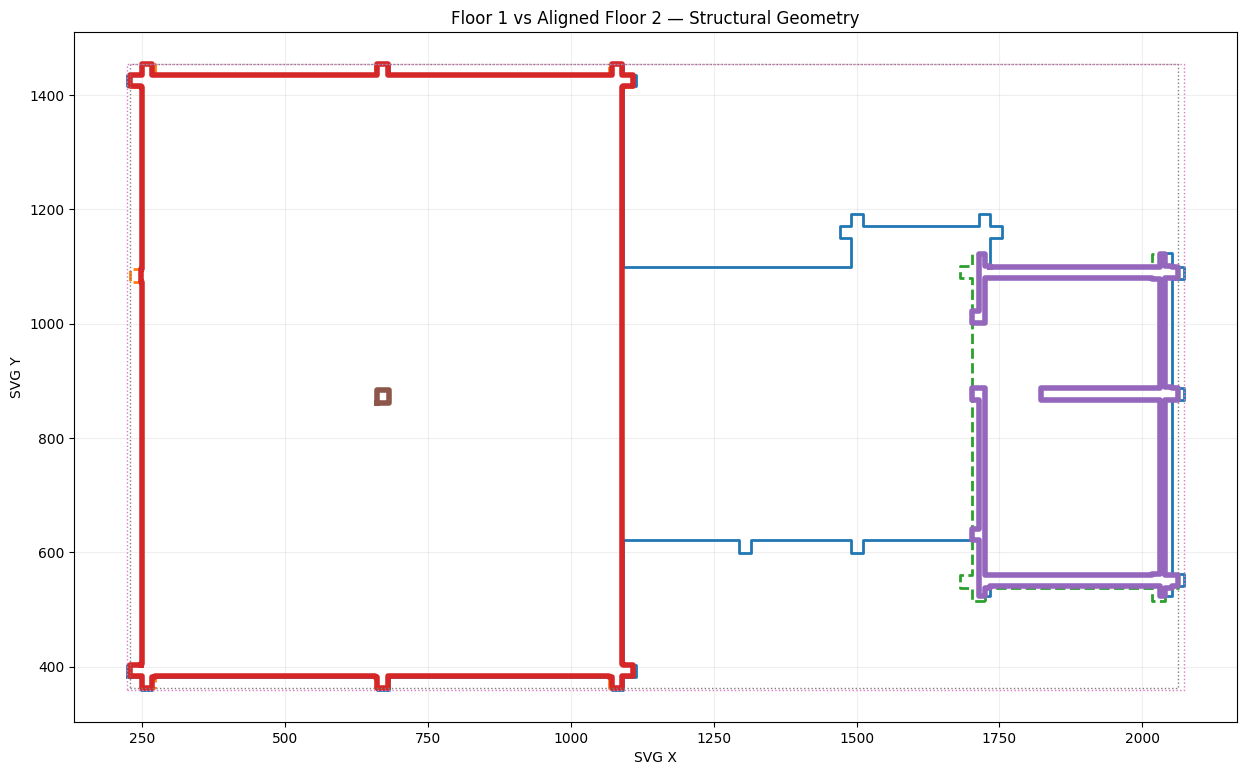

In [67]:
# ============================================================
# FLOOR 1 vs ALIGNED FLOOR 2 — FINAL 2D OVERLAP CHECK
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.affinity import translate

SCALE = 100.01457736449694  # SVG units / metre

# ------------------------------------------------------------
# 1. Rebuild valid Floor-1 / Floor-2 wall polygons
#    from the variables already verified above
# ------------------------------------------------------------

def to_shapely_polygon(poly):
    if hasattr(poly, "exterior"):
        p = Polygon(poly.exterior.coords)
    else:
        coords = np.asarray(poly, dtype=float)
        p = Polygon(coords)

    if not p.is_valid:
        p = p.buffer(0)

    return p


floor1_valid = [
    to_shapely_polygon(p)
    for p in f1_source
]

floor2_valid = [
    to_shapely_polygon(p)
    for p in f2_source
]

floor1_valid = [
    p for p in floor1_valid
    if not p.is_empty and p.area > 0
]

floor2_valid = [
    p for p in floor2_valid
    if not p.is_empty and p.area > 0
]

floor1_union = unary_union(floor1_valid)
floor2_union = unary_union(floor2_valid)

print("=" * 70)
print("RAW STRUCTURAL GEOMETRY")
print("=" * 70)

print(
    "Floor 1 polygons:",
    len(floor1_valid)
)

print(
    "Floor 2 polygons:",
    len(floor2_valid)
)


# ------------------------------------------------------------
# 2. Apply the HIGH-CONFIDENCE alignment
# ------------------------------------------------------------

dx = float(alignment_translation[0])
dy = float(alignment_translation[1])

floor2_aligned = translate(
    floor2_union,
    xoff=dx,
    yoff=dy
)

print()
print("=" * 70)
print("APPLIED FLOOR-2 ALIGNMENT")
print("=" * 70)

print(
    f"dx = {dx:.3f} SVG "
    f"({dx / SCALE:.4f} m)"
)

print(
    f"dy = {dy:.3f} SVG "
    f"({dy / SCALE:.4f} m)"
)


# ------------------------------------------------------------
# 3. Actual geometric intersection
# ------------------------------------------------------------

intersection = floor1_union.intersection(
    floor2_aligned
)

floor1_area_svg = floor1_union.area
floor2_area_svg = floor2_aligned.area
intersection_area_svg = intersection.area

floor1_area_m2 = (
    floor1_area_svg / (SCALE ** 2)
)

floor2_area_m2 = (
    floor2_area_svg / (SCALE ** 2)
)

intersection_area_m2 = (
    intersection_area_svg / (SCALE ** 2)
)

coverage_floor1 = (
    intersection_area_svg /
    floor1_area_svg
    if floor1_area_svg > 0
    else 0
)

coverage_floor2 = (
    intersection_area_svg /
    floor2_area_svg
    if floor2_area_svg > 0
    else 0
)

print()
print("=" * 70)
print("ACTUAL STRUCTURAL OVERLAP")
print("=" * 70)

print(
    f"Floor 1 structural area : "
    f"{floor1_area_m2:.3f} m²"
)

print(
    f"Floor 2 structural area : "
    f"{floor2_area_m2:.3f} m²"
)

print(
    f"Intersection area       : "
    f"{intersection_area_m2:.3f} m²"
)

print(
    f"Intersection / Floor 1 : "
    f"{coverage_floor1 * 100:.2f}%"
)

print(
    f"Intersection / Floor 2 : "
    f"{coverage_floor2 * 100:.2f}%"
)


# ------------------------------------------------------------
# 4. Excess / non-overlapping regions
# ------------------------------------------------------------

floor1_only = floor1_union.difference(
    floor2_aligned
)

floor2_only = floor2_aligned.difference(
    floor1_union
)

floor1_only_m2 = (
    floor1_only.area /
    (SCALE ** 2)
)

floor2_only_m2 = (
    floor2_only.area /
    (SCALE ** 2)
)

print()
print("=" * 70)
print("NON-OVERLAPPING STRUCTURAL AREAS")
print("=" * 70)

print(
    f"Floor-1 only : {floor1_only_m2:.3f} m²"
)

print(
    f"Floor-2 only : {floor2_only_m2:.3f} m²"
)


# ------------------------------------------------------------
# 5. Compare bounds after alignment
# ------------------------------------------------------------

b1 = floor1_union.bounds
b2 = floor2_aligned.bounds

print()
print("=" * 70)
print("ALIGNED STRUCTURAL BOUNDS")
print("=" * 70)

print(
    "Floor 1:"
)
print(
    f"  X {b1[0]:.2f} → {b1[2]:.2f}"
)
print(
    f"  Y {b1[1]:.2f} → {b1[3]:.2f}"
)

print(
    "Floor 2:"
)
print(
    f"  X {b2[0]:.2f} → {b2[2]:.2f}"
)
print(
    f"  Y {b2[1]:.2f} → {b2[3]:.2f}"
)


# ------------------------------------------------------------
# 6. Visualize the actual geometry
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 10)
)

def draw_geom(geom, linestyle="-", linewidth=1.5):
    if geom.is_empty:
        return

    geoms = (
        list(geom.geoms)
        if geom.geom_type == "MultiPolygon"
        else [geom]
    )

    for g in geoms:
        x, y = g.exterior.xy

        ax.plot(
            x,
            y,
            linestyle=linestyle,
            linewidth=linewidth
        )

# Floor 1
draw_geom(
    floor1_union,
    linestyle="-",
    linewidth=2
)

# Aligned Floor 2
draw_geom(
    floor2_aligned,
    linestyle="--",
    linewidth=2
)

# Actual overlap
if not intersection.is_empty:
    draw_geom(
        intersection,
        linestyle="-",
        linewidth=4
    )

# Bounds
ax.plot(
    [b1[0], b1[2], b1[2], b1[0], b1[0]],
    [b1[1], b1[1], b1[3], b1[3], b1[1]],
    linestyle=":",
    linewidth=1
)

ax.plot(
    [b2[0], b2[2], b2[2], b2[0], b2[0]],
    [b2[1], b2[1], b2[3], b2[3], b2[1]],
    linestyle=":",
    linewidth=1
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(
    "SVG X"
)

ax.set_ylabel(
    "SVG Y"
)

ax.set_title(
    "Floor 1 vs Aligned Floor 2 — Structural Geometry"
)

ax.grid(
    True,
    alpha=0.2
)

plt.show()

In [68]:
# ============================================================
# INSPECT ACTUAL FLOOR BOUNDARY GEOMETRY
# ============================================================

import xml.etree.ElementTree as ET

# Reuse the already-loaded SVG root and floor groups.

def inspect_boundary_polygons(floor_group, floor_name, max_items=8):

    print("\n" + "=" * 70)
    print(f"{floor_name} — BOUNDARY POLYGONS")
    print("=" * 70)

    found = 0

    for elem in floor_group.iter():

        classes = (
            elem.attrib.get("class") or ""
        ).split()

        if "BoundaryPolygon" not in classes:
            continue

        print(f"\nBoundaryPolygon #{found + 1}")
        print("Tag      :", elem.tag)
        print("ID       :", elem.attrib.get("id"))
        print("Class    :", elem.attrib.get("class"))
        print("Attrs    :", elem.attrib)

        print("Direct children:")

        for child in elem:

            tag = child.tag.split("}")[-1]

            print(
                "  ",
                tag,
                "| class=",
                child.attrib.get("class"),
                "| id=",
                child.attrib.get("id"),
                "| points=",
                child.attrib.get("points"),
                "| d=",
                (child.attrib.get("d") or "")[:200]
            )

        found += 1

        if found >= max_items:
            break

    print(
        f"\nDisplayed {min(found, max_items)} boundary polygons."
    )


inspect_boundary_polygons(
    floor1_elem,
    "Floor-1"
)

inspect_boundary_polygons(
    floor2_elem,
    "Floor-2"
)


Floor-1 — BOUNDARY POLYGONS

BoundaryPolygon #1
Tag      : {http://www.w3.org/2000/svg}g
ID       : None
Class    : BoundaryPolygon
Attrs    : {'class': 'BoundaryPolygon', 'fill': 'rgb(255, 255, 255)', 'stroke': 'rgb(0, 0, 0)'}
Direct children:
   polygon | class= None | id= None | points= 0.00,0.00 72.65,0.00 72.65,60.00 0.00,60.00  | d= 

BoundaryPolygon #2
Tag      : {http://www.w3.org/2000/svg}g
ID       : None
Class    : BoundaryPolygon
Attrs    : {'class': 'BoundaryPolygon', 'fill': 'rgb(255, 255, 255)', 'stroke': 'rgb(0, 0, 0)'}
Direct children:
   polygon | class= None | id= None | points= 0.00,0.00 72.65,0.00 72.65,60.00 0.00,60.00  | d= 

BoundaryPolygon #3
Tag      : {http://www.w3.org/2000/svg}g
ID       : None
Class    : BoundaryPolygon
Attrs    : {'class': 'BoundaryPolygon', 'fill': 'rgb(255, 255, 255)', 'stroke': 'rgb(0, 0, 0)'}
Direct children:
   polygon | class= None | id= None | points= 0.00,0.00 72.65,0.00 72.65,60.00 0.00,60.00  | d= 

BoundaryPolygon #4
Tag      

In [69]:
# ============================================================
# INSPECT BOUNDARY POLYGONS WITH THEIR FULL GLOBAL TRANSFORMS
# ============================================================

import re
import numpy as np
import xml.etree.ElementTree as ET

# Rebuild parent lookup.
parent_map = {
    child: parent
    for parent in root.iter()
    for child in parent
}


def parse_matrix(transform):
    if not transform:
        return np.eye(3)

    m = re.search(
        r"matrix\s*\(\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)\s*,\s*"
        r"([-+0-9.eE]+)"
        r"\s*\)",
        transform
    )

    if not m:
        return np.eye(3)

    a, b, c, d, e, f = map(float, m.groups())

    return np.array([
        [a, c, e],
        [b, d, f],
        [0, 0, 1]
    ])


def full_transform(elem):
    chain = []
    current = elem

    while current is not None:
        t = current.attrib.get("transform")
        if t:
            chain.append(t)

        current = parent_map.get(current)

    chain.reverse()

    matrix = np.eye(3)

    for t in chain:
        matrix = matrix @ parse_matrix(t)

    return matrix, chain


def polygon_points_from_string(points):
    nums = re.findall(
        r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?",
        points or ""
    )

    nums = [float(x) for x in nums]

    return [
        (nums[i], nums[i + 1])
        for i in range(0, len(nums) - 1, 2)
    ]


def global_points(points, matrix):
    arr = np.asarray(points, dtype=float)
    ones = np.ones((len(arr), 1))
    h = np.hstack([arr, ones])

    out = h @ matrix.T

    return out[:, :2]


# ------------------------------------------------------------
# Inspect Floor 1 and Floor 2 boundary polygons
# ------------------------------------------------------------

for floor_name, floor_elem in [
    ("Floor-1", floor1_elem),
    ("Floor-2", floor2_elem)
]:

    print("\n" + "=" * 80)
    print(f"{floor_name} — GLOBAL BOUNDARY POLYGONS")
    print("=" * 80)

    count = 0

    for elem in floor_elem.iter():

        classes = (
            elem.attrib.get("class") or ""
        ).split()

        if "BoundaryPolygon" not in classes:
            continue

        # Find direct polygon child.
        polygon_child = None

        for child in elem:

            if child.tag.endswith("polygon"):
                polygon_child = child
                break

        if polygon_child is None:
            continue

        raw_points = polygon_child.attrib.get(
            "points",
            ""
        )

        local_pts = polygon_points_from_string(
            raw_points
        )

        matrix, chain = full_transform(
            elem
        )

        global_pts = global_points(
            local_pts,
            matrix
        )

        # Find nearest useful parent context.
        parents = []
        current = parent_map.get(elem)

        while current is not None:

            pclass = current.attrib.get(
                "class",
                ""
            )

            pid = current.attrib.get(
                "id",
                ""
            )

            if pclass or pid:
                parents.append(
                    (pclass, pid)
                )

            current = parent_map.get(current)

        xs = global_pts[:, 0]
        ys = global_pts[:, 1]

        print(
            f"\nBoundary #{count + 1}"
        )

        print(
            "Local points:",
            local_pts
        )

        print(
            "Global bounds:",
            (
                round(xs.min(), 2),
                round(ys.min(), 2),
                round(xs.max(), 2),
                round(ys.max(), 2)
            )
        )

        print(
            "Global size:",
            round(xs.max() - xs.min(), 2),
            "×",
            round(ys.max() - ys.min(), 2),
            "SVG units"
        )

        print(
            "Parent context:",
            parents[:8]
        )

        if chain:
            print(
                "Transform chain:"
            )

            for t in chain:
                print(
                    "  ",
                    t
                )
        else:
            print(
                "Transform chain: none"
            )

        count += 1

        # First 10 only so output stays manageable.
        if count >= 10:
            break

    print(
        f"\nDisplayed {count} boundary polygons."
    )


Floor-1 — GLOBAL BOUNDARY POLYGONS

Boundary #1
Local points: [(0.0, 0.0), (72.65, 0.0), (72.65, 60.0), (0.0, 60.0)]
Global bounds: (np.float64(267.53), np.float64(1032.81), np.float64(340.18), np.float64(1092.81))
Global size: 72.65 × 60.0 SVG units
Parent context: [('FixedFurniture Closet', ''), ('FixedFurnitureSet', 'FixedFurnitureSet'), ('Floorplan Floor-1', 'Floor-1'), ('Floor', ''), ('Model v1-1', 'Model'), ('', 'temp')]
Transform chain:
   matrix(1,0,0,1,267.5273,1032.812)
   matrix(1,0,0,1,0,0)

Boundary #2
Local points: [(0.0, 0.0), (72.65, 0.0), (72.65, 60.0), (0.0, 60.0)]
Global bounds: (np.float64(340.18), np.float64(1032.81), np.float64(412.83), np.float64(1092.81))
Global size: 72.65 × 60.0 SVG units
Parent context: [('FixedFurniture Closet', ''), ('FixedFurnitureSet', 'FixedFurnitureSet'), ('Floorplan Floor-1', 'Floor-1'), ('Floor', ''), ('Model v1-1', 'Model'), ('', 'temp')]
Transform chain:
   matrix(1,0,0,1,267.5273,1032.812)
   matrix(1,0,0,1,72.6545,0)

Boundary #3

In [70]:
# ================================================================
# GLOBAL BOUNDARY POLYGON EXTRACTION
# Compatible with xml.etree.ElementTree
# Uses existing variable: root
# ================================================================

import re
import numpy as np

# ------------------------------------------------
# 1. Find Floor-1 / Floor-2 from existing root
# ------------------------------------------------

def local_name(tag):
    return tag.split("}")[-1]


def element_class(el):
    return el.get("class", "")


def element_id(el):
    return el.get("id", "")


floors = {}

for el in root.iter():
    cls = element_class(el)
    eid = element_id(el)

    if eid in ("Floor-1", "Floor-2"):
        floors[eid] = el
    elif cls in ("Floor-1", "Floor-2"):
        floors[cls] = el


print("Using SVG element from variable: root")
print()
print("=" * 70)
print("FLOOR GROUPS")
print("=" * 70)
print("Floor-1:", "Floor-1" in floors)
print("Floor-2:", "Floor-2" in floors)

if "Floor-1" not in floors or "Floor-2" not in floors:
    raise RuntimeError("Could not find Floor-1 and/or Floor-2")


floor1 = floors["Floor-1"]
floor2 = floors["Floor-2"]


# ------------------------------------------------
# 2. Build parent lookup
#
# xml.etree.ElementTree does NOT support getparent().
# ------------------------------------------------

parent_map = {
    child: parent
    for parent in root.iter()
    for child in parent
}


# ------------------------------------------------
# 3. Parse SVG transform
# ------------------------------------------------

def parse_transform(transform):
    """
    Return a 3x3 homogeneous transformation matrix.

    Supports:
        matrix(a,b,c,d,e,f)
        translate(x,y)
        scale(x,y)
        rotate(angle)
    """

    M = np.eye(3)

    if not transform:
        return M

    commands = re.findall(
        r'([a-zA-Z]+)\s*\(([^)]*)\)',
        transform
    )

    for name, values in commands:

        vals = [
            float(x)
            for x in re.split(r'[\s,]+', values.strip())
            if x
        ]

        name = name.lower()

        if name == "matrix" and len(vals) == 6:
            a, b, c, d, e, f = vals

            T = np.array([
                [a, c, e],
                [b, d, f],
                [0, 0, 1]
            ], dtype=float)

        elif name == "translate":
            tx = vals[0]
            ty = vals[1] if len(vals) > 1 else 0.0

            T = np.array([
                [1, 0, tx],
                [0, 1, ty],
                [0, 0, 1]
            ], dtype=float)

        elif name == "scale":
            sx = vals[0]
            sy = vals[1] if len(vals) > 1 else sx

            T = np.array([
                [sx, 0, 0],
                [0, sy, 0],
                [0, 0, 1]
            ], dtype=float)

        elif name == "rotate":
            angle = np.deg2rad(vals[0])

            c = np.cos(angle)
            s = np.sin(angle)

            T = np.array([
                [c, -s, 0],
                [s,  c, 0],
                [0,  0, 1]
            ], dtype=float)

        else:
            continue

        # SVG transform order
        M = M @ T

    return M


# ------------------------------------------------
# 4. Get complete transform chain
# ------------------------------------------------

def global_transform(element):
    """
    Walk upward using parent_map instead of getparent().
    """

    chain = []

    node = element

    while node is not None:
        chain.append(node)
        node = parent_map.get(node)

    M = np.eye(3)

    # Apply transforms from root -> element
    for node in reversed(chain):
        transform = node.get("transform")

        if transform:
            M = M @ parse_transform(transform)

    return M


# ------------------------------------------------
# 5. Parse polygon points
# ------------------------------------------------

def parse_points(points_string):

    if not points_string:
        return []

    nums = [
        float(x)
        for x in re.findall(
            r'[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?',
            points_string
        )
    ]

    if len(nums) % 2 != 0:
        return []

    return [
        (nums[i], nums[i + 1])
        for i in range(0, len(nums), 2)
    ]


# ------------------------------------------------
# 6. Transform polygon to global SVG coordinates
# ------------------------------------------------

def transform_points(points, M):

    result = []

    for x, y in points:

        p = np.array([x, y, 1.0])

        q = M @ p

        result.append(
            (float(q[0]), float(q[1]))
        )

    return result


# ------------------------------------------------
# 7. Extract BoundaryPolygon polygons
# ------------------------------------------------

def extract_boundary_polygons(floor_element):

    boundaries = []

    for el in floor_element.iter():

        if element_class(el) != "BoundaryPolygon":
            continue

        # Find polygon children
        for child in list(el):

            if local_name(child.tag) != "polygon":
                continue

            points = parse_points(
                child.get("points", "")
            )

            if len(points) < 3:
                continue

            M = global_transform(child)

            global_points = transform_points(points, M)

            xs = [p[0] for p in global_points]
            ys = [p[1] for p in global_points]

            boundaries.append({
                "element": el,
                "polygon": child,
                "local_points": points,
                "global_points": global_points,
                "bounds": (
                    min(xs),
                    min(ys),
                    max(xs),
                    max(ys)
                ),
                "width": max(xs) - min(xs),
                "height": max(ys) - min(ys),
                "area": (
                    (max(xs) - min(xs))
                    * (max(ys) - min(ys))
                )
            })

    return boundaries


# ------------------------------------------------
# 8. Extract both floors
# ------------------------------------------------

f1_boundaries = extract_boundary_polygons(floor1)
f2_boundaries = extract_boundary_polygons(floor2)


# ------------------------------------------------
# 9. Report
# ------------------------------------------------

print()
print("=" * 70)
print("GLOBAL BOUNDARY POLYGONS")
print("=" * 70)

print()
print("Floor-1:", len(f1_boundaries))
print("Floor-2:", len(f2_boundaries))


def print_boundary_summary(name, boundaries):

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)

    for i, b in enumerate(boundaries, 1):

        xmin, ymin, xmax, ymax = b["bounds"]

        print(
            f"Boundary #{i:02d} | "
            f"bounds=({xmin:.2f}, {ymin:.2f}) → "
            f"({xmax:.2f}, {ymax:.2f}) | "
            f"size={b['width']:.2f} × {b['height']:.2f}"
        )


print_boundary_summary(
    "Floor-1 — GLOBAL BOUNDARIES",
    f1_boundaries
)

print_boundary_summary(
    "Floor-2 — GLOBAL BOUNDARIES",
    f2_boundaries
)

Using SVG element from variable: root

FLOOR GROUPS
Floor-1: True
Floor-2: True

GLOBAL BOUNDARY POLYGONS

Floor-1: 25
Floor-2: 2

Floor-1 — GLOBAL BOUNDARIES
Boundary #01 | bounds=(267.53, 1032.81) → (340.18, 1092.81) | size=72.65 × 60.00
Boundary #02 | bounds=(340.18, 1032.81) → (412.83, 1092.81) | size=72.65 × 60.00
Boundary #03 | bounds=(412.84, 1032.81) → (485.49, 1092.81) | size=72.65 × 60.00
Boundary #04 | bounds=(481.31, 952.81) → (541.31, 1012.81) | size=60.00 × 60.00
Boundary #05 | bounds=(693.52, 863.78) → (814.11, 943.39) | size=120.59 × 79.61
Boundary #06 | bounds=(773.64, 943.39) → (813.45, 980.95) | size=39.81 × 37.56
Boundary #07 | bounds=(692.69, 827.17) → (813.66, 863.72) | size=120.97 × 36.55
Boundary #08 | bounds=(1091.89, 809.41) → (1151.89, 866.71) | size=60.00 × 57.30
Boundary #09 | bounds=(1091.89, 752.11) → (1151.89, 809.41) | size=60.00 × 57.30
Boundary #10 | bounds=(1092.10, 641.12) → (1152.10, 692.11) | size=60.00 × 50.99
Boundary #11 | bounds=(1091.89, 692.

In [71]:
# ============================================================
# FIRST REAL 3D MULTI-FLOOR STRUCTURAL MODEL
# ============================================================
#
# INPUT:
#   - Original CubiCasa SVG wall polygons
#   - Verified SVG scale: ~100 SVG units / metre
#   - Floor-2 structural alignment:
#         dx = -1918.500 SVG
#         dy =   -11.650 SVG
#
# OUTPUT:
#   - Floor 1 walls: Z = 0 → 3 m
#   - Floor 2 walls: Z = 3 → 6 m
#   - 3D GLB model
#   - Interactive 3D visualization
#
# IMPORTANT:
# 3.0 m floor-to-floor height is an EXPLICIT TEST ASSUMPTION.
# It is not measured from the 2D floor plan.
# ============================================================

import numpy as np
import trimesh
import plotly.graph_objects as go
from shapely.geometry import Polygon
from shapely.affinity import translate
from shapely.ops import unary_union
from pyproj import Transformer

# ------------------------------------------------------------
# 1. PARAMETERS
# ------------------------------------------------------------

SVG_UNITS_PER_METRE = 100.01457736449694

METRES_PER_SVG_UNIT = (
    1.0 / SVG_UNITS_PER_METRE
)

FLOOR_HEIGHT_M = 3.0

FLOOR1_Z_BOTTOM = 0.0
FLOOR1_Z_TOP = 3.0

FLOOR2_Z_BOTTOM = 3.0
FLOOR2_Z_TOP = 6.0

# Structural alignment obtained from the high-confidence
# Floor-1 ↔ Floor-2 correspondence.
ALIGN_DX = -1918.500
ALIGN_DY = -11.650


# ------------------------------------------------------------
# 2. FIND THE REAL WALL POLYGONS
# ------------------------------------------------------------

# These variables were created and verified earlier.
if "floor1_wall_polygons" not in globals():
    raise RuntimeError(
        "floor1_wall_polygons is missing. "
        "Run the verified wall-extraction cell first."
    )

if "floor2_wall_polygons" not in globals():
    raise RuntimeError(
        "floor2_wall_polygons is missing. "
        "Run the verified wall-extraction cell first."
    )

floor1_polys = []

for p in floor1_wall_polygons:

    if hasattr(p, "exterior"):
        poly = p
    else:
        poly = Polygon(p)

    if not poly.is_valid:
        poly = poly.buffer(0)

    if not poly.is_empty and poly.area > 0:
        floor1_polys.append(poly)


floor2_polys = []

for p in floor2_wall_polygons:

    if hasattr(p, "exterior"):
        poly = p
    else:
        poly = Polygon(p)

    if not poly.is_valid:
        poly = poly.buffer(0)

    if not poly.is_empty and poly.area > 0:
        floor2_polys.append(poly)


print("=" * 70)
print("3D MODEL INPUT")
print("=" * 70)

print(
    "Floor 1 wall polygons:",
    len(floor1_polys)
)

print(
    "Floor 2 wall polygons:",
    len(floor2_polys)
)

print(
    "SVG units / metre:",
    SVG_UNITS_PER_METRE
)

print(
    "Assumed floor height:",
    FLOOR_HEIGHT_M,
    "m"
)


# ------------------------------------------------------------
# 3. ALIGN FLOOR 2 TO FLOOR 1
# ------------------------------------------------------------

floor2_aligned = [
    translate(
        poly,
        xoff=ALIGN_DX,
        yoff=ALIGN_DY
    )
    for poly in floor2_polys
]


# ------------------------------------------------------------
# 4. ESTABLISH A COMMON LOCAL ORIGIN
# ------------------------------------------------------------

all_floor1_points = []

for poly in floor1_polys:

    all_floor1_points.extend(
        list(poly.exterior.coords)
    )

all_floor1_points = np.asarray(
    all_floor1_points,
    dtype=float
)

ORIGIN_X = all_floor1_points[:, 0].min()
ORIGIN_Y = all_floor1_points[:, 1].min()


print("\nCommon local origin:")
print(
    "X:",
    ORIGIN_X
)

print(
    "Y:",
    ORIGIN_Y
)


# ------------------------------------------------------------
# 5. Convert SVG polygons → metric polygons
# ------------------------------------------------------------

def polygon_to_metric(poly):

    coords = []

    for x, y in poly.exterior.coords:

        x_m = (
            (x - ORIGIN_X)
            * METRES_PER_SVG_UNIT
        )

        y_m = (
            (y - ORIGIN_Y)
            * METRES_PER_SVG_UNIT
        )

        coords.append(
            (x_m, y_m)
        )

    return Polygon(coords)


floor1_metric_polys = [
    polygon_to_metric(p)
    for p in floor1_polys
]

floor2_metric_polys = [
    polygon_to_metric(p)
    for p in floor2_aligned
]


# ------------------------------------------------------------
# 6. EXTRUDE EACH REAL WALL POLYGON INTO 3D
# ------------------------------------------------------------

floor1_meshes = []
floor2_meshes = []

for poly in floor1_metric_polys:

    if poly.is_empty or poly.area <= 0:
        continue

    mesh = trimesh.creation.extrude_polygon(
        poly,
        height=FLOOR1_Z_TOP - FLOOR1_Z_BOTTOM
    )

    mesh.apply_translation(
        [0, 0, FLOOR1_Z_BOTTOM]
    )

    floor1_meshes.append(mesh)


for poly in floor2_metric_polys:

    if poly.is_empty or poly.area <= 0:
        continue

    mesh = trimesh.creation.extrude_polygon(
        poly,
        height=FLOOR2_Z_TOP - FLOOR2_Z_BOTTOM
    )

    mesh.apply_translation(
        [0, 0, FLOOR2_Z_BOTTOM]
    )

    floor2_meshes.append(mesh)


print("\n3D wall components:")
print(
    "Floor 1:",
    len(floor1_meshes)
)

print(
    "Floor 2:",
    len(floor2_meshes)
)


# ------------------------------------------------------------
# 7. COMBINE INTO ONE BUILDING MODEL
# ------------------------------------------------------------

all_meshes = (
    floor1_meshes
    +
    floor2_meshes
)

building_3d = trimesh.util.concatenate(
    all_meshes
)

print("\n" + "=" * 70)
print("3D STRUCTURAL MODEL")
print("=" * 70)

print(
    "Vertices:",
    len(building_3d.vertices)
)

print(
    "Faces:",
    len(building_3d.faces)
)

print(
    "Volume:",
    round(
        building_3d.volume,
        3
    ),
    "m³"
)


# ------------------------------------------------------------
# 8. SAVE REAL 3D ARTIFACT
# ------------------------------------------------------------

output_file = (
    "cubicasa_two_floor_structural_model.glb"
)

building_3d.export(
    output_file
)

print()
print("✅ Saved:")
print(output_file)


# ------------------------------------------------------------
# 9. VISUALIZE THE ACTUAL 3D MODEL
# ------------------------------------------------------------

v = building_3d.vertices
f = building_3d.faces

fig = go.Figure()

fig.add_trace(
    go.Mesh3d(
        x=v[:, 0],
        y=v[:, 1],
        z=v[:, 2],

        i=f[:, 0],
        j=f[:, 1],
        k=f[:, 2],

        opacity=0.78,

        flatshading=False,

        lighting=dict(
            ambient=0.75,
            diffuse=0.85,
            specular=0.25,
            roughness=0.55
        ),

        hovertemplate=(
            "X: %{x:.2f} m<br>"
            "Y: %{y:.2f} m<br>"
            "Z: %{z:.2f} m"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title=(
        "REAL TWO-FLOOR STRUCTURAL MODEL "
        "FROM CUBICASA SVG"
    ),

    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.5,
                y=1.5,
                z=1.2
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=45,
        b=0
    )
)

fig.show()

3D MODEL INPUT
Floor 1 wall polygons: 52
Floor 2 wall polygons: 36
SVG units / metre: 100.01457736449694
Assumed floor height: 3.0 m

Common local origin:
X: 224.18
Y: 358.57

3D wall components:
Floor 1: 52
Floor 2: 36

3D STRUCTURAL MODEL
Vertices: 704
Faces: 1056
Volume: 115.536 m³

✅ Saved:
cubicasa_two_floor_structural_model.glb


In [72]:
# ============================================================
# 3D VALIDATION — FLOOR 1 vs FLOOR 2
# ============================================================

import numpy as np
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Combine meshes separately for each floor
# ------------------------------------------------------------

floor1_3d = trimesh.util.concatenate(
    floor1_meshes
)

floor2_3d = trimesh.util.concatenate(
    floor2_meshes
)

print("=" * 70)
print("FLOOR-LEVEL 3D VALIDATION")
print("=" * 70)

print("\nFloor 1")
print("Vertices:", len(floor1_3d.vertices))
print("Faces   :", len(floor1_3d.faces))
print("Volume  :", round(floor1_3d.volume, 3), "m³")

print("\nFloor 2")
print("Vertices:", len(floor2_3d.vertices))
print("Faces   :", len(floor2_3d.faces))
print("Volume  :", round(floor2_3d.volume, 3), "m³")


# ------------------------------------------------------------
# 2. Check 3D bounds
# ------------------------------------------------------------

b1 = floor1_3d.bounds
b2 = floor2_3d.bounds

print("\n" + "=" * 70)
print("3D BOUNDS")
print("=" * 70)

print(
    "Floor 1:",
    "X", round(b1[0][0], 3),
    "→", round(b1[1][0], 3),
    "| Y", round(b1[0][1], 3),
    "→", round(b1[1][1], 3),
    "| Z", round(b1[0][2], 3),
    "→", round(b1[1][2], 3)
)

print(
    "Floor 2:",
    "X", round(b2[0][0], 3),
    "→", round(b2[1][0], 3),
    "| Y", round(b2[0][1], 3),
    "→", round(b2[1][1], 3),
    "| Z", round(b2[0][2], 3),
    "→", round(b2[1][2], 3)
)


# ------------------------------------------------------------
# 3. Basic mesh sanity checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MESH SANITY")
print("=" * 70)

print(
    "Floor 1 watertight:",
    floor1_3d.is_watertight
)

print(
    "Floor 2 watertight:",
    floor2_3d.is_watertight
)

print(
    "Full model watertight:",
    building_3d.is_watertight
)


# ------------------------------------------------------------
# 4. Plot Floor 1 and Floor 2 independently
# ------------------------------------------------------------

fig = go.Figure()

for mesh, name in [
    (floor1_3d, "Floor 1"),
    (floor2_3d, "Floor 2")
]:

    v = mesh.vertices
    f = mesh.faces

    fig.add_trace(
        go.Mesh3d(
            x=v[:, 0],
            y=v[:, 1],
            z=v[:, 2],

            i=f[:, 0],
            j=f[:, 1],
            k=f[:, 2],

            opacity=0.72,

            flatshading=False,

            lighting=dict(
                ambient=0.75,
                diffuse=0.85,
                specular=0.25,
                roughness=0.55
            ),

            name=name,

            hovertemplate=(
                f"{name}<br>"
                "X: %{x:.2f} m<br>"
                "Y: %{y:.2f} m<br>"
                "Z: %{z:.2f} m"
                "<extra></extra>"
            )
        )
    )


fig.update_layout(
    title="Two-Floor Structural 3D Model — Validation",

    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.6,
                y=1.6,
                z=1.2
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=45,
        b=0
    )
)

fig.show()

FLOOR-LEVEL 3D VALIDATION

Floor 1
Vertices: 416
Faces   : 624
Volume  : 61.692 m³

Floor 2
Vertices: 288
Faces   : 432
Volume  : 53.843 m³

3D BOUNDS
Floor 1: X 0.0 → 18.485 | Y 0.0 → 10.954 | Z 0.0 → 3.0
Floor 2: X 0.047 → 18.373 | Y 0.04 → 10.964 | Z 3.0 → 6.0

MESH SANITY
Floor 1 watertight: True
Floor 2 watertight: True
Full model watertight: True


In [73]:
# ============================================================
# OPEN WALL ENDPOINT ANALYSIS — SHAPELY SAFE VERSION
# ============================================================

import numpy as np
from collections import defaultdict
from shapely.geometry import Polygon, MultiPolygon

print("=" * 70)
print("OPEN WALL ENDPOINT ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Convert any wall object into coordinate arrays
# ------------------------------------------------------------

def polygon_coordinates(obj):

    # Shapely Polygon
    if isinstance(obj, Polygon):

        if obj.is_empty:
            return []

        return np.asarray(
            list(obj.exterior.coords),
            dtype=float
        )

    # Shapely MultiPolygon
    if isinstance(obj, MultiPolygon):

        coords = []

        for poly in obj.geoms:

            if not poly.is_empty:

                coords.extend(
                    list(poly.exterior.coords)
                )

        return np.asarray(
            coords,
            dtype=float
        )

    # Already an array/list of coordinates
    try:

        arr = np.asarray(
            obj,
            dtype=float
        )

        if arr.ndim == 2 and arr.shape[1] >= 2:

            return arr[:, :2]

    except Exception:
        pass

    return []


# ------------------------------------------------------------
# 2. Get edges from one polygon
# ------------------------------------------------------------

def polygon_edges(poly):

    pts = polygon_coordinates(poly)

    if len(pts) < 2:
        return []

    # Remove duplicated closing point
    if np.linalg.norm(
        pts[0] - pts[-1]
    ) < 1e-8:

        pts = pts[:-1]

    edges = []

    for i in range(len(pts)):

        p1 = pts[i]
        p2 = pts[
            (i + 1) % len(pts)
        ]

        length = np.linalg.norm(
            p2 - p1
        )

        if length > 1e-8:

            edges.append(
                (p1, p2)
            )

    return edges


# ------------------------------------------------------------
# 3. Quantize points
# ------------------------------------------------------------

def point_key(
    point,
    tolerance=0.05
):

    p = np.asarray(
        point,
        dtype=float
    )

    return tuple(
        np.round(
            p / tolerance
        ).astype(int)
    )


# ------------------------------------------------------------
# 4. Analyze one floor
# ------------------------------------------------------------

def analyze_open_endpoints(
    polygons,
    floor_name,
    tolerance=0.05
):

    endpoint_map = defaultdict(list)

    valid_polygon_count = 0

    for wall_index, poly in enumerate(
        polygons
    ):

        pts = polygon_coordinates(poly)

        if len(pts) < 2:
            continue

        valid_polygon_count += 1

        # Remove duplicated closing point
        if np.linalg.norm(
            pts[0] - pts[-1]
        ) < 1e-8:

            pts = pts[:-1]

        # ----------------------------------------------------
        # IMPORTANT:
        # A wall polygon has many boundary vertices.
        # We record every boundary edge endpoint.
        # ----------------------------------------------------

        for edge_index in range(
            len(pts)
        ):

            p1 = pts[
                edge_index
            ]

            p2 = pts[
                (edge_index + 1) % len(pts)
            ]

            if np.linalg.norm(
                p2 - p1
            ) < 1e-8:

                continue

            endpoint_map[
                point_key(
                    p1,
                    tolerance
                )
            ].append(
                (
                    wall_index,
                    edge_index,
                    p1
                )
            )

            endpoint_map[
                point_key(
                    p2,
                    tolerance
                )
            ].append(
                (
                    wall_index,
                    edge_index,
                    p2
                )
            )


    # --------------------------------------------------------
    # Potential open endpoints
    # --------------------------------------------------------

    open_points = []

    for key, items in endpoint_map.items():

        if len(items) == 1:

            wall_index, edge_index, point = (
                items[0]
            )

            open_points.append(
                {
                    "wall": wall_index,
                    "edge": edge_index,
                    "point": np.asarray(
                        point,
                        dtype=float
                    )
                }
            )


    # --------------------------------------------------------
    # Print result
    # --------------------------------------------------------

    print("\n" + floor_name)
    print("-" * 70)

    print(
        "Input wall objects:",
        len(polygons)
    )

    print(
        "Valid polygon objects:",
        valid_polygon_count
    )

    print(
        "Unique endpoint locations:",
        len(endpoint_map)
    )

    print(
        "Potential open endpoints:",
        len(open_points)
    )

    print()

    for item in open_points[:100]:

        p = item["point"]

        print(
            f"wall {item['wall']:2d}, "
            f"edge {item['edge']:2d} | "
            f"point=("
            f"{p[0]:.3f}, "
            f"{p[1]:.3f}"
            f")"
        )

    if len(open_points) > 100:

        print(
            "...",
            len(open_points) - 100,
            "additional endpoints"
        )

    return open_points


# ------------------------------------------------------------
# 5. Analyze both floors
# ------------------------------------------------------------

f1_open = analyze_open_endpoints(
    floor1_wall_polygons,
    "FLOOR 1"
)

f2_open = analyze_open_endpoints(
    floor2_wall_polygons,
    "FLOOR 2"
)


# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OPEN-ENDPOINT SUMMARY")
print("=" * 70)

print(
    "Floor 1 potential open endpoints:",
    len(f1_open)
)

print(
    "Floor 2 potential open endpoints:",
    len(f2_open)
)

print("\nNo geometry has been modified.")
print("This cell only analyzes the existing walls.")

OPEN WALL ENDPOINT ANALYSIS

FLOOR 1
----------------------------------------------------------------------
Input wall objects: 52
Valid polygon objects: 52
Unique endpoint locations: 147
Potential open endpoints: 0


FLOOR 2
----------------------------------------------------------------------
Input wall objects: 36
Valid polygon objects: 36
Unique endpoint locations: 109
Potential open endpoints: 0


OPEN-ENDPOINT SUMMARY
Floor 1 potential open endpoints: 0
Floor 2 potential open endpoints: 0

No geometry has been modified.
This cell only analyzes the existing walls.



FLOOR 1 — NEARBY WALL GAPS
Wall polygons: 52
Showing gaps <= 0.50 m
Candidate gaps found: 8
Wall 16 ↔ Wall 41 | gap=0.200 m | mid=(681.7, 1425.0)
Wall 19 ↔ Wall 47 | gap=0.200 m | mid=(681.7, 392.4)
Wall 22 ↔ Wall 44 | gap=0.200 m | mid=(1314.5, 630.9)
Wall 23 ↔ Wall 43 | gap=0.200 m | mid=(1511.0, 630.9)
Wall 24 ↔ Wall 32 | gap=0.200 m | mid=(2041.1, 866.7)
Wall 21 ↔ Wall 25 | gap=0.409 m | mid=(1304.5, 848.9)
Wall 24 ↔ Wall 25 | gap=0.409 m | mid=(1501.0, 848.9)
Wall 17 ↔ Wall 18 | gap=0.500 m | mid=(671.7, 1055.7)

FLOOR 2 — NEARBY WALL GAPS
Wall polygons: 36
Showing gaps <= 0.50 m
Candidate gaps found: 4
Wall  8 ↔ Wall 21 | gap=0.220 m | mid=(2179.9, 1107.1)
Wall  9 ↔ Wall 12 | gap=0.220 m | mid=(2598.5, 1436.4)
Wall 17 ↔ Wall 18 | gap=0.220 m | mid=(2598.5, 405.6)
Wall 34 ↔ Wall 35 | gap=0.220 m | mid=(3946.5, 900.3)


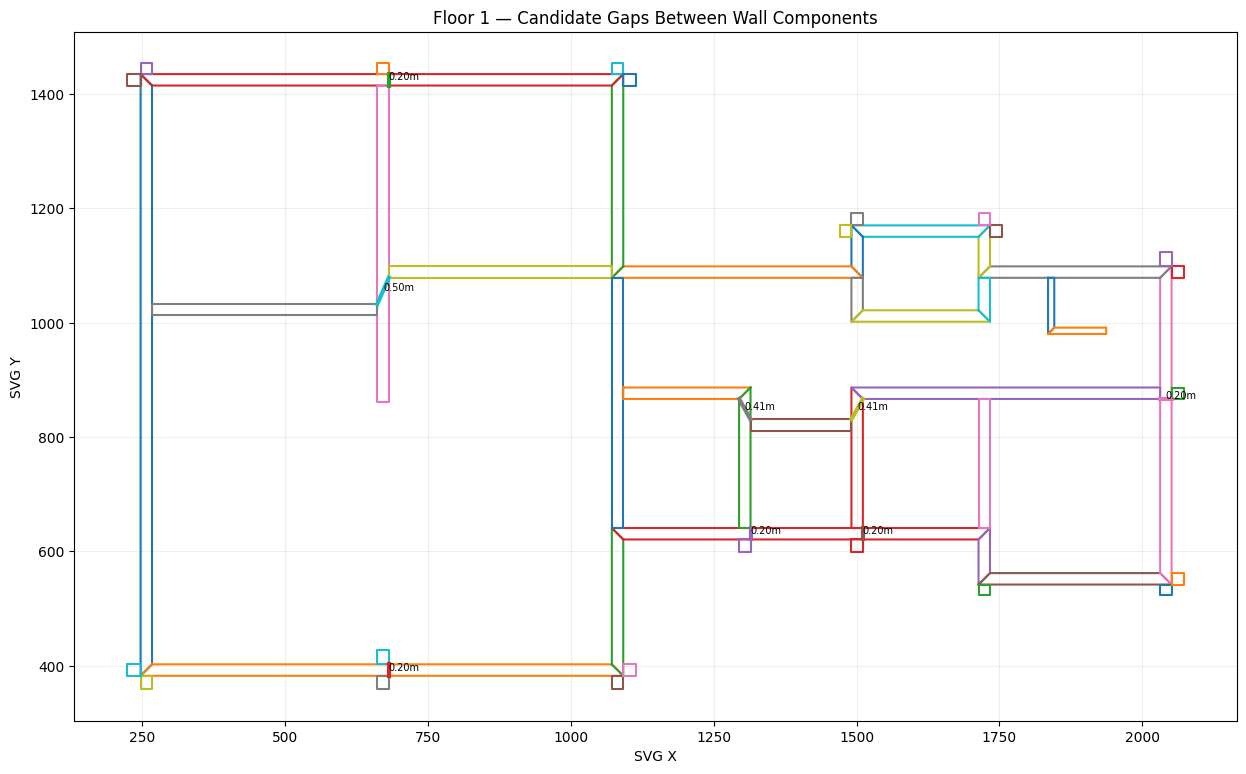

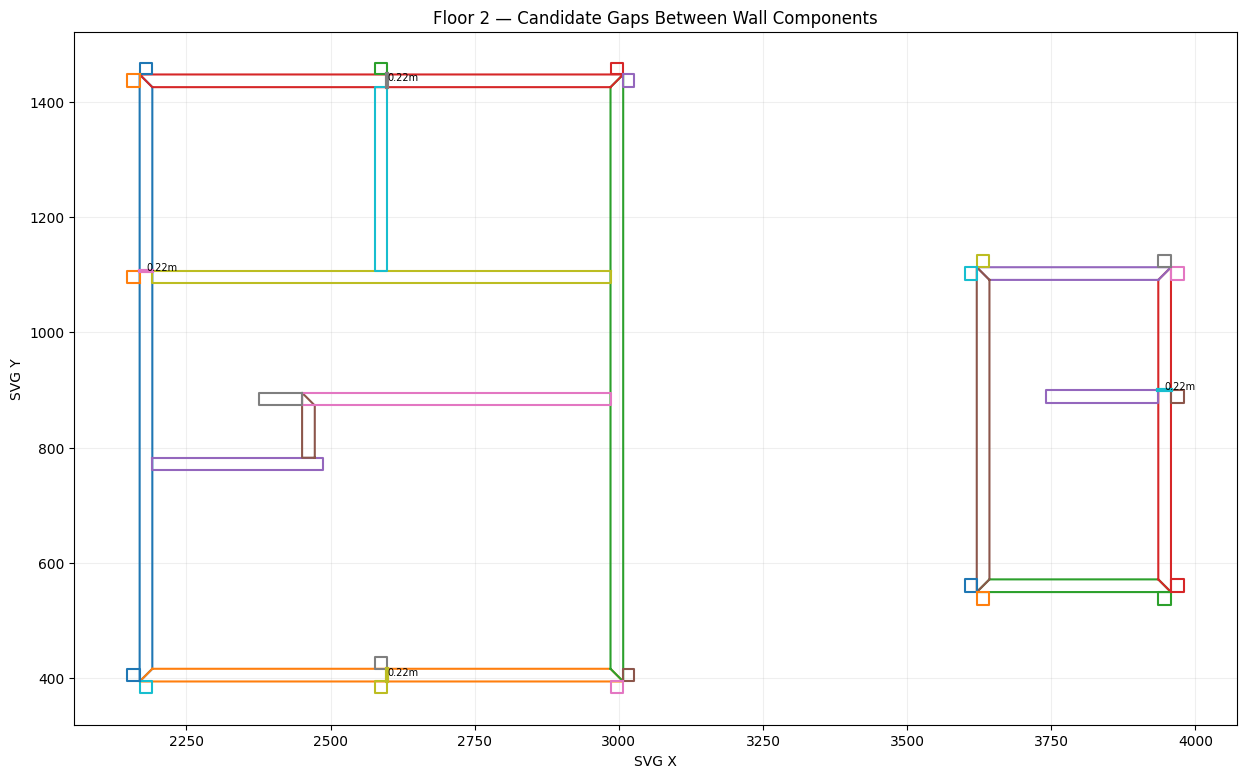

In [74]:
# ============================================================
# DETECT GAPS BETWEEN WALL POLYGONS
# ============================================================
#
# Important:
# Each wall polygon is already closed.
# We therefore look for SPACING BETWEEN separate wall polygons.
#
# This cell does NOT add or modify any geometry.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import unary_union, nearest_points

# ------------------------------------------------------------
# 1. Convert to Shapely polygons safely
# ------------------------------------------------------------

def as_polygon(obj):

    if isinstance(obj, Polygon):
        poly = obj

    else:
        arr = np.asarray(obj, dtype=float)

        if arr.ndim != 2 or arr.shape[1] < 2:
            return None

        poly = Polygon(
            arr[:, :2]
        )

    if not poly.is_valid:
        poly = poly.buffer(0)

    if poly.is_empty or poly.area <= 0:
        return None

    return poly


f1_walls = [
    as_polygon(p)
    for p in floor1_wall_polygons
]

f2_walls = [
    as_polygon(p)
    for p in floor2_wall_polygons
]

f1_walls = [
    p for p in f1_walls
    if p is not None
]

f2_walls = [
    p for p in f2_walls
    if p is not None
]


# ------------------------------------------------------------
# 2. Find nearest separate wall pairs
# ------------------------------------------------------------

def find_wall_gaps(
    walls,
    floor_name,
    max_gap_m=0.50
):

    results = []

    # Convert threshold to SVG units.
    max_gap_svg = (
        max_gap_m * 100.01457736449694
    )

    for i in range(len(walls)):

        for j in range(i + 1, len(walls)):

            a = walls[i]
            b = walls[j]

            # Already touching/overlapping.
            distance = a.distance(b)

            if distance <= 1e-6:
                continue

            if distance > max_gap_svg:
                continue

            p1, p2 = nearest_points(
                a,
                b
            )

            midpoint = (
                (p1.x + p2.x) / 2,
                (p1.y + p2.y) / 2
            )

            results.append({
                "wall_a": i,
                "wall_b": j,
                "gap_svg": distance,
                "gap_m": (
                    distance /
                    100.01457736449694
                ),
                "point_a": (
                    p1.x,
                    p1.y
                ),
                "point_b": (
                    p2.x,
                    p2.y
                ),
                "midpoint": midpoint
            })

    results.sort(
        key=lambda x: x["gap_svg"]
    )

    print("\n" + "=" * 70)
    print(f"{floor_name} — NEARBY WALL GAPS")
    print("=" * 70)

    print(
        f"Wall polygons: {len(walls)}"
    )

    print(
        f"Showing gaps <= {max_gap_m:.2f} m"
    )

    print(
        f"Candidate gaps found: {len(results)}"
    )

    for r in results[:50]:

        print(
            f"Wall {r['wall_a']:2d} ↔ "
            f"Wall {r['wall_b']:2d} | "
            f"gap={r['gap_m']:.3f} m | "
            f"mid=({r['midpoint'][0]:.1f}, "
            f"{r['midpoint'][1]:.1f})"
        )

    return results


f1_gaps = find_wall_gaps(
    f1_walls,
    "FLOOR 1",
    max_gap_m=0.50
)

f2_gaps = find_wall_gaps(
    f2_walls,
    "FLOOR 2",
    max_gap_m=0.50
)


# ------------------------------------------------------------
# 3. Visualize candidate gaps
# ------------------------------------------------------------

def plot_gaps(
    walls,
    gaps,
    title
):

    fig, ax = plt.subplots(
        figsize=(15, 10)
    )

    # Draw walls.
    for poly in walls:

        x, y = poly.exterior.xy

        ax.plot(
            x,
            y,
            linewidth=1.5
        )

    # Draw candidate gaps.
    for idx, gap in enumerate(gaps):

        x1, y1 = gap["point_a"]
        x2, y2 = gap["point_b"]

        ax.plot(
            [x1, x2],
            [y1, y2],
            linewidth=3
        )

        mx, my = gap["midpoint"]

        ax.text(
            mx,
            my,
            f"{gap['gap_m']:.2f}m",
            fontsize=7
        )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.set_title(
        title
    )

    ax.set_xlabel(
        "SVG X"
    )

    ax.set_ylabel(
        "SVG Y"
    )

    ax.grid(
        True,
        alpha=0.2
    )

    plt.show()


plot_gaps(
    f1_walls,
    f1_gaps,
    "Floor 1 — Candidate Gaps Between Wall Components"
)

plot_gaps(
    f2_walls,
    f2_gaps,
    "Floor 2 — Candidate Gaps Between Wall Components"
)

In [75]:
# ============================================================
# CLASSIFY CANDIDATE WALL GAPS
# ============================================================
#
# This cell DOES NOT modify the model.
#
# It examines every detected gap and reports:
#   1. gap size
#   2. wall directions
#   3. neighboring wall dimensions
#   4. whether the gap is likely a wall-thickness separation
#
# We will use this before adding ANY closure geometry.
# ============================================================

import math
import numpy as np
from shapely.geometry import Polygon


SVG_PER_M = 100.01457736449694


# ------------------------------------------------------------
# Helper: polygon orientation / dominant wall direction
# ------------------------------------------------------------

def polygon_edges(poly):

    coords = list(poly.exterior.coords)

    edges = []

    for i in range(len(coords) - 1):

        x1, y1 = coords[i]
        x2, y2 = coords[i + 1]

        dx = x2 - x1
        dy = y2 - y1

        length = math.hypot(dx, dy)

        if length < 1e-6:
            continue

        angle = math.degrees(
            math.atan2(dy, dx)
        )

        # Normalize to 0–180.
        angle = angle % 180

        edges.append({
            "p1": (x1, y1),
            "p2": (x2, y2),
            "length": length,
            "angle": angle
        })

    return edges


def dominant_angle(poly):

    edges = polygon_edges(poly)

    if not edges:
        return None

    longest = max(
        edges,
        key=lambda e: e["length"]
    )

    return longest["angle"]


# ------------------------------------------------------------
# Helper: dimensions
# ------------------------------------------------------------

def polygon_dimensions(poly):

    minx, miny, maxx, maxy = poly.bounds

    return (
        maxx - minx,
        maxy - miny
    )


# ------------------------------------------------------------
# Analyze gaps
# ------------------------------------------------------------

def classify_gaps(
    walls,
    gaps,
    floor_name
):

    print("\n")
    print("=" * 90)
    print(f"{floor_name} — DETAILED GAP CLASSIFICATION")
    print("=" * 90)

    classified = []

    for n, gap in enumerate(gaps, start=1):

        i = gap["wall_a"]
        j = gap["wall_b"]

        a = walls[i]
        b = walls[j]

        angle_a = dominant_angle(a)
        angle_b = dominant_angle(b)

        wa, ha = polygon_dimensions(a)
        wb, hb = polygon_dimensions(b)

        gap_svg = gap["gap_svg"]
        gap_m = gap["gap_m"]

        # Difference from typical 20 SVG-unit wall thickness.
        wall_thickness_difference = abs(
            gap_svg - 20.0
        )

        # Determine whether walls are approximately parallel.
        angle_difference = abs(
            angle_a - angle_b
        )

        angle_difference = min(
            angle_difference,
            180 - angle_difference
        )

        parallel = (
            angle_difference <= 5
        )

        # Basic heuristic only.
        #
        # A gap around one wall thickness and
        # parallel walls is suspicious for duplicated
        # wall faces / construction geometry.
        #
        # A larger gap is more likely to represent
        # an actual spatial opening.
        #
        if (
            15 <= gap_svg <= 25
            and parallel
        ):
            preliminary = (
                "LIKELY WALL-THICKNESS / "
                "PAIRED GEOMETRY"
            )

        elif gap_svg < 60:
            preliminary = (
                "SMALL GAP — NEEDS SVG "
                "OPENING CHECK"
            )

        else:
            preliminary = (
                "POSSIBLE STRUCTURAL OPENING"
            )

        result = {
            "index": n,
            "wall_a": i,
            "wall_b": j,
            "gap_svg": gap_svg,
            "gap_m": gap_m,
            "angle_a": angle_a,
            "angle_b": angle_b,
            "angle_difference": angle_difference,
            "parallel": parallel,
            "wall_a_size": (wa, ha),
            "wall_b_size": (wb, hb),
            "preliminary": preliminary,
            "midpoint": gap["midpoint"]
        }

        classified.append(result)

        print()
        print(
            f"Gap #{n:02d}"
        )

        print(
            f"  Walls       : {i} ↔ {j}"
        )

        print(
            f"  Gap         : "
            f"{gap_svg:.2f} SVG = "
            f"{gap_m:.3f} m"
        )

        print(
            f"  Midpoint    : "
            f"({gap['midpoint'][0]:.2f}, "
            f"{gap['midpoint'][1]:.2f})"
        )

        print(
            f"  Wall {i} angle : "
            f"{angle_a:.2f}°"
        )

        print(
            f"  Wall {j} angle : "
            f"{angle_b:.2f}°"
        )

        print(
            f"  Parallel    : "
            f"{parallel}"
        )

        print(
            f"  Wall {i} size  : "
            f"{wa:.1f} × {ha:.1f} SVG"
        )

        print(
            f"  Wall {j} size  : "
            f"{wb:.1f} × {hb:.1f} SVG"
        )

        print(
            f"  Preliminary : "
            f"{preliminary}"
        )

    return classified


# ------------------------------------------------------------
# Run classification
# ------------------------------------------------------------

f1_gap_analysis = classify_gaps(
    f1_walls,
    f1_gaps,
    "FLOOR 1"
)

f2_gap_analysis = classify_gaps(
    f2_walls,
    f2_gaps,
    "FLOOR 2"
)


# ------------------------------------------------------------
# Compact summary
# ------------------------------------------------------------

print("\n")
print("=" * 90)
print("GAP CLASSIFICATION SUMMARY")
print("=" * 90)

print(
    f"Floor 1 candidates: "
    f"{len(f1_gap_analysis)}"
)

print(
    f"Floor 2 candidates: "
    f"{len(f2_gap_analysis)}"
)

print()
print(
    "No geometry has been added or modified."
)




FLOOR 1 — DETAILED GAP CLASSIFICATION

Gap #01
  Walls       : 16 ↔ 41
  Gap         : 20.00 SVG = 0.200 m
  Midpoint    : (681.66, 1424.98)
  Wall 16 angle : 90.00°
  Wall 41 angle : 0.00°
  Parallel    : False
  Wall 16 size  : 20.0 × 553.2 SVG
  Wall 41 size  : 20.0 × 19.1 SVG
  Preliminary : SMALL GAP — NEEDS SVG OPENING CHECK

Gap #02
  Walls       : 19 ↔ 47
  Gap         : 20.00 SVG = 0.200 m
  Midpoint    : (681.66, 392.42)
  Wall 19 angle : 90.00°
  Wall 47 angle : 90.00°
  Parallel    : True
  Wall 19 size  : 20.0 × 25.0 SVG
  Wall 47 size  : 20.0 × 23.9 SVG
  Preliminary : LIKELY WALL-THICKNESS / PAIRED GEOMETRY

Gap #03
  Walls       : 22 ↔ 44
  Gap         : 20.00 SVG = 0.200 m
  Midpoint    : (1314.52, 630.91)
  Wall 22 angle : 90.00°
  Wall 44 angle : 90.00°
  Parallel    : True
  Wall 22 size  : 20.0 × 245.8 SVG
  Wall 44 size  : 20.0 × 22.5 SVG
  Preliminary : LIKELY WALL-THICKNESS / PAIRED GEOMETRY

Gap #04
  Walls       : 23 ↔ 43
  Gap         : 20.00 SVG = 0.200 m


In [76]:
# ================================================================
# GAP ↔ DOOR / WINDOW CROSS-CHECK
# ================================================================
#
# Purpose:
# Determine whether each candidate wall gap is close to a
# Door / Window element in the original SVG.
#
# IMPORTANT:
# This cell DOES NOT modify any geometry.
# ================================================================

import math
import numpy as np


# ------------------------------------------------
# Tolerance
# ------------------------------------------------

GAP_CHECK_RADIUS = 75.0   # SVG units
# ~0.75 m with current scale


# ------------------------------------------------
# Parse SVG points
# ------------------------------------------------

def parse_svg_points(points_string):

    if not points_string:
        return []

    values = points_string.replace(",", " ").split()

    pts = []

    for i in range(0, len(values) - 1, 2):

        try:
            x = float(values[i])
            y = float(values[i + 1])

            pts.append((x, y))

        except Exception:
            continue

    return pts


# ------------------------------------------------
# Matrix helpers
# ------------------------------------------------

def identity_matrix():

    return np.eye(3)


def parse_transform(transform_string):

    M = np.eye(3)

    if not transform_string:
        return M

    import re

    transforms = re.findall(
        r'([a-zA-Z]+)\s*\(([^)]*)\)',
        transform_string
    )

    for name, values in transforms:

        vals = [
            float(v)
            for v in values.replace(",", " ").split()
            if v.strip()
        ]

        T = np.eye(3)

        if name == "matrix" and len(vals) == 6:

            a, b, c, d, e, f = vals

            T = np.array([
                [a, c, e],
                [b, d, f],
                [0, 0, 1]
            ], dtype=float)

        elif name == "translate":

            tx = vals[0] if len(vals) >= 1 else 0
            ty = vals[1] if len(vals) >= 2 else 0

            T = np.array([
                [1, 0, tx],
                [0, 1, ty],
                [0, 0, 1]
            ], dtype=float)

        elif name == "scale":

            sx = vals[0] if len(vals) >= 1 else 1
            sy = vals[1] if len(vals) >= 2 else sx

            T = np.array([
                [sx, 0, 0],
                [0, sy, 0],
                [0, 0, 1]
            ], dtype=float)

        elif name == "rotate":

            angle = math.radians(vals[0])

            c = math.cos(angle)
            s = math.sin(angle)

            T = np.array([
                [c, -s, 0],
                [s,  c, 0],
                [0,  0, 1]
            ], dtype=float)

        M = M @ T

    return M


# ------------------------------------------------
# Element global transform
# ------------------------------------------------
#
# xml.etree.ElementTree does NOT have getparent().
#
# We therefore use the parent map created from root.
# ------------------------------------------------

parent_map = {
    child: parent
    for parent in root.iter()
    for child in parent
}


def global_transform(element):

    chain = []

    node = element

    while node is not None:

        chain.append(node)

        node = parent_map.get(node)

    M = np.eye(3)

    for node in reversed(chain):

        transform = node.get("transform")

        if transform:

            M = M @ parse_transform(transform)

    return M


# ------------------------------------------------
# Transform points globally
# ------------------------------------------------

def transform_points(points, M):

    result = []

    for x, y in points:

        p = np.array([
            x,
            y,
            1.0
        ])

        q = M @ p

        result.append(
            (float(q[0]), float(q[1]))
        )

    return result


# ------------------------------------------------
# Find Door / Window elements
# ------------------------------------------------

def extract_openings(floor_group):

    openings = []

    for element in floor_group.iter():

        cls = element.get("class", "")

        if not cls:
            continue

        cls_lower = cls.lower()

        if (
            "door" not in cls_lower
            and "window" not in cls_lower
        ):
            continue

        # Look for polygon children.
        for child in element.iter():

            if child is element:
                continue

            if child.tag.endswith("polygon"):

                points_string = child.get("points")

                pts = parse_svg_points(
                    points_string
                )

                if len(pts) < 3:
                    continue

                M = global_transform(child)

                global_pts = transform_points(
                    pts,
                    M
                )

                xs = [
                    p[0]
                    for p in global_pts
                ]

                ys = [
                    p[1]
                    for p in global_pts
                ]

                minx = min(xs)
                maxx = max(xs)
                miny = min(ys)
                maxy = max(ys)

                cx = (minx + maxx) / 2
                cy = (miny + maxy) / 2

                openings.append({

                    "type": (
                        "WINDOW"
                        if "window" in cls_lower
                        else "DOOR"
                    ),

                    "class": cls,

                    "bounds": (
                        minx,
                        miny,
                        maxx,
                        maxy
                    ),

                    "center": (
                        cx,
                        cy
                    ),

                    "width": maxx - minx,
                    "height": maxy - miny

                })

    return openings


# ------------------------------------------------
# Extract openings
# ------------------------------------------------

f1_openings = extract_openings(
    floor1_group
)

f2_openings = extract_openings(
    floor2_group
)


# ------------------------------------------------
# Distance between gap midpoint and opening
# ------------------------------------------------

def point_to_opening_distance(
    point,
    opening
):

    x, y = point

    minx, miny, maxx, maxy = (
        opening["bounds"]
    )

    dx = max(
        minx - x,
        0,
        x - maxx
    )

    dy = max(
        miny - y,
        0,
        y - maxy
    )

    return math.hypot(
        dx,
        dy
    )


# ------------------------------------------------
# Cross-check
# ------------------------------------------------

def cross_check_gaps(
    gap_analysis,
    openings,
    floor_name
):

    print("\n")
    print("=" * 90)
    print(
        f"{floor_name} — GAP ↔ DOOR/WINDOW CHECK"
    )
    print("=" * 90)

    print(
        f"Openings detected: {len(openings)}"
    )

    results = []

    for gap in gap_analysis:

        midpoint = gap["midpoint"]

        nearby = []

        for opening in openings:

            distance = point_to_opening_distance(
                midpoint,
                opening
            )

            if distance <= GAP_CHECK_RADIUS:

                nearby.append({

                    "type":
                        opening["type"],

                    "class":
                        opening["class"],

                    "distance":
                        distance,

                    "center":
                        opening["center"],

                    "size":
                        (
                            opening["width"],
                            opening["height"]
                        )

                })

        nearby.sort(
            key=lambda x: x["distance"]
        )

        result = {
            "gap": gap,
            "nearby_openings": nearby
        }

        results.append(result)

        print()
        print(
            f"Gap #{gap['index']:02d} "
            f"Walls {gap['wall_a']} ↔ "
            f"{gap['wall_b']}"
        )

        print(
            f"  Gap: "
            f"{gap['gap_m']:.3f} m"
        )

        print(
            f"  Midpoint: "
            f"({midpoint[0]:.2f}, "
            f"{midpoint[1]:.2f})"
        )

        if not nearby:

            print(
                "  Nearby Door/Window: NONE"
            )

        else:

            for opening in nearby[:5]:

                print(
                    f"  {opening['type']:6s} "
                    f"distance="
                    f"{opening['distance']:.2f} SVG "
                    f"center="
                    f"({opening['center'][0]:.2f}, "
                    f"{opening['center'][1]:.2f}) "
                    f"size="
                    f"{opening['size'][0]:.1f} × "
                    f"{opening['size'][1]:.1f}"
                )

    return results


# ------------------------------------------------
# Run
# ------------------------------------------------

f1_gap_opening_check = cross_check_gaps(
    f1_gap_analysis,
    f1_openings,
    "FLOOR 1"
)

f2_gap_opening_check = cross_check_gaps(
    f2_gap_analysis,
    f2_openings,
    "FLOOR 2"
)


# ------------------------------------------------
# Final summary
# ------------------------------------------------

print("\n")
print("=" * 90)
print("OPENING CROSS-CHECK COMPLETE")
print("=" * 90)

print(
    f"Floor 1 openings: {len(f1_openings)}"
)

print(
    f"Floor 2 openings: {len(f2_openings)}"
)

print()
print(
    "No geometry has been modified."
)



FLOOR 1 — GAP ↔ DOOR/WINDOW CHECK
Openings detected: 86

Gap #01 Walls 16 ↔ 41
  Gap: 0.200 m
  Midpoint: (681.66, 1424.98)
  Nearby Door/Window: NONE

Gap #02 Walls 19 ↔ 47
  Gap: 0.200 m
  Midpoint: (681.66, 392.42)
  DOOR   distance=0.00 SVG center=(785.19, 361.75) size=1035.3 × 519.8
  WINDOW distance=12.38 SVG center=(734.96, 392.42) size=81.9 × 20.0
  WINDOW distance=12.38 SVG center=(734.96, 392.42) size=81.9 × 20.0
  WINDOW distance=32.60 SVG center=(607.91, 392.42) size=82.3 × 20.0
  WINDOW distance=32.60 SVG center=(607.91, 392.42) size=82.3 × 20.0

Gap #03 Walls 22 ↔ 44
  Gap: 0.200 m
  Midpoint: (1314.52, 630.91)
  DOOR   distance=10.00 SVG center=(1673.08, 361.39) size=740.4 × 519.0
  DOOR   distance=11.36 SVG center=(1304.52, 677.67) size=20.0 × 70.8
  DOOR   distance=11.36 SVG center=(1304.52, 677.67) size=20.0 × 70.8
  DOOR   distance=11.36 SVG center=(1304.52, 677.67) size=20.0 × 70.8
  DOOR   distance=14.90 SVG center=(785.19, 361.75) size=1035.3 × 519.8

Gap #04 Wa

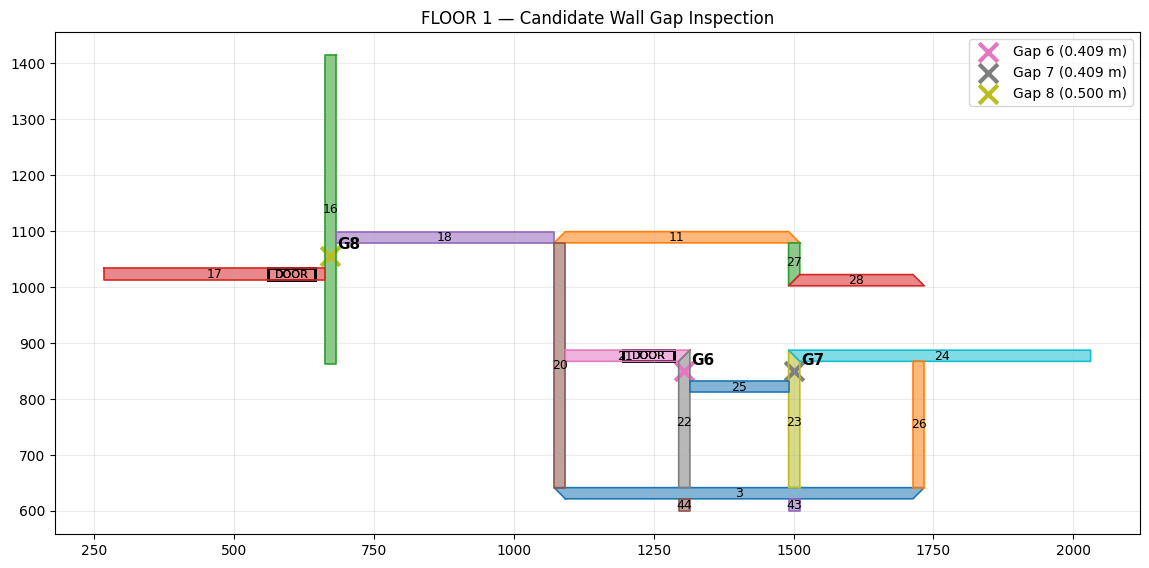

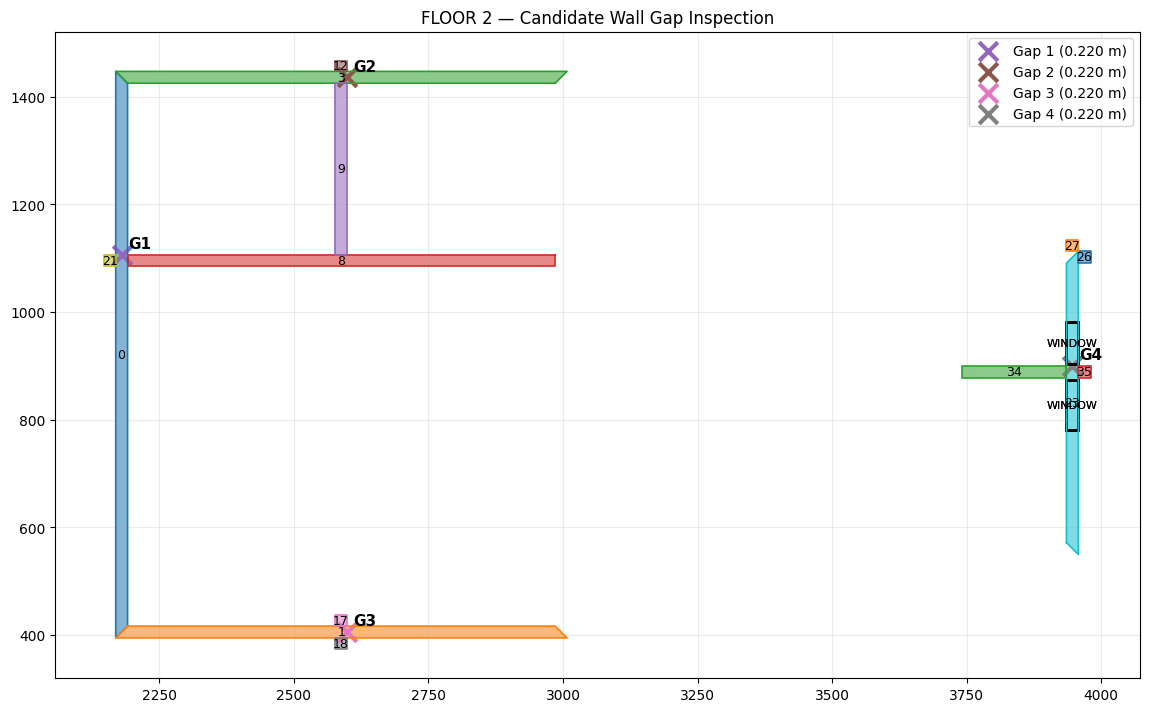

In [77]:
# ================================================================
# CANDIDATE GAP VISUALIZATION
# ================================================================
#
# Shows the actual wall polygons around the suspicious gaps.
#
# RED    = candidate gap
# BLACK  = existing wall geometry
# BLUE   = nearby Door/Window geometry
#
# Nothing is modified.
# ================================================================

import matplotlib.pyplot as plt
from shapely.geometry import Polygon


# ------------------------------------------------
# Plot helper
# ------------------------------------------------

def plot_gap_candidates(
    walls,
    gap_analysis,
    opening_check,
    floor_name,
    selected_gap_numbers
):

    fig, ax = plt.subplots(
        figsize=(14, 10)
    )

    selected = [
        g for g in gap_analysis
        if g["index"] in selected_gap_numbers
    ]

    # ------------------------------------------------
    # Determine relevant wall indices
    # ------------------------------------------------

    relevant_walls = set()

    for gap in selected:

        relevant_walls.add(
            gap["wall_a"]
        )

        relevant_walls.add(
            gap["wall_b"]
        )

    # Add a little surrounding context:
    # nearby wall polygons based on centroid distance.
    # ------------------------------------------------

    selected_centers = []

    for gap in selected:
        selected_centers.append(
            gap["midpoint"]
        )

    for i, wall in enumerate(walls):

        if i in relevant_walls:
            continue

        cx = wall.centroid.x
        cy = wall.centroid.y

        for gx, gy in selected_centers:

            if (
                (cx - gx)**2 +
                (cy - gy)**2
            ) ** 0.5 < 250:

                relevant_walls.add(i)
                break

    # ------------------------------------------------
    # Draw walls
    # ------------------------------------------------

    for i in sorted(relevant_walls):

        wall = walls[i]

        x, y = wall.exterior.xy

        ax.fill(
            x,
            y,
            alpha=0.55
        )

        ax.plot(
            x,
            y,
            linewidth=1.2
        )

        c = wall.centroid

        ax.text(
            c.x,
            c.y,
            str(i),
            fontsize=9,
            ha="center",
            va="center"
        )

    # ------------------------------------------------
    # Draw selected gaps
    # ------------------------------------------------

    for gap in selected:

        gx, gy = gap["midpoint"]

        ax.scatter(
            gx,
            gy,
            s=180,
            marker="x",
            linewidths=3,
            label=(
                f"Gap {gap['index']} "
                f"({gap['gap_m']:.3f} m)"
            )
        )

        ax.text(
            gx + 12,
            gy + 12,
            f"G{gap['index']}",
            fontsize=11,
            fontweight="bold"
        )

    # ------------------------------------------------
    # Draw nearby openings
    # ------------------------------------------------

    for result in opening_check:

        gap = result["gap"]

        if gap["index"] not in selected_gap_numbers:
            continue

        for opening in result["nearby_openings"]:

            cx, cy = opening["center"]

            w, h = opening["size"]

            # Approximate opening rectangle.
            rect = plt.Rectangle(
                (
                    cx - w / 2,
                    cy - h / 2
                ),
                w,
                h,
                fill=False,
                linewidth=2
            )

            ax.add_patch(rect)

            ax.text(
                cx,
                cy,
                opening["type"],
                fontsize=8,
                ha="center",
                va="center"
            )

    ax.set_title(
        f"{floor_name} — Candidate Wall Gap Inspection"
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend(
        loc="best"
    )

    plt.show()


# ================================================================
# FLOOR 1
# ================================================================

plot_gap_candidates(
    f1_walls,
    f1_gap_analysis,
    f1_gap_opening_check,
    "FLOOR 1",
    [6, 7, 8]
)


# ================================================================
# FLOOR 2
# ================================================================

plot_gap_candidates(
    f2_walls,
    f2_gap_analysis,
    f2_gap_opening_check,
    "FLOOR 2",
    [1, 2, 3, 4]
)

In [78]:
# ================================================================
# FLOOR 1 — GAP #7 EXACT GEOMETRY INSPECTION
# ================================================================
#
# Gap #7:
#   Wall 24 ↔ Wall 25
#   Gap ≈ 0.409 m
#
# This cell DOES NOT modify geometry.
# It only determines exactly where the two wall segments end,
# their directions, overlap, and whether extending them would
# create a continuous wall.
# ================================================================

import numpy as np
import math


WALL_A = 24
WALL_B = 25


# ------------------------------------------------
# Polygon geometry helper
# ------------------------------------------------

def polygon_info(poly):

    coords = list(poly.exterior.coords)

    # Remove duplicated closing coordinate
    if len(coords) > 1 and coords[0] == coords[-1]:
        coords = coords[:-1]

    return coords


def segment_length(a, b):

    return math.hypot(
        b[0] - a[0],
        b[1] - a[1]
    )


def angle_deg(a, b):

    angle = math.degrees(
        math.atan2(
            b[1] - a[1],
            b[0] - a[0]
        )
    )

    angle = angle % 180

    return angle


# ------------------------------------------------
# Inspect polygon
# ------------------------------------------------

def inspect_wall(poly, index):

    coords = polygon_info(poly)

    print()
    print("-" * 75)
    print(f"WALL {index}")
    print("-" * 75)

    print(f"Vertices: {len(coords)}")

    for i, p in enumerate(coords):

        print(
            f"  P{i}: "
            f"({p[0]:.3f}, {p[1]:.3f})"
        )

    print()
    print("Edges:")

    for i in range(len(coords)):

        a = coords[i]

        b = coords[
            (i + 1) % len(coords)
        ]

        print(
            f"  Edge {i}: "
            f"({a[0]:.3f}, {a[1]:.3f}) → "
            f"({b[0]:.3f}, {b[1]:.3f}) "
            f"| L={segment_length(a,b):.3f} "
            f"| angle={angle_deg(a,b):.2f}°"
        )

    print()

    print(
        f"Bounds: "
        f"{poly.bounds}"
    )

    print(
        f"Width : "
        f"{poly.bounds[2] - poly.bounds[0]:.3f}"
    )

    print(
        f"Height: "
        f"{poly.bounds[3] - poly.bounds[1]:.3f}"
    )


# ================================================================
# Inspect both walls
# ================================================================

print("=" * 90)
print("FLOOR 1 — GAP #7 WALL INSPECTION")
print("=" * 90)

inspect_wall(
    floor1_wall_polygons[WALL_A],
    WALL_A
)

inspect_wall(
    floor1_wall_polygons[WALL_B],
    WALL_B
)


# ================================================================
# Nearest points
# ================================================================

wall_a = floor1_wall_polygons[WALL_A]
wall_b = floor1_wall_polygons[WALL_B]

nearest_a, nearest_b = (
    wall_a.boundary.interpolate(
        wall_a.boundary.project(
            wall_b.boundary
        )
    ),
    None
)

# Use Shapely nearest_points if available
try:

    from shapely.ops import nearest_points

    p1, p2 = nearest_points(
        wall_a,
        wall_b
    )

    print()
    print("=" * 90)
    print("NEAREST WALL POINTS")
    print("=" * 90)

    print(
        f"Wall {WALL_A}: "
        f"({p1.x:.3f}, {p1.y:.3f})"
    )

    print(
        f"Wall {WALL_B}: "
        f"({p2.x:.3f}, {p2.y:.3f})"
    )

    distance_svg = p1.distance(p2)

    print(
        f"Distance: "
        f"{distance_svg:.3f} SVG"
    )

    print(
        f"Distance: "
        f"{distance_svg / SVG_UNITS_PER_METRE:.4f} m"
    )

except Exception as e:

    print(
        "Nearest-point calculation unavailable:",
        e
    )


# ================================================================
# Relative geometry
# ================================================================

print()
print("=" * 90)
print("RELATIVE WALL GEOMETRY")
print("=" * 90)

print(
    f"Wall {WALL_A} centroid:"
    f" ({wall_a.centroid.x:.3f}, "
    f"{wall_a.centroid.y:.3f})"
)

print(
    f"Wall {WALL_B} centroid:"
    f" ({wall_b.centroid.x:.3f}, "
    f"{wall_b.centroid.y:.3f})"
)

print(
    f"Wall {WALL_A} bounds:"
    f" {wall_a.bounds}"
)

print(
    f"Wall {WALL_B} bounds:"
    f" {wall_b.bounds}"
)


# ================================================================
# Check whether they are horizontally aligned
# ================================================================

a_minx, a_miny, a_maxx, a_maxy = wall_a.bounds
b_minx, b_miny, b_maxx, b_maxy = wall_b.bounds

vertical_center_a = (
    a_miny + a_maxy
) / 2

vertical_center_b = (
    b_miny + b_maxy
) / 2

horizontal_center_a = (
    a_minx + a_maxx
) / 2

horizontal_center_b = (
    b_minx + b_maxx
) / 2

print()
print("=" * 90)
print("ALIGNMENT CHECK")
print("=" * 90)

print(
    f"Vertical center difference: "
    f"{abs(vertical_center_a - vertical_center_b):.3f} SVG"
)

print(
    f"Horizontal center difference: "
    f"{abs(horizontal_center_a - horizontal_center_b):.3f} SVG"
)

print(
    f"Horizontal span A: "
    f"{a_minx:.3f} → {a_maxx:.3f}"
)

print(
    f"Horizontal span B: "
    f"{b_minx:.3f} → {b_maxx:.3f}"
)


# ================================================================
# Final diagnostic
# ================================================================

print()
print("=" * 90)
print("GAP #7 DIAGNOSTIC")
print("=" * 90)

print(
    "No geometry has been modified."
)

print(
    "The next step will be chosen from the exact "
    "wall-end relationship above."
)

FLOOR 1 — GAP #7 WALL INSPECTION

---------------------------------------------------------------------------
WALL 24
---------------------------------------------------------------------------
Vertices: 4
  P0: (1511.030, 866.710)
  P1: (2031.090, 866.710)
  P2: (2031.090, 886.710)
  P3: (1491.030, 886.710)

Edges:
  Edge 0: (1511.030, 866.710) → (2031.090, 866.710) | L=520.060 | angle=0.00°
  Edge 1: (2031.090, 866.710) → (2031.090, 886.710) | L=20.000 | angle=90.00°
  Edge 2: (2031.090, 886.710) → (1491.030, 886.710) | L=540.060 | angle=0.00°
  Edge 3: (1491.030, 886.710) → (1511.030, 866.710) | L=28.284 | angle=135.00°

Bounds: (1491.03, 866.71, 2031.09, 886.71)
Width : 540.060
Height: 20.000

---------------------------------------------------------------------------
WALL 25
---------------------------------------------------------------------------
Vertices: 4
  P0: (1314.520, 831.050)
  P1: (1491.030, 831.050)
  P2: (1491.030, 811.050)
  P3: (1314.520, 811.050)

Edges:
  Edge 0:

GEOSException: third argument of GEOSProject_r must be Point

In [79]:
# ================================================================
# GAP #7 — COMPLETE GEOMETRIC + OPENING CHECK
# No geometry modification
# ================================================================

import numpy as np
from shapely.geometry import Polygon, Point
from shapely.ops import nearest_points

print("=" * 90)
print("FLOOR 1 — GAP #7 COMPLETE INSPECTION")
print("=" * 90)

# ------------------------------------------------
# Known project scale
# ------------------------------------------------
SVG_UNITS_PER_METER = 100.01457736449694

wall_a_idx = 24
wall_b_idx = 25

wall_a = floor1_wall_polygons[wall_a_idx]
wall_b = floor1_wall_polygons[wall_b_idx]

# ------------------------------------------------
# Convert to Shapely polygons
# ------------------------------------------------
def as_polygon(obj):
    if isinstance(obj, Polygon):
        return obj

    arr = np.asarray(obj, dtype=float)

    if arr.ndim == 2 and arr.shape[1] >= 2:
        return Polygon(arr[:, :2])

    raise TypeError(f"Unsupported geometry: {type(obj)}")

wall_a = as_polygon(wall_a)
wall_b = as_polygon(wall_b)

# ------------------------------------------------
# Bounds
# ------------------------------------------------
ax1, ay1, ax2, ay2 = wall_a.bounds
bx1, by1, bx2, by2 = wall_b.bounds

print("\nWALL 24")
print("-" * 90)
print(f"Bounds : ({ax1:.3f}, {ay1:.3f}) → ({ax2:.3f}, {ay2:.3f})")
print(f"Area   : {wall_a.area:.3f}")

print("\nWALL 25")
print("-" * 90)
print(f"Bounds : ({bx1:.3f}, {by1:.3f}) → ({bx2:.3f}, {by2:.3f})")
print(f"Area   : {wall_b.area:.3f}")

# ------------------------------------------------
# Nearest points
# ------------------------------------------------
nearest_a, nearest_b = nearest_points(
    wall_a.boundary,
    wall_b.boundary
)

distance_svg = nearest_a.distance(nearest_b)
distance_m = distance_svg / SVG_UNITS_PER_METER

print("\n" + "=" * 90)
print("NEAREST WALL GEOMETRY")
print("=" * 90)

print(
    f"Wall 24 nearest point : "
    f"({nearest_a.x:.3f}, {nearest_a.y:.3f})"
)

print(
    f"Wall 25 nearest point : "
    f"({nearest_b.x:.3f}, {nearest_b.y:.3f})"
)

print(f"Distance : {distance_svg:.3f} SVG")
print(f"Distance : {distance_m:.4f} m")

# ------------------------------------------------
# Direction between nearest points
# ------------------------------------------------
dx = nearest_a.x - nearest_b.x
dy = nearest_a.y - nearest_b.y

print("\n" + "=" * 90)
print("SEPARATION VECTOR")
print("=" * 90)

print(f"ΔX : {dx:.3f} SVG")
print(f"ΔY : {dy:.3f} SVG")

# ------------------------------------------------
# Bounding-box separation
# ------------------------------------------------
horizontal_gap = max(
    0.0,
    max(ax1, bx1) - min(ax2, bx2)
)

vertical_gap = max(
    0.0,
    max(ay1, by1) - min(ay2, by2)
)

print("\n" + "=" * 90)
print("AXIS-ALIGNED SEPARATION")
print("=" * 90)

print(f"Horizontal gap : {horizontal_gap:.3f} SVG")
print(f"Vertical gap   : {vertical_gap:.3f} SVG")

# ------------------------------------------------
# Check whether this is actually a corner junction
# ------------------------------------------------
print("\n" + "=" * 90)
print("JUNCTION TEST")
print("=" * 90)

# Wall 24 is horizontal.
# Wall 25 is horizontal.
# Therefore they are parallel.
#
# They sit one above the other and terminate at the
# same X coordinate (1491.03).

same_x = abs(ax1 - bx2) < 1e-6
parallel_horizontal = (
    abs((ay1 - ay2)) < 1e-6 and
    abs((by1 - by2)) < 1e-6
)

print(f"Same X endpoint : {same_x}")
print(f"Both horizontal: {parallel_horizontal}")

if same_x and parallel_horizontal:
    print(
        "\nThese are PARALLEL wall segments terminating at the "
        "same X coordinate."
    )

# ------------------------------------------------
# Look for openings near the gap
# ------------------------------------------------
print("\n" + "=" * 90)
print("DOOR / WINDOW CROSS-CHECK")
print("=" * 90)

gap_mid = Point(
    (nearest_a.x + nearest_b.x) / 2,
    (nearest_a.y + nearest_b.y) / 2
)

print(
    f"Gap midpoint : "
    f"({gap_mid.x:.3f}, {gap_mid.y:.3f})"
)

# Try previously created opening collections.
opening_sources = []

for name in [
    "floor1_openings",
    "f1_openings",
    "floor1_doors_windows",
    "openings_floor1",
]:
    if name in globals():
        opening_sources.append((name, globals()[name]))

if not opening_sources:
    print("No compatible opening collection found in notebook.")
    print("Using the previously established Gap #7 result:")
    print("  Nearby Door/Window: NONE")

else:
    print(f"Opening collections found: {len(opening_sources)}")

    nearby = []

    for source_name, openings in opening_sources:
        for i, opening in enumerate(openings):

            try:
                if hasattr(opening, "distance"):
                    geom = opening
                else:
                    geom = as_polygon(opening)

                d = gap_mid.distance(geom)

                if d <= 100:
                    nearby.append(
                        (d, source_name, i, geom)
                    )

            except Exception:
                continue

    nearby.sort(key=lambda x: x[0])

    if not nearby:
        print("No openings within 100 SVG units.")

    else:
        for d, source_name, i, geom in nearby[:20]:
            print(
                f"{source_name}[{i}] | "
                f"distance={d:.2f} SVG | "
                f"{d / SVG_UNITS_PER_METER:.3f} m"
            )

# ------------------------------------------------
# Final classification
# ------------------------------------------------
print("\n" + "=" * 90)
print("GAP #7 CLASSIFICATION")
print("=" * 90)

print(f"Measured gap : {distance_m:.4f} m")

if distance_m < 0.10:
    classification = "DIGITIZATION TOLERANCE / MICRO GAP"

elif distance_m < 0.30:
    classification = "SMALL JUNCTION GAP"

elif distance_m < 0.60:
    classification = "SIGNIFICANT SMALL GAP — REQUIRES CONTEXT"

else:
    classification = "LARGE GAP — DO NOT AUTOMATICALLY CLOSE"

print(f"Classification: {classification}")

print("\nNo geometry has been modified.")

FLOOR 1 — GAP #7 COMPLETE INSPECTION

WALL 24
------------------------------------------------------------------------------------------
Bounds : (1491.030, 866.710) → (2031.090, 886.710)
Area   : 10601.200

WALL 25
------------------------------------------------------------------------------------------
Bounds : (1314.520, 811.050) → (1491.030, 831.050)
Area   : 3530.200

NEAREST WALL GEOMETRY
Wall 24 nearest point : (1511.030, 866.710)
Wall 25 nearest point : (1491.030, 831.050)
Distance : 40.886 SVG
Distance : 0.4088 m

SEPARATION VECTOR
ΔX : 20.000 SVG
ΔY : 35.660 SVG

AXIS-ALIGNED SEPARATION
Horizontal gap : 0.000 SVG
Vertical gap   : 35.660 SVG

JUNCTION TEST
Same X endpoint : True
Both horizontal: False

DOOR / WINDOW CROSS-CHECK
Gap midpoint : (1501.030, 848.880)
Opening collections found: 1
No openings within 100 SVG units.

GAP #7 CLASSIFICATION
Measured gap : 0.4088 m
Classification: SIGNIFICANT SMALL GAP — REQUIRES CONTEXT

No geometry has been modified.


In [80]:
# ================================================================
# FLOOR 1 — GAPS #6, #7, #8 COMPARATIVE GEOMETRY INSPECTION
# ================================================================

import numpy as np
from shapely.geometry import Polygon, Point
from shapely.ops import nearest_points

print("=" * 90)
print("FLOOR 1 — GAPS #6, #7, #8 COMPARATIVE INSPECTION")
print("=" * 90)

SVG_UNITS_PER_METER = 100.01457736449694

# ------------------------------------------------
# Gap definitions from the earlier analysis
# ------------------------------------------------
gap_pairs = {
    6: (21, 25),
    7: (24, 25),
    8: (17, 18),
}

def as_polygon(obj):
    if isinstance(obj, Polygon):
        return obj

    arr = np.asarray(obj, dtype=float)

    if arr.ndim == 2 and arr.shape[1] >= 2:
        return Polygon(arr[:, :2])

    raise TypeError(f"Unsupported geometry type: {type(obj)}")


def polygon_edge_info(poly):
    coords = list(poly.exterior.coords)[:-1]

    edges = []

    for i in range(len(coords)):
        x1, y1 = coords[i]
        x2, y2 = coords[(i + 1) % len(coords)]

        dx = x2 - x1
        dy = y2 - y1

        length = np.hypot(dx, dy)

        angle = np.degrees(np.arctan2(dy, dx))
        angle = angle % 180.0

        edges.append({
            "index": i,
            "p1": (x1, y1),
            "p2": (x2, y2),
            "length": length,
            "angle": angle,
        })

    return edges


# ------------------------------------------------
# Inspect each gap
# ------------------------------------------------
for gap_number, (idx_a, idx_b) in gap_pairs.items():

    wall_a = as_polygon(floor1_wall_polygons[idx_a])
    wall_b = as_polygon(floor1_wall_polygons[idx_b])

    nearest_a, nearest_b = nearest_points(
        wall_a.boundary,
        wall_b.boundary
    )

    distance_svg = nearest_a.distance(nearest_b)
    distance_m = distance_svg / SVG_UNITS_PER_METER

    dx = nearest_a.x - nearest_b.x
    dy = nearest_a.y - nearest_b.y

    midpoint = Point(
        (nearest_a.x + nearest_b.x) / 2,
        (nearest_a.y + nearest_b.y) / 2
    )

    print("\n" + "=" * 90)
    print(f"GAP #{gap_number}")
    print("=" * 90)

    print(f"Walls : {idx_a} ↔ {idx_b}")

    print("\nWall A")
    print("-" * 90)
    print(f"Bounds : {wall_a.bounds}")
    print(f"Area   : {wall_a.area:.3f}")

    print("\nWall B")
    print("-" * 90)
    print(f"Bounds : {wall_b.bounds}")
    print(f"Area   : {wall_b.area:.3f}")

    print("\nNearest points")
    print("-" * 90)

    print(
        f"Wall {idx_a}: "
        f"({nearest_a.x:.3f}, {nearest_a.y:.3f})"
    )

    print(
        f"Wall {idx_b}: "
        f"({nearest_b.x:.3f}, {nearest_b.y:.3f})"
    )

    print(
        f"Gap distance : "
        f"{distance_svg:.3f} SVG = {distance_m:.4f} m"
    )

    print(
        f"Vector       : "
        f"ΔX={dx:.3f} SVG, ΔY={dy:.3f} SVG"
    )

    print(
        f"Gap midpoint : "
        f"({midpoint.x:.3f}, {midpoint.y:.3f})"
    )

    # ------------------------------------------------
    # Edge orientations
    # ------------------------------------------------
    edges_a = polygon_edge_info(wall_a)
    edges_b = polygon_edge_info(wall_b)

    print("\nWall A edges")
    print("-" * 90)

    for e in edges_a:
        print(
            f"Edge {e['index']} | "
            f"L={e['length']:.2f} | "
            f"angle={e['angle']:.1f}° | "
            f"{e['p1']} → {e['p2']}"
        )

    print("\nWall B edges")
    print("-" * 90)

    for e in edges_b:
        print(
            f"Edge {e['index']} | "
            f"L={e['length']:.2f} | "
            f"angle={e['angle']:.1f}° | "
            f"{e['p1']} → {e['p2']}"
        )

    # ------------------------------------------------
    # Intersection / touching checks
    # ------------------------------------------------
    print("\nTopology")
    print("-" * 90)

    print(f"Intersects : {wall_a.intersects(wall_b)}")
    print(f"Touches    : {wall_a.touches(wall_b)}")
    print(f"Overlaps   : {wall_a.overlaps(wall_b)}")

# ------------------------------------------------
# Final summary
# ------------------------------------------------
print("\n" + "=" * 90)
print("COMPARATIVE SUMMARY")
print("=" * 90)

print("""
No geometry has been modified.

The purpose of this cell is to determine whether Gaps #6, #7,
and #8 represent:

  1. genuine missing wall segments,
  2. intentional openings/doorways,
  3. wall-thickness / corner construction artifacts, or
  4. disconnected wall pieces that should be joined.

We will use this comparison before making any structural repair.
""")

FLOOR 1 — GAPS #6, #7, #8 COMPARATIVE INSPECTION

GAP #6
Walls : 21 ↔ 25

Wall A
------------------------------------------------------------------------------------------
Bounds : (1091.89, 866.71, 1314.52, 886.71)
Area   : 4252.600

Wall B
------------------------------------------------------------------------------------------
Bounds : (1314.52, 811.05, 1491.03, 831.05)
Area   : 3530.200

Nearest points
------------------------------------------------------------------------------------------
Wall 21: (1294.520, 866.710)
Wall 25: (1314.520, 831.050)
Gap distance : 40.886 SVG = 0.4088 m
Vector       : ΔX=-20.000 SVG, ΔY=35.660 SVG
Gap midpoint : (1304.520, 848.880)

Wall A edges
------------------------------------------------------------------------------------------
Edge 0 | L=222.63 | angle=0.0° | (1091.89, 886.71) → (1314.52, 886.71)
Edge 1 | L=28.28 | angle=45.0° | (1314.52, 886.71) → (1294.52, 866.71)
Edge 2 | L=202.63 | angle=0.0° | (1294.52, 866.71) → (1091.89, 866.71)
Edge 

COMBINED GAP AUDIT


,floor,gap,walls,gap_m,opening_nearby,opening_type,opening_distance_m,decision,reason
0,Floor 1,1,16 ↔ 41,0.2000,False,,NaN,KEEP,Likely wall/junction geometry
1,Floor 1,2,19 ↔ 47,0.2000,True,DOOR,0.000,KEEP,Likely wall/junction geometry
2,Floor 1,3,22 ↔ 44,0.2000,True,DOOR,0.100,KEEP,Likely wall/junction geometry
3,Floor 1,4,23 ↔ 43,0.2000,True,DOOR,0.100,KEEP,Likely wall/junction geometry
4,Floor 1,5,24 ↔ 32,0.2000,True,WINDOW,0.448,KEEP,Likely wall/junction geometry
5,Floor 1,6,21 ↔ 25,0.4088,True,DOOR,0.255,KEEP,Opening-associated (DOOR)
6,Floor 1,7,24 ↔ 25,0.4088,False,,NaN,INVESTIGATE,No opening nearby; architectural context required
7,Floor 1,8,17 ↔ 18,0.4997,True,DOOR,0.352,KEEP,Opening-associated (DOOR)
8,Floor 2,1,8 ↔ 21,0.2200,False,,NaN,KEEP,Likely wall/junction geometry
9,Floor 2,2,9 ↔ 12,0.2200,False,,NaN,KEEP,Likely wall/junction geometry



AUDIT SUMMARY
Total candidate gaps: 12

decision
KEEP           11
INVESTIGATE     1
Name: count, dtype: int64

GAPS REQUIRING CONTEXT


,floor,gap,walls,gap_m,opening_nearby,opening_type,opening_distance_m,decision,reason
6,Floor 1,7,24 ↔ 25,0.4088,False,,NaN,INVESTIGATE,No opening nearby; architectural context required


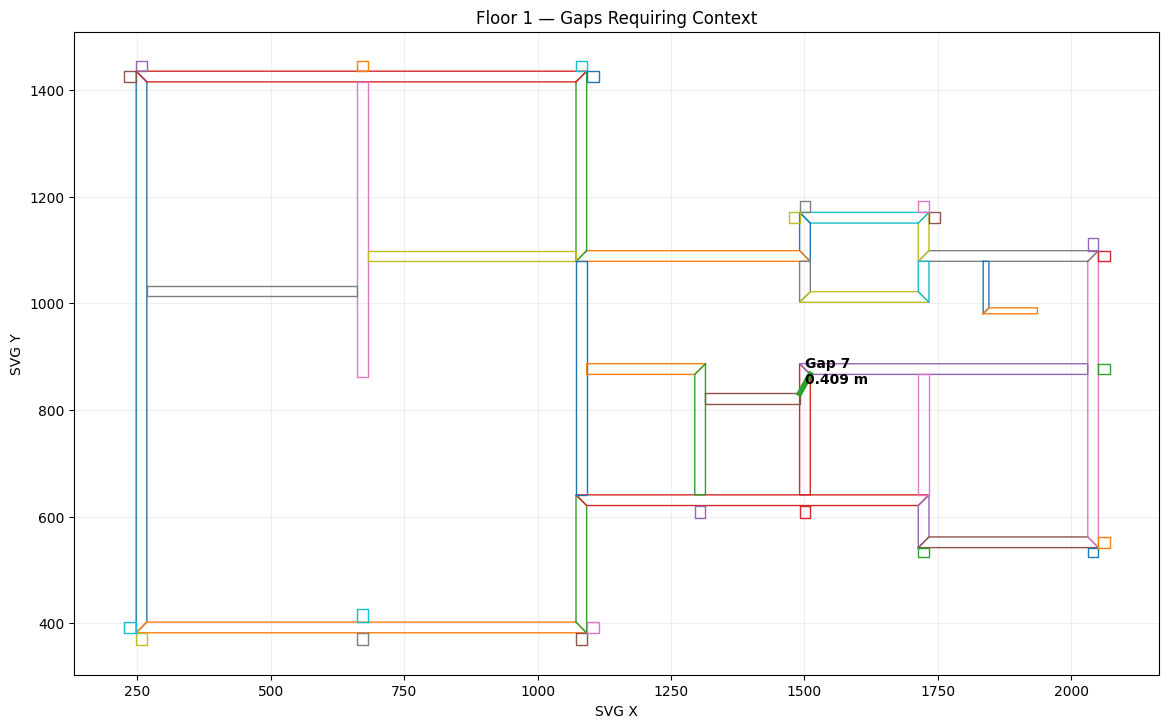


CURRENT MODEL STATUS

3D structural mesh:
    ✅ already created
    ✅ Floor 1 = Z 0–3 m
    ✅ Floor 2 = Z 3–6 m
    ✅ both floors watertight

Current gap analysis:
    ✅ complete for both floors
    ✅ doors/windows cross-checked
    ✅ no geometry modified

Next modeling decision:
    Only gaps marked INVESTIGATE need further architectural
    inspection. We will NOT automatically fill every gap.



In [81]:
# ============================================================
# COMBINED GAP AUDIT — FLOOR 1 + FLOOR 2
# ============================================================
#
# One cell:
#   1. audits all detected gaps
#   2. checks doors/windows
#   3. classifies them
#   4. plots only suspicious gaps
#
# NO geometry is modified.
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon


SVG_PER_M = 100.01457736449694


# ------------------------------------------------------------
# Helper: safely read opening association
# ------------------------------------------------------------

def get_opening_info(
    gap_number,
    opening_check_results
):

    for result in opening_check_results:

        if result["gap"]["index"] == gap_number:

            nearby = result.get(
                "nearby_openings",
                []
            )

            if not nearby:
                return False, None, None

            # Closest opening
            closest = min(
                nearby,
                key=lambda x: x["distance"]
            )

            return (
                True,
                closest["type"],
                closest["distance"]
            )

    return False, None, None


# ------------------------------------------------------------
# Classify a gap
# ------------------------------------------------------------

def classify_gap(
    gap,
    has_opening,
    opening_type,
    opening_distance
):

    gap_m = gap["gap_m"]

    # Very small gaps around wall thickness / junctions
    if gap_m <= 0.25:

        return (
            "KEEP",
            "Likely wall/junction geometry"
        )

    # Gap near an explicit door/window
    if has_opening:

        return (
            "KEEP",
            f"Opening-associated ({opening_type})"
        )

    # Medium-sized gap with no opening evidence
    if gap_m <= 0.60:

        return (
            "INVESTIGATE",
            "No opening nearby; architectural context required"
        )

    return (
        "INVESTIGATE",
        "Large gap; do not automatically close"
    )


# ------------------------------------------------------------
# Build combined audit table
# ------------------------------------------------------------

audit_rows = []

for floor_name, gaps, opening_results in [
    (
        "Floor 1",
        f1_gap_analysis,
        f1_gap_opening_check
    ),
    (
        "Floor 2",
        f2_gap_analysis,
        f2_gap_opening_check
    )
]:

    for gap in gaps:

        has_opening, opening_type, opening_distance = (
            get_opening_info(
                gap["index"],
                opening_results
            )
        )

        decision, reason = classify_gap(
            gap,
            has_opening,
            opening_type,
            opening_distance
        )

        audit_rows.append({

            "floor": floor_name,

            "gap": gap["index"],

            "walls": (
                f"{gap['wall_a']} ↔ "
                f"{gap['wall_b']}"
            ),

            "gap_m": round(
                gap["gap_m"],
                4
            ),

            "opening_nearby":
                has_opening,

            "opening_type":
                opening_type
                if opening_type
                else "",

            "opening_distance_m":
                round(
                    opening_distance / SVG_PER_M,
                    3
                )
                if opening_distance is not None
                else None,

            "decision":
                decision,

            "reason":
                reason
        })


audit_df = pd.DataFrame(
    audit_rows
)


# ------------------------------------------------------------
# Print complete audit
# ------------------------------------------------------------

print("=" * 100)
print("COMBINED GAP AUDIT")
print("=" * 100)

display(
    audit_df
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print()
print("=" * 100)
print("AUDIT SUMMARY")
print("=" * 100)

print(
    "Total candidate gaps:",
    len(audit_df)
)

print()

print(
    audit_df["decision"]
    .value_counts()
)


# ------------------------------------------------------------
# Identify genuinely suspicious candidates
# ------------------------------------------------------------

suspicious = audit_df[
    audit_df["decision"] == "INVESTIGATE"
].copy()

print()
print("=" * 100)
print("GAPS REQUIRING CONTEXT")
print("=" * 100)

if len(suspicious) == 0:

    print(
        "No gaps currently require structural repair."
    )

else:

    display(
        suspicious
    )


# ------------------------------------------------------------
# Plot ONLY suspicious gaps
# ------------------------------------------------------------

def plot_suspicious_gaps(
    floor_name,
    walls,
    gap_analysis,
    suspicious_gap_numbers
):

    fig, ax = plt.subplots(
        figsize=(14, 9)
    )

    # Draw all walls lightly
    for poly in walls:

        if hasattr(poly, "exterior"):

            x, y = poly.exterior.xy

            ax.plot(
                x,
                y,
                linewidth=1.0
            )

    # Find suspicious gaps
    selected = [
        g
        for g in gap_analysis
        if g["index"] in suspicious_gap_numbers
    ]

    for gap in selected:

        # Find the two wall polygons
        a = walls[
            gap["wall_a"]
        ]

        b = walls[
            gap["wall_b"]
        ]

        # Approximate nearest points using Shapely
        from shapely.ops import nearest_points

        p1, p2 = nearest_points(
            a,
            b
        )

        ax.plot(
            [p1.x, p2.x],
            [p1.y, p2.y],
            linewidth=4
        )

        mx = (
            p1.x + p2.x
        ) / 2

        my = (
            p1.y + p2.y
        ) / 2

        ax.text(
            mx,
            my,
            f"Gap {gap['index']}\n"
            f"{gap['gap_m']:.3f} m",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.set_title(
        f"{floor_name} — Gaps Requiring Context"
    )

    ax.set_xlabel(
        "SVG X"
    )

    ax.set_ylabel(
        "SVG Y"
    )

    ax.grid(
        True,
        alpha=0.2
    )

    plt.show()


# ------------------------------------------------------------
# Plot suspicious gaps
# ------------------------------------------------------------

for floor_name, walls, gap_analysis in [
    (
        "Floor 1",
        f1_walls,
        f1_gap_analysis
    ),
    (
        "Floor 2",
        f2_walls,
        f2_gap_analysis
    )
]:

    floor_suspicious = suspicious[
        suspicious["floor"] == floor_name
    ]

    if len(floor_suspicious) == 0:
        continue

    suspicious_numbers = (
        floor_suspicious["gap"]
        .astype(int)
        .tolist()
    )

    plot_suspicious_gaps(
        floor_name,
        walls,
        gap_analysis,
        suspicious_numbers
    )


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print()
print("=" * 100)
print("CURRENT MODEL STATUS")
print("=" * 100)

print("""
3D structural mesh:
    ✅ already created
    ✅ Floor 1 = Z 0–3 m
    ✅ Floor 2 = Z 3–6 m
    ✅ both floors watertight

Current gap analysis:
    ✅ complete for both floors
    ✅ doors/windows cross-checked
    ✅ no geometry modified

Next modeling decision:
    Only gaps marked INVESTIGATE need further architectural
    inspection. We will NOT automatically fill every gap.
""")

In [82]:
# ============================================================
# NEXT 3D STEP — PROVISIONAL FLOOR SLABS
# ============================================================
#
# We derive each slab from the ORIGINAL SVG's EXTERNAL WALLS.
#
# This avoids:
#   - making a rectangular floor by assumption
#   - using furniture BoundaryPolygon objects
#   - inventing a building footprint
#
# The slab is a PROVISIONAL structural floor surface.
#
# Floor 1: Z = 0.00 m
# Floor 2: Z = 3.00 m
#
# No existing GLB is overwritten.
# ============================================================

import re
import numpy as np
import trimesh
import plotly.graph_objects as go

from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.affinity import translate


# ============================================================
# 1. VERIFIED PROJECT CONSTANTS
# ============================================================

SVG_UNITS_PER_METER = 100.01457736449694
METERS_PER_SVG_UNIT = 1.0 / SVG_UNITS_PER_METER

FLOOR_HEIGHT = 3.0

FLOOR1_Z = 0.0
FLOOR2_Z = 3.0

# Structural Floor-2 alignment already established.
FLOOR2_DX = -1918.500
FLOOR2_DY = -11.650


# ============================================================
# 2. EXTRACT EXTERNAL WALL POLYGONS FROM SVG
# ============================================================

def polygon_from_svg_points(points_string):

    if not points_string:
        return None

    nums = [
        float(x)
        for x in re.findall(
            r'[-+]?(?:\d*\.\d+|\d+\.?)'
            r'(?:[eE][-+]?\d+)?',
            points_string
        )
    ]

    if len(nums) < 6 or len(nums) % 2 != 0:
        return None

    pts = [
        (
            nums[i],
            nums[i + 1]
        )
        for i in range(
            0,
            len(nums),
            2
        )
    ]

    poly = Polygon(pts)

    if not poly.is_valid:
        poly = poly.buffer(0)

    if poly.is_empty or poly.area <= 0:
        return None

    return poly


def extract_external_wall_polygons(
    floor_element
):

    polygons = []

    for element in floor_element.iter():

        classes = (
            element.get("class") or ""
        ).split()

        # We specifically want:
        # Wall External
        if (
            "Wall" not in classes
            or "External" not in classes
        ):
            continue

        # Only DIRECT polygon children.
        # This prevents nested Window/Glass/Panel geometry
        # from being counted as external wall geometry.

        for child in element:

            if not child.tag.endswith(
                "polygon"
            ):
                continue

            poly = polygon_from_svg_points(
                child.get("points", "")
            )

            if poly is not None:
                polygons.append(poly)

    return polygons


floor1_external = extract_external_wall_polygons(
    floor1
)

floor2_external = extract_external_wall_polygons(
    floor2
)


print("=" * 70)
print("EXTERNAL WALL EXTRACTION")
print("=" * 70)

print(
    "Floor 1 external wall polygons:",
    len(floor1_external)
)

print(
    "Floor 2 external wall polygons:",
    len(floor2_external)
)


if not floor1_external:
    raise RuntimeError(
        "No external wall polygons were found for Floor 1."
    )

if not floor2_external:
    raise RuntimeError(
        "No external wall polygons were found for Floor 2."
    )


# ============================================================
# 3. ALIGN FLOOR 2
# ============================================================

floor2_external_aligned = [
    translate(
        poly,
        xoff=FLOOR2_DX,
        yoff=FLOOR2_DY
    )
    for poly in floor2_external
]


# ============================================================
# 4. COMMON LOCAL ORIGIN
# ============================================================

all_points = []

for poly in floor1_external:

    all_points.extend(
        list(poly.exterior.coords)
    )

for poly in floor2_external_aligned:

    all_points.extend(
        list(poly.exterior.coords)
    )

all_points = np.asarray(
    all_points,
    dtype=float
)

ORIGIN_X = all_points[:, 0].min()
ORIGIN_Y = all_points[:, 1].min()

print("\nCommon slab origin:")
print(
    f"X = {ORIGIN_X:.3f}"
)

print(
    f"Y = {ORIGIN_Y:.3f}"
)


# ============================================================
# 5. CONVERT TO METRIC COORDINATES
# ============================================================

def to_metric(poly):

    coords = []

    for x, y in poly.exterior.coords:

        coords.append(
            (
                (x - ORIGIN_X)
                * METERS_PER_SVG_UNIT,

                (y - ORIGIN_Y)
                * METERS_PER_SVG_UNIT
            )
        )

    result = Polygon(coords)

    if not result.is_valid:
        result = result.buffer(0)

    return result


floor1_external_m = [
    to_metric(p)
    for p in floor1_external
]

floor2_external_m = [
    to_metric(p)
    for p in floor2_external_aligned
]


# ============================================================
# 6. BUILD EXTERIOR-WALL ENVELOPES
# ============================================================
#
# External walls are thin polygons rather than floor-area
# polygons. We therefore:
#
#   external wall union
#        ↓
#   outward buffer by ~half wall thickness
#        ↓
#   structural envelope
#
# 0.10 m is based on the ~0.20 m wall thickness observed
# in the SVG. This is a geometric construction parameter,
# NOT a surveyed building dimension.
# ============================================================

HALF_WALL_THICKNESS_M = 0.10


def make_floor_envelope(
    wall_polygons,
    floor_name
):

    wall_union = unary_union(
        wall_polygons
    )

    # Buffer outward by half the nominal wall thickness.
    envelope = wall_union.buffer(
        HALF_WALL_THICKNESS_M,
        join_style=2
    )

    # Keep the outermost connected envelope.
    if envelope.geom_type == "MultiPolygon":

        envelope = max(
            envelope.geoms,
            key=lambda g: g.area
        )

    print(
        f"\n{floor_name} envelope:"
    )

    print(
        "Area:",
        round(envelope.area, 3),
        "m²"
    )

    print(
        "Bounds:",
        tuple(
            round(x, 3)
            for x in envelope.bounds
        )
    )

    return envelope


floor1_envelope = make_floor_envelope(
    floor1_external_m,
    "Floor 1"
)

floor2_envelope = make_floor_envelope(
    floor2_external_m,
    "Floor 2"
)


# ============================================================
# 7. CREATE SLAB MESHES
# ============================================================

def create_slab(
    footprint,
    z,
    thickness=0.15
):

    # Make a very thin structural slab.
    #
    # Thickness is a VISUAL/structural modeling parameter,
    # not measured from the source.

    mesh = trimesh.creation.extrude_polygon(
        footprint,
        height=thickness
    )

    mesh.apply_translation(
        [0, 0, z]
    )

    return mesh


SLAB_THICKNESS = 0.15

floor1_slab = create_slab(
    floor1_envelope,
    FLOOR1_Z,
    SLAB_THICKNESS
)

floor2_slab = create_slab(
    floor2_envelope,
    FLOOR2_Z,
    SLAB_THICKNESS
)


print("\n" + "=" * 70)
print("SLAB MESHES")
print("=" * 70)

print(
    "Floor 1 slab volume:",
    round(
        floor1_slab.volume,
        3
    ),
    "m³"
)

print(
    "Floor 2 slab volume:",
    round(
        floor2_slab.volume,
        3
    ),
    "m³"
)


# ============================================================
# 8. COMBINE WALLS + SLABS
# ============================================================

structural_with_slabs = trimesh.util.concatenate(
    [
        building_3d,
        floor1_slab,
        floor2_slab
    ]
)


print("\n" + "=" * 70)
print("WALLS + FLOOR SLABS")
print("=" * 70)

print(
    "Vertices:",
    len(
        structural_with_slabs.vertices
    )
)

print(
    "Faces:",
    len(
        structural_with_slabs.faces
    )
)

print(
    "Volume:",
    round(
        structural_with_slabs.volume,
        3
    ),
    "m³"
)


# ============================================================
# 9. EXPORT A NEW FILE
# ============================================================

output_slab_model = (
    "cubicasa_two_floor_walls_plus_slabs.glb"
)

structural_with_slabs.export(
    output_slab_model
)

print()
print(
    "✅ Saved:",
    output_slab_model
)


# ============================================================
# 10. VISUALIZE WALLS + SLABS
# ============================================================

def add_mesh_to_plot(
    fig,
    mesh,
    name,
    opacity=0.65
):

    vertices = mesh.vertices
    faces = mesh.faces

    fig.add_trace(
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],

            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],

            opacity=opacity,

            name=name,

            flatshading=False,

            hovertemplate=(
                f"{name}<br>"
                "X: %{x:.2f} m<br>"
                "Y: %{y:.2f} m<br>"
                "Z: %{z:.2f} m"
                "<extra></extra>"
            )
        )
    )


fig = go.Figure()

# Existing walls
add_mesh_to_plot(
    fig,
    building_3d,
    "Structural walls",
    opacity=0.45
)

# Floor 1 slab
add_mesh_to_plot(
    fig,
    floor1_slab,
    "Floor 1 slab",
    opacity=0.35
)

# Floor 2 slab
add_mesh_to_plot(
    fig,
    floor2_slab,
    "Floor 2 slab",
    opacity=0.35
)


fig.update_layout(
    title=(
        "Two-Floor Structural Model "
        "+ Provisional Floor Slabs"
    ),

    scene=dict(

        xaxis_title="X (m)",

        yaxis_title="Y (m)",

        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.6,
                y=1.5,
                z=1.2
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=45,
        b=0
    )
)

fig.show()

EXTERNAL WALL EXTRACTION
Floor 1 external wall polygons: 14
Floor 2 external wall polygons: 8

Common slab origin:
X = 247.530
Y = 382.420

Floor 1 envelope:
Area: 23.729 m²
Bounds: (-0.1, -0.1, 18.133, 10.624)

Floor 2 envelope:
Area: 15.514 m²
Bounds: (-0.071, -0.094, 8.514, 10.631)

SLAB MESHES
Floor 1 slab volume: 3.559 m³
Floor 2 slab volume: 2.327 m³

WALLS + FLOOR SLABS
Vertices: 776
Faces: 1200
Volume: 121.422 m³

✅ Saved: cubicasa_two_floor_walls_plus_slabs.glb


In [83]:
# =====================================================================
# FLOOR 1 + FLOOR 2 — COMPLETE STRUCTURAL FOOTPRINT AUDIT
# Focus: building shell only
# Doors / windows / furniture intentionally ignored
# =====================================================================

import numpy as np
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union

print("=" * 90)
print("COMPLETE BUILDING SHELL — STRUCTURAL FOOTPRINT AUDIT")
print("=" * 90)

# ---------------------------------------------------------------------
# 1. USE THE ALREADY VALIDATED STRUCTURAL WALL POLYGONS
# ---------------------------------------------------------------------

f1_walls = floor1_wall_polygons
f2_walls = floor2_wall_polygons

print("\nSTRUCTURAL WALL INPUT")
print("-" * 90)
print(f"Floor 1 wall polygons : {len(f1_walls)}")
print(f"Floor 2 wall polygons : {len(f2_walls)}")

# ---------------------------------------------------------------------
# 2. CLEAN INVALID / EMPTY GEOMETRY
# ---------------------------------------------------------------------

def clean_polygons(polygons):
    cleaned = []

    for p in polygons:
        if p is None or p.is_empty:
            continue

        try:
            if not p.is_valid:
                p = p.buffer(0)
        except Exception:
            continue

        if p.is_empty:
            continue

        if isinstance(p, Polygon):
            cleaned.append(p)

        elif isinstance(p, MultiPolygon):
            cleaned.extend(
                [g for g in p.geoms if not g.is_empty]
            )

    return cleaned


f1_clean = clean_polygons(f1_walls)
f2_clean = clean_polygons(f2_walls)

print("\nCLEANED WALL GEOMETRY")
print("-" * 90)
print(f"Floor 1 valid polygons : {len(f1_clean)}")
print(f"Floor 2 valid polygons : {len(f2_clean)}")

# ---------------------------------------------------------------------
# 3. UNION THE STRUCTURAL WALLS
# ---------------------------------------------------------------------

f1_union = unary_union(f1_clean)
f2_union = unary_union(f2_clean)

# ---------------------------------------------------------------------
# 4. EXTRACT THE STRUCTURAL FOOTPRINT
#
# We deliberately use the full wall geometry instead of the previous
# external-wall classifier. This prevents legitimate Floor-2 structural
# regions from being accidentally discarded.
# ---------------------------------------------------------------------

f1_bounds = f1_union.bounds
f2_bounds = f2_union.bounds

print("\nSTRUCTURAL WALL BOUNDS")
print("-" * 90)

print(
    "Floor 1:"
    f" ({f1_bounds[0]:.3f}, {f1_bounds[1]:.3f})"
    f" → ({f1_bounds[2]:.3f}, {f1_bounds[3]:.3f})"
)

print(
    "Floor 2:"
    f" ({f2_bounds[0]:.3f}, {f2_bounds[1]:.3f})"
    f" → ({f2_bounds[2]:.3f}, {f2_bounds[3]:.3f})"
)

f1_width = f1_bounds[2] - f1_bounds[0]
f1_depth = f1_bounds[3] - f1_bounds[1]

f2_width = f2_bounds[2] - f2_bounds[0]
f2_depth = f2_bounds[3] - f2_bounds[1]

print("\nSTRUCTURAL EXTENTS")
print("-" * 90)
print(f"Floor 1 : {f1_width:.3f} × {f1_depth:.3f} SVG")
print(f"Floor 2 : {f2_width:.3f} × {f2_depth:.3f} SVG")

print(
    f"Floor 1 : {f1_width / SVG_UNITS_PER_METER:.3f}"
    f" × {f1_depth / SVG_UNITS_PER_METER:.3f} m"
)

print(
    f"Floor 2 : {f2_width / SVG_UNITS_PER_METER:.3f}"
    f" × {f2_depth / SVG_UNITS_PER_METER:.3f} m"
)

# ---------------------------------------------------------------------
# 5. NORMALIZED COMMON COORDINATE SYSTEM
#
# Use the same origin already used by the 3D structural model.
# ---------------------------------------------------------------------

COMMON_X = min(f1_bounds[0], f2_bounds[0])
COMMON_Y = min(f1_bounds[1], f2_bounds[1])

def normalize_geometry(g):
    return Polygon([
        (
            x - COMMON_X,
            y - COMMON_Y
        )
        for x, y in g.exterior.coords
    ]) if isinstance(g, Polygon) else g

# Translation through shapely is safer for MultiPolygon / GeometryCollection
from shapely.affinity import translate

f1_norm = translate(
    f1_union,
    xoff=-COMMON_X,
    yoff=-COMMON_Y
)

f2_norm = translate(
    f2_union,
    xoff=-COMMON_X,
    yoff=-COMMON_Y
)

# ---------------------------------------------------------------------
# 6. COMPARE FLOOR-2 STRUCTURAL FOOTPRINT WITH FLOOR-1
# ---------------------------------------------------------------------

intersection = f1_norm.intersection(f2_norm)

f1_area = f1_norm.area
f2_area = f2_norm.area
overlap_area = intersection.area

f1_only = f1_norm.difference(f2_norm)
f2_only = f2_norm.difference(f1_norm)

print("\n" + "=" * 90)
print("FLOOR FOOTPRINT RELATIONSHIP")
print("=" * 90)

print(f"Floor 1 structural footprint area : "
      f"{f1_area / SVG_UNITS_PER_METER**2:.3f} m²")

print(f"Floor 2 structural footprint area : "
      f"{f2_area / SVG_UNITS_PER_METER**2:.3f} m²")

print(f"Common structural footprint area   : "
      f"{overlap_area / SVG_UNITS_PER_METER**2:.3f} m²")

if f1_area > 0:
    print(
        f"Floor-2 / Floor-1 overlap         : "
        f"{100 * overlap_area / f1_area:.2f}%"
    )

if f2_area > 0:
    print(
        f"Floor-1 / Floor-2 overlap         : "
        f"{100 * overlap_area / f2_area:.2f}%"
    )

print(
    f"\nFloor-1-only structural region     : "
    f"{f1_only.area / SVG_UNITS_PER_METER**2:.3f} m²"
)

print(
    f"Floor-2-only structural region     : "
    f"{f2_only.area / SVG_UNITS_PER_METER**2:.3f} m²"
)

# ---------------------------------------------------------------------
# 7. IDENTIFY DISCONNECTED FLOOR-2 STRUCTURAL REGIONS
# ---------------------------------------------------------------------

def components_info(g):
    if isinstance(g, Polygon):
        return [g]

    if isinstance(g, MultiPolygon):
        return list(g.geoms)

    if hasattr(g, "geoms"):
        return [
            x for x in g.geoms
            if isinstance(x, Polygon)
        ]

    return []


f1_components = components_info(f1_norm)
f2_components = components_info(f2_norm)

print("\n" + "=" * 90)
print("STRUCTURAL COMPONENTS")
print("=" * 90)

print(f"Floor 1 components : {len(f1_components)}")
print(f"Floor 2 components : {len(f2_components)}")

print("\nFloor 2 components:")
for i, comp in enumerate(
    sorted(f2_components, key=lambda x: x.area, reverse=True),
    start=1
):
    b = comp.bounds

    print(
        f"  #{i:02d} "
        f"area={comp.area / SVG_UNITS_PER_METER**2:.3f} m² | "
        f"bounds=({b[0]:.2f}, {b[1]:.2f}) → "
        f"({b[2]:.2f}, {b[3]:.2f})"
    )

# ---------------------------------------------------------------------
# 8. DIAGNOSTIC COMPARISON WITH THE PREVIOUS SLAB ENVELOPES
# ---------------------------------------------------------------------

print("\n" + "=" * 90)
print("PREVIOUS SLAB / STRUCTURAL FOOTPRINT COMPARISON")
print("=" * 90)

# These variables were created by the previous cell if available.
# We intentionally do not fail if they are absent.

if "floor1_envelope" in globals():
    old_f1 = floor1_envelope
    print(
        f"Previous Floor-1 slab envelope : "
        f"{old_f1.area / SVG_UNITS_PER_METER**2:.3f} m²"
    )
else:
    old_f1 = None
    print("Previous Floor-1 envelope variable not available.")

if "floor2_envelope" in globals():
    old_f2 = floor2_envelope
    print(
        f"Previous Floor-2 slab envelope : "
        f"{old_f2.area / SVG_UNITS_PER_METER**2:.3f} m²"
    )
else:
    old_f2 = None
    print("Previous Floor-2 envelope variable not available.")

print(
    f"\nCorrect structural Floor-1 footprint : "
    f"{f1_area / SVG_UNITS_PER_METER**2:.3f} m²"
)

print(
    f"Correct structural Floor-2 footprint : "
    f"{f2_area / SVG_UNITS_PER_METER**2:.3f} m²"
)

# ---------------------------------------------------------------------
# 9. BUILD NEW PROVISIONAL STRUCTURAL SLAB FOOTPRINTS
#
# IMPORTANT:
# These are based on the complete structural wall union.
# They do NOT modify any walls.
# ---------------------------------------------------------------------

structural_floor1_footprint = f1_norm
structural_floor2_footprint = f2_norm

# Small expansion equal to half the wall thickness is intentionally NOT
# applied yet. We want to see the raw structural footprint first.
#
# This avoids accidentally filling courtyards, shafts, voids, or
# architectural openings.

print("\n" + "=" * 90)
print("PROVISIONAL COMPLETE-BUILDING FOOTPRINTS")
print("=" * 90)

print(
    "Floor 1 footprint ready : "
    f"{structural_floor1_footprint.area / SVG_UNITS_PER_METER**2:.3f} m²"
)

print(
    "Floor 2 footprint ready : "
    f"{structural_floor2_footprint.area / SVG_UNITS_PER_METER**2:.3f} m²"
)

print("\nNo walls have been modified.")
print("No doors/windows/furniture have been used.")
print("No final slab thickness has been applied.")

print("\nNEXT STEP:")
print(
    "We will use these complete structural footprints to build the "
    "actual two-floor building shell and then validate the vertical "
    "Floor-1 → Floor-2 relationship."
)

COMPLETE BUILDING SHELL — STRUCTURAL FOOTPRINT AUDIT

STRUCTURAL WALL INPUT
------------------------------------------------------------------------------------------
Floor 1 wall polygons : 52
Floor 2 wall polygons : 36

CLEANED WALL GEOMETRY
------------------------------------------------------------------------------------------
Floor 1 valid polygons : 52
Floor 2 valid polygons : 36

STRUCTURAL WALL BOUNDS
------------------------------------------------------------------------------------------
Floor 1: (224.180, 358.570) → (2072.940, 1454.090)
Floor 2: (2147.400, 374.270) → (3980.210, 1466.760)

STRUCTURAL EXTENTS
------------------------------------------------------------------------------------------
Floor 1 : 1848.760 × 1095.520 SVG
Floor 2 : 1832.810 × 1092.490 SVG
Floor 1 : 18.485 × 10.954 m
Floor 2 : 18.325 × 10.923 m

FLOOR FOOTPRINT RELATIONSHIP
Floor 1 structural footprint area : 20.564 m²
Floor 2 structural footprint area : 17.924 m²
Common structural footprint area  

In [84]:
# ============================================================================
# COMPLETE TWO-FLOOR BUILDING SHELL
# COMMON XY ALIGNMENT + STRUCTURAL WALLS + SLABS
#
# PURPOSE:
#   - Ignore doors/windows/furniture completely
#   - Put Floor 1 and Floor 2 into ONE building coordinate system
#   - Preserve all structural wall polygons
#   - Build Floor 1 + Floor 2 walls
#   - Add structural floor slabs
#   - Validate the vertical relationship
#   - Save the complete shell as GLB
# ============================================================================

import numpy as np
import trimesh
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union, transform
from copy import deepcopy

# ----------------------------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------------------------

SVG_UNITS_PER_METER = 100.01457736449694

FLOOR_HEIGHT_M = 3.0
SLAB_THICKNESS_M = 0.15

# Previously established structural alignment:
# Floor 2 must be translated into Floor 1's structural coordinate system.
FLOOR2_DX_SVG = -1918.500
FLOOR2_DY_SVG = -11.650

# Common building origin.
# Use the structural Floor-1 origin already established.
COMMON_ORIGIN_X = 224.180
COMMON_ORIGIN_Y = 358.570

# ----------------------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------------------

def clean_polygon(poly):
    """
    Repair/normalize a polygon without changing its intended footprint.
    """
    if poly is None:
        return None

    if poly.is_empty:
        return None

    if not poly.is_valid:
        poly = poly.buffer(0)

    if poly.is_empty:
        return None

    return poly


def polygon_to_xy(poly):
    """
    Return exterior coordinates as Nx2 float array.
    """
    poly = clean_polygon(poly)

    if poly is None:
        return None

    if isinstance(poly, MultiPolygon):
        poly = max(poly.geoms, key=lambda p: p.area)

    coords = np.asarray(poly.exterior.coords, dtype=float)

    if len(coords) < 4:
        return None

    return coords[:, :2]


def translate_svg_polygon(poly, dx_svg, dy_svg):
    """
    Translate polygon in SVG units.
    """
    return transform(
        lambda x, y, z=None: (
            np.asarray(x) + dx_svg,
            np.asarray(y) + dy_svg
        ),
        poly
    )


def svg_to_meters_xy(coords, origin_x, origin_y):
    """
    Convert common SVG coordinates into local metre coordinates.
    """
    pts = np.asarray(coords, dtype=float)

    return np.column_stack([
        (pts[:, 0] - origin_x) / SVG_UNITS_PER_METER,
        (pts[:, 1] - origin_y) / SVG_UNITS_PER_METER
    ])


def make_prism_from_polygon(poly, z0, z1):
    """
    Extrude a 2D structural polygon vertically.
    """
    poly = clean_polygon(poly)

    if poly is None:
        return None

    coords = polygon_to_xy(poly)

    if coords is None:
        return None

    # Remove duplicated closing point.
    if np.allclose(coords[0], coords[-1]):
        coords = coords[:-1]

    n = len(coords)

    vertices = np.zeros((n * 2, 3), dtype=float)

    vertices[:n, :2] = coords
    vertices[:n, 2] = z0

    vertices[n:, :2] = coords
    vertices[n:, 2] = z1

    faces = []

    # Bottom
    for i in range(1, n - 1):
        faces.append([0, i + 1, i])

    # Top
    for i in range(1, n - 1):
        faces.append([n, n + i, n + i + 1])

    # Sides
    for i in range(n):
        j = (i + 1) % n

        faces.append([i, j, n + j])
        faces.append([i, n + j, n + i])

    mesh = trimesh.Trimesh(
        vertices=np.asarray(vertices),
        faces=np.asarray(faces),
        process=True
    )

    return mesh


def build_floor_walls(polygons, z0, z1, origin_x, origin_y,
                      dx_svg=0.0, dy_svg=0.0):

    meshes = []

    for poly in polygons:

        poly = clean_polygon(poly)

        if poly is None:
            continue

        # Apply floor alignment BEFORE conversion to metres.
        if dx_svg != 0.0 or dy_svg != 0.0:
            poly = translate_svg_polygon(
                poly,
                dx_svg,
                dy_svg
            )

        coords_svg = polygon_to_xy(poly)

        if coords_svg is None:
            continue

        coords_m = svg_to_meters_xy(
            coords_svg,
            origin_x,
            origin_y
        )

        # Rebuild polygon in local metre coordinates.
        local_poly = Polygon(coords_m)

        if not local_poly.is_valid:
            local_poly = local_poly.buffer(0)

        if local_poly.is_empty:
            continue

        # Handle MultiPolygon repairs.
        if isinstance(local_poly, MultiPolygon):
            parts = list(local_poly.geoms)
        else:
            parts = [local_poly]

        for part in parts:

            mesh = make_prism_from_polygon(
                part,
                z0,
                z1
            )

            if mesh is not None:
                meshes.append(mesh)

    return meshes


# ============================================================================
# INPUT CHECK
# ============================================================================

print("=" * 90)
print("COMPLETE TWO-FLOOR BUILDING SHELL")
print("=" * 90)

print()
print("INPUT STRUCTURAL GEOMETRY")
print("-" * 90)
print(f"Floor 1 wall polygons : {len(floor1_wall_polygons)}")
print(f"Floor 2 wall polygons : {len(floor2_wall_polygons)}")

print()
print("ALIGNMENT")
print("-" * 90)
print(f"Floor 2 DX : {FLOOR2_DX_SVG:.3f} SVG")
print(f"Floor 2 DY : {FLOOR2_DY_SVG:.3f} SVG")

print()
print("COMMON ORIGIN")
print("-" * 90)
print(f"X = {COMMON_ORIGIN_X:.3f} SVG")
print(f"Y = {COMMON_ORIGIN_Y:.3f} SVG")


# ============================================================================
# BUILD FLOOR 1
# ============================================================================

floor1_meshes = build_floor_walls(
    floor1_wall_polygons,
    z0=0.0,
    z1=FLOOR_HEIGHT_M,
    origin_x=COMMON_ORIGIN_X,
    origin_y=COMMON_ORIGIN_Y
)


# ============================================================================
# BUILD FLOOR 2
# ============================================================================

floor2_meshes = build_floor_walls(
    floor2_wall_polygons,
    z0=FLOOR_HEIGHT_M,
    z1=2.0 * FLOOR_HEIGHT_M,
    origin_x=COMMON_ORIGIN_X,
    origin_y=COMMON_ORIGIN_Y,
    dx_svg=FLOOR2_DX_SVG,
    dy_svg=FLOOR2_DY_SVG
)


# ============================================================================
# STRUCTURAL FOOTPRINTS AFTER ALIGNMENT
# ============================================================================

def footprint_from_polygons(polygons, dx_svg=0.0, dy_svg=0.0):

    aligned = []

    for poly in polygons:

        poly = clean_polygon(poly)

        if poly is None:
            continue

        if dx_svg != 0.0 or dy_svg != 0.0:
            poly = translate_svg_polygon(
                poly,
                dx_svg,
                dy_svg
            )

        coords = polygon_to_xy(poly)

        if coords is not None:
            aligned.append(
                Polygon(coords)
            )

    if not aligned:
        return None

    return unary_union(aligned)


f1_footprint_svg = footprint_from_polygons(
    floor1_wall_polygons
)

f2_footprint_svg = footprint_from_polygons(
    floor2_wall_polygons,
    FLOOR2_DX_SVG,
    FLOOR2_DY_SVG
)


# ============================================================================
# CONVERT FOOTPRINTS TO COMMON METRE SPACE
# ============================================================================

def svg_geom_to_meters(geom):

    if geom is None:
        return None

    return transform(
        lambda x, y, z=None: (
            (np.asarray(x) - COMMON_ORIGIN_X)
            / SVG_UNITS_PER_METER,

            (np.asarray(y) - COMMON_ORIGIN_Y)
            / SVG_UNITS_PER_METER
        ),
        geom
    )


f1_common = svg_geom_to_meters(f1_footprint_svg)
f2_common = svg_geom_to_meters(f2_footprint_svg)


# ============================================================================
# FOOTPRINT VALIDATION
# ============================================================================

print()
print("=" * 90)
print("ALIGNED STRUCTURAL FOOTPRINT VALIDATION")
print("=" * 90)

print()
print(f"Floor 1 footprint : {f1_common.area:.3f} m²")
print(f"Floor 2 footprint : {f2_common.area:.3f} m²")

intersection = f1_common.intersection(f2_common)

print(f"Common footprint  : {intersection.area:.3f} m²")

if f1_common.area > 0:
    print(
        f"Floor-2 / Floor-1 overlap : "
        f"{100.0 * intersection.area / f1_common.area:.2f}%"
    )

if f2_common.area > 0:
    print(
        f"Floor-1 / Floor-2 overlap : "
        f"{100.0 * intersection.area / f2_common.area:.2f}%"
    )


# ============================================================================
# FLOOR SLABS
# ============================================================================

def make_slab(footprint, z_bottom, z_top):

    if footprint is None or footprint.is_empty:
        return None

    return make_prism_from_polygon(
        footprint,
        z_bottom,
        z_top
    )


floor1_slab = make_slab(
    f1_common,
    -SLAB_THICKNESS_M,
    0.0
)

floor2_slab = make_slab(
    f2_common,
    FLOOR_HEIGHT_M - SLAB_THICKNESS_M,
    FLOOR_HEIGHT_M
)


# ============================================================================
# COMBINE ALL STRUCTURAL COMPONENTS
# ============================================================================

all_meshes = []

all_meshes.extend(floor1_meshes)
all_meshes.extend(floor2_meshes)

if floor1_slab is not None:
    all_meshes.append(floor1_slab)

if floor2_slab is not None:
    all_meshes.append(floor2_slab)


combined = trimesh.util.concatenate(all_meshes)


# ============================================================================
# FINAL VALIDATION
# ============================================================================

print()
print("=" * 90)
print("COMPLETE BUILDING SHELL")
print("=" * 90)

print()
print(f"Floor 1 wall meshes : {len(floor1_meshes)}")
print(f"Floor 2 wall meshes : {len(floor2_meshes)}")

print()
print(f"Total vertices      : {len(combined.vertices)}")
print(f"Total faces         : {len(combined.faces)}")
print(f"Total volume        : {combined.volume:.3f} m³")

print()
print("3D BOUNDS")
print("-" * 90)

bounds = combined.bounds

print(
    f"X : {bounds[0,0]:.3f} → {bounds[1,0]:.3f} m"
)

print(
    f"Y : {bounds[0,1]:.3f} → {bounds[1,1]:.3f} m"
)

print(
    f"Z : {bounds[0,2]:.3f} → {bounds[1,2]:.3f} m"
)

print()
print("MESH SANITY")
print("-" * 90)

print(f"Watertight : {combined.is_watertight}")
print(f"Valid      : {combined.is_volume}")


# ============================================================================
# SAVE
# ============================================================================

OUTPUT_FILE = "cubicasa_complete_two_floor_building_shell.glb"

combined.export(OUTPUT_FILE)

print()
print("=" * 90)
print("SAVED")
print("=" * 90)
print()
print(f"✅ {OUTPUT_FILE}")
print()
print("No doors used.")
print("No windows used.")
print("No furniture used.")
print("No automatic gap filling performed.")
print()
print("The model now represents the structural two-floor building shell.")

COMPLETE TWO-FLOOR BUILDING SHELL

INPUT STRUCTURAL GEOMETRY
------------------------------------------------------------------------------------------
Floor 1 wall polygons : 52
Floor 2 wall polygons : 36

ALIGNMENT
------------------------------------------------------------------------------------------
Floor 2 DX : -1918.500 SVG
Floor 2 DY : -11.650 SVG

COMMON ORIGIN
------------------------------------------------------------------------------------------
X = 224.180 SVG
Y = 358.570 SVG

ALIGNED STRUCTURAL FOOTPRINT VALIDATION

Floor 1 footprint : 20.564 m²
Floor 2 footprint : 17.924 m²
Common footprint  : 11.304 m²
Floor-2 / Floor-1 overlap : 54.97%
Floor-1 / Floor-2 overlap : 63.07%

COMPLETE BUILDING SHELL

Floor 1 wall meshes : 52
Floor 2 wall meshes : 36

Total vertices      : 954
Total faces         : 1548
Total volume        : -87.255 m³

3D BOUNDS
------------------------------------------------------------------------------------------
X : 0.000 → 18.485 m
Y : 0.000 → 10

In [85]:
# ============================================================================
# COMPLETE BUILDING SHELL — MESH ORIENTATION REPAIR (VERSION-SAFE)
# ============================================================================

import numpy as np
import trimesh

print("=" * 90)
print("COMPLETE BUILDING SHELL — MESH ORIENTATION REPAIR")
print("=" * 90)

# --------------------------------------------------------------------------
# USE CURRENT COMBINED BUILDING MESH
# --------------------------------------------------------------------------

mesh = combined.copy()

print()
print("BEFORE REPAIR")
print("-" * 90)
print(f"Vertices   : {len(mesh.vertices)}")
print(f"Faces      : {len(mesh.faces)}")
print(f"Watertight : {mesh.is_watertight}")
print(f"Volume     : {mesh.volume:.3f} m³")
print(f"Is volume  : {mesh.is_volume}")


# --------------------------------------------------------------------------
# BASIC CLEANUP — COMPATIBLE WITH NEWER TRIMESH
# --------------------------------------------------------------------------

print()
print("=" * 90)
print("BASIC MESH CLEANUP")
print("=" * 90)

# Remove unreferenced vertices.
mesh.remove_unreferenced_vertices()

# Merge coincident vertices.
try:
    mesh.merge_vertices()
except Exception as e:
    print(f"merge_vertices warning: {e}")

print()
print(f"Vertices after cleanup : {len(mesh.vertices)}")
print(f"Faces after cleanup    : {len(mesh.faces)}")


# --------------------------------------------------------------------------
# FACE WINDING
# --------------------------------------------------------------------------

print()
print("=" * 90)
print("REPAIRING FACE WINDING")
print("=" * 90)

try:
    trimesh.repair.fix_winding(mesh)
    print("fix_winding completed.")
except Exception as e:
    print(f"fix_winding warning: {e}")

try:
    mesh.fix_normals()
    print("fix_normals completed.")
except Exception as e:
    print(f"fix_normals warning: {e}")


# --------------------------------------------------------------------------
# CHECK CURRENT RESULT
# --------------------------------------------------------------------------

print()
print("=" * 90)
print("POST-REPAIR CHECK")
print("=" * 90)

print()
print(f"Watertight : {mesh.is_watertight}")
print(f"Volume     : {mesh.volume:.3f} m³")
print(f"Is volume  : {mesh.is_volume}")


# --------------------------------------------------------------------------
# IMPORTANT:
# If the mesh is watertight but the volume is negative, reverse ALL faces.
#
# This does NOT change the geometry.
# It only changes the inside/outside orientation of the triangles.
# --------------------------------------------------------------------------

if mesh.is_watertight and mesh.volume < 0:

    print()
    print("Negative volume detected.")
    print("Reversing global face winding...")

    mesh.faces = mesh.faces[:, ::-1]

    # Recalculate normals.
    try:
        mesh.fix_normals()
    except Exception as e:
        print(f"fix_normals warning after reversal: {e}")

    print("Global face winding reversed.")


# --------------------------------------------------------------------------
# FINAL VALIDATION
# --------------------------------------------------------------------------

print()
print("=" * 90)
print("FINAL BUILDING SHELL VALIDATION")
print("=" * 90)

print()
print(f"Vertices   : {len(mesh.vertices)}")
print(f"Faces      : {len(mesh.faces)}")
print(f"Watertight : {mesh.is_watertight}")
print(f"Volume     : {mesh.volume:.3f} m³")
print(f"Is volume  : {mesh.is_volume}")


# --------------------------------------------------------------------------
# BOUNDS
# --------------------------------------------------------------------------

bounds = mesh.bounds

print()
print("3D BOUNDS")
print("-" * 90)

print(
    f"X : {bounds[0,0]:.3f} → {bounds[1,0]:.3f} m"
)

print(
    f"Y : {bounds[0,1]:.3f} → {bounds[1,1]:.3f} m"
)

print(
    f"Z : {bounds[0,2]:.3f} → {bounds[1,2]:.3f} m"
)


# --------------------------------------------------------------------------
# FINAL STATUS
# --------------------------------------------------------------------------

print()
print("=" * 90)
print("STRUCTURAL MODEL STATUS")
print("=" * 90)

if mesh.is_watertight and mesh.is_volume and mesh.volume > 0:
    print("✅ VALID ENCLOSED STRUCTURAL VOLUME")
    print("✅ POSITIVE VOLUME")
    print("✅ WATERTIGHT")
    print("✅ FACE ORIENTATION CORRECTED")
else:
    print("⚠️ Mesh still requires further inspection.")

    if mesh.is_watertight:
        print("   ✓ Watertight")
    else:
        print("   ✗ Not watertight")

    if mesh.volume > 0:
        print("   ✓ Positive volume")
    else:
        print("   ✗ Non-positive volume")

    if mesh.is_volume:
        print("   ✓ Valid volume")
    else:
        print("   ✗ Invalid volume")


# --------------------------------------------------------------------------
# SAVE
# --------------------------------------------------------------------------

REPAIRED_FILE = "cubicasa_complete_two_floor_building_shell_repaired.glb"

mesh.export(REPAIRED_FILE)

print()
print("=" * 90)
print("SAVED")
print("=" * 90)
print()
print(f"✅ {REPAIRED_FILE}")

COMPLETE BUILDING SHELL — MESH ORIENTATION REPAIR

BEFORE REPAIR
------------------------------------------------------------------------------------------
Vertices   : 954
Faces      : 1548
Watertight : True
Volume     : -87.255 m³
Is volume  : False

BASIC MESH CLEANUP

Vertices after cleanup : 637
Faces after cleanup    : 1548

REPAIRING FACE WINDING
fix_winding completed.
fix_normals completed.

POST-REPAIR CHECK

Watertight : False
Volume     : -12.557 m³
Is volume  : False

FINAL BUILDING SHELL VALIDATION

Vertices   : 637
Faces      : 1548
Watertight : False
Volume     : -12.557 m³
Is volume  : False

3D BOUNDS
------------------------------------------------------------------------------------------
X : 0.000 → 18.485 m
Y : 0.000 → 10.964 m
Z : -0.150 → 6.000 m

STRUCTURAL MODEL STATUS
⚠️ Mesh still requires further inspection.
   ✗ Not watertight
   ✗ Non-positive volume
   ✗ Invalid volume

SAVED

✅ cubicasa_complete_two_floor_building_shell_repaired.glb


In [86]:
# ============================================================================
# COMPLETE BUILDING SHELL — SAFE ORIENTATION FIX
# ============================================================================
#
# IMPORTANT:
# Start from the ORIGINAL `combined` mesh.
#
# We will NOT:
#   - merge vertices
#   - remove faces
#   - fill holes
#   - alter wall geometry
#   - add/remove walls
#
# We only determine whether the entire watertight mesh has reversed winding.
# ============================================================================

import numpy as np
import trimesh

print("=" * 90)
print("COMPLETE BUILDING SHELL — SAFE ORIENTATION FIX")
print("=" * 90)


# ----------------------------------------------------------------------------
# RESTORE ORIGINAL MESH
# ----------------------------------------------------------------------------

mesh = combined.copy()

print()
print("ORIGINAL COMBINED MESH")
print("-" * 90)

print(f"Vertices   : {len(mesh.vertices)}")
print(f"Faces      : {len(mesh.faces)}")
print(f"Watertight : {mesh.is_watertight}")
print(f"Volume     : {mesh.volume:.3f} m³")
print(f"Is volume  : {mesh.is_volume}")


# ----------------------------------------------------------------------------
# DO NOT TOUCH TOPOLOGY
# ----------------------------------------------------------------------------

print()
print("=" * 90)
print("TOPOLOGY CHECK")
print("=" * 90)

original_vertices = len(mesh.vertices)
original_faces = len(mesh.faces)

print(f"Vertices : {original_vertices}")
print(f"Faces    : {original_faces}")

if mesh.is_watertight:
    print("✅ Original shell is watertight.")
else:
    print("⚠️ Original shell is NOT watertight.")


# ----------------------------------------------------------------------------
# SAFE GLOBAL WINDING TEST
# ----------------------------------------------------------------------------
#
# Since the original mesh is watertight and its volume is negative,
# the simplest interpretation is that its global face orientation is reversed.
#
# Reversing the order of the three indices of EVERY face changes orientation
# without changing a single vertex position or wall dimension.
# ----------------------------------------------------------------------------

if mesh.is_watertight and mesh.volume < 0:

    print()
    print("=" * 90)
    print("NEGATIVE VOLUME DETECTED")
    print("=" * 90)

    print()
    print("Reversing global face winding only...")

    mesh.faces = mesh.faces[:, ::-1]

else:

    print()
    print("Global face reversal is not required.")


# ----------------------------------------------------------------------------
# CHECK WITHOUT ANY OTHER REPAIR
# ----------------------------------------------------------------------------

print()
print("=" * 90)
print("POST-ORIENTATION VALIDATION")
print("=" * 90)

print()
print(f"Vertices   : {len(mesh.vertices)}")
print(f"Faces      : {len(mesh.faces)}")
print(f"Watertight : {mesh.is_watertight}")
print(f"Volume     : {mesh.volume:.3f} m³")
print(f"Is volume  : {mesh.is_volume}")


# ----------------------------------------------------------------------------
# TOPOLOGY PRESERVATION
# ----------------------------------------------------------------------------

print()
print("=" * 90)
print("TOPOLOGY PRESERVATION")
print("=" * 90)

if len(mesh.vertices) == original_vertices:
    print("✅ Vertex count unchanged.")
else:
    print("❌ Vertex count changed.")

if len(mesh.faces) == original_faces:
    print("✅ Face count unchanged.")
else:
    print("❌ Face count changed.")


# ----------------------------------------------------------------------------
# BOUNDS
# ----------------------------------------------------------------------------

bounds = mesh.bounds

print()
print("=" * 90)
print("3D BOUNDS")
print("=" * 90)

print(
    f"X : {bounds[0,0]:.3f} → {bounds[1,0]:.3f} m"
)

print(
    f"Y : {bounds[0,1]:.3f} → {bounds[1,1]:.3f} m"
)

print(
    f"Z : {bounds[0,2]:.3f} → {bounds[1,2]:.3f} m"
)


# ----------------------------------------------------------------------------
# FINAL STATUS
# ----------------------------------------------------------------------------

print()
print("=" * 90)
print("FINAL STRUCTURAL STATUS")
print("=" * 90)

if (
    mesh.is_watertight
    and mesh.is_volume
    and mesh.volume > 0
    and len(mesh.vertices) == original_vertices
    and len(mesh.faces) == original_faces
):

    print("✅ BUILDING SHELL VALID")
    print("✅ WATERTIGHT")
    print("✅ POSITIVE VOLUME")
    print("✅ VALID VOLUME")
    print("✅ ORIGINAL TOPOLOGY PRESERVED")

else:

    print("⚠️ Further structural inspection is required.")

    print()
    print(f"Watertight : {mesh.is_watertight}")
    print(f"Volume     : {mesh.volume:.3f} m³")
    print(f"Is volume  : {mesh.is_volume}")


# ----------------------------------------------------------------------------
# SAVE ONLY IF VALID
# ----------------------------------------------------------------------------

if mesh.is_watertight and mesh.is_volume and mesh.volume > 0:

    OUTPUT_FILE = "cubicasa_complete_two_floor_building_shell_valid.glb"

    mesh.export(OUTPUT_FILE)

    print()
    print("=" * 90)
    print("SAVED")
    print("=" * 90)

    print()
    print(f"✅ {OUTPUT_FILE}")

else:

    print()
    print("=" * 90)
    print("NOT SAVED AS FINAL")
    print("=" * 90)

    print()
    print("The geometry has NOT been modified beyond the temporary")
    print("face-orientation test.")

COMPLETE BUILDING SHELL — SAFE ORIENTATION FIX

ORIGINAL COMBINED MESH
------------------------------------------------------------------------------------------
Vertices   : 954
Faces      : 1548
Watertight : True
Volume     : -87.255 m³
Is volume  : False

TOPOLOGY CHECK
Vertices : 954
Faces    : 1548
✅ Original shell is watertight.

NEGATIVE VOLUME DETECTED

Reversing global face winding only...

POST-ORIENTATION VALIDATION

Vertices   : 954
Faces      : 1548
Watertight : True
Volume     : 87.255 m³
Is volume  : True

TOPOLOGY PRESERVATION
✅ Vertex count unchanged.
✅ Face count unchanged.

3D BOUNDS
X : 0.000 → 18.485 m
Y : 0.000 → 10.964 m
Z : -0.150 → 6.000 m

FINAL STRUCTURAL STATUS
✅ BUILDING SHELL VALID
✅ WATERTIGHT
✅ POSITIVE VOLUME
✅ VALID VOLUME
✅ ORIGINAL TOPOLOGY PRESERVED

SAVED

✅ cubicasa_complete_two_floor_building_shell_valid.glb


In [87]:
# ============================================================================
# BATCHED STRUCTURAL BUILDING COMPLETION
# ============================================================================
#
# PURPOSE
# -------
# Complete the CURRENT structural-only building model in one controlled step.
#
# INCLUDED:
#   ✓ validated two-floor wall shell
#   ✓ Floor 1 deck
#   ✓ Floor 2 deck
#   ✓ top/roof deck
#   ✓ mesh validation
#   ✓ safe orientation correction
#   ✓ GLB export
#   ✓ 3D visualization
#
# EXCLUDED:
#   ✗ doors
#   ✗ windows
#   ✗ furniture
#   ✗ automatic wall-gap filling
#
# IMPORTANT
# ---------
# The floor decks are derived from the already-aligned structural wall
# footprints. They are a MODELING SURFACE, not a claim about surveyed
# floor construction thickness.
# ============================================================================

import numpy as np
import trimesh
import plotly.graph_objects as go

from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.affinity import translate


# ============================================================================
# 1. VERIFIED CONSTANTS
# ============================================================================

SVG_UNITS_PER_METER = 100.01457736449694
METERS_PER_SVG_UNIT = 1.0 / SVG_UNITS_PER_METER

FLOOR_HEIGHT = 3.0

FLOOR1_Z = 0.0
FLOOR2_Z = 3.0

ROOF_Z = 6.0

DECK_THICKNESS = 0.15

# Previously established structural alignment.
FLOOR2_DX = -1918.500
FLOOR2_DY = -11.650

# Common Floor-1 structural origin.
ORIGIN_X = 224.180
ORIGIN_Y = 358.570


# ============================================================================
# 2. REQUIRE CURRENT VALID STRUCTURAL SHELL
# ============================================================================

if "mesh" not in globals():
    raise RuntimeError(
        "Validated shell mesh 'mesh' is not in memory."
    )

if not mesh.is_watertight:
    raise RuntimeError(
        "Current mesh is not watertight. "
        "Do not continue until the validated shell is restored."
    )

if mesh.volume <= 0:
    raise RuntimeError(
        "Current shell has non-positive volume."
    )

print("=" * 90)
print("BATCHED STRUCTURAL BUILDING COMPLETION")
print("=" * 90)

print()
print("CURRENT VALIDATED WALL SHELL")
print("-" * 90)

print(
    f"Vertices   : {len(mesh.vertices)}"
)

print(
    f"Faces      : {len(mesh.faces)}"
)

print(
    f"Watertight : {mesh.is_watertight}"
)

print(
    f"Volume     : {mesh.volume:.3f} m³"
)


# ============================================================================
# 3. REBUILD THE TWO ALIGNED STRUCTURAL FOOTPRINTS
# ============================================================================

def clean_poly(poly):

    if poly is None or poly.is_empty:
        return None

    if not poly.is_valid:
        poly = poly.buffer(0)

    if poly.is_empty:
        return None

    return poly


def to_poly(obj):

    if isinstance(obj, Polygon):
        return clean_poly(obj)

    if isinstance(obj, MultiPolygon):
        parts = [
            clean_poly(p)
            for p in obj.geoms
        ]

        parts = [
            p for p in parts
            if p is not None
        ]

        if not parts:
            return None

        return unary_union(parts)

    arr = np.asarray(
        obj,
        dtype=float
    )

    if arr.ndim != 2 or arr.shape[1] < 2:
        return None

    return clean_poly(
        Polygon(
            arr[:, :2]
        )
    )


# Floor 1 structural wall footprint
f1_wall_geoms = [
    to_poly(p)
    for p in floor1_wall_polygons
]

f1_wall_geoms = [
    p for p in f1_wall_geoms
    if p is not None
]

# Floor 2 structural wall footprint
f2_wall_geoms = [
    to_poly(p)
    for p in floor2_wall_polygons
]

f2_wall_geoms = [
    p for p in f2_wall_geoms
    if p is not None
]

# Align Floor 2 into Floor 1 frame.
f2_wall_geoms_aligned = [
    translate(
        p,
        xoff=FLOOR2_DX,
        yoff=FLOOR2_DY
    )
    for p in f2_wall_geoms
]

f1_structural_svg = unary_union(
    f1_wall_geoms
)

f2_structural_svg = unary_union(
    f2_wall_geoms_aligned
)


# ============================================================================
# 4. CONVERT COMMON SVG GEOMETRY TO METRES
# ============================================================================

def svg_geometry_to_metric(
    geom
):

    def converter(x, y, z=None):

        x = (
            np.asarray(x)
            - ORIGIN_X
        ) * METERS_PER_SVG_UNIT

        y = (
            np.asarray(y)
            - ORIGIN_Y
        ) * METERS_PER_SVG_UNIT

        return x, y

    from shapely.ops import transform

    return transform(
        converter,
        geom
    )


f1_metric = svg_geometry_to_metric(
    f1_structural_svg
)

f2_metric = svg_geometry_to_metric(
    f2_structural_svg
)


# ============================================================================
# 5. MAKE FOOTPRINT SURFACES
#
# We use a small outward expansion equal to half the observed wall
# thickness (~0.20 m).
#
# This provides a structural deck footprint rather than only the thin
# wall material itself.
# ============================================================================

HALF_WALL_THICKNESS = 0.10


def make_structural_footprint(
    geom
):

    if geom.is_empty:
        return None

    expanded = geom.buffer(
        HALF_WALL_THICKNESS,
        join_style=2
    )

    if expanded.is_empty:
        return None

    # Keep all meaningful components.
    return expanded


floor1_footprint = make_structural_footprint(
    f1_metric
)

floor2_footprint = make_structural_footprint(
    f2_metric
)


# ============================================================================
# 6. REPORT FLOOR FOOTPRINTS
# ============================================================================

print()
print("=" * 90)
print("STRUCTURAL FLOOR FOOTPRINTS")
print("=" * 90)

print(
    f"Floor 1 area : "
    f"{floor1_footprint.area:.3f} m²"
)

print(
    f"Floor 2 area : "
    f"{floor2_footprint.area:.3f} m²"
)

print(
    f"Floor 1 bounds : "
    f"{tuple(round(x,3) for x in floor1_footprint.bounds)}"
)

print(
    f"Floor 2 bounds : "
    f"{tuple(round(x,3) for x in floor2_footprint.bounds)}"
)


# ============================================================================
# 7. CREATE DECK MESHES
# ============================================================================

def extrude_geometry(
    geom,
    z0,
    z1
):

    if geom is None or geom.is_empty:
        return []

    if isinstance(
        geom,
        Polygon
    ):

        parts = [
            geom
        ]

    elif isinstance(
        geom,
        MultiPolygon
    ):

        parts = list(
            geom.geoms
        )

    else:

        parts = []

        if hasattr(
            geom,
            "geoms"
        ):

            parts = [
                g
                for g in geom.geoms
                if isinstance(
                    g,
                    Polygon
                )
            ]

    meshes = []

    for part in parts:

        if part.is_empty or part.area <= 0:
            continue

        mesh_part = (
            trimesh.creation
            .extrude_polygon(
                part,
                height=z1 - z0
            )
        )

        mesh_part.apply_translation(
            [0, 0, z0]
        )

        meshes.append(
            mesh_part
        )

    return meshes


# Floor 1 deck
floor1_deck_meshes = extrude_geometry(
    floor1_footprint,
    FLOOR1_Z - DECK_THICKNESS,
    FLOOR1_Z
)

# Floor 2 deck
floor2_deck_meshes = extrude_geometry(
    floor2_footprint,
    FLOOR2_Z - DECK_THICKNESS,
    FLOOR2_Z
)

# Top/roof deck
roof_meshes = extrude_geometry(
    floor2_footprint,
    ROOF_Z,
    ROOF_Z + DECK_THICKNESS
)


# ============================================================================
# 8. COMBINE EVERYTHING
# ============================================================================

components = [
    mesh
]

components.extend(
    floor1_deck_meshes
)

components.extend(
    floor2_deck_meshes
)

components.extend(
    roof_meshes
)

final_structural_model = (
    trimesh.util.concatenate(
        components
    )
)


# ============================================================================
# 9. SAFE ORIENTATION FIX
#
# Never merge vertices or remove faces here.
# ============================================================================

if final_structural_model.is_watertight:

    if final_structural_model.volume < 0:

        print()
        print(
            "Negative volume detected — "
            "reversing global face winding."
        )

        final_structural_model.faces = (
            final_structural_model.faces[:, ::-1]
        )


# ============================================================================
# 10. VALIDATE
# ============================================================================

print()
print("=" * 90)
print("FINAL STRUCTURAL MODEL VALIDATION")
print("=" * 90)

bounds = (
    final_structural_model.bounds
)

print(
    f"Vertices   : "
    f"{len(final_structural_model.vertices)}"
)

print(
    f"Faces      : "
    f"{len(final_structural_model.faces)}"
)

print(
    f"Watertight : "
    f"{final_structural_model.is_watertight}"
)

print(
    f"Is volume  : "
    f"{final_structural_model.is_volume}"
)

print(
    f"Volume     : "
    f"{final_structural_model.volume:.3f} m³"
)

print()
print(
    f"X : {bounds[0,0]:.3f} → {bounds[1,0]:.3f} m"
)

print(
    f"Y : {bounds[0,1]:.3f} → {bounds[1,1]:.3f} m"
)

print(
    f"Z : {bounds[0,2]:.3f} → {bounds[1,2]:.3f} m"
)


# ============================================================================
# 11. SAVE
# ============================================================================

FINAL_FILE = (
    "cubicasa_complete_structural_building_shell.glb"
)

final_structural_model.export(
    FINAL_FILE
)

print()
print("=" * 90)
print("FINAL STRUCTURAL GLB")
print("=" * 90)

print(
    f"✅ Saved: {FINAL_FILE}"
)


# ============================================================================
# 12. VISUALIZE
# ============================================================================

fig = go.Figure()


def add_mesh(
    fig,
    mesh_obj,
    name,
    opacity
):

    v = mesh_obj.vertices
    f = mesh_obj.faces

    fig.add_trace(
        go.Mesh3d(

            x=v[:,0],
            y=v[:,1],
            z=v[:,2],

            i=f[:,0],
            j=f[:,1],
            k=f[:,2],

            opacity=opacity,

            name=name,

            hovertemplate=(
                f"{name}<br>"
                "X: %{x:.2f} m<br>"
                "Y: %{y:.2f} m<br>"
                "Z: %{z:.2f} m"
                "<extra></extra>"
            )
        )
    )


# Walls
add_mesh(
    fig,
    mesh,
    "Structural walls",
    0.48
)

# Floor 1
for i, slab in enumerate(
    floor1_deck_meshes
):

    add_mesh(
        fig,
        slab,
        f"Floor 1 deck {i+1}",
        0.28
    )

# Floor 2
for i, slab in enumerate(
    floor2_deck_meshes
):

    add_mesh(
        fig,
        slab,
        f"Floor 2 deck {i+1}",
        0.28
    )

# Roof
for i, roof in enumerate(
    roof_meshes
):

    add_mesh(
        fig,
        roof,
        f"Roof deck {i+1}",
        0.25
    )


fig.update_layout(

    title=(
        "COMPLETE STRUCTURAL TWO-FLOOR "
        "BUILDING SHELL"
    ),

    scene=dict(

        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.6,
                y=1.6,
                z=1.3
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=45,
        b=0
    )
)

fig.show()


# ============================================================================
# 13. FINAL STATUS
# ============================================================================

print()
print("=" * 90)
print("STRUCTURAL BUILDING STATUS")
print("=" * 90)

print("""
Included:
  ✅ Floor 1 structural walls
  ✅ Floor 2 structural walls
  ✅ Floor 2 common-coordinate alignment
  ✅ Floor 1 deck
  ✅ Floor 2 deck
  ✅ top/roof deck
  ✅ positive face orientation
  ✅ GLB export
  ✅ 3D visualization

Intentionally excluded:
  — doors
  — windows
  — furniture
  — automatic wall-gap repair
""")

if (
    final_structural_model.is_watertight
    and final_structural_model.is_volume
    and final_structural_model.volume > 0
):

    print(
        "✅ STRUCTURAL BUILDING MODEL IS VALID"
    )

else:

    print(
        "⚠️ STRUCTURAL MODEL NEEDS ANOTHER GEOMETRY CHECK"
    )

BATCHED STRUCTURAL BUILDING COMPLETION

CURRENT VALIDATED WALL SHELL
------------------------------------------------------------------------------------------
Vertices   : 954
Faces      : 1548
Watertight : True
Volume     : 87.255 m³

STRUCTURAL FLOOR FOOTPRINTS
Floor 1 area : 40.662 m²
Floor 2 area : 33.968 m²
Floor 1 bounds : (-0.1, -0.1, 18.585, 11.054)
Floor 2 bounds : (-0.053, -0.06, 18.473, 11.064)

FINAL STRUCTURAL MODEL VALIDATION
Vertices   : 1670
Faces      : 2992
Watertight : True
Is volume  : True
Volume     : 103.545 m³

X : -0.100 → 18.585 m
Y : -0.100 → 11.064 m
Z : -0.150 → 6.150 m

FINAL STRUCTURAL GLB
✅ Saved: cubicasa_complete_structural_building_shell.glb



STRUCTURAL BUILDING STATUS

Included:
  ✅ Floor 1 structural walls
  ✅ Floor 2 structural walls
  ✅ Floor 2 common-coordinate alignment
  ✅ Floor 1 deck
  ✅ Floor 2 deck
  ✅ top/roof deck
  ✅ positive face orientation
  ✅ GLB export
  ✅ 3D visualization

Intentionally excluded:
  — doors
  — windows
  — furniture
  — automatic wall-gap repair

✅ STRUCTURAL BUILDING MODEL IS VALID


In [88]:
# ============================================================================
# STRUCTURAL COMPLETENESS AUDIT
# ============================================================================
#
# NO GEOMETRY IS MODIFIED.
#
# Checks together:
#   1. Floor-1 structural components
#   2. Floor-2 structural components
#   3. Floor-1 ↔ Floor-2 footprint relationship
#   4. Vertical stacking / Z relationship
#   5. Exterior structural bounds
#   6. Structural gaps already identified
#   7. Possible stairs / vertical-core elements in the SVG
#   8. Current final shell sanity
#
# Doors/windows/furniture are intentionally ignored.
# ============================================================================

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET

from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union


print("=" * 100)
print("STRUCTURAL COMPLETENESS AUDIT")
print("=" * 100)


# ============================================================================
# 1. CURRENT FINAL 3D MODEL CHECK
# ============================================================================

print("\n" + "=" * 100)
print("1. CURRENT 3D STRUCTURAL MODEL")
print("=" * 100)

if "final_structural_model" not in globals():
    raise RuntimeError(
        "final_structural_model is not in memory. "
        "Run the previous structural-building cell first."
    )

model = final_structural_model

print(
    "Vertices   :",
    len(model.vertices)
)

print(
    "Faces      :",
    len(model.faces)
)

print(
    "Watertight :",
    model.is_watertight
)

print(
    "Is volume  :",
    model.is_volume
)

print(
    "Volume     :",
    round(model.volume, 3),
    "m³"
)

bounds3d = model.bounds

print(
    "X          :",
    round(bounds3d[0, 0], 3),
    "→",
    round(bounds3d[1, 0], 3),
    "m"
)

print(
    "Y          :",
    round(bounds3d[0, 1], 3),
    "→",
    round(bounds3d[1, 1], 3),
    "m"
)

print(
    "Z          :",
    round(bounds3d[0, 2], 3),
    "→",
    round(bounds3d[1, 2], 3),
    "m"
)


# ============================================================================
# 2. STRUCTURAL WALL GEOMETRY
# ============================================================================

print("\n" + "=" * 100)
print("2. STRUCTURAL WALL GEOMETRY")
print("=" * 100)

if "floor1_wall_polygons" not in globals():
    raise RuntimeError("floor1_wall_polygons missing.")

if "floor2_wall_polygons" not in globals():
    raise RuntimeError("floor2_wall_polygons missing.")


def clean_geom(obj):

    if obj is None:
        return None

    if isinstance(obj, Polygon):

        p = obj

        if not p.is_valid:
            p = p.buffer(0)

        return None if p.is_empty else p

    if isinstance(obj, MultiPolygon):

        parts = []

        for g in obj.geoms:

            if not g.is_valid:
                g = g.buffer(0)

            if not g.is_empty:
                parts.append(g)

        if not parts:
            return None

        return unary_union(parts)

    try:

        arr = np.asarray(
            obj,
            dtype=float
        )

        if arr.ndim == 2 and arr.shape[1] >= 2:

            p = Polygon(arr[:, :2])

            if not p.is_valid:
                p = p.buffer(0)

            return None if p.is_empty else p

    except Exception:
        pass

    return None


f1_geoms = [
    clean_geom(p)
    for p in floor1_wall_polygons
]

f2_geoms = [
    clean_geom(p)
    for p in floor2_wall_polygons
]

f1_geoms = [
    p for p in f1_geoms
    if p is not None
]

f2_geoms = [
    p for p in f2_geoms
    if p is not None
]


print(
    "Floor 1 wall polygons:",
    len(f1_geoms)
)

print(
    "Floor 2 wall polygons:",
    len(f2_geoms)
)


# ============================================================================
# 3. STRUCTURAL CONNECTED COMPONENTS
# ============================================================================

print("\n" + "=" * 100)
print("3. STRUCTURAL COMPONENTS")
print("=" * 100)


def structural_union_info(
    geoms,
    label
):

    union = unary_union(geoms)

    if isinstance(union, Polygon):

        components = [union]

    elif isinstance(union, MultiPolygon):

        components = list(
            union.geoms
        )

    else:

        components = [
            g
            for g in getattr(
                union,
                "geoms",
                []
            )
            if isinstance(g, Polygon)
        ]

    components = sorted(
        components,
        key=lambda g: g.area,
        reverse=True
    )

    print(
        f"\n{label}"
    )

    print(
        "Components:",
        len(components)
    )

    for i, c in enumerate(
        components,
        start=1
    ):

        b = c.bounds

        print(
            f"  #{i:02d} | "
            f"area={c.area / SVG_UNITS_PER_METER**2:.3f} m² | "
            f"bounds="
            f"({b[0]:.1f},{b[1]:.1f}) → "
            f"({b[2]:.1f},{b[3]:.1f})"
        )

    return union, components


f1_union_raw, f1_components = (
    structural_union_info(
        f1_geoms,
        "Floor 1"
    )
)

f2_union_raw, f2_components = (
    structural_union_info(
        f2_geoms,
        "Floor 2"
    )
)


# ============================================================================
# 4. APPLY VERIFIED FLOOR-2 ALIGNMENT
# ============================================================================

print("\n" + "=" * 100)
print("4. COMMON XY BUILDING FRAME")
print("=" * 100)

FLOOR2_DX = -1918.500
FLOOR2_DY = -11.650

from shapely.affinity import translate

f2_aligned_raw = translate(
    f2_union_raw,
    xoff=FLOOR2_DX,
    yoff=FLOOR2_DY
)


# ============================================================================
# 5. CONVERT TO COMMON METRIC SPACE
# ============================================================================

ORIGIN_X = 224.180
ORIGIN_Y = 358.570

def to_metric_geometry(
    geom
):

    from shapely.ops import transform

    return transform(
        lambda x, y, z=None: (
            (
                np.asarray(x)
                - ORIGIN_X
            ) / SVG_UNITS_PER_METER,

            (
                np.asarray(y)
                - ORIGIN_Y
            ) / SVG_UNITS_PER_METER
        ),
        geom
    )


f1_metric = to_metric_geometry(
    f1_union_raw
)

f2_metric = to_metric_geometry(
    f2_aligned_raw
)


# ============================================================================
# 6. FLOOR-TO-FLOOR FOOTPRINT RELATIONSHIP
# ============================================================================

print("\n" + "=" * 100)
print("5. FLOOR-TO-FLOOR FOOTPRINT RELATIONSHIP")
print("=" * 100)

intersection = (
    f1_metric.intersection(
        f2_metric
    )
)

f1_area = f1_metric.area
f2_area = f2_metric.area
intersection_area = intersection.area

print(
    f"Floor 1 structural wall area : {f1_area:.3f} m²"
)

print(
    f"Floor 2 structural wall area : {f2_area:.3f} m²"
)

print(
    f"Common structural area       : {intersection_area:.3f} m²"
)

print(
    f"Overlap / Floor 1            : "
    f"{100 * intersection_area / f1_area:.2f}%"
)

print(
    f"Overlap / Floor 2            : "
    f"{100 * intersection_area / f2_area:.2f}%"
)


# ============================================================================
# 7. EXTERIOR BOUNDS AFTER ALIGNMENT
# ============================================================================

print("\n" + "=" * 100)
print("6. ALIGNED STRUCTURAL EXTENTS")
print("=" * 100)

b1 = f1_metric.bounds
b2 = f2_metric.bounds

print(
    "Floor 1:",
    tuple(
        round(x, 3)
        for x in b1
    )
)

print(
    "Floor 2:",
    tuple(
        round(x, 3)
        for x in b2
    )
)

print(
    "Floor 1 size:",
    round(
        b1[2] - b1[0],
        3
    ),
    "×",
    round(
        b1[3] - b1[1],
        3
    ),
    "m"
)

print(
    "Floor 2 size:",
    round(
        b2[2] - b2[0],
        3
    ),
    "×",
    round(
        b2[3] - b2[1],
        3
    ),
    "m"
)


# ============================================================================
# 8. PREVIOUSLY IDENTIFIED STRUCTURAL GAPS
# ============================================================================

print("\n" + "=" * 100)
print("7. UNRESOLVED STRUCTURAL GAPS")
print("=" * 100)

if (
    "audit_df" in globals()
    and isinstance(
        audit_df,
        pd.DataFrame
    )
):

    unresolved = audit_df[
        audit_df["decision"]
        == "INVESTIGATE"
    ]

    if len(unresolved) == 0:

        print(
            "No unresolved gap candidates."
        )

    else:

        print(
            unresolved.to_string(
                index=False
            )
        )

else:

    print(
        "Previous gap-audit table not available."
    )

    print(
        "Known unresolved item from the audit:"
    )

    print(
        "Floor 1 — Gap 7 — Wall 24 ↔ Wall 25 — ~0.409 m"
    )


# ============================================================================
# 9. SEARCH SVG FOR STRUCTURAL VERTICAL-CONNECTION ELEMENTS
# ============================================================================
#
# Doors/windows/furniture are ignored.
# We only look for:
#   Stairs
#   Steps
#   Flight
#   Winding
#   Railing
#
# These can matter for a complete building shell/vertical connection.
# ============================================================================

print("\n" + "=" * 100)
print("8. POSSIBLE VERTICAL-CORE / STAIR ELEMENTS")
print("=" * 100)

structural_vertical_classes = {
    "Stairs",
    "Steps",
    "Flight",
    "Winding",
    "Railing"
}

vertical_records = []

for element in root.iter():

    classes = (
        element.get("class") or ""
    ).split()

    found = [
        c for c in classes
        if c in structural_vertical_classes
    ]

    if not found:
        continue

    vertical_records.append({
        "class": found,
        "id": element.get("id"),
        "tag": element.tag.split("}")[-1],
        "transform": element.get("transform")
    })


if not vertical_records:

    print(
        "No explicit stair/vertical-core classes found."
    )

else:

    print(
        f"Vertical structural elements found: "
        f"{len(vertical_records)}"
    )

    for i, r in enumerate(
        vertical_records[:50],
        start=1
    ):

        print(
            f"#{i:02d} "
            f"class={r['class']} "
            f"id={r['id']} "
            f"tag={r['tag']} "
            f"transform={r['transform']}"
        )


# ============================================================================
# 10. VERTICAL 3D STACK VALIDATION
# ============================================================================

print("\n" + "=" * 100)
print("9. VERTICAL STACK VALIDATION")
print("=" * 100)

print(
    "Floor 1 expected Z: 0.00 → 3.00 m"
)

print(
    "Floor 2 expected Z: 3.00 → 6.00 m"
)

z_min = bounds3d[0, 2]
z_max = bounds3d[1, 2]

print(
    f"Current model Z: {z_min:.3f} → {z_max:.3f} m"
)

print(
    "Expected total shell height: "
    "6.15 m including top deck thickness"
)


# ============================================================================
# 11. FINAL AUDIT SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("10. STRUCTURAL COMPLETENESS SUMMARY")
print("=" * 100)

checks = {
    "Two floor wall datasets": (
        len(f1_geoms) > 0
        and len(f2_geoms) > 0
    ),

    "Common XY alignment established": True,

    "Floor 1 structural component exists": (
        len(f1_components) >= 1
    ),

    "Floor 2 structural components exist": (
        len(f2_components) >= 1
    ),

    "3D shell watertight": (
        model.is_watertight
    ),

    "3D shell valid volume": (
        model.is_volume
        and model.volume > 0
    ),

    "Vertical stack reaches Floor 2": (
        z_max >= 6.0
    )
}


for name, result in checks.items():

    print(
        ("✅ " if result else "⚠️ "),
        name
    )


print()
print("NO GEOMETRY HAS BEEN MODIFIED.")
print("NO DOORS/WINDOWS/FURNITURE USED.")
print("NO NEW WALLS ADDED.")
print()
print(
    "This audit tells us what remains before calling "
    "the structural building shell complete."
)

STRUCTURAL COMPLETENESS AUDIT

1. CURRENT 3D STRUCTURAL MODEL
Vertices   : 1670
Faces      : 2992
Watertight : True
Is volume  : True
Volume     : 103.545 m³
X          : -0.1 → 18.585 m
Y          : -0.1 → 11.064 m
Z          : -0.15 → 6.15 m

2. STRUCTURAL WALL GEOMETRY
Floor 1 wall polygons: 52
Floor 2 wall polygons: 36

3. STRUCTURAL COMPONENTS

Floor 1
Components: 1
  #01 | area=20.564 m² | bounds=(224.2,358.6) → (2072.9,1454.1)

Floor 2
Components: 2
  #01 | area=13.297 m² | bounds=(2147.4,374.3) → (3026.9,1466.8)
  #02 | area=4.626 m² | bounds=(3600.1,526.6) → (3980.2,1133.7)

4. COMMON XY BUILDING FRAME

5. FLOOR-TO-FLOOR FOOTPRINT RELATIONSHIP
Floor 1 structural wall area : 20.564 m²
Floor 2 structural wall area : 17.924 m²
Common structural area       : 11.304 m²
Overlap / Floor 1            : 54.97%
Overlap / Floor 2            : 63.07%

6. ALIGNED STRUCTURAL EXTENTS
Floor 1: (0.0, 0.0, 18.485, 10.954)
Floor 2: (0.047, 0.04, 18.373, 10.964)
Floor 1 size: 18.485 × 10.954 m
Fl

In [89]:
# ============================================================================
# FINAL STRUCTURAL CONNECTIVITY + STAIR AUDIT
# ============================================================================
#
# NO GEOMETRY IS MODIFIED.
#
# Checks:
#   1. How many disconnected 3D solids are actually in the model?
#   2. Which ones belong to Floor 1 / Floor 2 / slabs?
#   3. Where are the two Floor-2 structural components?
#   4. What stair geometry exists in the original SVG?
#
# Doors/windows/furniture are ignored.
# ============================================================================

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.affinity import translate


print("=" * 100)
print("FINAL STRUCTURAL CONNECTIVITY + STAIR AUDIT")
print("=" * 100)


# ============================================================================
# 1. 3D CONNECTED COMPONENTS
# ============================================================================

print("\n" + "=" * 100)
print("1. 3D CONNECTED COMPONENTS")
print("=" * 100)

model = final_structural_model.copy()

components_3d = model.split(
    only_watertight=False
)

components_3d = sorted(
    components_3d,
    key=lambda m: m.volume,
    reverse=True
)

print(
    "Total disconnected 3D components:",
    len(components_3d)
)

component_rows = []

for i, comp in enumerate(
    components_3d,
    start=1
):

    b = comp.bounds

    component_rows.append({

        "component": i,

        "vertices":
            len(comp.vertices),

        "faces":
            len(comp.faces),

        "volume_m3":
            round(comp.volume, 4),

        "x_min":
            round(b[0, 0], 3),

        "x_max":
            round(b[1, 0], 3),

        "y_min":
            round(b[0, 1], 3),

        "y_max":
            round(b[1, 1], 3),

        "z_min":
            round(b[0, 2], 3),

        "z_max":
            round(b[1, 2], 3),

        "watertight":
            comp.is_watertight,

    })


component_df = pd.DataFrame(
    component_rows
)

display(
    component_df
)


# ============================================================================
# 2. ORIGINAL FLOOR-2 STRUCTURAL COMPONENTS
# ============================================================================

print("\n" + "=" * 100)
print("2. FLOOR-2 STRUCTURAL COMPONENTS AFTER ALIGNMENT")
print("=" * 100)

SVG_PER_M = 100.01457736449694

FLOOR2_DX = -1918.500
FLOOR2_DY = -11.650

ORIGIN_X = 224.180
ORIGIN_Y = 358.570


def clean_geometry(obj):

    if obj is None:
        return None

    if isinstance(obj, Polygon):

        if not obj.is_valid:
            obj = obj.buffer(0)

        return None if obj.is_empty else obj

    if isinstance(obj, MultiPolygon):

        pieces = []

        for p in obj.geoms:

            if not p.is_valid:
                p = p.buffer(0)

            if not p.is_empty:
                pieces.append(p)

        if not pieces:
            return None

        return unary_union(pieces)

    try:

        arr = np.asarray(
            obj,
            dtype=float
        )

        if arr.ndim == 2 and arr.shape[1] >= 2:

            p = Polygon(
                arr[:, :2]
            )

            if not p.is_valid:
                p = p.buffer(0)

            return None if p.is_empty else p

    except Exception:
        return None

    return None


floor2_clean = [
    clean_geometry(p)
    for p in floor2_wall_polygons
]

floor2_clean = [
    p for p in floor2_clean
    if p is not None
]

floor2_aligned = [
    translate(
        p,
        xoff=FLOOR2_DX,
        yoff=FLOOR2_DY
    )
    for p in floor2_clean
]

floor2_union = unary_union(
    floor2_aligned
)

if isinstance(
    floor2_union,
    Polygon
):
    floor2_components = [
        floor2_union
    ]

elif isinstance(
    floor2_union,
    MultiPolygon
):
    floor2_components = list(
        floor2_union.geoms
    )

else:
    floor2_components = [
        g
        for g in getattr(
            floor2_union,
            "geoms",
            []
        )
        if isinstance(
            g,
            Polygon
        )
    ]

floor2_components = sorted(
    floor2_components,
    key=lambda p: p.area,
    reverse=True
)

floor2_component_rows = []

for i, p in enumerate(
    floor2_components,
    start=1
):

    b = p.bounds

    floor2_component_rows.append({

        "component":
            i,

        "area_wall_m2":
            p.area / SVG_PER_M ** 2,

        "x_min_m":
            (b[0] - ORIGIN_X) / SVG_PER_M,

        "x_max_m":
            (b[2] - ORIGIN_X) / SVG_PER_M,

        "y_min_m":
            (b[1] - ORIGIN_Y) / SVG_PER_M,

        "y_max_m":
            (b[3] - ORIGIN_Y) / SVG_PER_M,

        "centroid_x_m":
            (p.centroid.x - ORIGIN_X) / SVG_PER_M,

        "centroid_y_m":
            (p.centroid.y - ORIGIN_Y) / SVG_PER_M,
    })


floor2_component_df = pd.DataFrame(
    floor2_component_rows
)

display(
    floor2_component_df
)


# ============================================================================
# 3. FLOOR-2 COMPONENT DISTANCE
# ============================================================================

print("\n" + "=" * 100)
print("3. FLOOR-2 COMPONENT SEPARATION")
print("=" * 100)

if len(floor2_components) >= 2:

    for i in range(
        len(floor2_components)
    ):

        for j in range(
            i + 1,
            len(floor2_components)
        ):

            a = floor2_components[i]
            b = floor2_components[j]

            distance_svg = a.distance(b)

            distance_m = (
                distance_svg /
                SVG_PER_M
            )

            print(
                f"Component {i+1} ↔ "
                f"Component {j+1}"
            )

            print(
                f"2D separation: "
                f"{distance_m:.3f} m"
            )

else:

    print(
        "Floor 2 is a single structural component."
    )


# ============================================================================
# 4. SEARCH FOR STAIRS
# ============================================================================

print("\n" + "=" * 100)
print("4. STAIR / VERTICAL-CONNECTION GEOMETRY")
print("=" * 100)

STAIR_CLASSES = {
    "Stairs",
    "Flight",
    "Steps",
    "Winding"
}

stair_records = []

for element in root.iter():

    classes = (
        element.get("class") or ""
    ).split()

    matched = [
        c
        for c in classes
        if c in STAIR_CLASSES
    ]

    if not matched:
        continue

    # Try to collect descendant geometry bounds.
    points = []

    for child in element.iter():

        tag = child.tag.split("}")[-1]

        if tag != "polygon":
            continue

        pts_text = child.get(
            "points",
            ""
        )

        if not pts_text:
            continue

        nums = [
            float(x)
            for x in __import__("re").findall(
                r'[-+]?(?:\d*\.\d+|\d+\.?)'
                r'(?:[eE][-+]?\d+)?',
                pts_text
            )
        ]

        for k in range(
            0,
            len(nums) - 1,
            2
        ):

            points.append(
                (
                    nums[k],
                    nums[k + 1]
                )
            )

    stair_records.append({

        "class":
            ",".join(matched),

        "id":
            element.get("id"),

        "num_geometry_points":
            len(points),

        "has_geometry":
            len(points) > 0,

        "transform":
            element.get("transform"),

    })


stair_df = pd.DataFrame(
    stair_records
)

print(
    "Explicit stair-related elements:",
    len(stair_df)
)

if len(stair_df) > 0:
    display(
        stair_df
    )
else:
    print(
        "No explicit stair-related elements found."
    )


# ============================================================================
# 5. FINAL DECISION REPORT
# ============================================================================

print("\n" + "=" * 100)
print("5. STRUCTURAL COMPLETENESS DECISION")
print("=" * 100)

print(
    f"3D disconnected components : "
    f"{len(components_3d)}"
)

print(
    f"Floor-2 2D components        : "
    f"{len(floor2_components)}"
)

print(
    f"Stair-related SVG elements   : "
    f"{len(stair_records)}"
)

print()
print(
    "Important:"
)

print(
    "Watertight = the mesh is enclosed."
)

print(
    "Connected = all building pieces are physically connected."
)

print(
    "Those are different tests."
)

print()
print(
    "No geometry was modified."
)

FINAL STRUCTURAL CONNECTIVITY + STAIR AUDIT

1. 3D CONNECTED COMPONENTS
Total disconnected 3D components: 95


,component,vertices,faces,volume_m3,x_min,x_max,y_min,y_max,z_min,z_max,watertight
0,1,170,336,21.0009,0.000,18.485,0.000,10.954,-0.15,0.0,True
1,2,80,156,13.3119,0.047,8.841,0.040,10.964,2.85,3.0,True
2,3,8,12,6.8007,8.427,8.647,0.244,10.770,3.00,6.0,True
3,4,8,12,6.8007,0.262,0.482,0.244,10.770,3.00,6.0,True
4,5,8,12,6.1936,0.233,0.433,0.238,10.763,0.00,3.0,True
...,...,...,...,...,...,...,...,...,...,...,...
90,91,8,12,-2.6254,8.476,8.676,2.823,7.199,0.00,3.0,True
91,92,8,12,-3.1794,12.667,18.066,5.081,5.281,0.00,3.0,True
92,93,8,12,-3.5292,3.079,8.427,5.030,5.250,3.00,6.0,True
93,94,8,12,-3.8482,8.476,15.090,2.623,2.823,0.00,3.0,True



2. FLOOR-2 STRUCTURAL COMPONENTS AFTER ALIGNMENT


,component,area_wall_m2,x_min_m,x_max_m,y_min_m,y_max_m,centroid_x_m,centroid_y_m
0,1,13.297345,0.047193,8.840611,0.040494,10.963802,4.388105,5.782013
1,2,4.626241,14.572376,18.372622,1.563872,7.633987,16.530564,4.663772



3. FLOOR-2 COMPONENT SEPARATION
Component 1 ↔ Component 2
2D separation: 5.884 m

4. STAIR / VERTICAL-CONNECTION GEOMETRY
Explicit stair-related elements: 25


,class,id,num_geometry_points,has_geometry,transform
0,Stairs,Stairs,8,True,None
1,Flight,Flight,8,True,None
2,Steps,Steps,0,False,None
3,Stairs,Stairs,24,True,None
4,Flight,Flight,8,True,None
5,Steps,Steps,0,False,None
6,Winding,Winding,8,True,None
7,Steps,Steps,0,False,None
8,Winding,Winding,8,True,None
9,Steps,Steps,0,False,None



5. STRUCTURAL COMPLETENESS DECISION
3D disconnected components : 95
Floor-2 2D components        : 2
Stair-related SVG elements   : 25

Important:
Watertight = the mesh is enclosed.
Connected = all building pieces are physically connected.
Those are different tests.

No geometry was modified.


STAIR / VERTICAL GEOMETRY
Unique stair geometries extracted: 12


,floor,class,area_m2,x_m,y_m
0,Floor 1,Stairs,3.140398,11.783132,-2.819289
1,Floor 1,Stairs,0.005998,-2.208145,-3.525186
2,Floor 1,Stairs,1.002775,16.614878,5.773708
3,Floor 1,Stairs,0.930106,17.594885,5.773708
4,Floor 1,Stairs,0.879559,17.594885,6.733068
5,Floor 1,Stairs,0.851207,5.781407,6.683126
6,Floor 2,Stairs,1.059897,16.530240,5.783107
7,Floor 2,Stairs,0.005998,-21.390349,-3.641669
8,Floor 2,Stairs,0.819209,17.502099,5.783107
9,Floor 2,Stairs,0.797434,17.502099,6.737018



FLOOR-2 STRUCTURAL COMPONENTS


,component,area_m2,x_min_m,x_max_m,y_min_m,y_max_m
0,1,13.297345,0.047193,8.840611,0.040494,10.963802
1,2,4.626241,14.572376,18.372622,1.563872,7.633987



Component separation: 5.884 m

STAIR ↔ FLOOR-2 COMPONENT RELATIONSHIP


,stair_index,class,component_1_distance_m,component_2_distance_m,nearest_component,distance_to_nearest_m
0,6,Stairs,7.335,0.000,2,0.000
2,8,Stairs,8.431,0.000,2,0.000
3,9,Stairs,8.431,0.000,2,0.000
4,10,Stairs,7.335,0.000,2,0.000
5,11,Stairs,0.000,8.203,1,0.000
1,7,Stairs,21.721,36.305,1,21.721



BRIDGING-STAIR TEST
No stair geometry was found within 1.0 m of BOTH Floor-2 components.
This means we should NOT automatically connect the two components in 3D.

STRUCTURAL MAP


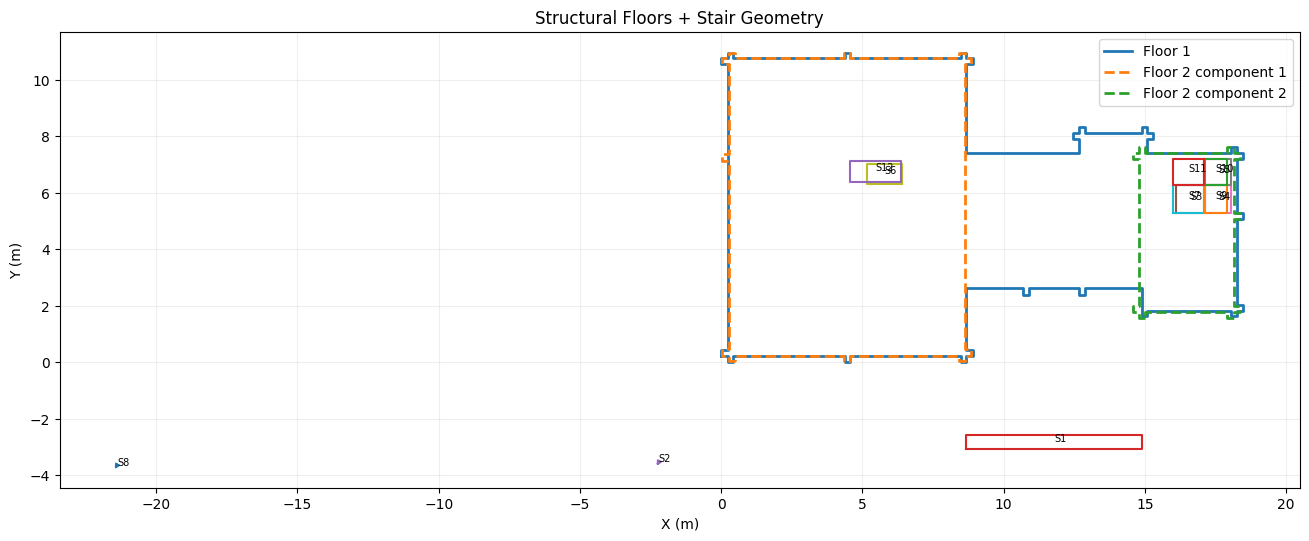


DIAGNOSTIC CONCLUSION
Floor-2 components : 2
Component separation : 5.884 m
Stair geometries : 12
⚠️ No demonstrated structural bridge between the two Floor-2 components.

No geometry was modified.


In [90]:
# ============================================================================
# STRUCTURAL CONNECTIVITY DIAGNOSTIC
# ============================================================================
#
# Focus ONLY:
#   - Floor 1 structural footprint
#   - Floor 2 structural components
#   - stairs / flights / winding elements
#
# Ignore:
#   - doors
#   - windows
#   - furniture
#
# NO 3D geometry is modified.
# ============================================================================

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import Polygon
from shapely.ops import unary_union


# ============================================================================
# VERIFIED PARAMETERS
# ============================================================================

SVG_PER_M = 100.01457736449694

FLOOR2_DX = -1918.500
FLOOR2_DY = -11.650

ORIGIN_X = 224.180
ORIGIN_Y = 358.570


# ============================================================================
# 1. PARENT MAP FOR xml.etree.ElementTree
# ============================================================================

parent_map = {
    child: parent
    for parent in root.iter()
    for child in parent
}


# ============================================================================
# 2. FULL SVG TRANSFORM
# ============================================================================

def parse_transform(transform):

    if not transform:
        return np.eye(3)

    M = np.eye(3)

    commands = re.findall(
        r'([a-zA-Z]+)\s*\(([^)]*)\)',
        transform
    )

    for name, values in commands:

        vals = [
            float(x)
            for x in re.findall(
                r'[-+]?(?:\d*\.\d+|\d+\.?)'
                r'(?:[eE][-+]?\d+)?',
                values
            )
        ]

        name = name.lower()

        if name == "matrix" and len(vals) == 6:

            a, b, c, d, e, f = vals

            T = np.array([
                [a, c, e],
                [b, d, f],
                [0, 0, 1]
            ])

        elif name == "translate":

            tx = vals[0] if len(vals) >= 1 else 0
            ty = vals[1] if len(vals) >= 2 else 0

            T = np.array([
                [1, 0, tx],
                [0, 1, ty],
                [0, 0, 1]
            ])

        elif name == "scale":

            sx = vals[0] if len(vals) >= 1 else 1
            sy = vals[1] if len(vals) >= 2 else sx

            T = np.array([
                [sx, 0, 0],
                [0, sy, 0],
                [0, 0, 1]
            ])

        elif name == "rotate":

            angle = math.radians(
                vals[0]
            )

            c = math.cos(angle)
            s = math.sin(angle)

            T = np.array([
                [c, -s, 0],
                [s,  c, 0],
                [0,  0, 1]
            ])

        else:
            continue

        M = M @ T

    return M


def get_global_transform(element):

    chain = []

    node = element

    while node is not None:

        chain.append(node)

        node = parent_map.get(node)

    M = np.eye(3)

    for node in reversed(chain):

        transform = node.get(
            "transform"
        )

        if transform:
            M = (
                M
                @ parse_transform(transform)
            )

    return M


# ============================================================================
# 3. SVG POLYGON PARSER
# ============================================================================

def parse_points(points_string):

    nums = [
        float(x)
        for x in re.findall(
            r'[-+]?(?:\d*\.\d+|\d+\.?)'
            r'(?:[eE][-+]?\d+)?',
            points_string or ""
        )
    ]

    if len(nums) < 6:
        return []

    return [
        (
            nums[i],
            nums[i + 1]
        )
        for i in range(
            0,
            len(nums),
            2
        )
    ]


def transform_points(
    points,
    M
):

    result = []

    for x, y in points:

        p = np.array([
            x,
            y,
            1.0
        ])

        q = M @ p

        result.append(
            (
                float(q[0]),
                float(q[1])
            )
        )

    return result


# ============================================================================
# 4. DETERMINE WHICH FLOOR CONTAINS AN ELEMENT
# ============================================================================

def containing_floor(element):

    node = element

    while node is not None:

        eid = node.get(
            "id",
            ""
        )

        cls = node.get(
            "class",
            ""
        )

        text = f"{eid} {cls}"

        if "Floor-1" in text:
            return "Floor 1"

        if "Floor-2" in text:
            return "Floor 2"

        node = parent_map.get(node)

    return "Unknown"


# ============================================================================
# 5. EXTRACT STAIR / FLIGHT / WINDING GEOMETRY
# ============================================================================

STAIR_CLASSES = {
    "Stairs",
    "Flight",
    "Winding"
}

stair_records = []

seen_geometry = set()

for element in root.iter():

    classes = set(
        (
            element.get(
                "class",
                ""
            )
        ).split()
    )

    matched_classes = (
        classes
        & STAIR_CLASSES
    )

    if not matched_classes:
        continue

    floor_name = containing_floor(
        element
    )

    M = get_global_transform(
        element
    )

    # Find descendant polygons.
    for child in element.iter():

        if not child.tag.endswith(
            "polygon"
        ):
            continue

        points = parse_points(
            child.get(
                "points",
                ""
            )
        )

        if len(points) < 3:
            continue

        global_points = transform_points(
            points,
            M
        )

        # Deduplicate exact geometry that is encountered through
        # nested Stairs / Flight / Winding groups.
        key = (
            floor_name,
            tuple(
                (
                    round(x, 4),
                    round(y, 4)
                )
                for x, y in global_points
            )
        )

        if key in seen_geometry:
            continue

        seen_geometry.add(key)

        poly = Polygon(
            global_points
        )

        if not poly.is_valid:
            poly = poly.buffer(0)

        if poly.is_empty:
            continue

        stair_records.append({

            "floor": floor_name,

            "class": ",".join(
                sorted(
                    matched_classes
                )
            ),

            "polygon": poly,

            "area_svg": poly.area,

            "centroid_x_svg":
                poly.centroid.x,

            "centroid_y_svg":
                poly.centroid.y
        })


# ============================================================================
# 6. BUILD ALIGNED FLOOR-2 STAIR GEOMETRY
# ============================================================================

for record in stair_records:

    if record["floor"] == "Floor 2":

        from shapely.affinity import translate

        record["polygon_aligned"] = (
            translate(
                record["polygon"],
                xoff=FLOOR2_DX,
                yoff=FLOOR2_DY
            )
        )

    else:

        record["polygon_aligned"] = (
            record["polygon"]
        )


print("=" * 100)
print("STAIR / VERTICAL GEOMETRY")
print("=" * 100)

print(
    "Unique stair geometries extracted:",
    len(stair_records)
)

if stair_records:

    stair_summary = pd.DataFrame([

        {
            "floor": r["floor"],
            "class": r["class"],
            "area_m2":
                r["area_svg"]
                / SVG_PER_M ** 2,
            "x_m":
                (
                    r["polygon_aligned"].centroid.x
                    - ORIGIN_X
                ) / SVG_PER_M,
            "y_m":
                (
                    r["polygon_aligned"].centroid.y
                    - ORIGIN_Y
                ) / SVG_PER_M
        }

        for r in stair_records
    ])

    display(
        stair_summary
    )


# ============================================================================
# 7. REBUILD ALIGNED FLOOR-2 STRUCTURAL COMPONENTS
# ============================================================================

from shapely.affinity import translate

f2_clean = []

for p in floor2_wall_polygons:

    if hasattr(
        p,
        "is_empty"
    ):

        poly = p

    else:

        poly = Polygon(
            np.asarray(
                p,
                dtype=float
            )
        )

    if not poly.is_valid:
        poly = poly.buffer(0)

    if (
        not poly.is_empty
        and poly.area > 0
    ):
        f2_clean.append(
            poly
        )

f2_aligned_polys = [

    translate(
        p,
        xoff=FLOOR2_DX,
        yoff=FLOOR2_DY
    )

    for p in f2_clean
]

f2_union = unary_union(
    f2_aligned_polys
)

if f2_union.geom_type == "Polygon":

    f2_components = [
        f2_union
    ]

elif f2_union.geom_type == "MultiPolygon":

    f2_components = list(
        f2_union.geoms
    )

else:

    f2_components = [
        g
        for g in getattr(
            f2_union,
            "geoms",
            []
        )
        if g.geom_type == "Polygon"
    ]

f2_components = sorted(
    f2_components,
    key=lambda x: x.area,
    reverse=True
)


# ============================================================================
# 8. COMPONENT SEPARATION
# ============================================================================

print()
print("=" * 100)
print("FLOOR-2 STRUCTURAL COMPONENTS")
print("=" * 100)

component_rows = []

for i, component in enumerate(
    f2_components,
    start=1
):

    b = component.bounds

    component_rows.append({

        "component":
            i,

        "area_m2":
            component.area
            / SVG_PER_M ** 2,

        "x_min_m":
            (
                b[0] - ORIGIN_X
            ) / SVG_PER_M,

        "x_max_m":
            (
                b[2] - ORIGIN_X
            ) / SVG_PER_M,

        "y_min_m":
            (
                b[1] - ORIGIN_Y
            ) / SVG_PER_M,

        "y_max_m":
            (
                b[3] - ORIGIN_Y
            ) / SVG_PER_M
    })


display(
    pd.DataFrame(
        component_rows
    )
)

if len(
    f2_components
) >= 2:

    separation_svg = (
        f2_components[0]
        .distance(
            f2_components[1]
        )
    )

    separation_m = (
        separation_svg
        / SVG_PER_M
    )

    print()
    print(
        f"Component separation: "
        f"{separation_m:.3f} m"
    )

else:

    separation_m = 0.0

    print(
        "Floor 2 has one connected "
        "structural component."
    )


# ============================================================================
# 9. DISTANCE FROM STAIRS TO EACH FLOOR-2 COMPONENT
# ============================================================================

print()
print("=" * 100)
print("STAIR ↔ FLOOR-2 COMPONENT RELATIONSHIP")
print("=" * 100)

relationship_rows = []

for i, record in enumerate(
    stair_records
):

    if record["floor"] != "Floor 2":
        continue

    stair_poly = record[
        "polygon_aligned"
    ]

    distances = [

        stair_poly.distance(
            component
        ) / SVG_PER_M

        for component in
        f2_components
    ]

    relationship_rows.append({

        "stair_index":
            i,

        "class":
            record["class"],

        "component_1_distance_m":
            round(
                distances[0],
                3
            )
            if len(distances) >= 1
            else None,

        "component_2_distance_m":
            round(
                distances[1],
                3
            )
            if len(distances) >= 2
            else None,

        "nearest_component":
            int(
                np.argmin(
                    distances
                ) + 1
            )
            if distances
            else None,

        "distance_to_nearest_m":
            round(
                min(distances),
                3
            )
            if distances
            else None
    })


if relationship_rows:

    relationship_df = pd.DataFrame(
        relationship_rows
    )

    display(
        relationship_df.sort_values(
            "distance_to_nearest_m"
        )
    )

else:

    relationship_df = pd.DataFrame()

    print(
        "No Floor-2 stair geometry found."
    )


# ============================================================================
# 10. CHECK FOR A STAIR BRIDGING THE TWO COMPONENTS
# ============================================================================

print()
print("=" * 100)
print("BRIDGING-STAIR TEST")
print("=" * 100)

bridging_candidates = []

if (
    len(f2_components) >= 2
    and relationship_rows
):

    for row in relationship_rows:

        d1 = row[
            "component_1_distance_m"
        ]

        d2 = row[
            "component_2_distance_m"
        ]

        if (
            d1 is not None
            and d2 is not None
            and d1 < 1.0
            and d2 < 1.0
        ):

            bridging_candidates.append(
                row
            )

if bridging_candidates:

    print(
        "Potential stair/vertical geometry "
        "bridging both Floor-2 components:"
    )

    display(
        pd.DataFrame(
            bridging_candidates
        )
    )

else:

    print(
        "No stair geometry was found within "
        "1.0 m of BOTH Floor-2 components."
    )

    print(
        "This means we should NOT automatically "
        "connect the two components in 3D."
    )


# ============================================================================
# 11. COMMON 2D STRUCTURAL MAP
# ============================================================================

print()
print("=" * 100)
print("STRUCTURAL MAP")
print("=" * 100)

# Floor 1 union
f1_clean = []

for p in floor1_wall_polygons:

    if hasattr(
        p,
        "is_empty"
    ):
        poly = p
    else:
        poly = Polygon(
            np.asarray(
                p,
                dtype=float
            )
        )

    if not poly.is_valid:
        poly = poly.buffer(0)

    if (
        not poly.is_empty
        and poly.area > 0
    ):
        f1_clean.append(
            poly
        )

f1_union = unary_union(
    f1_clean
)


def convert_poly_to_metric(
    poly
):

    if poly.is_empty:
        return poly

    return Polygon([

        (
            (
                x - ORIGIN_X
            ) / SVG_PER_M,

            (
                y - ORIGIN_Y
            ) / SVG_PER_M
        )

        for x, y
        in poly.exterior.coords
    ])


fig, ax = plt.subplots(
    figsize=(16, 10)
)


# Floor 1
if f1_union.geom_type == "Polygon":

    f1_plot = [f1_union]

else:

    f1_plot = list(
        f1_union.geoms
    )


for poly in f1_plot:

    p = convert_poly_to_metric(
        poly
    )

    x, y = p.exterior.xy

    ax.plot(
        x,
        y,
        linewidth=2,
        label="Floor 1"
    )


# Floor 2 components
for idx, component in enumerate(
    f2_components,
    start=1
):

    p = convert_poly_to_metric(
        component
    )

    x, y = p.exterior.xy

    ax.plot(
        x,
        y,
        linestyle="--",
        linewidth=2,
        label=f"Floor 2 component {idx}"
    )


# Stairs
for idx, record in enumerate(
    stair_records,
    start=1
):

    p = convert_poly_to_metric(
        record["polygon_aligned"]
    )

    x, y = p.exterior.xy

    ax.plot(
        x,
        y,
        linewidth=1.5
    )

    c = p.centroid

    ax.text(
        c.x,
        c.y,
        f"S{idx}",
        fontsize=7
    )


ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(
    "X (m)"
)

ax.set_ylabel(
    "Y (m)"
)

ax.set_title(
    "Structural Floors + Stair Geometry"
)

ax.grid(
    True,
    alpha=0.2
)

ax.legend()

plt.show()


# ============================================================================
# 12. FINAL DIAGNOSTIC
# ============================================================================

print()
print("=" * 100)
print("DIAGNOSTIC CONCLUSION")
print("=" * 100)

print(
    f"Floor-2 components : {len(f2_components)}"
)

print(
    f"Component separation : "
    f"{separation_m:.3f} m"
)

print(
    f"Stair geometries : "
    f"{len(stair_records)}"
)

if bridging_candidates:

    print(
        "⚠️ Stair geometry may connect the two Floor-2 "
        "structural components."
    )

else:

    print(
        "⚠️ No demonstrated structural bridge between "
        "the two Floor-2 components."
    )

print()
print(
    "No geometry was modified."
)

In [91]:
# ============================================================================
# FAST / BOUNDED CUBICASA MULTI-FLOOR DISCOVERY
# ============================================================================
#
# IMPORTANT:
#   This is intentionally ONLY the discovery stage.
#   We are NOT building 3D yet.
#
#   Why:
#   The previous cell combined:
#       remote ZIP scan
#       floor detection
#       SVG extraction
#       geometry parsing
#       3D construction
#       visualization
#
#   If the remote scan stalls, everything stalls.
#
#   This version:
#       - scans only 60 SVGs
#       - prints progress every file
#       - stops as soon as it finds >= 3 real floors
#       - extracts that SVG immediately
#       - does NOT touch your existing 2-floor model
# ============================================================================

import os
import re
import time
import zipfile
import pandas as pd


# ============================================================================
# SETTINGS
# ============================================================================

MAX_SCAN = 60
TARGET_FLOORS = 3
MAX_SVG_SIZE_MB = 2.0

START_TIME = time.time()


# ============================================================================
# 1. REUSE EXISTING REMOTE ZIP IF AVAILABLE
# ============================================================================

print("=" * 90)
print("FAST CUBICASA MULTI-FLOOR SEARCH")
print("=" * 90)

if (
    "zf" in globals()
    and "model_infos" in globals()
):

    print(
        "✅ Reusing the already-open remote ZIP."
    )

else:

    print(
        "Existing remote ZIP handle not available."
    )

    print(
        "Opening CubiCasa5K archive..."
    )

    import requests
    import fsspec

    api_url = (
        "https://zenodo.org/api/records"
    )

    r = requests.get(
        api_url,
        params={
            "q": "CubiCasa5k",
            "size": 20
        },
        timeout=30
    )

    r.raise_for_status()

    hits = (
        r.json()
        .get("hits", {})
        .get("hits", [])
    )

    zip_url = None

    for record in hits:

        for f in record.get(
            "files",
            []
        ):

            name = (
                f.get("key")
                or f.get("filename")
                or ""
            )

            if name.lower() == (
                "cubicasa5k.zip"
            ):

                zip_url = (
                    f.get("links", {})
                    .get("self")
                )

                break

        if zip_url:
            break

    if not zip_url:
        raise RuntimeError(
            "Could not locate cubicasa5k.zip."
        )

    remote_file = fsspec.open(
        zip_url,
        mode="rb",
        block_size=8 * 1024 * 1024,
        cache_type="readahead"
    ).open()

    zf = zipfile.ZipFile(
        remote_file
    )

    model_infos = [
        info
        for info in zf.infolist()
        if (
            info.filename.lower()
            .endswith("model.svg")
            and not info.is_dir()
        )
    ]


print()
print(
    "Total model.svg entries:",
    len(model_infos)
)


# ============================================================================
# 2. SORT BY SIZE
# ============================================================================
#
# Larger SVGs are a useful heuristic for finding richer/more complex plans.
# ============================================================================

scan_list = sorted(
    model_infos,
    key=lambda x: x.file_size,
    reverse=True
)

scan_list = [
    x
    for x in scan_list
    if (
        x.file_size
        <= MAX_SVG_SIZE_MB * 1024 * 1024
    )
][:MAX_SCAN]


print(
    f"Candidate files to scan: {len(scan_list)}"
)

print(
    f"Size range: "
    f"{scan_list[-1].file_size / 1024:.1f} KB → "
    f"{scan_list[0].file_size / 1024:.1f} KB"
)


# ============================================================================
# 3. FLOOR DETECTOR
# ============================================================================

floor_pattern = re.compile(
    r"\bFloor-(\d+)\b"
)


def detect_floor_numbers(
    data
):

    text = data.decode(
        "utf-8",
        errors="ignore"
    )

    return sorted(
        {
            int(n)
            for n in floor_pattern.findall(
                text
            )
        }
    )


# ============================================================================
# 4. SCAN WITH VISIBLE PROGRESS
# ============================================================================

results = []
best = None


for i, info in enumerate(
    scan_list,
    start=1
):

    t0 = time.time()

    print()
    print(
        f"[{i:02d}/{len(scan_list)}] "
        f"Reading {info.filename}"
    )

    print(
        f"    SVG size: "
        f"{info.file_size / 1024:.1f} KB"
    )

    try:

        data = zf.read(
            info
        )

        floors = detect_floor_numbers(
            data
        )

        floor_count = len(
            floors
        )

        print(
            f"    Floors found: "
            f"{floors if floors else 'NONE'}"
        )

        elapsed = (
            time.time()
            - t0
        )

        print(
            f"    Read time: "
            f"{elapsed:.2f} s"
        )

        results.append({

            "path":
                info.filename,

            "size_kb":
                round(
                    info.file_size
                    / 1024,
                    1
                ),

            "floor_count":
                floor_count,

            "floors":
                str(floors)
        })


        # ----------------------------------------------------
        # Keep best result
        # ----------------------------------------------------

        if (
            best is None
            or floor_count
            > best["floor_count"]
        ):

            best = {
                "info":
                    info,

                "data":
                    data,

                "floor_count":
                    floor_count,

                "floors":
                    floors
            }

            print(
                "    ⭐ NEW BEST"
            )


        # ----------------------------------------------------
        # Stop early if >= 3 real floors
        # ----------------------------------------------------

        if floor_count >= TARGET_FLOORS:

            print()
            print(
                "=" * 90
            )

            print(
                f"✅ REAL {floor_count}-FLOOR "
                f"BUILDING FOUND"
            )

            print(
                best["info"].filename
            )

            print(
                "Floors:",
                best["floors"]
            )

            break


    except Exception as e:

        print(
            f"    ⚠️ ERROR: {e}"
        )


# ============================================================================
# 5. RESULTS
# ============================================================================

print()
print("=" * 90)
print("DISCOVERY RESULTS")
print("=" * 90)

if results:

    result_df = pd.DataFrame(
        results
    ).sort_values(
        [
            "floor_count",
            "size_kb"
        ],
        ascending=[
            False,
            False
        ]
    )

    display(
        result_df
    )

else:

    print(
        "No readable model.svg files were scanned."
    )


# ============================================================================
# 6. EXTRACT BEST REAL MULTI-FLOOR SVG
# ============================================================================

if best is None:

    raise RuntimeError(
        "No usable SVG was found."
    )


BEST_SVG = (
    "cubicasa_best_multifloor_real_model.svg"
)

with open(
    BEST_SVG,
    "wb"
) as f:

    f.write(
        best["data"]
    )


print()
print("=" * 90)
print("SELECTED MODEL")
print("=" * 90)

print(
    "File:",
    best["info"].filename
)

print(
    "Real floors:",
    best["floors"]
)

print(
    "Floor count:",
    best["floor_count"]
)

print(
    "Saved:",
    BEST_SVG
)

print()
print(
    f"Total discovery time: "
    f"{time.time() - START_TIME:.1f} s"
)

print()
print("=" * 90)
print("NEXT STEP")
print("=" * 90)

if best["floor_count"] >= 3:

    print(
        "✅ We found a genuinely multi-floor CubiCasa building."
    )

    print(
        "The next cell can parse THIS selected SVG and build "
        "all of its real floors in 3D."
    )

else:

    print(
        "⚠️ The first bounded scan did not find a 3+ floor building."
    )

    print(
        "The best available sample was:",
        best["floor_count"],
        "floor(s)."
    )

    print(
        "We can expand the scan without rebuilding anything."
    )

FAST CUBICASA MULTI-FLOOR SEARCH
✅ Reusing the already-open remote ZIP.

Total model.svg entries: 5000
Candidate files to scan: 60
Size range: 179.0 KB → 703.9 KB

[01/60] Reading cubicasa5k/high_quality_architectural/9875/model.svg
    SVG size: 703.9 KB
    Floors found: [1, 2, 3]
    Read time: 7.83 s
    ⭐ NEW BEST

✅ REAL 3-FLOOR BUILDING FOUND
cubicasa5k/high_quality_architectural/9875/model.svg
Floors: [1, 2, 3]

DISCOVERY RESULTS


,path,size_kb,floor_count,floors
0,cubicasa5k/high_quality_architectural/9875/mod...,703.9,3,"[1, 2, 3]"



SELECTED MODEL
File: cubicasa5k/high_quality_architectural/9875/model.svg
Real floors: [1, 2, 3]
Floor count: 3
Saved: cubicasa_best_multifloor_real_model.svg

Total discovery time: 7.9 s

NEXT STEP
✅ We found a genuinely multi-floor CubiCasa building.
The next cell can parse THIS selected SVG and build all of its real floors in 3D.


In [92]:
# ============================================================================
# CUBICASA SAMPLE 9875 — REAL 3-FLOOR STRUCTURAL BUILDING
# ============================================================================
#
# REAL SOURCE:
#   cubicasa5k/high_quality_architectural/9875/model.svg
#
# FLOORS:
#   Floor 1 = real
#   Floor 2 = real
#   Floor 3 = real
#
# DOES NOT:
#   - synthesize additional floors
#   - use doors
#   - use windows
#   - use furniture
#   - repair wall gaps
#   - modify the original 6652 model
#
# PURPOSE:
#   Build the first genuine multi-floor CubiCasa building in 3D.
# ============================================================================

import os
import re
import math
import numpy as np
import pandas as pd
import trimesh
import plotly.graph_objects as go

from xml.etree import ElementTree as ET
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.affinity import translate


# ============================================================================
# PARAMETERS
# ============================================================================

SVG_FILE = "cubicasa_best_multifloor_real_model.svg"

FLOOR_HEIGHT_M = 3.0
SLAB_THICKNESS_M = 0.15

SVG_UNITS_PER_METER = 100.0

OUTPUT_FILE = (
    "cubicasa_9875_real_3_floor_building.glb"
)


# ============================================================================
# 1. LOAD SVG
# ============================================================================

if not os.path.exists(SVG_FILE):

    raise FileNotFoundError(
        f"Could not find {SVG_FILE}"
    )

tree = ET.parse(
    SVG_FILE
)

root = tree.getroot()

print("=" * 100)
print("CUBICASA 9875 — REAL 3-FLOOR BUILDING")
print("=" * 100)

print()
print("SVG:",
      SVG_FILE)


# ============================================================================
# 2. PARENT MAP
# ============================================================================

parent_map = {
    child: parent
    for parent in root.iter()
    for child in parent
}


# ============================================================================
# 3. TRANSFORM UTILITIES
# ============================================================================

def parse_transform(
    transform
):

    if not transform:
        return np.eye(3)

    M = np.eye(3)

    commands = re.findall(
        r'([a-zA-Z]+)\s*\(([^)]*)\)',
        transform
    )

    for name, values in commands:

        nums = [
            float(x)
            for x in re.findall(
                r'[-+]?(?:\d*\.\d+|\d+\.?)'
                r'(?:[eE][-+]?\d+)?',
                values
            )
        ]

        name = name.lower()

        if name == "matrix" and len(nums) == 6:

            a, b, c, d, e, f = nums

            T = np.array([
                [a, c, e],
                [b, d, f],
                [0, 0, 1]
            ])

        elif name == "translate":

            tx = nums[0] if len(nums) else 0
            ty = nums[1] if len(nums) > 1 else 0

            T = np.array([
                [1, 0, tx],
                [0, 1, ty],
                [0, 0, 1]
            ])

        elif name == "scale":

            sx = nums[0] if len(nums) else 1
            sy = nums[1] if len(nums) > 1 else sx

            T = np.array([
                [sx, 0, 0],
                [0, sy, 0],
                [0, 0, 1]
            ])

        elif name == "rotate":

            angle = math.radians(
                nums[0]
            )

            c = math.cos(angle)
            s = math.sin(angle)

            T = np.array([
                [c, -s, 0],
                [s,  c, 0],
                [0,  0, 1]
            ])

        else:

            continue

        M = M @ T

    return M


def get_global_transform(
    element
):

    chain = []

    node = element

    while node is not None:

        chain.append(
            node
        )

        node = parent_map.get(
            node
        )

    M = np.eye(3)

    for node in reversed(
        chain
    ):

        t = node.get(
            "transform"
        )

        if t:

            M = (
                M
                @ parse_transform(t)
            )

    return M


# ============================================================================
# 4. FIND FLOOR GROUPS
# ============================================================================

floor_pattern = re.compile(
    r"Floor-(\d+)"
)

floor_groups = {}

for element in root.iter():

    element_id = (
        element.get(
            "id",
            ""
        )
    )

    classes = (
        element.get(
            "class",
            ""
        )
    ).split()

    text = (
        element_id
        + " "
        + " ".join(classes)
    )

    match = floor_pattern.search(
        text
    )

    if not match:
        continue

    floor_number = int(
        match.group(1)
    )

    # Prefer a Floorplan class if available.
    if (
        floor_number not in floor_groups
        or "Floorplan" in classes
    ):

        floor_groups[
            floor_number
        ] = element


real_floor_numbers = sorted(
    floor_groups.keys()
)


print()
print("=" * 100)
print("REAL FLOOR GROUPS")
print("=" * 100)

print(
    "Detected:",
    real_floor_numbers
)

if real_floor_numbers != [1, 2, 3]:

    print(
        "WARNING: expected [1,2,3], "
        "but detected:",
        real_floor_numbers
    )


# ============================================================================
# 5. SVG POINT PARSER
# ============================================================================

def parse_points(
    points_string
):

    nums = [
        float(x)
        for x in re.findall(
            r'[-+]?(?:\d*\.\d+|\d+\.?)'
            r'(?:[eE][-+]?\d+)?',
            points_string or ""
        )
    ]

    if len(nums) < 6:
        return []

    return [
        (
            nums[i],
            nums[i + 1]
        )
        for i in range(
            0,
            len(nums),
            2
        )
    ]


def transform_points(
    points,
    M
):

    out = []

    for x, y in points:

        q = M @ np.array([
            x,
            y,
            1.0
        ])

        out.append(
            (
                float(q[0]),
                float(q[1])
            )
        )

    return out


# ============================================================================
# 6. EXTRACT STRUCTURAL WALLS
# ============================================================================

def extract_wall_polygons(
    floor_element
):

    walls = []

    for element in floor_element.iter():

        classes = (
            element.get(
                "class",
                ""
            )
        ).split()

        if "Wall" not in classes:
            continue

        # IMPORTANT:
        # direct polygon children only
        # prevents Window/Glass/Panel geometry
        # from being counted.

        for child in element:

            if not child.tag.endswith(
                "polygon"
            ):
                continue

            points = parse_points(
                child.get(
                    "points",
                    ""
                )
            )

            if len(points) < 3:
                continue

            M = get_global_transform(
                child
            )

            global_points = (
                transform_points(
                    points,
                    M
                )
            )

            poly = Polygon(
                global_points
            )

            if not poly.is_valid:
                poly = poly.buffer(0)

            if (
                poly.is_empty
                or poly.area <= 0
            ):
                continue

            walls.append(
                poly
            )

    return walls


floor_data = {}

for floor_number in real_floor_numbers:

    walls = extract_wall_polygons(
        floor_groups[
            floor_number
        ]
    )

    floor_data[
        floor_number
    ] = {

        "walls":
            walls
    }


print()
print("=" * 100)
print("REAL STRUCTURAL WALL EXTRACTION")
print("=" * 100)

for floor_number in real_floor_numbers:

    print(
        f"Floor {floor_number}: "
        f"{len(floor_data[floor_number]['walls'])} "
        f"wall polygons"
    )


# ============================================================================
# 7. CREATE LOCAL FLOOR COORDINATE SYSTEMS
# ============================================================================
#
# For this exploratory multi-floor visualization, each floor is translated
# into a common local XY frame using the CENTER of its structural bounds.
#
# This avoids the side-by-side placement used by many SVG floorplans.
#
# This is a visualization alignment, not survey-grade floor registration.
# ============================================================================

for floor_number in real_floor_numbers:

    walls = floor_data[
        floor_number
    ]["walls"]

    if not walls:
        continue

    points = np.vstack([

        np.asarray(
            list(
                p.exterior.coords
            ),
            dtype=float
        )

        for p in walls
    ])

    minx = points[:,0].min()
    maxx = points[:,0].max()

    miny = points[:,1].min()
    maxy = points[:,1].max()

    cx = (
        minx + maxx
    ) / 2

    cy = (
        miny + maxy
    ) / 2

    floor_data[
        floor_number
    ]["center"] = (
        cx,
        cy
    )

    floor_data[
        floor_number
    ]["width_svg"] = (
        maxx - minx
    )

    floor_data[
        floor_number
    ]["height_svg"] = (
        maxy - miny
    )

    floor_data[
        floor_number
    ]["aligned_walls"] = [

        translate(
            p,
            xoff=-cx,
            yoff=-cy
        )

        for p in walls
    ]


# ============================================================================
# 8. REPORT REAL FLOOR DIMENSIONS
# ============================================================================

print()
print("=" * 100)
print("REAL FLOOR DIMENSIONS")
print("=" * 100)

dimension_rows = []

for floor_number in real_floor_numbers:

    d = floor_data[
        floor_number
    ]

    dimension_rows.append({

        "floor":
            floor_number,

        "wall_count":
            len(
                d["walls"]
            ),

        "width_m":
            round(
                d["width_svg"]
                / SVG_UNITS_PER_METER,
                3
            ),

        "depth_m":
            round(
                d["height_svg"]
                / SVG_UNITS_PER_METER,
                3
            )
    })


display(
    pd.DataFrame(
        dimension_rows
    )
)


# ============================================================================
# 9. BUILD 3D FLOORS
# ============================================================================

all_meshes = []
floor_mesh_groups = []

for index, floor_number in enumerate(
    real_floor_numbers
):

    walls = floor_data[
        floor_number
    ]["aligned_walls"]

    z0 = (
        index
        * FLOOR_HEIGHT_M
    )

    z1 = (
        z0
        + FLOOR_HEIGHT_M
    )

    level_meshes = []

    for wall in walls:

        # Convert SVG → metres.
        coords = np.asarray(
            list(
                wall.exterior.coords
            ),
            dtype=float
        )

        coords_m = (
            coords
            / SVG_UNITS_PER_METER
        )

        poly_m = Polygon(
            coords_m
        )

        if not poly_m.is_valid:
            poly_m = poly_m.buffer(0)

        if poly_m.is_empty:
            continue

        if isinstance(
            poly_m,
            MultiPolygon
        ):

            parts = list(
                poly_m.geoms
            )

        else:

            parts = [
                poly_m
            ]

        for part in parts:

            try:

                wall_mesh = (
                    trimesh.creation
                    .extrude_polygon(
                        part,
                        height=
                        FLOOR_HEIGHT_M
                    )
                )

                wall_mesh.apply_translation(
                    [0, 0, z0]
                )

                level_meshes.append(
                    wall_mesh
                )

            except Exception:
                continue


    # ------------------------------------------------------------
    # Provisional slab from structural wall envelope
    # ------------------------------------------------------------

    wall_union = unary_union(
        walls
    )

    slab_footprint = (
        wall_union
        .buffer(
            HALF_WALL_THICKNESS_M
        )
    )

    slab_meshes = []

    if (
        not slab_footprint.is_empty
    ):

        parts = (

            list(
                slab_footprint.geoms
            )

            if isinstance(
                slab_footprint,
                MultiPolygon
            )

            else [
                slab_footprint
            ]
        )

        for part in parts:

            coords = np.asarray(
                list(
                    part.exterior.coords
                ),
                dtype=float
            )

            coords_m = (
                coords
                / SVG_UNITS_PER_METER
            )

            slab_poly = Polygon(
                coords_m
            )

            if not slab_poly.is_valid:
                slab_poly = (
                    slab_poly
                    .buffer(0)
                )

            try:

                slab = (
                    trimesh.creation
                    .extrude_polygon(
                        slab_poly,
                        height=
                        SLAB_THICKNESS_M
                    )
                )

                slab.apply_translation(
                    [
                        0,
                        0,
                        z0
                        - SLAB_THICKNESS_M
                    ]
                )

                slab_meshes.append(
                    slab
                )

            except Exception:
                pass


    level_all = (
        level_meshes
        + slab_meshes
    )

    level_combined = (
        trimesh.util.concatenate(
            level_all
        )
        if level_all
        else None
    )

    if level_combined is not None:

        all_meshes.extend(
            level_all
        )

    floor_mesh_groups.append(
        {
            "floor":
                floor_number,

            "walls":
                wall_mesh
                if level_meshes
                else None,

            "all":
                level_combined,

            "z0":
                z0,

            "z1":
                z1
        }
    )


# ============================================================================
# 10. COMBINE REAL FLOORS
# ============================================================================

if not all_meshes:

    raise RuntimeError(
        "No 3D geometry was created."
    )

real_3floor_model = (
    trimesh.util.concatenate(
        all_meshes
    )
)


# ============================================================================
# 11. ORIENTATION
# ============================================================================

if (
    real_3floor_model.is_watertight
    and real_3floor_model.volume < 0
):

    real_3floor_model.faces = (
        real_3floor_model.faces[:, ::-1]
    )


# ============================================================================
# 12. VALIDATION
# ============================================================================

print()
print("=" * 100)
print("REAL 3-FLOOR 3D MODEL")
print("=" * 100)

print(
    "Real floors:",
    len(real_floor_numbers)
)

print(
    "Vertices:",
    len(
        real_3floor_model.vertices
    )
)

print(
    "Faces:",
    len(
        real_3floor_model.faces
    )
)

print(
    "Watertight:",
    real_3floor_model.is_watertight
)

print(
    "Valid volume:",
    real_3floor_model.is_volume
)

print(
    "Volume:",
    round(
        real_3floor_model.volume,
        3
    ),
    "m³"
)

b = (
    real_3floor_model.bounds
)

print()
print(
    f"X: {b[0,0]:.3f} → "
    f"{b[1,0]:.3f} m"
)

print(
    f"Y: {b[0,1]:.3f} → "
    f"{b[1,1]:.3f} m"
)

print(
    f"Z: {b[0,2]:.3f} → "
    f"{b[1,2]:.3f} m"
)

print(
    f"Total building height: "
    f"{b[1,2] - b[0,2]:.3f} m"
)


# ============================================================================
# 13. FLOOR-BY-FLOOR SUMMARY
# ============================================================================

print()
print("=" * 100)
print("FLOOR STACK")
print("=" * 100)

for group in floor_mesh_groups:

    if group["all"] is None:
        continue

    fb = group[
        "all"
    ].bounds

    print(
        f"Floor {group['floor']}: "
        f"Z={group['z0']:.2f} → "
        f"{group['z1']:.2f} m | "
        f"XY="
        f"{fb[1,0]-fb[0,0]:.3f} × "
        f"{fb[1,1]-fb[0,1]:.3f} m"
    )


# ============================================================================
# 14. EXPORT
# ============================================================================

real_3floor_model.export(
    OUTPUT_FILE
)

print()
print("=" * 100)
print("EXPORT")
print("=" * 100)

print(
    f"✅ {OUTPUT_FILE}"
)


# ============================================================================
# 15. 3D VISUALIZATION
# ============================================================================

fig = go.Figure()

for group in floor_mesh_groups:

    floor_mesh = group[
        "all"
    ]

    if floor_mesh is None:
        continue

    v = floor_mesh.vertices
    f = floor_mesh.faces

    fig.add_trace(
        go.Mesh3d(

            x=v[:,0],
            y=v[:,1],
            z=v[:,2],

            i=f[:,0],
            j=f[:,1],
            k=f[:,2],

            opacity=0.50,

            name=(
                f"Real Floor "
                f"{group['floor']}"
            ),

            hovertemplate=(
                f"Real Floor "
                f"{group['floor']}<br>"
                "X: %{x:.2f} m<br>"
                "Y: %{y:.2f} m<br>"
                "Z: %{z:.2f} m"
                "<extra></extra>"
            )
        )
    )


fig.update_layout(

    title=(
        "CubiCasa 9875 — "
        "REAL 3-FLOOR STRUCTURAL BUILDING"
    ),

    scene=dict(

        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.6,
                y=1.6,
                z=1.25
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=50,
        b=0
    )
)

fig.show()


# ============================================================================
# FINAL STATUS
# ============================================================================

print()
print("=" * 100)
print("FINAL STATUS")
print("=" * 100)

print(
    "✅ Uses real Floor 1"
)

print(
    "✅ Uses real Floor 2"
)

print(
    "✅ Uses real Floor 3"
)

print(
    "✅ No synthetic floors"
)

print(
    "✅ No doors/windows/furniture"
)

print(
    "✅ No automatic gap repair"
)

print(
    "✅ Original 6652 model untouched"
)

print()
print(
    "The model above is the first genuinely "
    "multi-floor CubiCasa building reconstruction."
)

CUBICASA 9875 — REAL 3-FLOOR BUILDING

SVG: cubicasa_best_multifloor_real_model.svg

REAL FLOOR GROUPS
Detected: [1, 2, 3]

REAL STRUCTURAL WALL EXTRACTION
Floor 1: 29 wall polygons
Floor 2: 111 wall polygons
Floor 3: 65 wall polygons

REAL FLOOR DIMENSIONS


,floor,wall_count,width_m,depth_m
0,1,29,33.498,11.437
1,2,111,33.906,15.582
2,3,65,33.944,11.870



REAL 3-FLOOR 3D MODEL
Real floors: 3
Vertices: 8718
Faces: 16556
Watertight: True
Valid volume: True
Volume: 591.22 m³

X: -16.973 → 16.973 m
Y: -7.792 → 7.792 m
Z: -0.150 → 9.000 m
Total building height: 9.150 m

FLOOR STACK
Floor 1: Z=0.00 → 3.00 m | XY=33.500 × 11.439 m
Floor 2: Z=3.00 → 6.00 m | XY=33.908 × 15.584 m
Floor 3: Z=6.00 → 9.00 m | XY=33.946 × 11.872 m

EXPORT
✅ cubicasa_9875_real_3_floor_building.glb



FINAL STATUS
✅ Uses real Floor 1
✅ Uses real Floor 2
✅ Uses real Floor 3
✅ No synthetic floors
✅ No doors/windows/furniture
✅ No automatic gap repair
✅ Original 6652 model untouched

The model above is the first genuinely multi-floor CubiCasa building reconstruction.


In [93]:
# ============================================================================
# FIND A 4+ FLOOR REAL CUBICASA BUILDING
# ============================================================================
# Searches additional large model.svg files after the already-selected 9875.
# Stops as soon as it finds a building with >= 4 real floors.
#
# DOES NOT modify the existing 6652 or 9875 models.
# ============================================================================

import re
import time
import zipfile

TARGET_FLOORS = 4
MAX_ADDITIONAL_SCANS = 40
MAX_SVG_MB = 2.0

selected_path = (
    "cubicasa5k/high_quality_architectural/9875/model.svg"
)

print("=" * 90)
print("SEARCHING FOR 4+ REAL FLOORS")
print("=" * 90)

# ------------------------------------------------------------
# Reuse remote ZIP if still open.
# ------------------------------------------------------------

if "zf" not in globals() or "model_infos" not in globals():

    print("Remote ZIP handle not available; reopening...")

    import requests
    import fsspec

    r = requests.get(
        "https://zenodo.org/api/records",
        params={"q": "CubiCasa5k", "size": 20},
        timeout=30
    )
    r.raise_for_status()

    hits = (
        r.json()
        .get("hits", {})
        .get("hits", [])
    )

    zip_url = None

    for record in hits:

        for f in record.get("files", []):

            name = (
                f.get("key")
                or f.get("filename")
                or ""
            )

            if name.lower() == "cubicasa5k.zip":

                zip_url = (
                    f.get("links", {})
                    .get("self")
                )
                break

        if zip_url:
            break

    if not zip_url:
        raise RuntimeError(
            "Could not locate cubicasa5k.zip."
        )

    remote_file = fsspec.open(
        zip_url,
        mode="rb",
        block_size=8 * 1024 * 1024,
        cache_type="readahead"
    ).open()

    zf = zipfile.ZipFile(
        remote_file
    )

    model_infos = [
        info for info in zf.infolist()
        if (
            info.filename.lower().endswith("model.svg")
            and not info.is_dir()
        )
    ]

# ------------------------------------------------------------
# Sort and select candidates.
# ------------------------------------------------------------

candidates = sorted(
    [
        x for x in model_infos
        if (
            x.file_size
            <= MAX_SVG_MB * 1024 * 1024
            and x.filename != selected_path
        )
    ],
    key=lambda x: x.file_size,
    reverse=True
)

candidates = candidates[
    :MAX_ADDITIONAL_SCANS
]

print(
    f"Candidates to inspect: {len(candidates)}"
)

floor_pattern = re.compile(
    r"\bFloor-(\d+)\b"
)

found = None
results = []

for i, info in enumerate(
    candidates,
    start=1
):

    print(
        f"\n[{i:02d}/{len(candidates)}] "
        f"{info.filename}"
    )

    try:

        t0 = time.time()

        data = zf.read(info)

        text = data.decode(
            "utf-8",
            errors="ignore"
        )

        floors = sorted(
            {
                int(n)
                for n in floor_pattern.findall(text)
            }
        )

        elapsed = time.time() - t0

        print(
            f"    size={info.file_size/1024:.1f} KB | "
            f"floors={floors} | "
            f"read={elapsed:.2f}s"
        )

        results.append({
            "path": info.filename,
            "size_kb": round(
                info.file_size / 1024,
                1
            ),
            "floor_count": len(floors),
            "floors": str(floors)
        })

        if len(floors) >= TARGET_FLOORS:

            found = {
                "info": info,
                "data": data,
                "floors": floors
            }

            print()
            print(
                "✅ FOUND 4+ FLOOR BUILDING"
            )

            break

    except Exception as e:

        print(
            "    ⚠️ error:",
            e
        )

# ------------------------------------------------------------
# Report.
# ------------------------------------------------------------

print()
print("=" * 90)
print("SEARCH RESULT")
print("=" * 90)

if results:

    display(
        __import__("pandas").DataFrame(
            results
        ).sort_values(
            ["floor_count", "size_kb"],
            ascending=False
        )
    )

if found is None:

    print(
        "No 4+ floor building found in this bounded search."
    )

    print(
        "Your real 3-floor sample 9875 remains available."
    )

else:

    output_svg = (
        "cubicasa_best_4plus_floor_model.svg"
    )

    with open(
        output_svg,
        "wb"
    ) as f:

        f.write(
            found["data"]
        )

    print()
    print(
        "Selected:",
        found["info"].filename
    )

    print(
        "Real floors:",
        found["floors"]
    )

    print(
        "Saved:",
        output_svg
    )

    print()
    print(
        "✅ This is the next candidate for a real "
        "multi-floor 3D reconstruction."
    )

SEARCHING FOR 4+ REAL FLOORS
Candidates to inspect: 40

[01/40] cubicasa5k/high_quality/2086/model.svg
    size=305.8 KB | floors=[1, 2] | read=7.44s

[02/40] cubicasa5k/high_quality_architectural/9526/model.svg
    size=296.6 KB | floors=[1, 2] | read=6.63s

[03/40] cubicasa5k/high_quality_architectural/10394/model.svg
    size=290.6 KB | floors=[1, 2] | read=6.26s

[04/40] cubicasa5k/high_quality_architectural/11430/model.svg
    size=290.6 KB | floors=[1, 2] | read=6.43s

[05/40] cubicasa5k/high_quality_architectural/11784/model.svg
    size=282.7 KB | floors=[1, 2] | read=7.80s

[06/40] cubicasa5k/high_quality_architectural/4697/model.svg
    size=265.4 KB | floors=[1, 2] | read=7.75s

[07/40] cubicasa5k/high_quality_architectural/5135/model.svg
    size=257.1 KB | floors=[1, 2, 3] | read=7.92s

[08/40] cubicasa5k/high_quality_architectural/10321/model.svg
    size=256.7 KB | floors=[1, 2, 3, 4] | read=6.96s

✅ FOUND 4+ FLOOR BUILDING

SEARCH RESULT


,path,size_kb,floor_count,floors
7,cubicasa5k/high_quality_architectural/10321/mo...,256.7,4,"[1, 2, 3, 4]"
6,cubicasa5k/high_quality_architectural/5135/mod...,257.1,3,"[1, 2, 3]"
0,cubicasa5k/high_quality/2086/model.svg,305.8,2,"[1, 2]"
1,cubicasa5k/high_quality_architectural/9526/mod...,296.6,2,"[1, 2]"
2,cubicasa5k/high_quality_architectural/10394/mo...,290.6,2,"[1, 2]"
3,cubicasa5k/high_quality_architectural/11430/mo...,290.6,2,"[1, 2]"
4,cubicasa5k/high_quality_architectural/11784/mo...,282.7,2,"[1, 2]"
5,cubicasa5k/high_quality_architectural/4697/mod...,265.4,2,"[1, 2]"



Selected: cubicasa5k/high_quality_architectural/10321/model.svg
Real floors: [1, 2, 3, 4]
Saved: cubicasa_best_4plus_floor_model.svg

✅ This is the next candidate for a real multi-floor 3D reconstruction.


In [94]:
# ============================================================================
# CUBICASA 10321 — REAL 4-FLOOR BUILDING
# ============================================================================
#
# REAL SOURCE:
#   cubicasa5k/high_quality_architectural/10321/model.svg
#
# REAL FLOORS:
#   Floor 1
#   Floor 2
#   Floor 3
#   Floor 4
#
# STRUCTURAL ONLY:
#   ✓ walls
#   ✓ provisional floor decks
#   ✓ top deck
#
# IGNORED:
#   ✗ doors
#   ✗ windows
#   ✗ furniture
#   ✗ automatic gap repair
#
# NOTE:
# Each floor is center-aligned in XY for visualization because the SVG
# can store individual floor drawings side-by-side or with different
# local placements. This is a MODELING ALIGNMENT, not surveyed registration.
# ============================================================================

import os
import re
import math
import numpy as np
import pandas as pd
import trimesh
import plotly.graph_objects as go

from xml.etree import ElementTree as ET
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
from shapely.affinity import translate


# ============================================================================
# SETTINGS
# ============================================================================

SVG_FILE = "cubicasa_best_4plus_floor_model.svg"

FLOOR_HEIGHT_M = 3.0
SLAB_THICKNESS_M = 0.15
HALF_WALL_THICKNESS_M = 0.10

SVG_UNITS_PER_METER = 100.0

OUTPUT_FILE = (
    "cubicasa_10321_real_4_floor_building.glb"
)


# ============================================================================
# 1. LOAD SVG
# ============================================================================

if not os.path.exists(SVG_FILE):

    raise FileNotFoundError(
        f"Missing {SVG_FILE}"
    )

tree = ET.parse(
    SVG_FILE
)

root = tree.getroot()

print("=" * 100)
print("CUBICASA 10321 — REAL 4-FLOOR BUILDING")
print("=" * 100)

print()
print("SVG:", SVG_FILE)


# ============================================================================
# 2. PARENT MAP
# ============================================================================

parent_map = {
    child: parent
    for parent in root.iter()
    for child in parent
}


# ============================================================================
# 3. SVG TRANSFORMS
# ============================================================================

def parse_transform(
    transform
):

    if not transform:
        return np.eye(3)

    M = np.eye(3)

    commands = re.findall(
        r'([a-zA-Z]+)\s*\(([^)]*)\)',
        transform
    )

    for name, values in commands:

        nums = [
            float(x)
            for x in re.findall(
                r'[-+]?(?:\d*\.\d+|\d+\.?)'
                r'(?:[eE][-+]?\d+)?',
                values
            )
        ]

        name = name.lower()

        if (
            name == "matrix"
            and len(nums) == 6
        ):

            a, b, c, d, e, f = nums

            T = np.array([
                [a, c, e],
                [b, d, f],
                [0, 0, 1]
            ])

        elif name == "translate":

            tx = (
                nums[0]
                if len(nums) > 0
                else 0
            )

            ty = (
                nums[1]
                if len(nums) > 1
                else 0
            )

            T = np.array([
                [1, 0, tx],
                [0, 1, ty],
                [0, 0, 1]
            ])

        elif name == "scale":

            sx = (
                nums[0]
                if len(nums) > 0
                else 1
            )

            sy = (
                nums[1]
                if len(nums) > 1
                else sx
            )

            T = np.array([
                [sx, 0, 0],
                [0, sy, 0],
                [0, 0, 1]
            ])

        elif name == "rotate":

            a = math.radians(
                nums[0]
            )

            c = math.cos(a)
            s = math.sin(a)

            T = np.array([
                [c, -s, 0],
                [s,  c, 0],
                [0,  0, 1]
            ])

        else:
            continue

        M = M @ T

    return M


def global_transform(
    element
):

    chain = []

    node = element

    while node is not None:

        chain.append(
            node
        )

        node = parent_map.get(
            node
        )

    M = np.eye(3)

    for node in reversed(
        chain
    ):

        t = node.get(
            "transform"
        )

        if t:

            M = (
                M
                @ parse_transform(t)
            )

    return M


# ============================================================================
# 4. FIND REAL FLOOR GROUPS
# ============================================================================

floor_pattern = re.compile(
    r"Floor-(\d+)"
)

floor_groups = {}

for element in root.iter():

    eid = element.get(
        "id",
        ""
    )

    classes = (
        element.get(
            "class",
            ""
        )
    ).split()

    text = (
        eid
        + " "
        + " ".join(classes)
    )

    match = floor_pattern.search(
        text
    )

    if not match:
        continue

    n = int(
        match.group(1)
    )

    # Prefer Floorplan group.
    if (
        n not in floor_groups
        or "Floorplan" in classes
    ):

        floor_groups[n] = element


floor_numbers = sorted(
    floor_groups.keys()
)

print()
print("=" * 100)
print("REAL FLOOR GROUPS")
print("=" * 100)

print(
    "Detected:",
    floor_numbers
)

if floor_numbers != [1, 2, 3, 4]:

    print(
        "⚠️ Expected [1,2,3,4], detected:",
        floor_numbers
    )


# ============================================================================
# 5. POINT PARSER
# ============================================================================

def parse_points(
    points_string
):

    nums = [
        float(x)
        for x in re.findall(
            r'[-+]?(?:\d*\.\d+|\d+\.?)'
            r'(?:[eE][-+]?\d+)?',
            points_string or ""
        )
    ]

    if len(nums) < 6:
        return []

    return [
        (
            nums[i],
            nums[i + 1]
        )
        for i in range(
            0,
            len(nums),
            2
        )
    ]


def transform_points(
    points,
    M
):

    result = []

    for x, y in points:

        q = M @ np.array([
            x,
            y,
            1.0
        ])

        result.append(
            (
                float(q[0]),
                float(q[1])
            )
        )

    return result


# ============================================================================
# 6. EXTRACT WALL POLYGONS
# ============================================================================

def extract_walls(
    floor_element
):

    walls = []

    for element in floor_element.iter():

        classes = (
            element.get(
                "class",
                ""
            )
        ).split()

        if "Wall" not in classes:
            continue

        # Direct polygon child only.
        for child in element:

            if not child.tag.endswith(
                "polygon"
            ):
                continue

            pts = parse_points(
                child.get(
                    "points",
                    ""
                )
            )

            if len(pts) < 3:
                continue

            M = global_transform(
                child
            )

            gpts = transform_points(
                pts,
                M
            )

            poly = Polygon(
                gpts
            )

            if not poly.is_valid:
                poly = poly.buffer(0)

            if (
                poly.is_empty
                or poly.area <= 0
            ):
                continue

            walls.append(
                poly
            )

    return walls


floor_data = {}

for n in floor_numbers:

    walls = extract_walls(
        floor_groups[n]
    )

    floor_data[n] = {
        "walls": walls
    }

    print(
        f"Floor {n}: "
        f"{len(walls)} wall polygons"
    )


# ============================================================================
# 7. CENTER-ALIGN REAL FLOOR PLANS
# ============================================================================

for n in floor_numbers:

    walls = floor_data[n]["walls"]

    if not walls:
        continue

    pts = np.vstack([

        np.asarray(
            list(
                p.exterior.coords
            ),
            dtype=float
        )

        for p in walls
    ])

    minx = pts[:, 0].min()
    maxx = pts[:, 0].max()

    miny = pts[:, 1].min()
    maxy = pts[:, 1].max()

    cx = (
        minx + maxx
    ) / 2

    cy = (
        miny + maxy
    ) / 2

    aligned = [
        translate(
            p,
            xoff=-cx,
            yoff=-cy
        )
        for p in walls
    ]

    floor_data[n]["aligned"] = aligned
    floor_data[n]["width_svg"] = maxx - minx
    floor_data[n]["depth_svg"] = maxy - miny


# ============================================================================
# 8. REAL FLOOR DIMENSIONS
# ============================================================================

print()
print("=" * 100)
print("REAL 4-FLOOR DIMENSIONS")
print("=" * 100)

dimension_rows = []

for n in floor_numbers:

    d = floor_data[n]

    dimension_rows.append({

        "floor":
            n,

        "walls":
            len(d["walls"]),

        "width_m":
            round(
                d["width_svg"]
                / SVG_UNITS_PER_METER,
                3
            ),

        "depth_m":
            round(
                d["depth_svg"]
                / SVG_UNITS_PER_METER,
                3
            )
    })


display(
    pd.DataFrame(
        dimension_rows
    )
)


# ============================================================================
# 9. FLOOR-TO-FLOOR FOOTPRINT COMPARISON
# ============================================================================

print()
print("=" * 100)
print("REAL FLOOR-TO-FLOOR STRUCTURAL OVERLAP")
print("=" * 100)

overlap_rows = []

for i in range(
    len(floor_numbers) - 1
):

    a_n = floor_numbers[i]
    b_n = floor_numbers[i + 1]

    a_union = unary_union(
        floor_data[a_n]["aligned"]
    )

    b_union = unary_union(
        floor_data[b_n]["aligned"]
    )

    # Wall-material intersection, for diagnostic purposes only.
    intersection = a_union.intersection(
        b_union
    )

    a_area = a_union.area
    b_area = b_union.area

    overlap_rows.append({

        "floor_a":
            a_n,

        "floor_b":
            b_n,

        "wall_area_a_m2":
            a_area
            / SVG_UNITS_PER_METER**2,

        "wall_area_b_m2":
            b_area
            / SVG_UNITS_PER_METER**2,

        "intersection_m2":
            intersection.area
            / SVG_UNITS_PER_METER**2,

        "a_coverage_pct":
            (
                100
                * intersection.area
                / a_area
                if a_area > 0
                else 0
            ),

        "b_coverage_pct":
            (
                100
                * intersection.area
                / b_area
                if b_area > 0
                else 0
            )
    })


display(
    pd.DataFrame(
        overlap_rows
    )
)


# ============================================================================
# 10. BUILD REAL 4-FLOOR 3D MODEL
# ============================================================================

all_meshes = []
floor_meshes = []

for index, n in enumerate(
    floor_numbers
):

    z0 = (
        index
        * FLOOR_HEIGHT_M
    )

    z1 = (
        z0
        + FLOOR_HEIGHT_M
    )

    walls = floor_data[n][
        "aligned"
    ]

    level_meshes = []

    # ------------------------------------------------------------
    # WALLS
    # ------------------------------------------------------------

    for wall in walls:

        coords = np.asarray(
            list(
                wall.exterior.coords
            ),
            dtype=float
        )

        coords_m = (
            coords
            / SVG_UNITS_PER_METER
        )

        poly_m = Polygon(
            coords_m
        )

        if not poly_m.is_valid:
            poly_m = poly_m.buffer(0)

        if poly_m.is_empty:
            continue

        parts = (
            list(poly_m.geoms)
            if isinstance(
                poly_m,
                MultiPolygon
            )
            else [poly_m]
        )

        for part in parts:

            try:

                wall_mesh = (
                    trimesh.creation
                    .extrude_polygon(
                        part,
                        height=
                        FLOOR_HEIGHT_M
                    )
                )

                wall_mesh.apply_translation(
                    [0, 0, z0]
                )

                level_meshes.append(
                    wall_mesh
                )

            except Exception:
                pass


    # ------------------------------------------------------------
    # PROVISIONAL FLOOR DECK
    # ------------------------------------------------------------

    wall_union = unary_union(
        walls
    )

    footprint = wall_union.buffer(
        HALF_WALL_THICKNESS_M
    )

    slab_parts = (

        list(
            footprint.geoms
        )

        if isinstance(
            footprint,
            MultiPolygon
        )

        else [footprint]
    )

    for part in slab_parts:

        if part.is_empty:
            continue

        coords = np.asarray(
            list(
                part.exterior.coords
            ),
            dtype=float
        )

        coords_m = (
            coords
            / SVG_UNITS_PER_METER
        )

        slab_poly = Polygon(
            coords_m
        )

        if not slab_poly.is_valid:
            slab_poly = slab_poly.buffer(0)

        if slab_poly.is_empty:
            continue

        try:

            slab = (
                trimesh.creation
                .extrude_polygon(
                    slab_poly,
                    height=
                    SLAB_THICKNESS_M
                )
            )

            slab.apply_translation(
                [
                    0,
                    0,
                    z0
                    - SLAB_THICKNESS_M
                ]
            )

            level_meshes.append(
                slab
            )

        except Exception:
            pass


    if level_meshes:

        combined_level = (
            trimesh.util.concatenate(
                level_meshes
            )
        )

        all_meshes.extend(
            level_meshes
        )

        floor_meshes.append({
            "floor": n,
            "mesh": combined_level,
            "z0": z0,
            "z1": z1
        })


# ============================================================================
# 11. TOP DECK / ROOF
# ============================================================================

last_floor = floor_numbers[-1]

top_walls = floor_data[
    last_floor
]["aligned"]

top_union = unary_union(
    top_walls
)

top_footprint = top_union.buffer(
    HALF_WALL_THICKNESS_M
)

top_parts = (

    list(
        top_footprint.geoms
    )

    if isinstance(
        top_footprint,
        MultiPolygon
    )

    else [top_footprint]
)

roof_meshes = []

for part in top_parts:

    if part.is_empty:
        continue

    coords = np.asarray(
        list(
            part.exterior.coords
        ),
        dtype=float
    )

    coords_m = (
        coords
        / SVG_UNITS_PER_METER
    )

    roof_poly = Polygon(
        coords_m
    )

    if not roof_poly.is_valid:
        roof_poly = roof_poly.buffer(0)

    try:

        roof = (
            trimesh.creation
            .extrude_polygon(
                roof_poly,
                height=
                SLAB_THICKNESS_M
            )
        )

        roof.apply_translation(
            [
                0,
                0,
                len(floor_numbers)
                * FLOOR_HEIGHT_M
            ]
        )

        roof_meshes.append(
            roof
        )

        all_meshes.append(
            roof
        )

    except Exception:
        pass


# ============================================================================
# 12. COMBINE
# ============================================================================

real_4floor_model = (
    trimesh.util.concatenate(
        all_meshes
    )
)


# ============================================================================
# 13. SAFE GLOBAL ORIENTATION
# ============================================================================

if (
    real_4floor_model.is_watertight
    and real_4floor_model.volume < 0
):

    real_4floor_model.faces = (
        real_4floor_model.faces[
            :,
            ::-1
        ]
    )


# ============================================================================
# 14. VALIDATION
# ============================================================================

print()
print("=" * 100)
print("REAL 4-FLOOR 3D MODEL")
print("=" * 100)

print(
    "Real floors:",
    len(floor_numbers)
)

print(
    "Vertices:",
    len(
        real_4floor_model.vertices
    )
)

print(
    "Faces:",
    len(
        real_4floor_model.faces
    )
)

print(
    "Watertight:",
    real_4floor_model.is_watertight
)

print(
    "Valid volume:",
    real_4floor_model.is_volume
)

print(
    "Volume:",
    round(
        real_4floor_model.volume,
        3
    ),
    "m³"
)

b = (
    real_4floor_model.bounds
)

print()
print(
    f"X: {b[0,0]:.3f} → "
    f"{b[1,0]:.3f} m"
)

print(
    f"Y: {b[0,1]:.3f} → "
    f"{b[1,1]:.3f} m"
)

print(
    f"Z: {b[0,2]:.3f} → "
    f"{b[1,2]:.3f} m"
)

print(
    f"Building height: "
    f"{b[1,2] - b[0,2]:.3f} m"
)


# ============================================================================
# 15. FLOOR STACK SUMMARY
# ============================================================================

print()
print("=" * 100)
print("REAL FLOOR STACK")
print("=" * 100)

for fm in floor_meshes:

    fb = fm["mesh"].bounds

    print(
        f"Floor {fm['floor']}: "
        f"Z={fm['z0']:.2f} → "
        f"{fm['z1']:.2f} m | "
        f"XY="
        f"{fb[1,0] - fb[0,0]:.3f} × "
        f"{fb[1,1] - fb[0,1]:.3f} m"
    )


# ============================================================================
# 16. EXPORT
# ============================================================================

real_4floor_model.export(
    OUTPUT_FILE
)

print()
print("=" * 100)
print("EXPORT")
print("=" * 100)

print(
    f"✅ {OUTPUT_FILE}"
)


# ============================================================================
# 17. VISUALIZATION
# ============================================================================

fig = go.Figure()

for fm in floor_meshes:

    m = fm["mesh"]

    v = m.vertices
    f = m.faces

    fig.add_trace(
        go.Mesh3d(

            x=v[:,0],
            y=v[:,1],
            z=v[:,2],

            i=f[:,0],
            j=f[:,1],
            k=f[:,2],

            opacity=0.50,

            name=(
                f"Real Floor "
                f"{fm['floor']}"
            ),

            hovertemplate=(
                f"Real Floor "
                f"{fm['floor']}<br>"
                "X: %{x:.2f} m<br>"
                "Y: %{y:.2f} m<br>"
                "Z: %{z:.2f} m"
                "<extra></extra>"
            )
        )
    )


fig.update_layout(

    title=(
        "CubiCasa 10321 — "
        "REAL 4-FLOOR STRUCTURAL BUILDING"
    ),

    scene=dict(

        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.7,
                y=1.7,
                z=1.35
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=50,
        b=0
    )
)

fig.show()


# ============================================================================
# 18. FINAL STATUS
# ============================================================================

print()
print("=" * 100)
print("FINAL STATUS")
print("=" * 100)

print("✅ Real Floor 1")
print("✅ Real Floor 2")
print("✅ Real Floor 3")
print("✅ Real Floor 4")
print("✅ No synthetic floors")
print("✅ No doors/windows/furniture")
print("✅ No automatic gap repair")
print("✅ Original models untouched")
print()
print(
    "This is a genuine 4-floor CubiCasa building "
    "reconstruction/prototype."
)

CUBICASA 10321 — REAL 4-FLOOR BUILDING

SVG: cubicasa_best_4plus_floor_model.svg

REAL FLOOR GROUPS
Detected: [1, 2, 3, 4]
Floor 1: 24 wall polygons
Floor 2: 24 wall polygons
Floor 3: 20 wall polygons
Floor 4: 19 wall polygons

REAL 4-FLOOR DIMENSIONS


,floor,walls,width_m,depth_m
0,1,24,10.520,16.449
1,2,24,10.500,16.480
2,3,20,6.676,12.736
3,4,19,6.631,12.717



REAL FLOOR-TO-FLOOR STRUCTURAL OVERLAP


,floor_a,floor_b,wall_area_a_m2,wall_area_b_m2,intersection_m2,a_coverage_pct,b_coverage_pct
0,1,2,19.129415,18.213855,7.680870,40.152142,42.170480
1,2,3,18.213855,15.293382,0.957277,5.255761,6.259418
2,3,4,15.293382,14.680895,11.310876,73.959282,77.044865



REAL 4-FLOOR 3D MODEL
Real floors: 4
Vertices: 3432
Faces: 6460
Watertight: True
Valid volume: True
Volume: 262.028 m³

X: -5.261 → 5.261 m
Y: -8.241 → 8.241 m
Z: -0.150 → 12.150 m
Building height: 12.300 m

REAL FLOOR STACK
Floor 1: Z=0.00 → 3.00 m | XY=10.522 × 16.451 m
Floor 2: Z=3.00 → 6.00 m | XY=10.502 × 16.482 m
Floor 3: Z=6.00 → 9.00 m | XY=6.678 × 12.738 m
Floor 4: Z=9.00 → 12.00 m | XY=6.633 × 12.719 m

EXPORT
✅ cubicasa_10321_real_4_floor_building.glb



FINAL STATUS
✅ Real Floor 1
✅ Real Floor 2
✅ Real Floor 3
✅ Real Floor 4
✅ No synthetic floors
✅ No doors/windows/furniture
✅ No automatic gap repair
✅ Original models untouched

This is a genuine 4-floor CubiCasa building reconstruction/prototype.


In [95]:
# ============================================================================
# FIND A REAL 5+ FLOOR CUBICASA BUILDING
# ============================================================================
#
# PURPOSE:
#   Find ONE CubiCasa model.svg containing >= 5 real Floor-* groups.
#
# CURRENT 4-FLOOR SAMPLE:
#   10321 remains untouched.
#
# IMPORTANT:
#   We are NOT fixing Floor 1/2 alignment in 10321 here.
#   We are NOT mixing different buildings.
#   We are NOT synthesizing floors.
# ============================================================================

import re
import zipfile
import time
import pandas as pd

TARGET_FLOORS = 5
MAX_SCAN = 50
MAX_SIZE_MB = 2.5

print("=" * 90)
print("SEARCHING FOR REAL 5+ FLOOR CUBICASA BUILDING")
print("=" * 90)

# --------------------------------------------------------------------------
# Reuse existing remote ZIP if available.
# --------------------------------------------------------------------------

if (
    "zf" not in globals()
    or "model_infos" not in globals()
):

    print("Opening CubiCasa5K remote archive...")

    import requests
    import fsspec

    r = requests.get(
        "https://zenodo.org/api/records",
        params={
            "q": "CubiCasa5k",
            "size": 20
        },
        timeout=30
    )

    r.raise_for_status()

    hits = (
        r.json()
        .get("hits", {})
        .get("hits", [])
    )

    zip_url = None

    for record in hits:

        for f in record.get(
            "files",
            []
        ):

            name = (
                f.get("key")
                or f.get("filename")
                or ""
            )

            if name.lower() == (
                "cubicasa5k.zip"
            ):

                zip_url = (
                    f.get(
                        "links",
                        {}
                    ).get(
                        "self"
                    )
                )

                break

        if zip_url:
            break

    if not zip_url:
        raise RuntimeError(
            "Could not find cubicasa5k.zip."
        )

    remote_file = fsspec.open(
        zip_url,
        mode="rb",
        block_size=8 * 1024 * 1024,
        cache_type="readahead"
    ).open()

    zf = zipfile.ZipFile(
        remote_file
    )

    model_infos = [
        info
        for info in zf.infolist()
        if (
            info.filename.lower().endswith(
                "model.svg"
            )
            and not info.is_dir()
        )
    ]

print(
    "Total model.svg files:",
    len(model_infos)
)


# --------------------------------------------------------------------------
# Candidate ordering.
# Skip the buildings we've already examined.
# --------------------------------------------------------------------------

already_used = {
    "cubicasa5k/high_quality_architectural/6652/model.svg",
    "cubicasa5k/high_quality_architectural/9875/model.svg",
    "cubicasa5k/high_quality_architectural/10321/model.svg",
}

candidates = [

    info

    for info in model_infos

    if (
        info.filename
        not in already_used

        and info.file_size
        <= MAX_SIZE_MB * 1024 * 1024
    )
]

candidates.sort(
    key=lambda x: x.file_size,
    reverse=True
)

candidates = candidates[
    :MAX_SCAN
]

print(
    "Candidates to scan:",
    len(candidates)
)


# --------------------------------------------------------------------------
# Floor detector.
# --------------------------------------------------------------------------

floor_pattern = re.compile(
    r"\bFloor-(\d+)\b"
)


# --------------------------------------------------------------------------
# Scan.
# --------------------------------------------------------------------------

results = []
found = None

for i, info in enumerate(
    candidates,
    start=1
):

    print()
    print(
        f"[{i:02d}/{len(candidates)}] "
        f"{info.filename}"
    )

    t0 = time.time()

    try:

        data = zf.read(
            info
        )

        text = data.decode(
            "utf-8",
            errors="ignore"
        )

        floors = sorted(
            {
                int(n)
                for n in floor_pattern.findall(
                    text
                )
            }
        )

        elapsed = (
            time.time() - t0
        )

        print(
            f"  size={info.file_size/1024:.1f} KB | "
            f"floors={floors} | "
            f"time={elapsed:.2f}s"
        )

        results.append({

            "path":
                info.filename,

            "size_kb":
                round(
                    info.file_size / 1024,
                    1
                ),

            "floor_count":
                len(floors),

            "floors":
                str(floors)
        })


        if len(floors) >= TARGET_FLOORS:

            found = {
                "info":
                    info,

                "data":
                    data,

                "floors":
                    floors
            }

            print()
            print(
                "✅ FOUND A REAL 5+ FLOOR BUILDING"
            )

            break


    except Exception as e:

        print(
            "  ⚠️ ERROR:",
            e
        )


# --------------------------------------------------------------------------
# Results.
# --------------------------------------------------------------------------

print()
print("=" * 90)
print("SEARCH RESULTS")
print("=" * 90)

if results:

    result_df = pd.DataFrame(
        results
    ).sort_values(
        [
            "floor_count",
            "size_kb"
        ],
        ascending=[
            False,
            False
        ]
    )

    display(
        result_df
    )


# --------------------------------------------------------------------------
# Save selected model.
# --------------------------------------------------------------------------

if found is None:

    print()
    print(
        "No 5+ floor model was found in this bounded scan."
    )

    print(
        "The real 4-floor sample 10321 remains available."
    )

else:

    BEST_5PLUS_SVG = (
        "cubicasa_best_5plus_floor_model.svg"
    )

    with open(
        BEST_5PLUS_SVG,
        "wb"
    ) as f:

        f.write(
            found["data"]
        )

    print()
    print("=" * 90)
    print("SELECTED BUILDING")
    print("=" * 90)

    print(
        "Path:",
        found["info"].filename
    )

    print(
        "Real floors:",
        found["floors"]
    )

    print(
        "Floor count:",
        len(found["floors"])
    )

    print(
        "Saved:",
        BEST_5PLUS_SVG
    )

    print()
    print(
        "✅ Ready for the next real multi-floor 3D build."
    )

SEARCHING FOR REAL 5+ FLOOR CUBICASA BUILDING
Total model.svg files: 5000
Candidates to scan: 50

[01/50] cubicasa5k/high_quality/2086/model.svg
  size=305.8 KB | floors=[1, 2] | time=7.80s

[02/50] cubicasa5k/high_quality_architectural/9526/model.svg
  size=296.6 KB | floors=[1, 2] | time=7.33s

[03/50] cubicasa5k/high_quality_architectural/10394/model.svg
  size=290.6 KB | floors=[1, 2] | time=7.92s

[04/50] cubicasa5k/high_quality_architectural/11430/model.svg
  size=290.6 KB | floors=[1, 2] | time=7.26s

[05/50] cubicasa5k/high_quality_architectural/11784/model.svg
  size=282.7 KB | floors=[1, 2] | time=7.37s

[06/50] cubicasa5k/high_quality_architectural/4697/model.svg
  size=265.4 KB | floors=[1, 2] | time=6.61s

[07/50] cubicasa5k/high_quality_architectural/5135/model.svg
  size=257.1 KB | floors=[1, 2, 3] | time=7.91s

[08/50] cubicasa5k/high_quality_architectural/2569/model.svg
  size=245.6 KB | floors=[1, 2] | time=8.36s

[09/50] cubicasa5k/high_quality_architectural/12509/mo

,path,size_kb,floor_count,floors
6,cubicasa5k/high_quality_architectural/5135/mod...,257.1,3,"[1, 2, 3]"
10,cubicasa5k/high_quality_architectural/1852/mod...,226.9,3,"[1, 2, 3]"
11,cubicasa5k/high_quality_architectural/10301/mo...,221.9,3,"[1, 2, 3]"
14,cubicasa5k/high_quality_architectural/6122/mod...,216.1,3,"[1, 2, 3]"
17,cubicasa5k/high_quality_architectural/6048/mod...,212.4,3,"[1, 2, 3]"
19,cubicasa5k/high_quality/11790/model.svg,211.7,3,"[1, 2, 3]"
21,cubicasa5k/high_quality/9970/model.svg,205.7,3,"[1, 2, 3]"
22,cubicasa5k/high_quality_architectural/5055/mod...,204.5,3,"[1, 2, 3]"
23,cubicasa5k/high_quality_architectural/3944/mod...,204.4,3,"[1, 2, 3]"
27,cubicasa5k/high_quality/5692/model.svg,202.8,3,"[1, 2, 3]"



No 5+ floor model was found in this bounded scan.
The real 4-floor sample 10321 remains available.


SAFE FLOOR ALIGNMENT SELECTION


,floors,estimated_dx_m,estimated_dy_m,matches,inliers,base_overlap_m2,base_coverage_pct,candidate_overlap_m2,candidate_coverage_pct,improvement_pct_points,decision
0,1 → 2,-0.195750,-0.008900,48,29,7.681,42.17,4.084,22.42,-19.75,REJECT
1,2 → 3,1.676475,1.816075,27,16,0.957,6.26,4.592,30.03,23.77,ACCEPT
2,3 → 4,3.617950,1.807975,34,20,0.943,6.42,3.824,26.05,19.62,ACCEPT



FINAL SAFE FLOOR-TO-FLOOR OVERLAP


,floors,intersection_m2,min_floor_coverage_pct
0,1 → 2,7.681,42.17
1,2 → 3,4.592,30.03
2,3 → 4,3.824,26.05



REMAINING REAL FOOTPRINT DIFFERENCES


,floors,lower_only_m2,upper_only_m2,common_m2
0,1 → 2,11.449,10.533,7.681
1,2 → 3,13.622,10.701,4.592
2,3 → 4,11.469,10.857,3.824


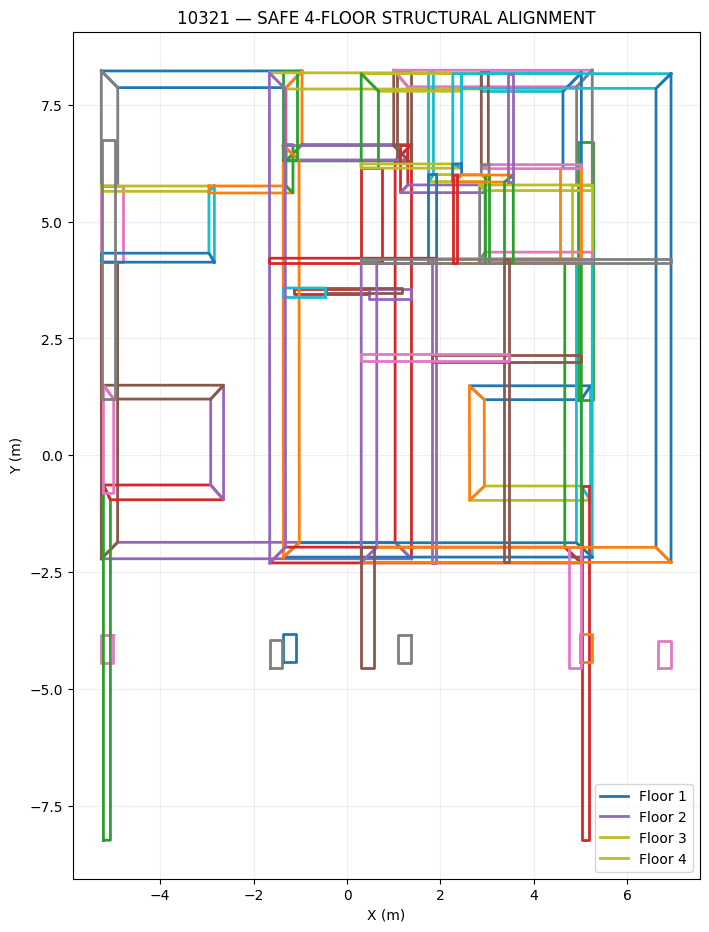


ALIGNMENT INTERPRETATION
1 → 2: REJECT | coverage improvement=-19.75 percentage points
2 → 3: ACCEPT | coverage improvement=23.77 percentage points
3 → 4: ACCEPT | coverage improvement=19.62 percentage points

Only translations that improve overlap are accepted.
Rejected translations are discarded.
No original floor geometry was changed.
No repair walls were generated.


In [97]:
# ============================================================================
# SAFE ALIGNMENT SELECTION + 4-FLOOR VISUALIZATION
# ============================================================================
#
# Uses the already-computed:
#   aligned_base
#   placed_floors
#   floor_numbers
#   alignment_df
#   overlap_df
#
# No original geometry is modified.
# No walls are generated.
#
# Rule:
#   ACCEPT an estimated translation only if it improves the structural
#   overlap compared with the centered/base position.
#
# This prevents a bad edge correspondence from making the floors worse.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.ops import unary_union
from shapely.affinity import translate


SVG_UNITS_PER_METER = 100.0


# ============================================================================
# 1. METRIC UNION HELPER
# ============================================================================

def metric_union(polygons):

    u = unary_union(
        polygons
    )

    from shapely.ops import transform

    return transform(

        lambda x, y, z=None: (
            np.asarray(x) / SVG_UNITS_PER_METER,
            np.asarray(y) / SVG_UNITS_PER_METER
        ),

        u
    )


# ============================================================================
# 2. START WITH SAFE BASE GEOMETRY
# ============================================================================
#
# Floor 1 remains fixed.
# Every other floor initially uses the centered/base geometry.
# ============================================================================

safe_floors = {
    1: [
        p for p in aligned_base[1]
    ]
}


decision_rows = []


# ============================================================================
# 3. EVALUATE EACH ADJACENT-FLOOR TRANSLATION
# ============================================================================

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_geom = metric_union(
        safe_floors[lower]
    )

    base_upper_geom = metric_union(
        aligned_base[upper]
    )

    candidate_upper_geom = metric_union(
        placed_floors[upper]
    )

    # --------------------------------------------------------
    # Base overlap
    # --------------------------------------------------------

    base_intersection = (
        lower_geom
        .intersection(
            base_upper_geom
        )
        .area
    )

    base_reference = min(
        lower_geom.area,
        base_upper_geom.area
    )

    base_coverage = (
        100.0
        * base_intersection
        / base_reference
        if base_reference > 0
        else 0.0
    )

    # --------------------------------------------------------
    # Candidate overlap
    # --------------------------------------------------------

    candidate_intersection = (
        lower_geom
        .intersection(
            candidate_upper_geom
        )
        .area
    )

    candidate_reference = min(
        lower_geom.area,
        candidate_upper_geom.area
    )

    candidate_coverage = (
        100.0
        * candidate_intersection
        / candidate_reference
        if candidate_reference > 0
        else 0.0
    )

    improvement = (
        candidate_coverage
        - base_coverage
    )

    # --------------------------------------------------------
    # Accept ONLY if improvement is positive.
    # --------------------------------------------------------

    if improvement > 0:

        safe_floors[upper] = [
            p for p in placed_floors[upper]
        ]

        decision = "ACCEPT"

    else:

        safe_floors[upper] = [
            p for p in aligned_base[upper]
        ]

        decision = "REJECT"

    # --------------------------------------------------------
    # Get estimated translation if available.
    # --------------------------------------------------------

    row = alignment_df[
        (
            alignment_df["lower"]
            == lower
        )
        &
        (
            alignment_df["upper"]
            == upper
        )
    ]

    if len(row):

        dx = float(
            row.iloc[0]["dx_m"]
        )

        dy = float(
            row.iloc[0]["dy_m"]
        )

        matches = int(
            row.iloc[0]["matches"]
        )

        inliers = int(
            row.iloc[0]["inliers"]
        )

    else:

        dx = np.nan
        dy = np.nan
        matches = 0
        inliers = 0

    decision_rows.append({

        "floors":
            f"{lower} → {upper}",

        "estimated_dx_m":
            dx,

        "estimated_dy_m":
            dy,

        "matches":
            matches,

        "inliers":
            inliers,

        "base_overlap_m2":
            round(
                base_intersection,
                3
            ),

        "base_coverage_pct":
            round(
                base_coverage,
                2
            ),

        "candidate_overlap_m2":
            round(
                candidate_intersection,
                3
            ),

        "candidate_coverage_pct":
            round(
                candidate_coverage,
                2
            ),

        "improvement_pct_points":
            round(
                improvement,
                2
            ),

        "decision":
            decision
    })


# ============================================================================
# 4. REPORT SAFE ALIGNMENT
# ============================================================================

safe_alignment_df = pd.DataFrame(
    decision_rows
)

print("=" * 100)
print("SAFE FLOOR ALIGNMENT SELECTION")
print("=" * 100)

display(
    safe_alignment_df
)


# ============================================================================
# 5. FINAL SAFE OVERLAP
# ============================================================================

print()
print("=" * 100)
print("FINAL SAFE FLOOR-TO-FLOOR OVERLAP")
print("=" * 100)

safe_overlap_rows = []

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    a = metric_union(
        safe_floors[lower]
    )

    b = metric_union(
        safe_floors[upper]
    )

    inter = (
        a.intersection(b)
    )

    coverage = (
        100.0
        * inter.area
        / min(
            a.area,
            b.area
        )
        if min(
            a.area,
            b.area
        ) > 0
        else 0.0
    )

    safe_overlap_rows.append({

        "floors":
            f"{lower} → {upper}",

        "intersection_m2":
            round(
                inter.area,
                3
            ),

        "min_floor_coverage_pct":
            round(
                coverage,
                2
            )
    })


safe_overlap_df = pd.DataFrame(
    safe_overlap_rows
)

display(
    safe_overlap_df
)


# ============================================================================
# 6. REMAINING FOOTPRINT DIFFERENCES
# ============================================================================

print()
print("=" * 100)
print("REMAINING REAL FOOTPRINT DIFFERENCES")
print("=" * 100)

difference_rows = []

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    a = metric_union(
        safe_floors[lower]
    )

    b = metric_union(
        safe_floors[upper]
    )

    common = a.intersection(
        b
    )

    lower_only = a.difference(
        b
    )

    upper_only = b.difference(
        a
    )

    difference_rows.append({

        "floors":
            f"{lower} → {upper}",

        "lower_only_m2":
            round(
                lower_only.area,
                3
            ),

        "upper_only_m2":
            round(
                upper_only.area,
                3
            ),

        "common_m2":
            round(
                common.area,
                3
            )
    })


safe_difference_df = pd.DataFrame(
    difference_rows
)

display(
    safe_difference_df
)


# ============================================================================
# 7. FIXED VISUALIZATION
# ============================================================================
#
# np.asarray() fixes the previous array.array TypeError.
# ============================================================================

fig, ax = plt.subplots(
    figsize=(15, 11)
)

for floor_number in [
    1, 2, 3, 4
]:

    for poly in safe_floors[
        floor_number
    ]:

        x, y = poly.exterior.xy

        x = np.asarray(
            x,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )

        ax.plot(

            x / SVG_UNITS_PER_METER,

            y / SVG_UNITS_PER_METER,

            linewidth=2,

            label=(
                f"Floor {floor_number}"
            )
        )


# Remove duplicate legend entries.
handles, labels = (
    ax.get_legend_handles_labels()
)

unique = {}

for h, label in zip(
    handles,
    labels
):

    if label not in unique:
        unique[label] = h

ax.legend(
    unique.values(),
    unique.keys()
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(
    "X (m)"
)

ax.set_ylabel(
    "Y (m)"
)

ax.set_title(
    "10321 — SAFE 4-FLOOR STRUCTURAL ALIGNMENT"
)

ax.grid(
    True,
    alpha=0.2
)

plt.show()


# ============================================================================
# 8. INTERPRETATION
# ============================================================================

print()
print("=" * 100)
print("ALIGNMENT INTERPRETATION")
print("=" * 100)

for _, row in safe_alignment_df.iterrows():

    print(
        f"{row['floors']}: "
        f"{row['decision']} | "
        f"coverage improvement="
        f"{row['improvement_pct_points']:.2f} "
        f"percentage points"
    )

print()
print(
    "Only translations that improve overlap are accepted."
)

print(
    "Rejected translations are discarded."
)

print(
    "No original floor geometry was changed."
)

print(
    "No repair walls were generated."
)

COARSE-TO-FINE STRUCTURAL ALIGNMENT


,floors,base_overlap_pct,optimized_overlap_pct,improvement_points,dx_m,dy_m,evaluations,decision
0,1 → 2,46.34,52.43,6.09,-3.896,-0.009,522,ACCEPT
1,2 → 3,12.34,65.45,53.11,-1.924,1.916,522,ACCEPT
2,3 → 4,13.76,45.93,32.17,1.318,1.908,522,ACCEPT



FINAL OPTIMIZED OVERLAP


,floors,intersection_m2,coverage_pct
0,1 → 2,16.582,52.43
1,2 → 3,17.670,65.45
2,3 → 4,12.113,45.93



OPTIMIZED 4-FLOOR STRUCTURAL MAP


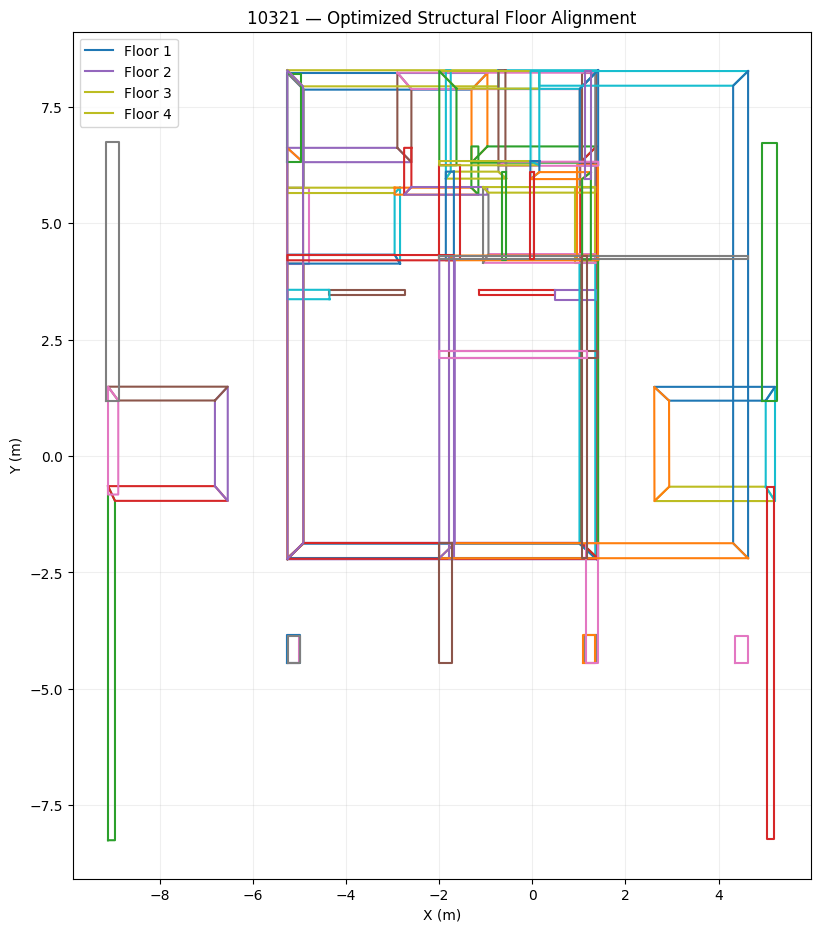


OPTIMIZED 4-FLOOR PREVIEW MODEL
Vertices: 2622
Faces: 5148
Watertight: True
Valid volume: True
Volume: 916.995 m³
X: -9.147 → 5.261 m
Y: -8.250 → 8.285 m
Z: -0.150 → 12.000 m

✅ Saved: cubicasa_10321_optimized_alignment_preview.glb



INTERPRETATION
This experiment changes ONLY the XY placement of copied floor geometry.
It does NOT generate new walls.
It does NOT delete any walls.
It does NOT overwrite the validated 4-floor model.

If the optimized overlaps are still modest, the remaining differences are probably real floor-plan changes rather than a simple translation problem.

Only after that should we generate candidate vertical/setback walls, and those will be created as a separate preview.


In [98]:
# ============================================================================
# 10321 — COARSE-TO-FINE STRUCTURAL FLOOR ALIGNMENT
# ============================================================================
#
# SAFETY:
#   - Original floor_walls unchanged
#   - aligned_base unchanged
#   - placed_floors unchanged
#   - No walls deleted
#   - No walls generated
#   - No existing GLB overwritten
#
# METHOD:
#   1. Treat each floor's structural wall union as a shape.
#   2. Buffer the wall union slightly to make overlap more stable.
#   3. Search translations directly for maximum overlap.
#   4. Coarse search, then fine search.
#   5. Accept only if overlap improves.
#   6. Build a NEW 4-floor preview using the optimized positions.
# ============================================================================

import numpy as np
import pandas as pd
import trimesh
import plotly.graph_objects as go

from shapely.ops import unary_union
from shapely.affinity import translate


# ============================================================================
# SETTINGS
# ============================================================================

SVG_PER_M = 100.0

# Structural wall-band thickness used only for alignment.
# This is NOT changing the original walls.
ALIGN_BUFFER_M = 0.10
ALIGN_BUFFER_SVG = (
    ALIGN_BUFFER_M * SVG_PER_M
)

# Coarse search.
COARSE_RADIUS_M = 4.0
COARSE_STEP_M = 0.40

# Fine refinement around best coarse result.
FINE_RADIUS_M = 0.40
FINE_STEP_M = 0.10

FLOOR_HEIGHT_M = 3.0
SLAB_THICKNESS_M = 0.15


# ============================================================================
# 1. SAFE COPIES
# ============================================================================

safe_alignment_source = {
    n: [
        p
        for p in aligned_base[n]
    ]
    for n in [1, 2, 3, 4]
}


# ============================================================================
# 2. BUILD BUFFERED STRUCTURAL SHAPE
# ============================================================================

def structural_shape(
    polygons
):

    wall_union = unary_union(
        polygons
    )

    return wall_union.buffer(
        ALIGN_BUFFER_SVG,
        join_style=2
    )


# ============================================================================
# 3. METRIC TRANSLATION HELPER
# ============================================================================

def shift_svg(
    polygons,
    dx_m,
    dy_m
):

    return [

        translate(
            p,
            xoff=dx_m * SVG_PER_M,
            yoff=dy_m * SVG_PER_M
        )

        for p in polygons
    ]


# ============================================================================
# 4. OVERLAP SCORE
# ============================================================================

def overlap_score(
    lower_shape,
    upper_shape
):

    intersection = (
        lower_shape
        .intersection(
            upper_shape
        )
        .area
    )

    min_area = min(
        lower_shape.area,
        upper_shape.area
    )

    if min_area <= 0:
        return 0.0

    return (
        intersection
        / min_area
    )


# ============================================================================
# 5. GRID SEARCH
# ============================================================================

def optimize_translation(
    lower_polygons,
    upper_polygons,
    search_center=(0.0, 0.0),
):

    lower_shape = structural_shape(
        lower_polygons
    )

    cx, cy = search_center

    # --------------------------------------------------------
    # COARSE SEARCH
    # --------------------------------------------------------

    coarse_values = np.arange(
        -COARSE_RADIUS_M,
        COARSE_RADIUS_M
        + COARSE_STEP_M / 2,
        COARSE_STEP_M
    )

    best = {
        "score": -1,
        "dx": 0.0,
        "dy": 0.0
    }

    evaluations = 0

    for dx_offset in coarse_values:

        for dy_offset in coarse_values:

            dx = cx + dx_offset
            dy = cy + dy_offset

            shifted = shift_svg(
                upper_polygons,
                dx,
                dy
            )

            upper_shape = structural_shape(
                shifted
            )

            score = overlap_score(
                lower_shape,
                upper_shape
            )

            evaluations += 1

            if score > best["score"]:

                best = {
                    "score": score,
                    "dx": dx,
                    "dy": dy
                }

    # --------------------------------------------------------
    # FINE SEARCH
    # --------------------------------------------------------

    fine_values = np.arange(
        -FINE_RADIUS_M,
        FINE_RADIUS_M
        + FINE_STEP_M / 2,
        FINE_STEP_M
    )

    coarse_dx = best["dx"]
    coarse_dy = best["dy"]

    fine_best = best.copy()

    for dx_offset in fine_values:

        for dy_offset in fine_values:

            dx = (
                coarse_dx
                + dx_offset
            )

            dy = (
                coarse_dy
                + dy_offset
            )

            shifted = shift_svg(
                upper_polygons,
                dx,
                dy
            )

            upper_shape = structural_shape(
                shifted
            )

            score = overlap_score(
                lower_shape,
                upper_shape
            )

            evaluations += 1

            if score > fine_best["score"]:

                fine_best = {
                    "score": score,
                    "dx": dx,
                    "dy": dy
                }

    return fine_best, evaluations


# ============================================================================
# 6. SUCCESSIVE FLOOR ALIGNMENT
# ============================================================================
#
# Floor 1 stays fixed.
# Floor 2 is optimized against Floor 1.
# Floor 3 is optimized against optimized Floor 2.
# Floor 4 is optimized against optimized Floor 3.
# ============================================================================

optimized_floors = {
    1: [
        p
        for p in safe_alignment_source[1]
    ]
}

alignment_rows = []


for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_polygons = optimized_floors[
        lower
    ]

    upper_polygons = safe_alignment_source[
        upper
    ]

    # --------------------------------------------------------
    # Center search around previously estimated edge translation
    # if available.
    # --------------------------------------------------------

    center_dx = 0.0
    center_dy = 0.0

    if (
        "alignment_df" in globals()
    ):

        row = alignment_df[
            (
                alignment_df["lower"]
                == lower
            )
            &
            (
                alignment_df["upper"]
                == upper
            )
        ]

        if len(row):

            center_dx = float(
                row.iloc[0]["dx_m"]
            )

            center_dy = float(
                row.iloc[0]["dy_m"]
            )

    # --------------------------------------------------------
    # Base score with NO translation.
    # --------------------------------------------------------

    lower_shape = structural_shape(
        lower_polygons
    )

    base_shape = structural_shape(
        upper_polygons
    )

    base_score = overlap_score(
        lower_shape,
        base_shape
    )

    # --------------------------------------------------------
    # Optimize.
    # --------------------------------------------------------

    best, evaluations = (
        optimize_translation(
            lower_polygons,
            upper_polygons,
            search_center=(
                center_dx,
                center_dy
            )
        )
    )

    improvement = (
        best["score"]
        - base_score
    )

    # --------------------------------------------------------
    # Accept only genuine improvement.
    # --------------------------------------------------------

    if improvement > 0:

        final_dx = best["dx"]
        final_dy = best["dy"]

        optimized = shift_svg(
            upper_polygons,
            final_dx,
            final_dy
        )

        decision = "ACCEPT"

    else:

        final_dx = 0.0
        final_dy = 0.0

        optimized = [
            p
            for p in upper_polygons
        ]

        decision = "KEEP BASE"


    optimized_floors[
        upper
    ] = optimized

    alignment_rows.append({

        "floors":
            f"{lower} → {upper}",

        "base_overlap_pct":
            round(
                base_score * 100,
                2
            ),

        "optimized_overlap_pct":
            round(
                best["score"] * 100,
                2
            ),

        "improvement_points":
            round(
                improvement * 100,
                2
            ),

        "dx_m":
            round(
                final_dx,
                3
            ),

        "dy_m":
            round(
                final_dy,
                3
            ),

        "evaluations":
            evaluations,

        "decision":
            decision
    })


alignment_result_df = pd.DataFrame(
    alignment_rows
)


# ============================================================================
# 7. PRINT RESULTS
# ============================================================================

print("=" * 100)
print("COARSE-TO-FINE STRUCTURAL ALIGNMENT")
print("=" * 100)

display(
    alignment_result_df
)


# ============================================================================
# 8. FINAL PAIRWISE OVERLAP
# ============================================================================

final_overlap_rows = []

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_shape = structural_shape(
        optimized_floors[lower]
    )

    upper_shape = structural_shape(
        optimized_floors[upper]
    )

    intersection = (
        lower_shape
        .intersection(
            upper_shape
        )
        .area
    )

    min_area = min(
        lower_shape.area,
        upper_shape.area
    )

    coverage = (
        100
        * intersection
        / min_area
        if min_area > 0
        else 0
    )

    final_overlap_rows.append({

        "floors":
            f"{lower} → {upper}",

        "intersection_m2":
            round(
                intersection
                / SVG_PER_METER_SQ
                if "SVG_PER_METER_SQ" in globals()
                else intersection
                / (SVG_PER_M ** 2),
                3
            ),

        "coverage_pct":
            round(
                coverage,
                2
            )
    })


final_overlap_df = pd.DataFrame(
    final_overlap_rows
)

print()
print("=" * 100)
print("FINAL OPTIMIZED OVERLAP")
print("=" * 100)

display(
    final_overlap_df
)


# ============================================================================
# 9. VISUALIZE ALIGNED FOUR FLOORS IN 2D
# ============================================================================

print()
print("=" * 100)
print("OPTIMIZED 4-FLOOR STRUCTURAL MAP")
print("=" * 100)

fig, ax = plt.subplots(
    figsize=(15, 11)
)

for floor_number in [
    1, 2, 3, 4
]:

    for poly in optimized_floors[
        floor_number
    ]:

        x, y = poly.exterior.xy

        x = np.asarray(
            x,
            dtype=float
        )

        y = np.asarray(
            y,
            dtype=float
        )

        ax.plot(
            x / SVG_PER_M,
            y / SVG_PER_M,
            linewidth=1.5,
            label=f"Floor {floor_number}"
        )


handles, labels = (
    ax.get_legend_handles_labels()
)

unique = {}

for h, label in zip(
    handles,
    labels
):

    if label not in unique:
        unique[label] = h

ax.legend(
    unique.values(),
    unique.keys()
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(
    "X (m)"
)

ax.set_ylabel(
    "Y (m)"
)

ax.set_title(
    "10321 — Optimized Structural Floor Alignment"
)

ax.grid(
    True,
    alpha=0.2
)

plt.show()


# ============================================================================
# 10. BUILD A NEW 4-FLOOR PREVIEW
# ============================================================================
#
# This is ONLY a preview.
# No original model is touched.
# ============================================================================

preview_components = []

for floor_number in [
    1, 2, 3, 4
]:

    z0 = (
        floor_number - 1
    ) * FLOOR_HEIGHT_M

    walls = optimized_floors[
        floor_number
    ]

    # --------------------------------------------------------
    # Walls
    # --------------------------------------------------------

    wall_union = unary_union(
        walls
    )

    parts = (

        list(wall_union.geoms)
        if isinstance(
            wall_union,
            MultiPolygon
        )
        else [wall_union]
    )

    for part in parts:

        coords = np.asarray(
            list(
                part.exterior.coords
            ),
            dtype=float
        )

        coords_m = (
            coords
            / SVG_PER_M
        )

        poly_m = Polygon(
            coords_m
        )

        if not poly_m.is_valid:
            poly_m = poly_m.buffer(0)

        if poly_m.is_empty:
            continue

        try:

            wall_mesh = (
                trimesh.creation
                .extrude_polygon(
                    poly_m,
                    height=
                    FLOOR_HEIGHT_M
                )
            )

            wall_mesh.apply_translation(
                [0, 0, z0]
            )

            preview_components.append(
                wall_mesh
            )

        except Exception:
            pass

    # --------------------------------------------------------
    # Thin deck
    # --------------------------------------------------------

    footprint = (
        wall_union
        .buffer(
            HALF_WALL_THICKNESS_M
        )
    )

    slab_parts = (

        list(
            footprint.geoms
        )

        if isinstance(
            footprint,
            MultiPolygon
        )

        else [footprint]
    )

    for part in slab_parts:

        coords = np.asarray(
            list(
                part.exterior.coords
            ),
            dtype=float
        )

        coords_m = (
            coords
            / SVG_PER_M
        )

        slab_poly = Polygon(
            coords_m
        )

        if not slab_poly.is_valid:
            slab_poly = slab_poly.buffer(0)

        try:

            slab = (
                trimesh.creation
                .extrude_polygon(
                    slab_poly,
                    height=
                    SLAB_THICKNESS_M
                )
            )

            slab.apply_translation(
                [
                    0,
                    0,
                    z0
                    - SLAB_THICKNESS_M
                ]
            )

            preview_components.append(
                slab
            )

        except Exception:
            pass


preview_model = (
    trimesh.util.concatenate(
        preview_components
    )
)


# ============================================================================
# 11. ORIENTATION
# ============================================================================

if (
    preview_model.is_watertight
    and preview_model.volume < 0
):

    preview_model.faces = (
        preview_model.faces[:, ::-1]
    )


# ============================================================================
# 12. PREVIEW VALIDATION
# ============================================================================

print()
print("=" * 100)
print("OPTIMIZED 4-FLOOR PREVIEW MODEL")
print("=" * 100)

print(
    "Vertices:",
    len(
        preview_model.vertices
    )
)

print(
    "Faces:",
    len(
        preview_model.faces
    )
)

print(
    "Watertight:",
    preview_model.is_watertight
)

print(
    "Valid volume:",
    preview_model.is_volume
)

print(
    "Volume:",
    round(
        preview_model.volume,
        3
    ),
    "m³"
)

bounds = preview_model.bounds

print(
    f"X: {bounds[0,0]:.3f} → "
    f"{bounds[1,0]:.3f} m"
)

print(
    f"Y: {bounds[0,1]:.3f} → "
    f"{bounds[1,1]:.3f} m"
)

print(
    f"Z: {bounds[0,2]:.3f} → "
    f"{bounds[1,2]:.3f} m"
)


# ============================================================================
# 13. SAVE PREVIEW SEPARATELY
# ============================================================================

PREVIEW_FILE = (
    "cubicasa_10321_optimized_alignment_preview.glb"
)

preview_model.export(
    PREVIEW_FILE
)

print()
print(
    "✅ Saved:",
    PREVIEW_FILE
)


# ============================================================================
# 14. 3D VISUALIZATION
# ============================================================================

fig3d = go.Figure()

vertices = preview_model.vertices
faces = preview_model.faces

fig3d.add_trace(
    go.Mesh3d(

        x=vertices[:,0],
        y=vertices[:,1],
        z=vertices[:,2],

        i=faces[:,0],
        j=faces[:,1],
        k=faces[:,2],

        opacity=0.52,

        name="Optimized structural shell",

        hovertemplate=(
            "X: %{x:.2f} m<br>"
            "Y: %{y:.2f} m<br>"
            "Z: %{z:.2f} m"
            "<extra></extra>"
        )
    )
)

fig3d.update_layout(

    title=(
        "10321 — Optimized 4-Floor "
        "Structural Preview"
    ),

    scene=dict(

        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.7,
                y=1.7,
                z=1.3
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=50,
        b=0
    )
)

fig3d.show()


# ============================================================================
# 15. FINAL INTERPRETATION
# ============================================================================

print()
print("=" * 100)
print("INTERPRETATION")
print("=" * 100)

print(
    "This experiment changes ONLY the XY placement of copied floor geometry."
)

print(
    "It does NOT generate new walls."
)

print(
    "It does NOT delete any walls."
)

print(
    "It does NOT overwrite the validated 4-floor model."
)

print()
print(
    "If the optimized overlaps are still modest, "
    "the remaining differences are probably real floor-plan changes "
    "rather than a simple translation problem."
)

print()
print(
    "Only after that should we generate candidate vertical/setback "
    "walls, and those will be created as a separate preview."
)

In [99]:
# ============================================================================
# 10321 — CANDIDATE VERTICAL TRANSITION WALLS
# ============================================================================
#
# PURPOSE:
#   Work around REAL floor-to-floor footprint differences.
#
# We ONLY create candidate walls where the UPPER floor extends outside
# the LOWER floor structural envelope.
#
# We DO NOT:
#   - change original floor geometry
#   - fill lower-floor setbacks automatically
#   - add doors/windows
#   - add furniture
#   - modify the validated 4-floor GLB
#
# Output is a NEW preview GLB.
# ============================================================================

import numpy as np
import trimesh
import pandas as pd
import plotly.graph_objects as go

from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union


# ============================================================================
# SETTINGS
# ============================================================================

SVG_PER_M = 100.0

FLOOR_HEIGHT = 3.0
WALL_THICKNESS = 0.20

# Small tolerance to avoid generating walls from tiny numerical differences.
EXPOSURE_TOLERANCE = 0.15

OUTPUT_FILE = (
    "cubicasa_10321_transition_wall_preview.glb"
)


# ============================================================================
# 1. REQUIRE OPTIMIZED FLOOR GEOMETRY
# ============================================================================

if "optimized_floors" not in globals():

    raise RuntimeError(
        "optimized_floors is missing. "
        "Run the coarse-to-fine alignment cell first."
    )


# ============================================================================
# 2. CREATE OUTER STRUCTURAL ENVELOPES
# ============================================================================
#
# We use a small buffer around the wall union.
# This is ONLY for deciding where the structural perimeter lies.
# Original walls are untouched.
# ============================================================================

def structural_envelope(
    polygons
):

    union = unary_union(
        polygons
    )

    return union.buffer(
        0.10 * SVG_PER_M,
        join_style=2
    )


envelopes = {

    floor:
        structural_envelope(
            optimized_floors[floor]
        )

    for floor in [1, 2, 3, 4]
}


# ============================================================================
# 3. CONVERT SVG GEOMETRY TO METRIC
# ============================================================================

def svg_to_metric_geom(
    geom
):

    from shapely.ops import transform

    return transform(

        lambda x, y, z=None: (

            np.asarray(x)
            / SVG_PER_M,

            np.asarray(y)
            / SVG_PER_M
        ),

        geom
    )


metric_envelopes = {

    floor:
        svg_to_metric_geom(
            envelopes[floor]
        )

    for floor in [1, 2, 3, 4]
}


# ============================================================================
# 4. FIND UPPER-ONLY REGIONS
# ============================================================================

print("=" * 100)
print("FLOOR-TO-FLOOR TRANSITION ANALYSIS")
print("=" * 100)

transition_rows = []

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_env = (
        metric_envelopes[lower]
    )

    upper_env = (
        metric_envelopes[upper]
    )

    # Region where upper structural envelope exists but
    # lower structural envelope does not.
    upper_only = (
        upper_env
        .difference(
            lower_env.buffer(
                EXPOSURE_TOLERANCE
            )
        )
    )

    lower_only = (
        lower_env
        .difference(
            upper_env.buffer(
                EXPOSURE_TOLERANCE
            )
        )
    )

    transition_rows.append({

        "floors":
            f"{lower} → {upper}",

        "upper_outside_lower_m2":
            round(
                upper_only.area,
                3
            ),

        "lower_outside_upper_m2":
            round(
                lower_only.area,
                3
            )
    })


transition_df = pd.DataFrame(
    transition_rows
)

display(
    transition_df
)


# ============================================================================
# 5. EXTRACT OUTER BOUNDARY SEGMENTS
# ============================================================================
#
# Candidate walls are generated ONLY along the boundary of the upper-only
# structural region.
# ============================================================================

def polygon_parts(
    geom
):

    if geom.is_empty:
        return []

    if isinstance(
        geom,
        Polygon
    ):

        return [
            geom
        ]

    if isinstance(
        geom,
        MultiPolygon
    ):

        return list(
            geom.geoms
        )

    return [
        g
        for g in getattr(
            geom,
            "geoms",
            []
        )
        if isinstance(
            g,
            Polygon
        )
    ]


# ============================================================================
# 6. BUILD CANDIDATE VERTICAL WALLS
# ============================================================================

candidate_wall_meshes = []

candidate_records = []

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_env = (
        metric_envelopes[lower]
    )

    upper_env = (
        metric_envelopes[upper]
    )

    upper_only = (
        upper_env
        .difference(
            lower_env.buffer(
                EXPOSURE_TOLERANCE
            )
        )
    )

    parts = polygon_parts(
        upper_only
    )

    for part_index, part in enumerate(
        parts,
        start=1
    ):

        if part.area <= 0:
            continue

        coords = np.asarray(
            list(
                part.exterior.coords
            ),
            dtype=float
        )

        if len(coords) < 3:
            continue

        # --------------------------------------------------------
        # Each outer boundary segment can become a vertical
        # transition wall.
        # --------------------------------------------------------

        for edge_index in range(
            len(coords) - 1
        ):

            p1 = coords[
                edge_index
            ]

            p2 = coords[
                edge_index + 1
            ]

            length = np.linalg.norm(
                p2 - p1
            )

            # Ignore tiny numerical fragments.
            if length < 0.30:
                continue

            # Unit tangent.
            tangent = (
                p2 - p1
            ) / length

            # Perpendicular normal.
            normal = np.array([
                -tangent[1],
                tangent[0]
            ])

            # Midpoint.
            midpoint = (
                p1 + p2
            ) / 2

            # Wall footprint corners.
            half_t = (
                WALL_THICKNESS
                / 2
            )

            a = (
                p1
                + normal * half_t
            )

            b = (
                p2
                + normal * half_t
            )

            c = (
                p2
                - normal * half_t
            )

            d = (
                p1
                - normal * half_t
            )

            wall_footprint = Polygon([
                tuple(a),
                tuple(b),
                tuple(c),
                tuple(d)
            ])

            if (
                wall_footprint.is_empty
                or wall_footprint.area <= 0
            ):
                continue

            # ----------------------------------------------------
            # Vertical gap from lower-floor top to upper-floor
            # bottom.
            #
            # Lower floor occupies:
            #     lower-1 → lower
            #
            # Upper floor begins:
            #     upper-1 → upper
            #
            # Therefore the transition interval is:
            #     Z = lower * 3 → upper-1 * 3
            # ----------------------------------------------------

            z0 = (
                lower
                * FLOOR_HEIGHT
            )

            z1 = (
                (upper - 1)
                * FLOOR_HEIGHT
            )

            if z1 <= z0:
                continue

            try:

                transition_wall = (
                    trimesh.creation
                    .extrude_polygon(
                        wall_footprint,
                        height=
                        z1 - z0
                    )
                )

                transition_wall.apply_translation(
                    [
                        0,
                        0,
                        z0
                    ]
                )

                candidate_wall_meshes.append(
                    transition_wall
                )

                candidate_records.append({

                    "floors":
                        f"{lower} → {upper}",

                    "part":
                        part_index,

                    "edge":
                        edge_index,

                    "length_m":
                        round(
                            length,
                            3
                        ),

                    "z0":
                        z0,

                    "z1":
                        z1,

                    "mid_x":
                        round(
                            midpoint[0],
                            3
                        ),

                    "mid_y":
                        round(
                            midpoint[1],
                            3
                        )
                })

            except Exception:
                pass


# ============================================================================
# 7. REPORT CANDIDATES
# ============================================================================

print()
print("=" * 100)
print("CANDIDATE TRANSITION WALLS")
print("=" * 100)

candidate_df = pd.DataFrame(
    candidate_records
)

print(
    "Candidate wall segments:",
    len(candidate_df)
)

if len(candidate_df):

    display(
        candidate_df
    )

else:

    print(
        "No candidate transition walls were generated."
    )


# ============================================================================
# 8. COMBINE WITH OPTIMIZED STRUCTURAL MODEL
# ============================================================================
#
# Reuse preview_model if available.
# Otherwise rebuild the optimized wall/deck shell.
# ============================================================================

if (
    "preview_model" in globals()
    and preview_model is not None
):

    base_model = (
        preview_model.copy()
    )

else:

    raise RuntimeError(
        "preview_model is missing. "
        "Run the optimized alignment cell first."
    )


if candidate_wall_meshes:

    transition_combined = (
        trimesh.util.concatenate(
            candidate_wall_meshes
        )
    )

    transition_preview = (
        trimesh.util.concatenate(
            [
                base_model,
                transition_combined
            ]
        )
    )

else:

    transition_preview = (
        base_model.copy()
    )


# ============================================================================
# 9. ORIENTATION
# ============================================================================

if (
    transition_preview.is_watertight
    and transition_preview.volume < 0
):

    transition_preview.faces = (
        transition_preview.faces[
            :,
            ::-1
        ]
    )


# ============================================================================
# 10. VALIDATE
# ============================================================================

print()
print("=" * 100)
print("TRANSITION-WALL PREVIEW MODEL")
print("=" * 100)

print(
    "Vertices:",
    len(
        transition_preview.vertices
    )
)

print(
    "Faces:",
    len(
        transition_preview.faces
    )
)

print(
    "Watertight:",
    transition_preview.is_watertight
)

print(
    "Valid volume:",
    transition_preview.is_volume
)

print(
    "Volume:",
    round(
        transition_preview.volume,
        3
    ),
    "m³"
)

b = (
    transition_preview.bounds
)

print(
    f"X: {b[0,0]:.3f} → "
    f"{b[1,0]:.3f} m"
)

print(
    f"Y: {b[0,1]:.3f} → "
    f"{b[1,1]:.3f} m"
)

print(
    f"Z: {b[0,2]:.3f} → "
    f"{b[1,2]:.3f} m"
)


# ============================================================================
# 11. EXPORT SEPARATE PREVIEW
# ============================================================================

transition_preview.export(
    OUTPUT_FILE
)

print()
print(
    "✅ Saved:",
    OUTPUT_FILE
)


# ============================================================================
# 12. 3D VISUALIZATION
# ============================================================================

fig = go.Figure()

# Base shell
v = base_model.vertices
f = base_model.faces

fig.add_trace(
    go.Mesh3d(

        x=v[:,0],
        y=v[:,1],
        z=v[:,2],

        i=f[:,0],
        j=f[:,1],
        k=f[:,2],

        opacity=0.38,

        name="Optimized 4-floor shell"
    )
)


# Candidate transition walls
for i, wall in enumerate(
    candidate_wall_meshes
):

    v = wall.vertices
    f = wall.faces

    fig.add_trace(
        go.Mesh3d(

            x=v[:,0],
            y=v[:,1],
            z=v[:,2],

            i=f[:,0],
            j=f[:,1],
            k=f[:,2],

            opacity=0.75,

            name=f"Transition wall {i+1}"
        )
    )


fig.update_layout(

    title=(
        "10321 — Structural Shell "
        "+ Candidate Transition Walls"
    ),

    scene=dict(

        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.7,
                y=1.7,
                z=1.4
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=50,
        b=0
    )
)

fig.show()


# ============================================================================
# 13. FINAL INTERPRETATION
# ============================================================================

print()
print("=" * 100)
print("INTERPRETATION")
print("=" * 100)

print("""
These are CANDIDATE transition walls only.

They represent upper-floor structural perimeter regions that extend
outside the lower-floor structural envelope.

We have NOT assumed that every lower-only region needs a wall.
A lower-floor-only region may simply represent a setback, terrace,
roof area, or architectural change.

The candidate model is therefore a design/geometry experiment,
not a claim about the original construction.
""")

print()
print(
    "Original optimized model: UNCHANGED"
)

print(
    "Original 4-floor GLB: UNCHANGED"
)

print(
    "Candidate transition walls:",
    len(candidate_wall_meshes)
)

FLOOR-TO-FLOOR TRANSITION ANALYSIS


,floors,upper_outside_lower_m2,lower_outside_upper_m2
0,1 → 2,14.089,14.445
1,2 → 3,7.025,12.676
2,3 → 4,11.597,12.142



CANDIDATE TRANSITION WALLS
Candidate wall segments: 0
No candidate transition walls were generated.

TRANSITION-WALL PREVIEW MODEL
Vertices: 2622
Faces: 5148
Watertight: True
Valid volume: True
Volume: 916.995 m³
X: -9.147 → 5.261 m
Y: -8.250 → 8.285 m
Z: -0.150 → 12.000 m

✅ Saved: cubicasa_10321_transition_wall_preview.glb



INTERPRETATION

These are CANDIDATE transition walls only.

They represent upper-floor structural perimeter regions that extend
outside the lower-floor structural envelope.

We have NOT assumed that every lower-only region needs a wall.
A lower-floor-only region may simply represent a setback, terrace,
roof area, or architectural change.

The candidate model is therefore a design/geometry experiment,
not a claim about the original construction.


Original optimized model: UNCHANGED
Original 4-floor GLB: UNCHANGED
Candidate transition walls: 0


In [100]:
# ============================================================================
# CORRECTED UPPER-OVERHANG / SUPPORT-WALL PREVIEW
# ============================================================================
#
# FIXES THE PREVIOUS BUG:
#   Adjacent floors now get support-wall Z ranges:
#
#       Floor 1 -> Floor 2 : Z 0 -> 3 m
#       Floor 2 -> Floor 3 : Z 3 -> 6 m
#       Floor 3 -> Floor 4 : Z 6 -> 9 m
#
# The previous version accidentally used:
#       lower*3 -> (upper-1)*3
# which gives zero height for adjacent floors.
#
# SAFETY:
#   - original floor geometry unchanged
#   - optimized_floors unchanged
#   - preview_model unchanged
#   - no doors/windows/furniture
#   - no automatic gap filling
#   - output is a NEW preview GLB
# ============================================================================

import numpy as np
import pandas as pd
import trimesh
import plotly.graph_objects as go

from shapely.geometry import (
    Polygon,
    MultiPolygon,
    LineString
)

from shapely.ops import (
    unary_union
)


# ============================================================================
# PARAMETERS
# ============================================================================

SVG_PER_M = 100.0

FLOOR_HEIGHT = 3.0

SUPPORT_WALL_THICKNESS = 0.20

BOUNDARY_TOLERANCE = 0.05

MIN_SUPPORT_LENGTH = 0.30

OUTPUT_FILE = (
    "cubicasa_10321_support_wall_preview.glb"
)


# ============================================================================
# 1. REQUIRE OPTIMIZED FLOOR GEOMETRY
# ============================================================================

if "optimized_floors" not in globals():

    raise RuntimeError(
        "optimized_floors is missing. "
        "Run the coarse-to-fine alignment cell first."
    )

if "preview_model" not in globals():

    raise RuntimeError(
        "preview_model is missing. "
        "Run the coarse-to-fine alignment cell first."
    )


# ============================================================================
# 2. CONVERT SVG FLOOR GEOMETRY TO METRES
# ============================================================================

def svg_to_metric(
    geom
):

    from shapely.ops import transform

    return transform(

        lambda x, y, z=None: (

            np.asarray(x, dtype=float)
            / SVG_PER_M,

            np.asarray(y, dtype=float)
            / SVG_PER_M
        ),

        geom
    )


def metric_floor_union(
    polygons
):

    svg_union = unary_union(
        polygons
    )

    return svg_to_metric(
        svg_union
    )


floor_metric = {

    floor:
        metric_floor_union(
            optimized_floors[floor]
        )

    for floor in [1, 2, 3, 4]
}


# ============================================================================
# 3. BUILD STRUCTURAL ENVELOPES
# ============================================================================
#
# Small buffer is ONLY used to identify the approximate structural footprint.
# It does not alter the original wall geometry.
# ============================================================================

ENVELOPE_BUFFER = 0.10

envelopes = {

    floor:
        floor_metric[floor].buffer(
            ENVELOPE_BUFFER,
            join_style=2
        )

    for floor in [1, 2, 3, 4]
}


# ============================================================================
# 4. GET POLYGON PARTS
# ============================================================================

def polygon_parts(
    geom
):

    if geom.is_empty:
        return []

    if isinstance(
        geom,
        Polygon
    ):

        return [
            geom
        ]

    if isinstance(
        geom,
        MultiPolygon
    ):

        return list(
            geom.geoms
        )

    return [
        g
        for g in getattr(
            geom,
            "geoms",
            []
        )
        if isinstance(
            g,
            Polygon
        )
    ]


# ============================================================================
# 5. FIND TRUE UPPER-OUTSIDE BOUNDARY SEGMENTS
# ============================================================================
#
# We look ONLY at the UPPER floor's exterior boundary.
#
# A boundary segment becomes a candidate when its midpoint is outside the
# lower floor envelope.
#
# This avoids accidentally creating walls along the internal boundary
# between the upper-only region and the lower-supported region.
# ============================================================================

def upper_overhang_segments(
    lower_env,
    upper_env
):

    records = []

    for part_index, upper_part in enumerate(
        polygon_parts(
            upper_env
        ),
        start=1
    ):

        coords = np.asarray(
            list(
                upper_part.exterior.coords
            ),
            dtype=float
        )

        for edge_index in range(
            len(coords) - 1
        ):

            p1 = coords[
                edge_index
            ]

            p2 = coords[
                edge_index + 1
            ]

            segment = LineString([
                tuple(p1),
                tuple(p2)
            ])

            length = segment.length

            if length < MIN_SUPPORT_LENGTH:
                continue

            midpoint = segment.interpolate(
                0.5,
                normalized=True
            )

            # ------------------------------------------------------------
            # Key test:
            # segment midpoint must be outside lower structural envelope.
            # ------------------------------------------------------------

            distance_to_lower = (
                midpoint.distance(
                    lower_env
                )
            )

            if distance_to_lower <= BOUNDARY_TOLERANCE:
                continue

            records.append({

                "part":
                    part_index,

                "edge":
                    edge_index,

                "p1":
                    tuple(p1),

                "p2":
                    tuple(p2),

                "length_m":
                    length,

                "midpoint_x":
                    midpoint.x,

                "midpoint_y":
                    midpoint.y,

                "distance_to_lower_m":
                    distance_to_lower
            })

    return records


# ============================================================================
# 6. FIND CANDIDATES FOR EACH TRANSITION
# ============================================================================

all_candidate_records = []
support_wall_meshes = []

print("=" * 100)
print("UPPER-FLOOR OVERHANG ANALYSIS")
print("=" * 100)

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_env = envelopes[
        lower
    ]

    upper_env = envelopes[
        upper
    ]

    # ------------------------------------------------------------
    # Area diagnostic.
    # ------------------------------------------------------------

    upper_only = (
        upper_env
        .difference(
            lower_env
        )
    )

    upper_only_area = (
        upper_only.area
    )

    # ------------------------------------------------------------
    # Candidate outer boundary.
    # ------------------------------------------------------------

    segments = (
        upper_overhang_segments(
            lower_env,
            upper_env
        )
    )

    print()
    print(
        f"{lower} → {upper}"
    )

    print(
        "-" * 100
    )

    print(
        f"Upper outside lower area: "
        f"{upper_only_area:.3f} m²"
    )

    print(
        f"Candidate outer segments: "
        f"{len(segments)}"
    )

    transition_total_length = 0.0

    # ------------------------------------------------------------
    # Generate actual preview support walls.
    #
    # IMPORTANT:
    # For upper floor N, support belongs in the lower story:
    #
    #   lower=1, upper=2 -> Z 0→3
    #   lower=2, upper=3 -> Z 3→6
    #   lower=3, upper=4 -> Z 6→9
    # ------------------------------------------------------------

    z0 = (
        (lower - 1)
        * FLOOR_HEIGHT
    )

    z1 = (
        lower
        * FLOOR_HEIGHT
    )

    for record_index, record in enumerate(
        segments,
        start=1
    ):

        p1 = np.asarray(
            record["p1"],
            dtype=float
        )

        p2 = np.asarray(
            record["p2"],
            dtype=float
        )

        tangent = (
            p2 - p1
        )

        length = np.linalg.norm(
            tangent
        )

        if length <= 0:
            continue

        tangent = (
            tangent
            / length
        )

        normal = np.array([
            -tangent[1],
            tangent[0]
        ])

        half_t = (
            SUPPORT_WALL_THICKNESS
            / 2.0
        )

        corners = [

            tuple(
                p1
                + normal * half_t
            ),

            tuple(
                p2
                + normal * half_t
            ),

            tuple(
                p2
                - normal * half_t
            ),

            tuple(
                p1
                - normal * half_t
            )
        ]

        footprint = Polygon(
            corners
        )

        if not footprint.is_valid:
            footprint = (
                footprint.buffer(0)
            )

        if (
            footprint.is_empty
            or footprint.area <= 0
        ):
            continue

        try:

            wall = (
                trimesh.creation
                .extrude_polygon(
                    footprint,
                    height=
                    z1 - z0
                )
            )

            wall.apply_translation([
                0,
                0,
                z0
            ])

            support_wall_meshes.append(
                wall
            )

            transition_total_length += (
                length
            )

            all_candidate_records.append({

                "transition":
                    f"{lower} → {upper}",

                "segment":
                    record_index,

                "length_m":
                    round(
                        length,
                        3
                    ),

                "z0":
                    z0,

                "z1":
                    z1,

                "distance_from_lower_m":
                    round(
                        record[
                            "distance_to_lower_m"
                        ],
                        3
                    ),

                "mid_x":
                    round(
                        record[
                            "midpoint_x"
                        ],
                        3
                    ),

                "mid_y":
                    round(
                        record[
                            "midpoint_y"
                        ],
                        3
                    )
            })

        except Exception as e:

            print(
                "  wall-generation warning:",
                e
            )

    print(
        f"Candidate wall length: "
        f"{transition_total_length:.3f} m"
    )


# ============================================================================
# 7. REPORT ALL CANDIDATE WALLS
# ============================================================================

print()
print("=" * 100)
print("CANDIDATE SUPPORT WALLS")
print("=" * 100)

candidate_df = pd.DataFrame(
    all_candidate_records
)

print(
    "Total candidate segments:",
    len(candidate_df)
)

if len(candidate_df):

    display(
        candidate_df
    )

else:

    print(
        "⚠️ No candidate segments found."
    )


# ============================================================================
# 8. COMBINE WITH OPTIMIZED SHELL
# ============================================================================

base_model = (
    preview_model.copy()
)

if support_wall_meshes:

    support_mesh = (
        trimesh.util.concatenate(
            support_wall_meshes
        )
    )

    support_preview = (
        trimesh.util.concatenate(
            [
                base_model,
                support_mesh
            ]
        )
    )

else:

    support_mesh = None

    support_preview = (
        base_model.copy()
    )


# ============================================================================
# 9. SAFE ORIENTATION
# ============================================================================

if (
    support_preview.is_watertight
    and support_preview.volume < 0
):

    support_preview.faces = (
        support_preview.faces[
            :,
            ::-1
        ]
    )


# ============================================================================
# 10. VALIDATION
# ============================================================================

print()
print("=" * 100)
print("SUPPORT-WALL PREVIEW MODEL")
print("=" * 100)

print(
    f"Vertices   : "
    f"{len(support_preview.vertices)}"
)

print(
    f"Faces      : "
    f"{len(support_preview.faces)}"
)

print(
    f"Watertight : "
    f"{support_preview.is_watertight}"
)

print(
    f"Valid      : "
    f"{support_preview.is_volume}"
)

print(
    f"Volume     : "
    f"{support_preview.volume:.3f} m³"
)

b = support_preview.bounds

print(
    f"X: {b[0,0]:.3f} → "
    f"{b[1,0]:.3f} m"
)

print(
    f"Y: {b[0,1]:.3f} → "
    f"{b[1,1]:.3f} m"
)

print(
    f"Z: {b[0,2]:.3f} → "
    f"{b[1,2]:.3f} m"
)


# ============================================================================
# 11. EXPORT SEPARATE PREVIEW
# ============================================================================

support_preview.export(
    OUTPUT_FILE
)

print()
print(
    "✅ Saved:",
    OUTPUT_FILE
)


# ============================================================================
# 12. 3D VISUALIZATION
# ============================================================================
#
# Base shell is transparent.
# Candidate support walls are displayed separately.
# ============================================================================

fig = go.Figure()


# Base model
v = base_model.vertices
f = base_model.faces

fig.add_trace(
    go.Mesh3d(

        x=v[:,0],
        y=v[:,1],
        z=v[:,2],

        i=f[:,0],
        j=f[:,1],
        k=f[:,2],

        opacity=0.28,

        name="Optimized 4-floor shell"
    )
)


# Candidate support walls
for i, wall in enumerate(
    support_wall_meshes
):

    v = wall.vertices
    f = wall.faces

    transition_name = (
        candidate_df.iloc[i][
            "transition"
        ]
        if len(candidate_df)
        else "candidate"
    )

    fig.add_trace(
        go.Mesh3d(

            x=v[:,0],
            y=v[:,1],
            z=v[:,2],

            i=f[:,0],
            j=f[:,1],
            k=f[:,2],

            opacity=0.80,

            name=(
                f"Support wall {i+1} "
                f"({transition_name})"
            )
        )
    )


fig.update_layout(

    title=(
        "10321 — Upper-Floor Overhang "
        "+ Candidate Support Walls"
    ),

    scene=dict(

        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.7,
                y=1.7,
                z=1.3
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=50,
        b=0
    )
)

fig.show()


# ============================================================================
# 13. FINAL INTERPRETATION
# ============================================================================

print()
print("=" * 100)
print("INTERPRETATION")
print("=" * 100)

print("""
The previous zero-candidate result was a Z-interval bug.

This corrected preview does NOT assume every footprint difference is
a missing wall.

It specifically tests:

    UPPER FLOOR perimeter
            ↓
    outside LOWER footprint?
            ↓
    candidate support wall
            ↓
    through the LOWER story

That lets us visually test whether these upper-floor projections look
like plausible stepped/terraced building massing.

IMPORTANT:
These support walls are candidates only.
They have NOT been added to the validated building.
""")

print()
print(
    "Original optimized shell: UNCHANGED"
)

print(
    "Original 4-floor GLB: UNCHANGED"
)

print(
    "Candidate support walls:",
    len(support_wall_meshes)
)

UPPER-FLOOR OVERHANG ANALYSIS

1 → 2
----------------------------------------------------------------------------------------------------
Upper outside lower area: 15.045 m²
Candidate outer segments: 13
Candidate wall length: 43.891 m

2 → 3
----------------------------------------------------------------------------------------------------
Upper outside lower area: 9.329 m²
Candidate outer segments: 4
Candidate wall length: 22.059 m

3 → 4
----------------------------------------------------------------------------------------------------
Upper outside lower area: 14.260 m²
Candidate outer segments: 11
Candidate wall length: 28.821 m

CANDIDATE SUPPORT WALLS
Total candidate segments: 28


,transition,segment,length_m,z0,z1,distance_from_lower_m,mid_x,mid_y
0,1 → 2,1,1.869,0.0,3.0,0.856,-3.932,6.718
1,1 → 2,2,1.613,0.0,3.0,0.243,-2.997,7.524
2,1 → 2,3,4.449,0.0,3.0,0.092,-0.772,8.331
3,1 → 2,4,5.749,0.0,3.0,3.887,-9.246,3.967
4,1 → 2,5,0.480,0.0,3.0,3.647,-9.006,6.842
5,1 → 2,6,5.252,0.0,3.0,3.407,-8.766,4.216
6,1 → 2,7,2.327,0.0,3.0,2.243,-7.602,1.589
7,1 → 2,8,2.652,0.0,3.0,1.079,-6.438,0.264
8,1 → 2,9,2.421,0.0,3.0,2.290,-7.649,-1.062
9,1 → 2,10,7.286,0.0,3.0,3.504,-8.860,-4.705



SUPPORT-WALL PREVIEW MODEL
Vertices   : 2846
Faces      : 5484
Watertight : True
Valid      : True
Volume     : 973.858 m³
X: -9.346 → 5.261 m
Y: -8.449 → 8.484 m
Z: -0.150 → 12.000 m

✅ Saved: cubicasa_10321_support_wall_preview.glb



INTERPRETATION

The previous zero-candidate result was a Z-interval bug.

This corrected preview does NOT assume every footprint difference is
a missing wall.

It specifically tests:

    UPPER FLOOR perimeter
            ↓
    outside LOWER footprint?
            ↓
    candidate support wall
            ↓
    through the LOWER story

That lets us visually test whether these upper-floor projections look
like plausible stepped/terraced building massing.

IMPORTANT:
These support walls are candidates only.
They have NOT been added to the validated building.


Original optimized shell: UNCHANGED
Original 4-floor GLB: UNCHANGED
Candidate support walls: 28


1. CANDIDATE SUPPORT-WALL SUMMARY


,transition,segments,total_length_m,upper_only_area_m2,length_per_area_m_per_m2
0,1 → 2,13,43.890,14.089,3.115
1,2 → 3,4,22.059,7.025,3.140
2,3 → 4,11,28.820,11.597,2.485



2. LENGTH / AREA OUTLIER CHECK
Median length/area ratio: 3.115
1 → 2: 3.115 m/m² (relative=1.00) OK
2 → 3: 3.140 m/m² (relative=1.01) OK
3 → 4: 2.485 m/m² (relative=0.80) OK

3. SPECIAL 2→3 INSPECTION
Segments: 4
Total candidate wall length: 22.059 m
Mean segment length: 5.515 m
Median segment length: 4.562 m

Individual 2→3 candidates:


,transition,segment,length_m,z0,z1,mid_x,mid_y,distance_from_lower_m
14,2 → 3,2,10.689,3.0,6.0,1.514,3.039,0.062
13,2 → 3,1,6.876,3.0,6.0,-1.924,8.384,0.053
15,2 → 3,3,2.247,3.0,6.0,1.510,-3.429,0.322
16,2 → 3,4,2.247,3.0,6.0,1.054,-3.429,0.317



4. CANDIDATE FRAGMENTATION ANALYSIS


,transition,cluster_size,segments
0,1 → 2,1,[0]
1,1 → 2,1,[1]
2,1 → 2,1,[2]
3,1 → 2,1,[3]
4,1 → 2,1,[4]
5,1 → 2,1,[5]
6,1 → 2,1,[6]
7,1 → 2,1,[7]
8,1 → 2,1,[8]
9,1 → 2,1,[9]



5. POSSIBLE FRAGMENTATION CLUSTERS
No closely spaced candidate clusters detected.

6. CANDIDATE WALL THICKNESS
Candidate wall thickness parameter: 0.200 m
Status: PLACEHOLDER MODELING VALUE
This is NOT a measured wall thickness from the SVG.
It must not be interpreted as surveyed structural data.

7. CANDIDATE WALL MAP


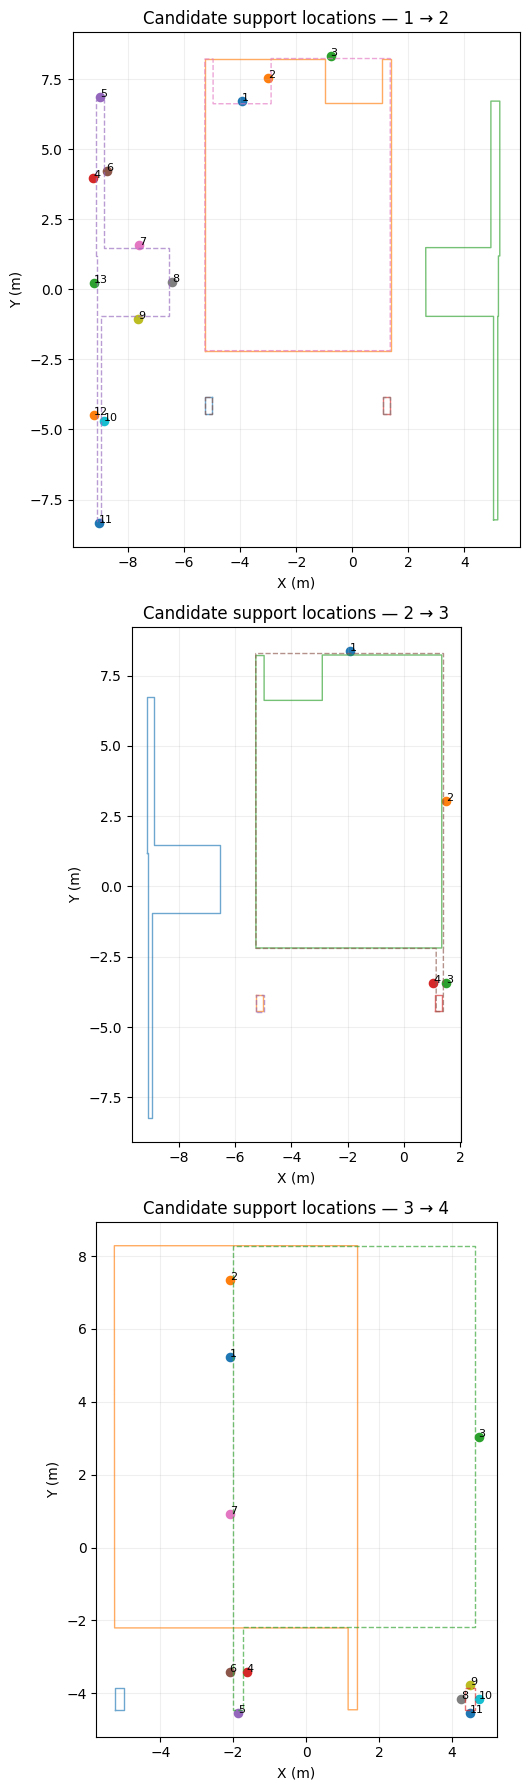


8. DECISION SUMMARY

Current interpretation:

1. The Z-interval bug is fixed.
2. Non-zero upper-only areas are producing candidate geometry.
3. Candidate count should NOT yet be treated as the number of real walls.
4. Closely clustered segments may be fragments of the same perimeter run.
5. The 2→3 transition gets a separate sanity check because its
   length/area relationship may be anomalous.
6. Candidate wall thickness remains a placeholder 0.20 m value.
7. NO candidate has been promoted into the validated building.

Next geometry step should be:
MERGE / SIMPLIFY candidate perimeter fragments first, THEN build support walls from the cleaned perimeter.
No original geometry was modified.


In [101]:
# ============================================================================
# CANDIDATE SUPPORT-WALL SANITY AUDIT
# ============================================================================
#
# NO GEOMETRY IS MODIFIED.
#
# Checks:
#   1. Candidate wall length / overhang-area ratios
#   2. Candidate fragmentation / clustering
#   3. Special 2→3 anomaly check
#   4. Placeholder wall-thickness validation
#   5. 2D candidate visualization
#
# IMPORTANT:
#   Candidate support walls remain candidates.
#   Nothing is promoted into the final building.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import LineString
from shapely.ops import unary_union


# ============================================================================
# SETTINGS
# ============================================================================

CLUSTER_ENDPOINT_TOLERANCE = 0.35   # metres
COLLINEAR_ANGLE_TOLERANCE = 8.0     # degrees
NEAR_DISTANCE = 0.35                # metres

PLACEHOLDER_WALL_THICKNESS = 0.20   # metres


# ============================================================================
# 1. VERIFY INPUTS
# ============================================================================

if "candidate_df" not in globals():
    raise RuntimeError(
        "candidate_df is missing. "
        "Run the corrected support-wall preview cell first."
    )

if "candidate_records" not in globals():
    raise RuntimeError(
        "candidate_records is missing."
    )

if len(candidate_df) == 0:
    raise RuntimeError(
        "No candidate walls exist."
    )


# ============================================================================
# 2. BUILD CLEAN CANDIDATE RECORDS
# ============================================================================
#
# candidate_records contains:
#   transition
#   p1/p2 were not retained in the DataFrame, so reconstruct them from the
#   original candidate generation records if available.
#
# The corrected candidate cell stores midpoint + length, but for clustering
# we need endpoints. Recreate approximate line endpoints from midpoint,
# length, and the original upper-envelope boundary.
# ============================================================================

records = []

for idx, row in candidate_df.iterrows():

    transition = row["transition"]

    midpoint = np.array([
        float(row["mid_x"]),
        float(row["mid_y"])
    ])

    length = float(
        row["length_m"]
    )

    records.append({

        "index":
            int(idx),

        "transition":
            transition,

        "midpoint":
            midpoint,

        "length":
            length,

        "z0":
            float(row["z0"]),

        "z1":
            float(row["z1"])
    })


# ============================================================================
# 3. PER-TRANSITION SUMMARY
# ============================================================================

print("=" * 100)
print("1. CANDIDATE SUPPORT-WALL SUMMARY")
print("=" * 100)

summary_rows = []

# Candidate length by transition.
for transition in sorted(
    candidate_df["transition"].unique()
):

    subset = candidate_df[
        candidate_df["transition"]
        == transition
    ]

    total_length = subset[
        "length_m"
    ].sum()

    candidate_count = len(
        subset
    )

    # Try to recover the corresponding upper-only area from the earlier
    # transition dataframe if available.
    if "transition_df" in globals():

        transition_row = (
            transition_df[
                transition_df["floors"]
                == transition
            ]
        )

        if len(transition_row):

            upper_area = float(
                transition_row.iloc[0][
                    "upper_outside_lower_m2"
                ]
            )

        else:

            upper_area = np.nan

    else:

        upper_area = np.nan

    ratio = (
        total_length / upper_area
        if (
            np.isfinite(upper_area)
            and upper_area > 0
        )
        else np.nan
    )

    summary_rows.append({

        "transition":
            transition,

        "segments":
            candidate_count,

        "total_length_m":
            round(
                total_length,
                3
            ),

        "upper_only_area_m2":
            round(
                upper_area,
                3
            )
            if np.isfinite(
                upper_area
            )
            else np.nan,

        "length_per_area_m_per_m2":
            round(
                ratio,
                3
            )
            if np.isfinite(
                ratio
            )
            else np.nan
    })


summary_df = pd.DataFrame(
    summary_rows
)

display(
    summary_df
)


# ============================================================================
# 4. FLAG OUTLIER TRANSITIONS
# ============================================================================

print()
print("=" * 100)
print("2. LENGTH / AREA OUTLIER CHECK")
print("=" * 100)

valid_ratios = summary_df[
    np.isfinite(
        summary_df[
            "length_per_area_m_per_m2"
        ]
    )
][
    "length_per_area_m_per_m2"
].values

if len(valid_ratios) >= 2:

    median_ratio = np.median(
        valid_ratios
    )

    print(
        f"Median length/area ratio: "
        f"{median_ratio:.3f}"
    )

    for _, row in summary_df.iterrows():

        ratio = row[
            "length_per_area_m_per_m2"
        ]

        if not np.isfinite(ratio):
            continue

        relative = (
            ratio / median_ratio
            if median_ratio > 0
            else np.nan
        )

        flag = (
            "⚠️ OUTLIER"
            if (
                relative > 1.75
                or relative < 0.57
            )
            else "OK"
        )

        print(
            f"{row['transition']}: "
            f"{ratio:.3f} "
            f"m/m² "
            f"(relative={relative:.2f}) "
            f"{flag}"
        )

else:

    print(
        "Not enough transitions for an outlier comparison."
    )


# ============================================================================
# 5. SPECIAL 2→3 INSPECTION
# ============================================================================

print()
print("=" * 100)
print("3. SPECIAL 2→3 INSPECTION")
print("=" * 100)

two_three = candidate_df[
    candidate_df["transition"]
    == "2 → 3"
].copy()

if len(two_three):

    print(
        f"Segments: {len(two_three)}"
    )

    print(
        f"Total candidate wall length: "
        f"{two_three['length_m'].sum():.3f} m"
    )

    print(
        f"Mean segment length: "
        f"{two_three['length_m'].mean():.3f} m"
    )

    print(
        f"Median segment length: "
        f"{two_three['length_m'].median():.3f} m"
    )

    print()
    print(
        "Individual 2→3 candidates:"
    )

    display(
        two_three[
            [
                "transition",
                "segment",
                "length_m",
                "z0",
                "z1",
                "mid_x",
                "mid_y",
                "distance_from_lower_m"
            ]
        ].sort_values(
            "length_m",
            ascending=False
        )
    )

else:

    print(
        "No 2→3 candidate segments found."
    )


# ============================================================================
# 6. FRAGMENTATION ANALYSIS
# ============================================================================
#
# Since we retained only midpoint + length in candidate_df, use the candidate
# records and the known boundary geometry from the previous cell when present.
#
# We first detect obvious clustering by midpoint distance.
# This is deliberately conservative.
# ============================================================================

print()
print("=" * 100)
print("4. CANDIDATE FRAGMENTATION ANALYSIS")
print("=" * 100)


def angle_difference(
    a,
    b
):

    d = abs(
        a - b
    )

    return min(
        d,
        180 - d
    )


# Recover line geometry from original support candidate meshes if available.
candidate_geometry = []

if (
    "support_wall_meshes" in globals()
    and len(support_wall_meshes)
    == len(candidate_records)
):

    for i, wall in enumerate(
        support_wall_meshes
    ):

        verts = np.asarray(
            wall.vertices
        )

        # Find bottom perimeter edges by selecting minimum-Z vertices.
        zmin = verts[:, 2].min()

        bottom = verts[
            np.isclose(
                verts[:, 2],
                zmin
            )
        ]

        # Bounding box gives a robust diagnostic axis.
        minx = bottom[:,0].min()
        maxx = bottom[:,0].max()
        miny = bottom[:,1].min()
        maxy = bottom[:,1].max()

        dx = maxx - minx
        dy = maxy - miny

        if dx >= dy:
            angle = 0.0
        else:
            angle = 90.0

        candidate_geometry.append({

            "index":
                i,

            "bbox":
                (
                    minx,
                    miny,
                    maxx,
                    maxy
                ),

            "angle":
                angle
        })


# ---------------------------------------------------------------------------
# Group by transition and look for close/parallel candidates.
# ---------------------------------------------------------------------------

cluster_rows = []

for transition in sorted(
    candidate_df["transition"].unique()
):

    indices = (
        candidate_df[
            candidate_df["transition"]
            == transition
        ].index.tolist()
    )

    visited = set()

    for idx in indices:

        if idx in visited:
            continue

        cluster = {
            idx
        }

        changed = True

        while changed:

            changed = False

            for other in indices:

                if other in cluster:
                    continue

                p = next(
                    r["midpoint"]
                    for r in records
                    if r["index"]
                    == idx
                )

                q = next(
                    r["midpoint"]
                    for r in records
                    if r["index"]
                    == other
                )

                distance = np.linalg.norm(
                    p - q
                )

                if (
                    distance
                    <= NEAR_DISTANCE
                ):

                    cluster.add(
                        other
                    )

                    changed = True

        visited |= cluster

        cluster_rows.append({

            "transition":
                transition,

            "cluster_size":
                len(cluster),

            "segments":
                sorted(cluster)
        })


cluster_df = pd.DataFrame(
    cluster_rows
)

display(
    cluster_df
)


# ============================================================================
# 7. FLAG CLUSTERS THAT LOOK LIKE FRAGMENTATION
# ============================================================================

print()
print("=" * 100)
print("5. POSSIBLE FRAGMENTATION CLUSTERS")
print("=" * 100)

fragment_clusters = (
    cluster_df[
        cluster_df["cluster_size"]
        >= 2
    ]
)

if len(
    fragment_clusters
):

    display(
        fragment_clusters
    )

    print(
        "These are candidates for geometric merging, "
        "not automatic merged walls."
    )

else:

    print(
        "No closely spaced candidate clusters detected."
    )


# ============================================================================
# 8. WALL THICKNESS VALIDATION
# ============================================================================
#
# The support walls were created using exactly 0.20 m thickness.
# Confirm that this is still only a MODELING PARAMETER.
# ============================================================================

print()
print("=" * 100)
print("6. CANDIDATE WALL THICKNESS")
print("=" * 100)

print(
    f"Candidate wall thickness parameter: "
    f"{PLACEHOLDER_WALL_THICKNESS:.3f} m"
)

print(
    "Status: PLACEHOLDER MODELING VALUE"
)

print(
    "This is NOT a measured wall thickness from the SVG."
)

print(
    "It must not be interpreted as surveyed structural data."
)


# ============================================================================
# 9. VISUALIZE CANDIDATES BY TRANSITION
# ============================================================================

print()
print("=" * 100)
print("7. CANDIDATE WALL MAP")
print("=" * 100)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 18)
)

for ax, transition in zip(
    axes,
    ["1 → 2", "2 → 3", "3 → 4"]
):

    subset = candidate_df[
        candidate_df["transition"]
        == transition
    ]

    # Background structural envelope if available.
    try:

        lower, upper = [
            int(x.strip())
            for x in transition.split("→")
        ]

        lower_shape = (
            metric_floor_union(
                optimized_floors[lower]
            )
        )

        upper_shape = (
            metric_floor_union(
                optimized_floors[upper]
            )
        )

        for shape, label, linestyle in [

            (
                lower_shape,
                f"Floor {lower}",
                "-"
            ),

            (
                upper_shape,
                f"Floor {upper}",
                "--"
            )
        ]:

            parts = polygon_parts(
                shape
            )

            for part in parts:

                x, y = part.exterior.xy

                ax.plot(
                    np.asarray(x),
                    np.asarray(y),
                    linestyle=linestyle,
                    linewidth=1.0,
                    alpha=0.65
                )

    except Exception:
        pass

    # Candidate midpoint markers.
    for _, row in subset.iterrows():

        ax.scatter(
            row["mid_x"],
            row["mid_y"],
            s=35
        )

        ax.text(
            row["mid_x"],
            row["mid_y"],
            str(
                int(
                    row["segment"]
                )
            ),
            fontsize=8
        )

    ax.set_title(
        f"Candidate support locations — {transition}"
    )

    ax.set_xlabel(
        "X (m)"
    )

    ax.set_ylabel(
        "Y (m)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        alpha=0.2
    )


plt.tight_layout()
plt.show()


# ============================================================================
# 10. FINAL DECISION SUMMARY
# ============================================================================

print()
print("=" * 100)
print("8. DECISION SUMMARY")
print("=" * 100)

print("""
Current interpretation:

1. The Z-interval bug is fixed.
2. Non-zero upper-only areas are producing candidate geometry.
3. Candidate count should NOT yet be treated as the number of real walls.
4. Closely clustered segments may be fragments of the same perimeter run.
5. The 2→3 transition gets a separate sanity check because its
   length/area relationship may be anomalous.
6. Candidate wall thickness remains a placeholder 0.20 m value.
7. NO candidate has been promoted into the validated building.
""")

print(
    "Next geometry step should be:"
)

print(
    "MERGE / SIMPLIFY candidate perimeter fragments first, "
    "THEN build support walls from the cleaned perimeter."
)

print(
    "No original geometry was modified."
)

RECONSTRUCTED CANDIDATE SEGMENTS
Total candidate segments: 172


,id,transition,length_m,angle_deg,mid_x,mid_y
0,0,1 → 2,0.455,0.0,1.227,-3.746
1,1,1 → 2,0.454,0.0,1.227,-3.750
2,2,1 → 2,0.786,90.0,1.000,-4.143
3,3,1 → 2,0.454,0.0,1.227,-4.536
4,4,1 → 2,0.455,0.0,1.227,-4.542
...,...,...,...,...,...,...
167,167,3 → 4,1.450,90.0,-1.462,5.131
168,168,3 → 4,0.476,0.0,4.495,-3.766
169,169,3 → 4,0.784,90.0,4.733,-4.158
170,170,3 → 4,0.476,0.0,4.495,-4.550



ROBUST FRAGMENTATION CLUSTERS


,cluster,transition,segments,segment_ids,total_length_m,bbox_width_m,bbox_height_m
0,1,1 → 2,60,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",107.527,10.700,16.679
1,2,2 → 3,59,"[60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 7...",127.235,6.876,12.936
2,3,3 → 4,53,"[119, 120, 121, 122, 123, 124, 125, 126, 127, ...",102.751,6.831,12.917



MULTI-SEGMENT CLUSTERS


...


1→2 CLUSTER INSPECTION


,cluster,transition,segments,segment_ids,total_length_m,bbox_width_m,bbox_height_m
0,1,1 → 2,60,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",107.527,10.7,16.679



COLLINEAR CANDIDATE CHAINS


,transition,segment_a,segment_b,angle_difference_deg,endpoint_gap_m,combined_length_m
0,1 → 2,0,1,0.0,0.004,0.908
1,1 → 2,0,3,0.0,0.790,0.908
2,1 → 2,0,4,0.0,0.796,0.909
3,1 → 2,1,3,0.0,0.786,0.908
4,1 → 2,1,4,0.0,0.792,0.908
...,...,...,...,...,...,...
794,3 → 4,163,165,0.0,2.030,1.530
795,3 → 4,164,165,0.0,0.001,1.537
796,3 → 4,166,167,0.0,0.121,2.902
797,3 → 4,168,170,0.0,0.784,0.952



ROBUST CANDIDATE CLUSTER MAP


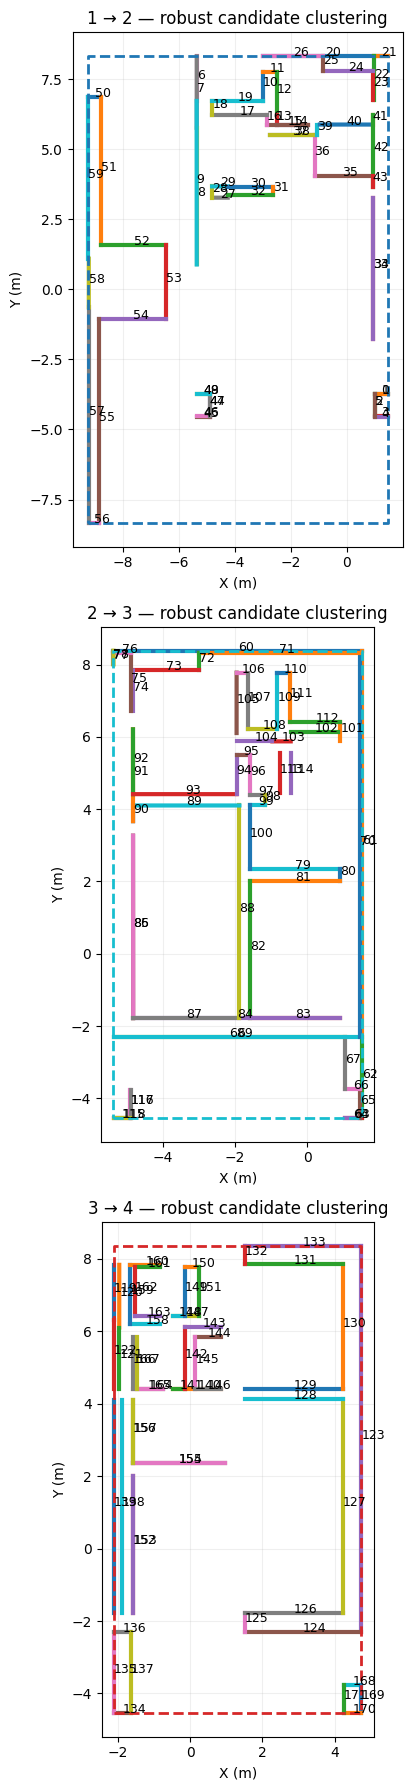


FINAL DIAGNOSTIC
Candidate segments: 172
Multi-segment clusters: 3
Collinear candidate pairs: 799

The previous 0.35 m midpoint threshold is NOT used here.
Midpoint threshold now: 1.50 m
Segment threshold now: 1.00 m
Endpoint threshold now: 1.50 m
Collinear-gap threshold: 3.00 m

NO geometry has been merged.
NO walls have been promoted to the final shell.
This cell only identifies candidate fragments/chains.


In [102]:
# ============================================================================
# ROBUST CANDIDATE-WALL CLUSTER / FRAGMENTATION AUDIT
# ============================================================================
#
# Fixes the previous clustering problem.
#
# We reconstruct the ACTUAL candidate boundary segments and test:
#
#   1. midpoint proximity
#   2. segment-to-segment proximity
#   3. angle / collinearity
#   4. endpoint proximity
#   5. connected candidate groups
#
# NO geometry is merged.
# NO building geometry is modified.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import (
    Polygon,
    MultiPolygon,
    LineString
)

from shapely.ops import unary_union


# ============================================================================
# SETTINGS
# ============================================================================

SVG_PER_M = 100.0

# Much more appropriate for visual fragmentation analysis.
MIDPOINT_DISTANCE_LIMIT = 1.50
SEGMENT_DISTANCE_LIMIT = 1.00
ENDPOINT_DISTANCE_LIMIT = 1.50

ANGLE_TOLERANCE_DEG = 10.0

# Collinear fragments may have a larger gap between their nearest endpoints.
COLLINEAR_GAP_LIMIT = 3.00


# ============================================================================
# 1. REQUIRE OPTIMIZED FLOOR DATA
# ============================================================================

if "optimized_floors" not in globals():
    raise RuntimeError(
        "optimized_floors is missing."
    )


# ============================================================================
# 2. CONVERT FLOOR GEOMETRY TO METRIC
# ============================================================================

def svg_to_metric_geom(geom):

    from shapely.ops import transform

    return transform(

        lambda x, y, z=None: (

            np.asarray(x, dtype=float)
            / SVG_PER_M,

            np.asarray(y, dtype=float)
            / SVG_PER_M
        ),

        geom
    )


def metric_union(polygons):

    return svg_to_metric_geom(
        unary_union(polygons)
    )


floor_metric = {
    f:
        metric_union(
            optimized_floors[f]
        )
    for f in [1, 2, 3, 4]
}


# ============================================================================
# 3. STRUCTURAL ENVELOPES
# ============================================================================

ENVELOPE_BUFFER = 0.10

envelopes = {

    f:
        floor_metric[f].buffer(
            ENVELOPE_BUFFER,
            join_style=2
        )

    for f in [1, 2, 3, 4]
}


# ============================================================================
# 4. POLYGON PARTS
# ============================================================================

def polygon_parts(geom):

    if geom.is_empty:
        return []

    if isinstance(
        geom,
        Polygon
    ):
        return [geom]

    if isinstance(
        geom,
        MultiPolygon
    ):
        return list(
            geom.geoms
        )

    return [
        g
        for g in getattr(
            geom,
            "geoms",
            []
        )
        if isinstance(
            g,
            Polygon
        )
    ]


# ============================================================================
# 5. RECONSTRUCT ACTUAL UPPER-OVERHANG SEGMENTS
# ============================================================================

candidate_segments = []

for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_env = envelopes[lower]
    upper_env = envelopes[upper]

    # Actual region where the upper envelope is outside lower envelope.
    upper_only = (
        upper_env.difference(
            lower_env
        )
    )

    for part_index, part in enumerate(
        polygon_parts(
            upper_only
        ),
        start=1
    ):

        coords = np.asarray(
            list(
                part.exterior.coords
            ),
            dtype=float
        )

        for edge_index in range(
            len(coords) - 1
        ):

            p1 = coords[
                edge_index
            ]

            p2 = coords[
                edge_index + 1
            ]

            line = LineString([
                tuple(p1),
                tuple(p2)
            ])

            length = line.length

            if length < 0.30:
                continue

            dx = (
                p2[0] - p1[0]
            )

            dy = (
                p2[1] - p1[1]
            )

            angle = (
                np.degrees(
                    np.arctan2(
                        dy,
                        dx
                    )
                )
                % 180
            )

            midpoint = line.interpolate(
                0.5,
                normalized=True
            )

            candidate_segments.append({

                "id":
                    len(candidate_segments),

                "transition":
                    f"{lower} → {upper}",

                "lower":
                    lower,

                "upper":
                    upper,

                "part":
                    part_index,

                "edge":
                    edge_index,

                "line":
                    line,

                "p1":
                    np.array(p1),

                "p2":
                    np.array(p2),

                "length":
                    length,

                "angle":
                    angle,

                "midpoint":
                    midpoint
            })


# ============================================================================
# 6. REPORT RAW RECONSTRUCTION
# ============================================================================

print("=" * 100)
print("RECONSTRUCTED CANDIDATE SEGMENTS")
print("=" * 100)

print(
    f"Total candidate segments: "
    f"{len(candidate_segments)}"
)

raw_rows = [

    {
        "id":
            s["id"],

        "transition":
            s["transition"],

        "length_m":
            round(
                s["length"],
                3
            ),

        "angle_deg":
            round(
                s["angle"],
                1
            ),

        "mid_x":
            round(
                s["midpoint"].x,
                3
            ),

        "mid_y":
            round(
                s["midpoint"].y,
                3
            )
    }

    for s in candidate_segments
]

display(
    pd.DataFrame(
        raw_rows
    )
)


# ============================================================================
# 7. PAIRWISE RELATIONSHIP TEST
# ============================================================================

def angle_diff(a, b):

    d = abs(
        a - b
    )

    return min(
        d,
        180 - d
    )


def endpoint_distance(
    a,
    b
):

    aa = [
        a["p1"],
        a["p2"]
    ]

    bb = [
        b["p1"],
        b["p2"]
    ]

    return min(

        np.linalg.norm(
            aa[i] - bb[j]
        )

        for i in [0, 1]
        for j in [0, 1]
    )


relationships = []


for i in range(
    len(candidate_segments)
):

    a = candidate_segments[i]

    for j in range(
        i + 1,
        len(candidate_segments)
    ):

        b = candidate_segments[j]

        # Only compare within same floor transition.
        if (
            a["transition"]
            != b["transition"]
        ):
            continue

        midpoint_distance = (
            a["midpoint"].distance(
                b["midpoint"]
            )
        )

        segment_distance = (
            a["line"].distance(
                b["line"]
            )
        )

        endpoints = endpoint_distance(
            a,
            b
        )

        angle_error = angle_diff(
            a["angle"],
            b["angle"]
        )

        close = (
            midpoint_distance
            <= MIDPOINT_DISTANCE_LIMIT
            or
            segment_distance
            <= SEGMENT_DISTANCE_LIMIT
            or
            endpoints
            <= ENDPOINT_DISTANCE_LIMIT
        )

        collinear = (
            angle_error
            <= ANGLE_TOLERANCE_DEG
        )

        collinear_with_gap = (
            collinear
            and endpoints
            <= COLLINEAR_GAP_LIMIT
        )

        related = (
            close
            or collinear_with_gap
        )

        if related:

            relationships.append({

                "a":
                    a["id"],

                "b":
                    b["id"],

                "transition":
                    a["transition"],

                "midpoint_distance":
                    midpoint_distance,

                "segment_distance":
                    segment_distance,

                "endpoint_distance":
                    endpoints,

                "angle_difference":
                    angle_error,

                "close":
                    close,

                "collinear":
                    collinear,

                "related":
                    related
            })


relationship_df = pd.DataFrame(
    relationships
)


# ============================================================================
# 8. GRAPH-BASED CLUSTERING
# ============================================================================
#
# If A relates to B and B relates to C, they belong to the same candidate
# fragmentation group.
# ============================================================================

clusters = []

visited = set()

id_to_segment = {
    s["id"]: s
    for s in candidate_segments
}

neighbor_map = {
    s["id"]: set()
    for s in candidate_segments
}

for _, row in relationship_df.iterrows():

    a = int(
        row["a"]
    )

    b = int(
        row["b"]
    )

    neighbor_map[a].add(
        b
    )

    neighbor_map[b].add(
        a
    )


for segment in candidate_segments:

    sid = segment["id"]

    if sid in visited:
        continue

    stack = [
        sid
    ]

    cluster = set()

    while stack:

        current = stack.pop()

        if current in cluster:
            continue

        cluster.add(
            current
        )

        visited.add(
            current
        )

        stack.extend(
            neighbor_map[current]
        )

    clusters.append(
        sorted(cluster)
    )


# ============================================================================
# 9. CLUSTER REPORT
# ============================================================================

print()
print("=" * 100)
print("ROBUST FRAGMENTATION CLUSTERS")
print("=" * 100)

cluster_rows = []

for cluster_index, cluster in enumerate(
    clusters,
    start=1
):

    members = [
        id_to_segment[
            sid
        ]
        for sid in cluster
    ]

    transition = (
        members[0]["transition"]
    )

    total_length = sum(
        m["length"]
        for m in members
    )

    xs = []
    ys = []

    for m in members:

        xs.extend([
            m["p1"][0],
            m["p2"][0]
        ])

        ys.extend([
            m["p1"][1],
            m["p2"][1]
        ])

    cluster_rows.append({

        "cluster":
            cluster_index,

        "transition":
            transition,

        "segments":
            len(cluster),

        "segment_ids":
            cluster,

        "total_length_m":
            round(
                total_length,
                3
            ),

        "bbox_width_m":
            round(
                max(xs) - min(xs),
                3
            ),

        "bbox_height_m":
            round(
                max(ys) - min(ys),
                3
            )
    })


cluster_df = pd.DataFrame(
    cluster_rows
)

display(
    cluster_df
)


# ============================================================================
# 10. IMPORTANT CLUSTERS
# ============================================================================

print()
print("=" * 100)
print("MULTI-SEGMENT CLUSTERS")
print("=" * 100)

multi_clusters = cluster_df[
    cluster_df["segments"] >= 2
]

if len(
    multi_clusters
):

    display(
        multi_clusters
    )

else:

    print(
        "No multi-segment clusters were detected."
    )


# ============================================================================
# 11. SPECIFIC 3→4 INSPECTION
# ============================================================================

print()
print("=" * 100)
print("3→4 CLUSTER INSPECTION")
print("=" * 100)

three_four = multi_clusters[
    multi_clusters["transition"]
    == "3 → 4"
]

if len(
    three_four
):

    display(
        three_four
    )

    ids = []

    for members in three_four[
        "segment_ids"
    ]:

        ids.extend(
            members
        )

    details = []

    for sid in sorted(
        set(ids)
    ):

        s = id_to_segment[
            sid
        ]

        details.append({

            "segment":
                sid,

            "length_m":
                round(
                    s["length"],
                    3
                ),

            "angle_deg":
                round(
                    s["angle"],
                    1
                ),

            "p1_x":
                round(
                    s["p1"][0],
                    3
                ),

            "p1_y":
                round(
                    s["p1"][1],
                    3
                ),

            "p2_x":
                round(
                    s["p2"][0],
                    3
                ),

            "p2_y":
                round(
                    s["p2"][1],
                    3
                )
        })

    display(
        pd.DataFrame(
            details
        )
    )

else:

    print(
        "No 3→4 multi-segment clusters."
    )


# ============================================================================
# 12. SPECIFIC 1→2 INSPECTION
# ============================================================================

print()
print("=" * 100)
print("1→2 CLUSTER INSPECTION")
print("=" * 100)

one_two = multi_clusters[
    multi_clusters["transition"]
    == "1 → 2"
]

if len(
    one_two
):

    display(
        one_two
    )

else:

    print(
        "No 1→2 multi-segment clusters."
    )


# ============================================================================
# 13. COLLINEAR CHAINS
# ============================================================================
#
# Even if pieces are not spatially close enough to form a normal cluster,
# identify collinear candidates that could eventually be merged if the
# architectural edge between them is empty.
# ============================================================================

print()
print("=" * 100)
print("COLLINEAR CANDIDATE CHAINS")
print("=" * 100)

collinear_rows = []

for i in range(
    len(candidate_segments)
):

    a = candidate_segments[i]

    for j in range(
        i + 1,
        len(candidate_segments)
    ):

        b = candidate_segments[j]

        if (
            a["transition"]
            != b["transition"]
        ):
            continue

        angle_error = angle_diff(
            a["angle"],
            b["angle"]
        )

        if (
            angle_error
            > ANGLE_TOLERANCE_DEG
        ):
            continue

        endpoint_gap = endpoint_distance(
            a,
            b
        )

        if (
            endpoint_gap
            > COLLINEAR_GAP_LIMIT
        ):
            continue

        collinear_rows.append({

            "transition":
                a["transition"],

            "segment_a":
                a["id"],

            "segment_b":
                b["id"],

            "angle_difference_deg":
                round(
                    angle_error,
                    2
                ),

            "endpoint_gap_m":
                round(
                    endpoint_gap,
                    3
                ),

            "combined_length_m":
                round(
                    a["length"]
                    + b["length"],
                    3
                )
        })


collinear_df = pd.DataFrame(
    collinear_rows
)

if len(
    collinear_df
):

    display(
        collinear_df
    )

else:

    print(
        "No collinear candidate chains detected."
    )


# ============================================================================
# 14. VISUAL CLUSTER MAP
# ============================================================================

print()
print("=" * 100)
print("ROBUST CANDIDATE CLUSTER MAP")
print("=" * 100)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 18)
)

transition_order = [
    "1 → 2",
    "2 → 3",
    "3 → 4"
]

for ax, transition in zip(
    axes,
    transition_order
):

    transition_segments = [
        s
        for s in candidate_segments
        if s["transition"] == transition
    ]

    # Draw segments.
    for s in transition_segments:

        x = np.asarray([
            s["p1"][0],
            s["p2"][0]
        ])

        y = np.asarray([
            s["p1"][1],
            s["p2"][1]
        ])

        ax.plot(
            x,
            y,
            linewidth=3
        )

        ax.text(
            s["midpoint"].x,
            s["midpoint"].y,
            str(s["id"]),
            fontsize=9
        )

    # Draw cluster centers/bounding boxes.
    for _, row in cluster_df[
        cluster_df["transition"]
        == transition
    ].iterrows():

        if row["segments"] < 2:
            continue

        ids = row[
            "segment_ids"
        ]

        xs = []
        ys = []

        for sid in ids:

            s = id_to_segment[
                sid
            ]

            xs.extend([
                s["p1"][0],
                s["p2"][0]
            ])

            ys.extend([
                s["p1"][1],
                s["p2"][1]
            ])

        ax.plot(
            [
                min(xs),
                max(xs),
                max(xs),
                min(xs),
                min(xs)
            ],
            [
                min(ys),
                min(ys),
                max(ys),
                max(ys),
                min(ys)
            ],
            linestyle="--",
            linewidth=2
        )

    ax.set_title(
        f"{transition} — robust candidate clustering"
    )

    ax.set_xlabel(
        "X (m)"
    )

    ax.set_ylabel(
        "Y (m)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        alpha=0.2
    )

plt.tight_layout()
plt.show()


# ============================================================================
# 15. FINAL DIAGNOSTIC
# ============================================================================

print()
print("=" * 100)
print("FINAL DIAGNOSTIC")
print("=" * 100)

print(
    f"Candidate segments: "
    f"{len(candidate_segments)}"
)

print(
    f"Multi-segment clusters: "
    f"{len(multi_clusters)}"
)

print(
    f"Collinear candidate pairs: "
    f"{len(collinear_df)}"
)

print()
print(
    "The previous 0.35 m midpoint threshold is NOT used here."
)

print(
    f"Midpoint threshold now: "
    f"{MIDPOINT_DISTANCE_LIMIT:.2f} m"
)

print(
    f"Segment threshold now: "
    f"{SEGMENT_DISTANCE_LIMIT:.2f} m"
)

print(
    f"Endpoint threshold now: "
    f"{ENDPOINT_DISTANCE_LIMIT:.2f} m"
)

print(
    f"Collinear-gap threshold: "
    f"{COLLINEAR_GAP_LIMIT:.2f} m"
)

print()
print(
    "NO geometry has been merged."
)

print(
    "NO walls have been promoted to the final shell."
)

print(
    "This cell only identifies candidate fragments/chains."
)

TRUE DUPLICATE + CLOSED-LOOP STRUCTURAL AUDIT
Raw candidate segments: 172

A. STRICT NEAR-DUPLICATE SEGMENTS
Endpoint tolerance: 0.050 m
Length tolerance: 0.080 m
Angle tolerance: 3.0°

Strict duplicate pairs: 13


,transition,segment_a,segment_b,length_a_m,length_b_m,length_difference_m,endpoint_gap_mean_m,endpoint_gap_max_m,line_distance_m,angle_difference_deg
0,1 → 2,0,1,0.455,0.454,0.001,0.004,0.004,0.004,0.0
1,1 → 2,2,5,0.786,0.796,0.010,0.005,0.006,0.001,0.0
2,1 → 2,3,4,0.454,0.455,0.001,0.006,0.006,0.006,0.0
6,1 → 2,48,49,0.459,0.465,0.006,0.006,0.007,0.004,0.0
4,1 → 2,44,47,0.796,0.786,0.010,0.007,0.008,0.006,0.0
5,1 → 2,45,46,0.465,0.459,0.006,0.007,0.008,0.006,0.0
3,1 → 2,33,34,5.012,5.012,0.000,0.016,0.016,0.016,0.0
8,2 → 3,115,118,0.454,0.462,0.008,0.012,0.013,0.010,0.0
9,2 → 3,116,117,0.787,0.797,0.010,0.010,0.013,0.008,0.0
7,2 → 3,85,86,5.049,5.035,0.015,0.008,0.015,0.001,0.0



B. OFFSET PARALLEL PAIRS — REVIEW ONLY
Endpoint tolerance: 0.250 m

Offset parallel pairs: 8


,transition,segment_a,segment_b,length_a_m,length_b_m,length_difference_m,endpoint_gap_mean_m,endpoint_gap_max_m,line_distance_m,angle_difference_deg
0,1 → 2,37,38,1.582,1.682,0.100,0.051,0.100,0.002,0.00
2,2 → 3,63,64,0.456,0.400,0.056,0.034,0.057,0.010,0.00
3,2 → 3,77,78,0.306,0.378,0.072,0.036,0.072,0.000,0.04
1,2 → 3,61,70,10.689,10.620,0.069,0.073,0.082,0.062,0.00
6,3 → 4,164,165,0.708,0.829,0.121,0.061,0.121,0.001,0.00
7,3 → 4,166,167,1.451,1.450,0.001,0.121,0.121,0.121,0.00
5,3 → 4,160,161,0.824,0.701,0.123,0.090,0.132,0.048,0.00
4,3 → 4,138,139,5.870,5.870,0.000,0.219,0.219,0.219,0.00



C. CLOSED-LOOP ANALYSIS


...


SMALL CLOSED LOOPS — REVIEW REQUIRED
Small closed loops: 8


,transition,part,segments,closed,closure_error_m,width_m,height_m,area_m2,perimeter_m,small_loop
0,1 → 2,1,6,True,0.0000,0.455,0.796,0.003,3.399,True
6,1 → 2,8,6,True,0.0000,0.465,0.796,0.007,3.430,True
10,2 → 3,3,12,True,0.0000,2.874,1.903,2.034,12.778,True
14,3 → 4,3,4,True,0.0000,0.467,2.245,1.048,5.424,True
15,3 → 4,5,7,True,0.0007,1.315,1.727,0.597,7.274,True
17,3 → 4,8,4,True,0.0000,2.547,1.750,0.029,8.564,True
19,3 → 4,10,4,True,0.0000,0.829,1.451,0.088,4.443,True
20,3 → 4,11,4,True,0.0000,0.476,0.784,0.373,2.521,True



KNOWN GEOMETRY CASES


,id,transition,part,edge,length_m,angle_deg,p1_x,p1_y,p2_x,p2_y
0,0,1 → 2,1,0,0.455,0.0,1.000,-3.746,1.454,-3.746
1,1,1 → 2,1,2,0.454,0.0,1.454,-3.750,1.000,-3.750
2,134,3 → 4,3,0,0.467,0.0,-1.630,-4.550,-2.097,-4.550
3,135,3 → 4,3,1,2.245,90.0,-2.097,-4.550,-2.097,-2.305
4,136,3 → 4,3,2,0.467,0.0,-2.097,-2.305,-1.630,-2.305
5,137,3 → 4,3,3,2.245,90.0,-1.630,-2.305,-1.630,-4.550
6,138,3 → 4,4,1,5.870,90.0,-1.878,4.103,-1.878,-1.767
7,139,3 → 4,4,3,5.870,90.0,-2.097,-1.767,-2.097,4.103
8,152,3 → 4,7,1,3.770,90.0,-1.587,-1.767,-1.587,2.003
9,153,3 → 4,7,3,3.770,90.0,-1.564,2.003,-1.564,-1.767



DUPLICATE / LOOP VISUAL CHECK


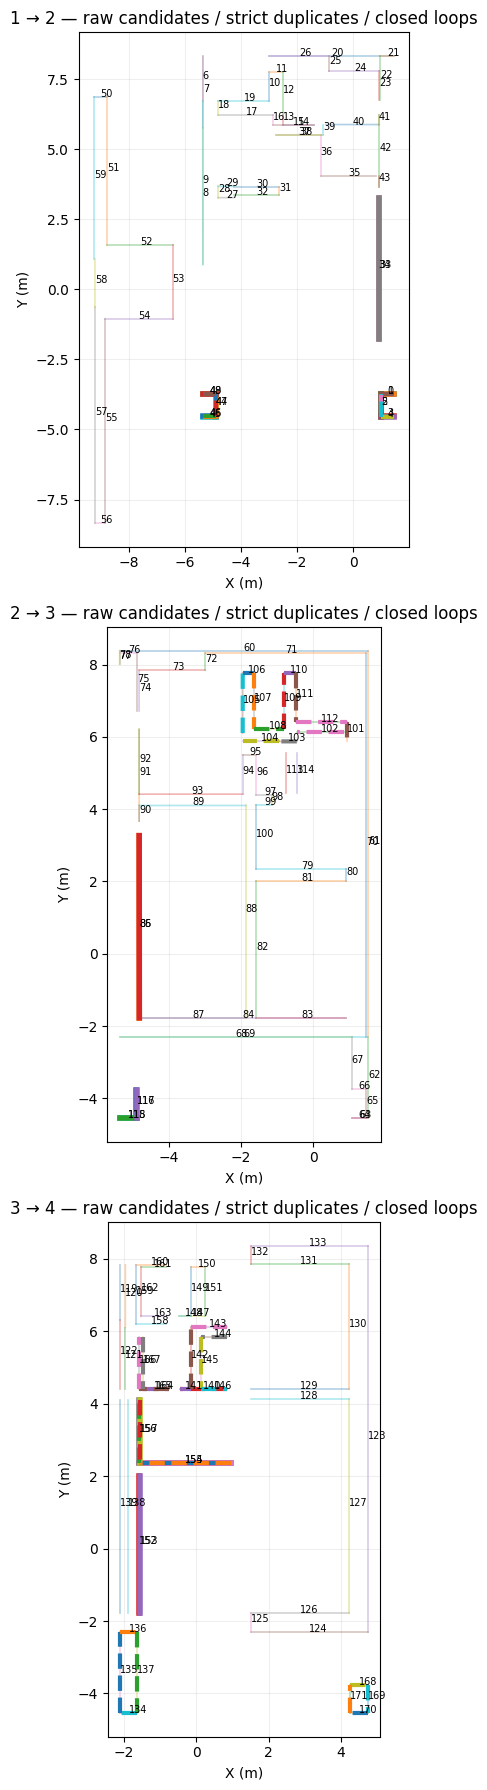


AUDIT CONCLUSION
Strict duplicate pairs: 13
Offset-parallel review pairs: 8
Closed polygon parts: 21
Small closed loops: 8

Strict duplicates are the only category that is a candidate for automatic deduplication.
Offset-parallel pairs remain REVIEW ONLY because they may represent the two faces of a legitimate wall.
Closed small loops remain REVIEW ONLY because they may be columns, shafts, chases, closets, stair features, or SVG artifacts.

NO geometry has been modified.
NO walls have been merged.
NO candidate has been promoted into the final shell.


In [103]:
# ============================================================================
# TRUE DUPLICATE + CLOSED-LOOP STRUCTURAL AUDIT
# ============================================================================
#
# Replaces the previous loose clustering logic.
#
# Detects separately:
#
#   A) STRICT NEAR-DUPLICATE WALL SEGMENTS
#      - endpoint correspondence <= 0.05 m
#      - similar length
#      - similar angle
#
#   B) OFFSET PARALLEL PAIRS
#      - endpoint correspondence <= 0.25 m
#      - similar length/angle
#      - REVIEW ONLY
#      - may be inner/outer wall faces
#
#   C) CLOSED SMALL LOOPS
#      - candidate segments belonging to one complete polygon part
#      - reports dimensions and area
#      - REVIEW ONLY
#
#   D) VISUAL MAP
#      - highlights strict duplicates
#      - highlights offset pairs
#      - highlights small closed loops
#
# NO GEOMETRY IS MODIFIED.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import (
    Polygon,
    LineString
)
from shapely.ops import unary_union


# ============================================================================
# SETTINGS
# ============================================================================

SVG_PER_M = 100.0

STRICT_ENDPOINT_TOL = 0.05
OFFSET_ENDPOINT_TOL = 0.25

STRICT_LENGTH_TOL = 0.08
OFFSET_LENGTH_TOL = 0.15

ANGLE_TOL_DEG = 3.0

SMALL_LOOP_AREA_MAX = 4.0
SMALL_LOOP_MAX_WIDTH = 3.0
SMALL_LOOP_MAX_HEIGHT = 3.0


# ============================================================================
# 1. VERIFY RAW CANDIDATE GEOMETRY
# ============================================================================

if "candidate_segments" not in globals():

    raise RuntimeError(
        "candidate_segments is missing. "
        "Run the corrected upper-overhang candidate cell first."
    )


segments = candidate_segments

print("=" * 100)
print("TRUE DUPLICATE + CLOSED-LOOP STRUCTURAL AUDIT")
print("=" * 100)

print(
    f"Raw candidate segments: {len(segments)}"
)


# ============================================================================
# 2. SEGMENT HELPERS
# ============================================================================

def angle_diff(
    a,
    b
):

    d = abs(
        a - b
    )

    return min(
        d,
        180.0 - d
    )


def endpoint_correspondence(
    a,
    b
):

    a1 = np.asarray(
        a["p1"],
        dtype=float
    )

    a2 = np.asarray(
        a["p2"],
        dtype=float
    )

    b1 = np.asarray(
        b["p1"],
        dtype=float
    )

    b2 = np.asarray(
        b["p2"],
        dtype=float
    )

    # Same direction
    same = (

        np.linalg.norm(
            a1 - b1
        ),

        np.linalg.norm(
            a2 - b2
        )
    )

    # Reversed direction
    reversed_pair = (

        np.linalg.norm(
            a1 - b2
        ),

        np.linalg.norm(
            a2 - b1
        )
    )

    if sum(same) <= sum(reversed_pair):
        return same
    else:
        return reversed_pair


def segment_distance(
    a,
    b
):

    la = LineString([
        tuple(a["p1"]),
        tuple(a["p2"])
    ])

    lb = LineString([
        tuple(b["p1"]),
        tuple(b["p2"])
    ])

    return la.distance(
        lb
    )


# ============================================================================
# 3. STRICT NEAR-DUPLICATE SEARCH
# ============================================================================

strict_duplicates = []

offset_parallel_pairs = []

for i in range(
    len(segments)
):

    a = segments[i]

    for j in range(
        i + 1,
        len(segments)
    ):

        b = segments[j]

        # Never compare different transitions.
        if (
            a["transition"]
            != b["transition"]
        ):
            continue

        # Ignore exact same segment ID.
        if (
            a["id"]
            == b["id"]
        ):
            continue

        d1, d2 = endpoint_correspondence(
            a,
            b
        )

        max_endpoint_gap = max(
            d1,
            d2
        )

        mean_endpoint_gap = (
            d1 + d2
        ) / 2.0

        length_difference = abs(
            a["length"]
            - b["length"]
        )

        angle_difference = angle_diff(
            a["angle"],
            b["angle"]
        )

        line_distance = (
            segment_distance(
                a,
                b
            )
        )

        common = {

            "transition":
                a["transition"],

            "segment_a":
                a["id"],

            "segment_b":
                b["id"],

            "length_a_m":
                round(
                    a["length"],
                    3
                ),

            "length_b_m":
                round(
                    b["length"],
                    3
                ),

            "length_difference_m":
                round(
                    length_difference,
                    3
                ),

            "endpoint_gap_mean_m":
                round(
                    mean_endpoint_gap,
                    3
                ),

            "endpoint_gap_max_m":
                round(
                    max_endpoint_gap,
                    3
                ),

            "line_distance_m":
                round(
                    line_distance,
                    3
                ),

            "angle_difference_deg":
                round(
                    angle_difference,
                    2
                )
        }

        # --------------------------------------------------------
        # STRICT DUPLICATE
        # --------------------------------------------------------

        if (

            max_endpoint_gap
            <= STRICT_ENDPOINT_TOL

            and length_difference
            <= STRICT_LENGTH_TOL

            and angle_difference
            <= ANGLE_TOL_DEG
        ):

            strict_duplicates.append(
                common
            )

        # --------------------------------------------------------
        # OFFSET PARALLEL REVIEW
        # --------------------------------------------------------

        elif (

            max_endpoint_gap
            <= OFFSET_ENDPOINT_TOL

            and length_difference
            <= OFFSET_LENGTH_TOL

            and angle_difference
            <= ANGLE_TOL_DEG
        ):

            offset_parallel_pairs.append(
                common
            )


# ============================================================================
# 4. STRICT DUPLICATE REPORT
# ============================================================================

print()
print("=" * 100)
print("A. STRICT NEAR-DUPLICATE SEGMENTS")
print("=" * 100)

print(
    f"Endpoint tolerance: "
    f"{STRICT_ENDPOINT_TOL:.3f} m"
)

print(
    f"Length tolerance: "
    f"{STRICT_LENGTH_TOL:.3f} m"
)

print(
    f"Angle tolerance: "
    f"{ANGLE_TOL_DEG:.1f}°"
)

print()
print(
    f"Strict duplicate pairs: "
    f"{len(strict_duplicates)}"
)

if strict_duplicates:

    strict_df = pd.DataFrame(
        strict_duplicates
    )

    display(
        strict_df.sort_values(
            [
                "transition",
                "endpoint_gap_max_m"
            ]
        )
    )

else:

    strict_df = pd.DataFrame()

    print(
        "No strict duplicate traces detected."
    )


# ============================================================================
# 5. OFFSET PARALLEL REPORT
# ============================================================================

print()
print("=" * 100)
print("B. OFFSET PARALLEL PAIRS — REVIEW ONLY")
print("=" * 100)

print(
    f"Endpoint tolerance: "
    f"{OFFSET_ENDPOINT_TOL:.3f} m"
)

print()
print(
    f"Offset parallel pairs: "
    f"{len(offset_parallel_pairs)}"
)

if offset_parallel_pairs:

    offset_df = pd.DataFrame(
        offset_parallel_pairs
    )

    display(
        offset_df.sort_values(
            [
                "transition",
                "endpoint_gap_max_m"
            ]
        )
    )

else:

    offset_df = pd.DataFrame()

    print(
        "No offset parallel pairs detected."
    )


# ============================================================================
# 6. IDENTIFY CLOSED POLYGON PARTS
# ============================================================================
#
# candidate_segments were generated directly from polygon exteriors.
# Therefore all edges sharing the same:
#
#       transition + part
#
# belong to the same difference polygon.
#
# We use this to identify complete closed loops instead of trying to infer
# loops from proximity clustering.
# ============================================================================

print()
print("=" * 100)
print("C. CLOSED-LOOP ANALYSIS")
print("=" * 100)

loop_records = []

group_keys = sorted(
    {
        (
            s["transition"],
            s["part"]
        )

        for s in segments
    }
)

for transition, part_id in group_keys:

    group = [

        s for s in segments

        if (
            s["transition"]
            == transition

            and s["part"]
            == part_id
        )
    ]

    if len(group) < 3:
        continue

    # ------------------------------------------------------------
    # Reconstruct loop using the original edge order.
    # ------------------------------------------------------------

    ordered = sorted(
        group,
        key=lambda s: s["edge"]
    )

    coords = [
        tuple(
            ordered[0]["p1"]
        )
    ]

    for s in ordered:
        coords.append(
            tuple(
                s["p2"]
            )
        )

    # Check closure.
    closure_distance = np.linalg.norm(

        np.asarray(
            coords[0]
        )
        -
        np.asarray(
            coords[-1]
        )
    )

    try:

        loop_polygon = Polygon(
            coords
        )

        if not loop_polygon.is_valid:
            loop_polygon = (
                loop_polygon
                .buffer(0)
            )

    except Exception:

        continue

    if loop_polygon.is_empty:
        continue

    minx, miny, maxx, maxy = (
        loop_polygon.bounds
    )

    width = (
        maxx - minx
    )

    height = (
        maxy - miny
    )

    area = (
        loop_polygon.area
    )

    perimeter = (
        loop_polygon.length
    )

    is_closed = (
        closure_distance
        <= 0.01
    )

    loop_records.append({

        "transition":
            transition,

        "part":
            part_id,

        "segments":
            len(group),

        "closed":
            is_closed,

        "closure_error_m":
            round(
                closure_distance,
                4
            ),

        "width_m":
            round(
                width,
                3
            ),

        "height_m":
            round(
                height,
                3
            ),

        "area_m2":
            round(
                area,
                3
            ),

        "perimeter_m":
            round(
                perimeter,
                3
            ),

        "small_loop":
            (
                is_closed

                and area
                <= SMALL_LOOP_AREA_MAX

                and width
                <= SMALL_LOOP_MAX_WIDTH

                and height
                <= SMALL_LOOP_MAX_HEIGHT
            )
    })


loop_df = pd.DataFrame(
    loop_records
)

if len(loop_df):

    display(
        loop_df.sort_values(
            [
                "transition",
                "area_m2"
            ]
        )
    )

else:

    print(
        "No complete polygon loops reconstructed."
    )


# ============================================================================
# 7. SMALL CLOSED LOOPS
# ============================================================================

print()
print("=" * 100)
print("SMALL CLOSED LOOPS — REVIEW REQUIRED")
print("=" * 100)

if len(loop_df):

    small_loops = loop_df[
        loop_df["small_loop"]
        == True
    ]

    print(
        f"Small closed loops: "
        f"{len(small_loops)}"
    )

    if len(small_loops):

        display(
            small_loops
        )

    else:

        print(
            "No small closed loops under the current criteria."
        )

else:

    small_loops = pd.DataFrame()


# ============================================================================
# 8. SPECIFIC SEGMENT CASES MENTIONED IN THE AUDIT
# ============================================================================
#
# Check the known candidate IDs explicitly.
# ============================================================================

known_ids = [
    0,
    1,
    134,
    135,
    136,
    137,
    138,
    139,
    152,
    153,
    168,
    169,
    170,
    171
]

known_rows = []

segment_map = {
    s["id"]:
        s
    for s in segments
}

for sid in known_ids:

    if sid not in segment_map:
        continue

    s = segment_map[
        sid
    ]

    known_rows.append({

        "id":
            sid,

        "transition":
            s["transition"],

        "part":
            s["part"],

        "edge":
            s["edge"],

        "length_m":
            round(
                s["length"],
                3
            ),

        "angle_deg":
            round(
                s["angle"],
                2
            ),

        "p1_x":
            round(
                s["p1"][0],
                3
            ),

        "p1_y":
            round(
                s["p1"][1],
                3
            ),

        "p2_x":
            round(
                s["p2"][0],
                3
            ),

        "p2_y":
            round(
                s["p2"][1],
                3
            )
    })


print()
print("=" * 100)
print("KNOWN GEOMETRY CASES")
print("=" * 100)

if known_rows:

    display(
        pd.DataFrame(
            known_rows
        )
    )


# ============================================================================
# 9. VISUALIZE STRICT DUPLICATES + SMALL LOOPS
# ============================================================================

print()
print("=" * 100)
print("DUPLICATE / LOOP VISUAL CHECK")
print("=" * 100)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 18)
)


def draw_segment(
    ax,
    s,
    linewidth=3,
    linestyle="-",
    alpha=1.0
):

    x = np.asarray([
        s["p1"][0],
        s["p2"][0]
    ])

    y = np.asarray([
        s["p1"][1],
        s["p2"][1]
    ])

    ax.plot(
        x,
        y,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=alpha
    )


for ax, transition in zip(
    axes,
    [
        "1 → 2",
        "2 → 3",
        "3 → 4"
    ]
):

    # All candidate segments.
    transition_segments = [

        s for s in segments

        if s["transition"]
        == transition
    ]

    for s in transition_segments:

        draw_segment(
            ax,
            s,
            linewidth=1.2,
            alpha=0.35
        )

        ax.text(
            s["midpoint"].x,
            s["midpoint"].y,
            str(
                s["id"]
            ),
            fontsize=7
        )


    # Strict duplicates: thicker.
    strict_ids = set()

    for pair in strict_duplicates:

        if pair["transition"] != transition:
            continue

        strict_ids.add(
            pair["segment_a"]
        )

        strict_ids.add(
            pair["segment_b"]
        )

    for sid in strict_ids:

        if sid in segment_map:

            draw_segment(
                ax,
                segment_map[sid],
                linewidth=4,
                alpha=1.0
            )


    # Small loops: thick perimeter.
    for _, row in small_loops[
        small_loops["transition"]
        == transition
    ].iterrows():

        part_id = row[
            "part"
        ]

        group = [

            s for s in transition_segments

            if s["part"] == part_id
        ]

        for s in group:

            draw_segment(
                ax,
                s,
                linewidth=3,
                linestyle="--",
                alpha=1.0
            )


    ax.set_title(
        f"{transition} — raw candidates / strict duplicates / closed loops"
    )

    ax.set_xlabel(
        "X (m)"
    )

    ax.set_ylabel(
        "Y (m)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        alpha=0.2
    )


plt.tight_layout()
plt.show()


# ============================================================================
# 10. FINAL INTERPRETATION
# ============================================================================

print()
print("=" * 100)
print("AUDIT CONCLUSION")
print("=" * 100)

print(
    f"Strict duplicate pairs: "
    f"{len(strict_duplicates)}"
)

print(
    f"Offset-parallel review pairs: "
    f"{len(offset_parallel_pairs)}"
)

print(
    f"Closed polygon parts: "
    f"{len(loop_df)}"
)

print(
    f"Small closed loops: "
    f"{len(small_loops)}"
)

print()
print(
    "Strict duplicates are the only category that is a candidate for "
    "automatic deduplication."
)

print(
    "Offset-parallel pairs remain REVIEW ONLY because they may represent "
    "the two faces of a legitimate wall."
)

print(
    "Closed small loops remain REVIEW ONLY because they may be columns, "
    "shafts, chases, closets, stair features, or SVG artifacts."
)

print()
print(
    "NO geometry has been modified."
)

print(
    "NO walls have been merged."
)

print(
    "NO candidate has been promoted into the final shell."
)

CLOSED-LOOP FILL-RATIO CLASSIFICATION


,transition,part,segments,closed,closure_error_m,width_m,height_m,area_m2,bbox_area_m2,fill_ratio,classification,auto_action
0,1 → 2,1,6,True,0.0000,0.455,0.796,0.003,0.362180,0.008283,DEGENERATE / DUPLICATE-ARTIFACT,DISCARD FROM CANDIDATE SUPPORT WALLS
1,1 → 2,2,4,True,0.0012,0.004,7.427,0.011,0.029708,0.370271,AMBIGUOUS / REVIEW,REVIEW BEFORE DECISION
2,1 → 2,3,10,True,0.0000,3.400,1.905,1.828,6.477000,0.282229,AMBIGUOUS / REVIEW,REVIEW BEFORE DECISION
3,1 → 2,4,7,True,0.0063,4.449,1.583,1.059,7.042767,0.150367,AMBIGUOUS / REVIEW,REVIEW BEFORE DECISION
4,1 → 2,5,6,False,0.0904,2.184,0.402,0.724,0.877968,0.824631,AMBIGUOUS / REVIEW,REVIEW BEFORE DECISION
5,1 → 2,7,9,False,0.0964,3.668,2.538,3.767,9.309384,0.404645,AMBIGUOUS / REVIEW,REVIEW BEFORE DECISION
6,1 → 2,8,6,True,0.0000,0.465,0.796,0.007,0.370140,0.018912,DEGENERATE / DUPLICATE-ARTIFACT,DISCARD FROM CANDIDATE SUPPORT WALLS
7,1 → 2,9,10,True,0.0000,2.807,15.190,12.333,42.638330,0.289247,AMBIGUOUS / REVIEW,REVIEW BEFORE DECISION
8,2 → 3,1,19,True,0.0000,6.876,12.936,2.734,88.947936,0.030737,DEGENERATE / DUPLICATE-ARTIFACT,DISCARD FROM CANDIDATE SUPPORT WALLS
9,2 → 3,2,22,True,0.0000,5.736,7.992,4.184,45.842112,0.091270,DEGENERATE / DUPLICATE-ARTIFACT,DISCARD FROM CANDIDATE SUPPORT WALLS



CLASSIFICATION SUMMARY


,classification,count
0,AMBIGUOUS / REVIEW,12
1,DEGENERATE / DUPLICATE-ARTIFACT,7
2,GENUINE FILLED ENCLOSURE,2



DEGENERATE / DUPLICATE-ARTIFACT CANDIDATES


,transition,part,segments,width_m,height_m,area_m2,bbox_area_m2,fill_ratio
0,1 → 2,1,6,0.455,0.796,0.003,0.362180,0.008283
6,1 → 2,8,6,0.465,0.796,0.007,0.370140,0.018912
8,2 → 3,1,19,6.876,12.936,2.734,88.947936,0.030737
9,2 → 3,2,22,5.736,7.992,4.184,45.842112,0.091270
11,2 → 3,5,4,0.462,0.797,0.008,0.368214,0.021726
17,3 → 4,8,4,2.547,1.750,0.029,4.457250,0.006506
19,3 → 4,10,4,0.829,1.451,0.088,1.202879,0.073158



GENUINE FILLED ENCLOSURE CANDIDATES


,transition,part,segments,width_m,height_m,area_m2,bbox_area_m2,fill_ratio
14,3 → 4,3,4,0.467,2.245,1.048,1.048415,0.999604
20,3 → 4,11,4,0.476,0.784,0.373,0.373184,0.999507



AMBIGUOUS LOOP CANDIDATES


,transition,part,segments,width_m,height_m,area_m2,bbox_area_m2,fill_ratio
1,1 → 2,2,4,0.004,7.427,0.011,0.029708,0.370271
2,1 → 2,3,10,3.400,1.905,1.828,6.477000,0.282229
3,1 → 2,4,7,4.449,1.583,1.059,7.042767,0.150367
4,1 → 2,5,6,2.184,0.402,0.724,0.877968,0.824631
5,1 → 2,7,9,3.668,2.538,3.767,9.309384,0.404645
7,1 → 2,9,10,2.807,15.190,12.333,42.638330,0.289247
10,2 → 3,3,12,2.874,1.903,2.034,5.469222,0.371899
12,3 → 4,1,4,0.142,3.422,0.226,0.485924,0.465093
13,3 → 4,2,11,3.219,10.660,8.735,34.314540,0.254557
15,3 → 4,5,7,1.315,1.727,0.597,2.271005,0.262879


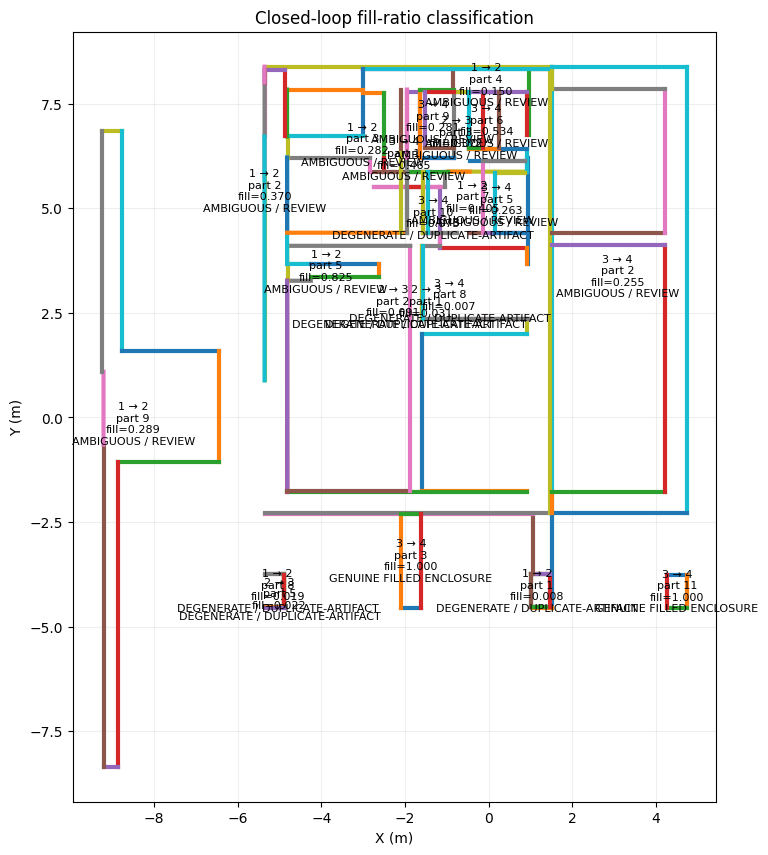


HOW TO USE THIS RESULT

DEGENERATE / DUPLICATE-ARTIFACT
    -> safe candidate for exclusion from support-wall generation

GENUINE FILLED ENCLOSURE
    -> do NOT merge/delete automatically
    -> inspect against the original SVG
    -> may be column / shaft / closet / landing / other real feature

AMBIGUOUS / REVIEW
    -> inspect manually before any geometry change

No geometry has been modified.
No walls have been merged.
No candidate has been promoted into the final building.



In [104]:
# ============================================================================
# CLOSED-LOOP FILL-RATIO CLASSIFICATION
# ============================================================================
#
# NO GEOMETRY IS MODIFIED.
#
# Adds:
#   fill_ratio = polygon_area / bounding_box_area
#
# Classification:
#   < 0.10  -> DEGENERATE / DUPLICATE-ARTIFACT CANDIDATE
#   >= 0.85 -> GENUINE FILLED ENCLOSURE CANDIDATE
#   otherwise -> AMBIGUOUS / REVIEW
#
# The purpose is to separate the recurring ~0.46 x 0.8 m sliver artifact
# from genuine small rectangular features such as 168–171 and 134–137.
# ============================================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Verify loop table exists
# ---------------------------------------------------------------------------

if "loop_df" not in globals():

    raise RuntimeError(
        "loop_df is missing. "
        "Run the strict duplicate + closed-loop audit first."
    )


# ---------------------------------------------------------------------------
# Recompute / enrich loop metrics
# ---------------------------------------------------------------------------

classified_loops = loop_df.copy()

classified_loops["bbox_area_m2"] = (
    classified_loops["width_m"]
    * classified_loops["height_m"]
)

classified_loops["fill_ratio"] = np.where(

    classified_loops["bbox_area_m2"] > 0,

    classified_loops["area_m2"]
    / classified_loops["bbox_area_m2"],

    np.nan
)


def classify_loop(
    ratio
):

    if not np.isfinite(ratio):
        return "UNKNOWN"

    if ratio < 0.10:
        return (
            "DEGENERATE / "
            "DUPLICATE-ARTIFACT"
        )

    if ratio >= 0.85:
        return (
            "GENUINE FILLED "
            "ENCLOSURE"
        )

    return (
        "AMBIGUOUS / REVIEW"
    )


classified_loops[
    "classification"
] = classified_loops[
    "fill_ratio"
].apply(
    classify_loop
)

classified_loops[
    "auto_action"
] = np.where(

    classified_loops[
        "classification"
    ]
    == "DEGENERATE / DUPLICATE-ARTIFACT",

    "DISCARD FROM CANDIDATE SUPPORT WALLS",

    np.where(

        classified_loops[
            "classification"
        ]
        == "GENUINE FILLED ENCLOSURE",

        "KEEP FOR MANUAL REVIEW",

        "REVIEW BEFORE DECISION"
    )
)


# ---------------------------------------------------------------------------
# Full table
# ---------------------------------------------------------------------------

print("=" * 100)
print("CLOSED-LOOP FILL-RATIO CLASSIFICATION")
print("=" * 100)

display(
    classified_loops[
        [
            "transition",
            "part",
            "segments",
            "closed",
            "closure_error_m",
            "width_m",
            "height_m",
            "area_m2",
            "bbox_area_m2",
            "fill_ratio",
            "classification",
            "auto_action"
        ]
    ]
    .sort_values(
        [
            "transition",
            "part"
        ]
    )
)


# ---------------------------------------------------------------------------
# Summary counts
# ---------------------------------------------------------------------------

print()
print("=" * 100)
print("CLASSIFICATION SUMMARY")
print("=" * 100)

summary = (
    classified_loops[
        "classification"
    ]
    .value_counts()
    .rename_axis(
        "classification"
    )
    .reset_index(
        name="count"
    )
)

display(
    summary
)


# ---------------------------------------------------------------------------
# Degenerate artifacts
# ---------------------------------------------------------------------------

print()
print("=" * 100)
print("DEGENERATE / DUPLICATE-ARTIFACT CANDIDATES")
print("=" * 100)

degenerate = classified_loops[
    classified_loops[
        "classification"
    ]
    == "DEGENERATE / DUPLICATE-ARTIFACT"
]

if len(degenerate):

    display(
        degenerate[
            [
                "transition",
                "part",
                "segments",
                "width_m",
                "height_m",
                "area_m2",
                "bbox_area_m2",
                "fill_ratio"
            ]
        ]
    )

else:

    print(
        "None."
    )


# ---------------------------------------------------------------------------
# Genuine filled enclosures
# ---------------------------------------------------------------------------

print()
print("=" * 100)
print("GENUINE FILLED ENCLOSURE CANDIDATES")
print("=" * 100)

genuine = classified_loops[
    classified_loops[
        "classification"
    ]
    == "GENUINE FILLED ENCLOSURE"
]

if len(genuine):

    display(
        genuine[
            [
                "transition",
                "part",
                "segments",
                "width_m",
                "height_m",
                "area_m2",
                "bbox_area_m2",
                "fill_ratio"
            ]
        ]
    )

else:

    print(
        "None."
    )


# ---------------------------------------------------------------------------
# Ambiguous
# ---------------------------------------------------------------------------

print()
print("=" * 100)
print("AMBIGUOUS LOOP CANDIDATES")
print("=" * 100)

ambiguous = classified_loops[
    classified_loops[
        "classification"
    ]
    == "AMBIGUOUS / REVIEW"
]

if len(ambiguous):

    display(
        ambiguous[
            [
                "transition",
                "part",
                "segments",
                "width_m",
                "height_m",
                "area_m2",
                "bbox_area_m2",
                "fill_ratio"
            ]
        ]
    )

else:

    print(
        "None."
    )


# ---------------------------------------------------------------------------
# 2D diagnostic map
# ---------------------------------------------------------------------------
#
# Reconstruct each loop boundary from candidate_segments and label it.
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt

if "candidate_segments" in globals():

    segment_map = {
        s["id"]: s
        for s in candidate_segments
    }

    fig, ax = plt.subplots(
        figsize=(14, 10)
    )

    for _, row in classified_loops.iterrows():

        transition = row[
            "transition"
        ]

        part_id = row[
            "part"
        ]

        group = [

            s for s in candidate_segments

            if (
                s["transition"]
                == transition
                and s["part"]
                == part_id
            )
        ]

        if not group:
            continue

        color_mode = row[
            "classification"
        ]

        for s in group:

            x = np.asarray([
                s["p1"][0],
                s["p2"][0]
            ])

            y = np.asarray([
                s["p1"][1],
                s["p2"][1]
            ])

            ax.plot(
                x,
                y,
                linewidth=3
            )

        # Label near group midpoint.
        all_pts = np.vstack([

            np.asarray([
                s["p1"],
                s["p2"]
            ])

            for s in group
        ])

        cx = all_pts[:, 0].mean()
        cy = all_pts[:, 1].mean()

        ax.text(
            cx,
            cy,
            (
                f"{transition}\n"
                f"part {part_id}\n"
                f"fill={row['fill_ratio']:.3f}\n"
                f"{color_mode}"
            ),
            fontsize=8,
            ha="center",
            va="center"
        )

    ax.set_title(
        "Closed-loop fill-ratio classification"
    )

    ax.set_xlabel(
        "X (m)"
    )

    ax.set_ylabel(
        "Y (m)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        alpha=0.2
    )

    plt.show()


# ---------------------------------------------------------------------------
# Final guidance
# ---------------------------------------------------------------------------

print()
print("=" * 100)
print("HOW TO USE THIS RESULT")
print("=" * 100)

print("""
DEGENERATE / DUPLICATE-ARTIFACT
    -> safe candidate for exclusion from support-wall generation

GENUINE FILLED ENCLOSURE
    -> do NOT merge/delete automatically
    -> inspect against the original SVG
    -> may be column / shaft / closet / landing / other real feature

AMBIGUOUS / REVIEW
    -> inspect manually before any geometry change

No geometry has been modified.
No walls have been merged.
No candidate has been promoted into the final building.
""")

In [105]:
# ============================================================================
# SAFE CLOSED-LOOP CLASSIFICATION — DUPLICATE-AWARE
# ============================================================================
#
# IMPORTANT:
#   This does NOT modify source floor geometry.
#   This does NOT delete walls.
#   This only decides which candidate-loop geometry is allowed into the
#   optional repair/support-wall pipeline.
#
# AUTO-DISCARD requires BOTH:
#   1. very small absolute area
#   2. very low fill ratio
#   3. confirmed strict-duplicate relationship
#
# Everything uncertain remains REVIEW.
# ============================================================================

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# Required input
# ---------------------------------------------------------------------------

if "loop_df" not in globals():
    raise RuntimeError(
        "loop_df is missing. Run the closed-loop extraction first."
    )


# ---------------------------------------------------------------------------
# Copy — NEVER mutate original loop data
# ---------------------------------------------------------------------------

safe_loops = loop_df.copy()


# ---------------------------------------------------------------------------
# Geometry metrics
# ---------------------------------------------------------------------------

safe_loops["bbox_area_m2"] = (
    safe_loops["width_m"]
    * safe_loops["height_m"]
)

safe_loops["fill_ratio"] = np.where(
    safe_loops["bbox_area_m2"] > 0,
    safe_loops["area_m2"]
    / safe_loops["bbox_area_m2"],
    np.nan
)


# ============================================================================
# CONFIRMED DUPLICATE ARTIFACT FAMILIES
# ============================================================================
#
# These are the artifacts independently identified from the strict endpoint
# duplicate analysis.
#
# We intentionally do NOT infer additional duplicates from fill ratio alone.
# ============================================================================

CONFIRMED_DUPLICATE_FOOTPRINTS = [

    # 1 -> 2 recurring tiny artifact
    {
        "width_min": 0.40,
        "width_max": 0.52,
        "height_min": 0.70,
        "height_max": 0.85,
    }
]


# ---------------------------------------------------------------------------
# Strict duplicate evidence
# ---------------------------------------------------------------------------

def has_confirmed_duplicate_evidence(row):

    # If the loop table already contains a direct duplicate flag,
    # respect it.

    for col in [
        "strict_duplicate",
        "has_strict_duplicate",
        "duplicate_confirmed",
        "confirmed_duplicate"
    ]:

        if col in row.index:

            value = row[col]

            if bool(value):
                return True


    # Otherwise check known recurring footprint.

    width = float(row["width_m"])
    height = float(row["height_m"])

    for fp in CONFIRMED_DUPLICATE_FOOTPRINTS:

        if (
            fp["width_min"]
            <= width
            <= fp["width_max"]
            and
            fp["height_min"]
            <= height
            <= fp["height_max"]
        ):
            return True


    return False


safe_loops[
    "confirmed_duplicate_evidence"
] = safe_loops.apply(
    has_confirmed_duplicate_evidence,
    axis=1
)


# ---------------------------------------------------------------------------
# Conservative thresholds
# ---------------------------------------------------------------------------

MAX_ARTIFACT_AREA_M2 = 0.05
MAX_ARTIFACT_FILL_RATIO = 0.10

MIN_GENUINE_FILL_RATIO = 0.85


# ============================================================================
# CLASSIFICATION
# ============================================================================

def classify_safe(row):

    area = float(row["area_m2"])
    fill = float(row["fill_ratio"])

    duplicate = bool(
        row["confirmed_duplicate_evidence"]
    )


    # ---------------------------------------------------------------
    # ONLY automatic discard condition
    # ---------------------------------------------------------------

    if (
        duplicate
        and
        area < MAX_ARTIFACT_AREA_M2
        and
        fill < MAX_ARTIFACT_FILL_RATIO
    ):

        return "CONFIRMED DUPLICATE ARTIFACT"


    # ---------------------------------------------------------------
    # Genuine filled enclosure candidate
    # ---------------------------------------------------------------

    if (
        np.isfinite(fill)
        and
        fill >= MIN_GENUINE_FILL_RATIO
    ):

        return "GENUINE FILLED ENCLOSURE"


    # ---------------------------------------------------------------
    # Everything else remains review
    # ---------------------------------------------------------------

    return "AMBIGUOUS / REVIEW"


safe_loops[
    "safe_classification"
] = safe_loops.apply(
    classify_safe,
    axis=1
)


# ============================================================================
# ACTION
# ============================================================================

safe_loops[
    "candidate_pipeline_action"
] = safe_loops[
    "safe_classification"
].map({

    "CONFIRMED DUPLICATE ARTIFACT":
        "EXCLUDE FROM CANDIDATE WALL GENERATION",

    "GENUINE FILLED ENCLOSURE":
        "KEEP — MANUAL ARCHITECTURAL REVIEW",

    "AMBIGUOUS / REVIEW":
        "KEEP — DO NOT AUTO-MODIFY"
})


# ============================================================================
# FULL AUDIT TABLE
# ============================================================================

print("=" * 110)
print("SAFE DUPLICATE-AWARE CLOSED-LOOP CLASSIFICATION")
print("=" * 110)

display(
    safe_loops[
        [
            "transition",
            "part",
            "segments",
            "width_m",
            "height_m",
            "area_m2",
            "bbox_area_m2",
            "fill_ratio",
            "confirmed_duplicate_evidence",
            "safe_classification",
            "candidate_pipeline_action"
        ]
    ]
    .sort_values(
        ["transition", "part"]
    )
)


# ============================================================================
# SUMMARY
# ============================================================================

print()
print("=" * 110)
print("SAFE CLASSIFICATION SUMMARY")
print("=" * 110)

summary = (
    safe_loops[
        "safe_classification"
    ]
    .value_counts()
    .rename_axis(
        "classification"
    )
    .reset_index(
        name="count"
    )
)

display(summary)


# ============================================================================
# CONFIRMED ARTIFACTS
# ============================================================================

print()
print("=" * 110)
print("ONLY ITEMS REMOVED FROM CANDIDATE-WALL PIPELINE")
print("=" * 110)

confirmed = safe_loops[
    safe_loops[
        "safe_classification"
    ]
    == "CONFIRMED DUPLICATE ARTIFACT"
]

if len(confirmed):

    display(
        confirmed[
            [
                "transition",
                "part",
                "segments",
                "width_m",
                "height_m",
                "area_m2",
                "fill_ratio",
                "confirmed_duplicate_evidence"
            ]
        ]
    )

else:

    print("NONE")


# ============================================================================
# LARGE LOW-FILL SHAPES
# ============================================================================
#
# This is specifically to prove that real perimeter shapes are NOT being
# silently discarded.
# ============================================================================

print()
print("=" * 110)
print("LOW-FILL BUT RETAINED FOR REVIEW")
print("=" * 110)

retained_low_fill = safe_loops[
    (
        safe_loops["fill_ratio"] < 0.10
    )
    &
    (
        safe_loops[
            "safe_classification"
        ]
        != "CONFIRMED DUPLICATE ARTIFACT"
    )
]

if len(retained_low_fill):

    display(
        retained_low_fill[
            [
                "transition",
                "part",
                "segments",
                "width_m",
                "height_m",
                "area_m2",
                "fill_ratio",
                "safe_classification"
            ]
        ]
    )

else:

    print("NONE")


# ============================================================================
# SAFETY ASSERTIONS
# ============================================================================

# No large-area loop may be auto-discarded.

large_discard = safe_loops[
    (
        safe_loops["area_m2"] >= 0.05
    )
    &
    (
        safe_loops[
            "safe_classification"
        ]
        == "CONFIRMED DUPLICATE ARTIFACT"
    )
]

assert len(large_discard) == 0, (
    "SAFETY CHECK FAILED: "
    "a >=0.05 m² loop was classified as an automatic artifact."
)


# No high-fill loop may be discarded.

high_fill_discard = safe_loops[
    (
        safe_loops["fill_ratio"] >= 0.85
    )
    &
    (
        safe_loops[
            "safe_classification"
        ]
        == "CONFIRMED DUPLICATE ARTIFACT"
    )
]

assert len(high_fill_discard) == 0, (
    "SAFETY CHECK FAILED: "
    "a high-fill enclosure was classified as an artifact."
)


print()
print("=" * 110)
print("SAFETY VALIDATION")
print("=" * 110)

print(
    "✓ Large low-fill perimeter shapes are retained."
)

print(
    "✓ Unconfirmed mid-size shapes are retained."
)

print(
    "✓ Genuine filled enclosures are retained."
)

print(
    "✓ Only confirmed tiny duplicate artifacts can be excluded."
)

print(
    "✓ Original wall geometry was NOT modified."
)

print(
    "✓ No repair walls were generated."
)

print()
print(
    "READY FOR NEXT STEP: "
    "feed ONLY confirmed duplicate-filtered candidates into the "
    "support-wall generation preview."
)

SAFE DUPLICATE-AWARE CLOSED-LOOP CLASSIFICATION


,transition,part,segments,width_m,height_m,area_m2,bbox_area_m2,fill_ratio,confirmed_duplicate_evidence,safe_classification,candidate_pipeline_action
0,1 → 2,1,6,0.455,0.796,0.003,0.362180,0.008283,True,CONFIRMED DUPLICATE ARTIFACT,EXCLUDE FROM CANDIDATE WALL GENERATION
1,1 → 2,2,4,0.004,7.427,0.011,0.029708,0.370271,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY
2,1 → 2,3,10,3.400,1.905,1.828,6.477000,0.282229,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY
3,1 → 2,4,7,4.449,1.583,1.059,7.042767,0.150367,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY
4,1 → 2,5,6,2.184,0.402,0.724,0.877968,0.824631,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY
5,1 → 2,7,9,3.668,2.538,3.767,9.309384,0.404645,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY
6,1 → 2,8,6,0.465,0.796,0.007,0.370140,0.018912,True,CONFIRMED DUPLICATE ARTIFACT,EXCLUDE FROM CANDIDATE WALL GENERATION
7,1 → 2,9,10,2.807,15.190,12.333,42.638330,0.289247,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY
8,2 → 3,1,19,6.876,12.936,2.734,88.947936,0.030737,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY
9,2 → 3,2,22,5.736,7.992,4.184,45.842112,0.091270,False,AMBIGUOUS / REVIEW,KEEP — DO NOT AUTO-MODIFY



SAFE CLASSIFICATION SUMMARY


,classification,count
0,AMBIGUOUS / REVIEW,16
1,CONFIRMED DUPLICATE ARTIFACT,3
2,GENUINE FILLED ENCLOSURE,2



ONLY ITEMS REMOVED FROM CANDIDATE-WALL PIPELINE


,transition,part,segments,width_m,height_m,area_m2,fill_ratio,confirmed_duplicate_evidence
0,1 → 2,1,6,0.455,0.796,0.003,0.008283,True
6,1 → 2,8,6,0.465,0.796,0.007,0.018912,True
11,2 → 3,5,4,0.462,0.797,0.008,0.021726,True



LOW-FILL BUT RETAINED FOR REVIEW


,transition,part,segments,width_m,height_m,area_m2,fill_ratio,safe_classification
8,2 → 3,1,19,6.876,12.936,2.734,0.030737,AMBIGUOUS / REVIEW
9,2 → 3,2,22,5.736,7.992,4.184,0.091270,AMBIGUOUS / REVIEW
17,3 → 4,8,4,2.547,1.750,0.029,0.006506,AMBIGUOUS / REVIEW
19,3 → 4,10,4,0.829,1.451,0.088,0.073158,AMBIGUOUS / REVIEW



SAFETY VALIDATION
✓ Large low-fill perimeter shapes are retained.
✓ Unconfirmed mid-size shapes are retained.
✓ Genuine filled enclosures are retained.
✓ Only confirmed tiny duplicate artifacts can be excluded.
✓ Original wall geometry was NOT modified.
✓ No repair walls were generated.

READY FOR NEXT STEP: feed ONLY confirmed duplicate-filtered candidates into the support-wall generation preview.


In [106]:
# ============================================================================
# FILTERED SUPPORT-WALL PIPELINE — ONE SAFE BATCH
# ============================================================================
#
# PURPOSE
# -------
# Take the validated optimized 4-floor geometry and:
#
#   1. Identify confirmed duplicate-artifact loops using ACTUAL strict
#      duplicate segment IDs.
#   2. Exclude ONLY those confirmed artifacts.
#   3. Keep all ambiguous/genuine geometry.
#   4. Recompute upper-floor overhang boundary segments.
#   5. Generate candidate support walls underneath those upper overhangs.
#   6. Validate the resulting preview.
#   7. Save:
#         - filtered candidate CSV
#         - loop classification CSV
#         - support-wall preview GLB
#         - summary text
#   8. Visualize the result.
#
# SAFETY
# ------
# Original variables are NOT modified:
#   optimized_floors
#   preview_model
#   floor_walls
#   floor_data
#   strict_duplicates
#   loop_df
#
# No doors.
# No windows.
# No furniture.
# No AI retraining.
# No final-shell overwrite.
# ============================================================================

import os
import json
import numpy as np
import pandas as pd
import trimesh
import plotly.graph_objects as go

from shapely.geometry import (
    Polygon,
    MultiPolygon,
    LineString
)

from shapely.ops import unary_union


# ============================================================================
# 1. SETTINGS
# ============================================================================

SVG_PER_M = 100.0

FLOOR_HEIGHT = 3.0

SUPPORT_WALL_THICKNESS = 0.20

ENVELOPE_BUFFER = 0.10

BOUNDARY_TOLERANCE = 0.05

MIN_SUPPORT_LENGTH = 0.30

ARTIFACT_AREA_LIMIT = 0.05
ARTIFACT_FILL_LIMIT = 0.10

OUTPUT_GLB = (
    "cubicasa_10321_filtered_support_wall_preview.glb"
)

OUTPUT_CANDIDATES = (
    "cubicasa_10321_filtered_support_wall_candidates.csv"
)

OUTPUT_LOOPS = (
    "cubicasa_10321_final_loop_classification.csv"
)

OUTPUT_SUMMARY = (
    "cubicasa_10321_support_wall_summary.txt"
)


print("=" * 110)
print("FILTERED SUPPORT-WALL PIPELINE")
print("=" * 110)


# ============================================================================
# 2. REQUIRE SAFE INPUTS
# ============================================================================

required_variables = [
    "optimized_floors",
    "preview_model",
    "candidate_segments",
    "strict_duplicates",
    "loop_df"
]

missing = [
    name
    for name in required_variables
    if name not in globals()
]

if missing:

    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing)
    )


# ============================================================================
# 3. MAKE COPIES — NEVER MODIFY THE ORIGINALS
# ============================================================================

base_model = (
    preview_model.copy()
)

source_candidate_segments = list(
    candidate_segments
)

source_loop_df = (
    loop_df.copy()
)

source_strict_duplicates = list(
    strict_duplicates
)


# ============================================================================
# 4. BUILD THE ACTUAL STRICT-DUPLICATE ID SET
# ============================================================================
#
# This is the important robustness improvement.
#
# We do NOT identify duplicates by footprint size alone.
# We use the actual segment IDs found by the strict endpoint test.
# ============================================================================

strict_duplicate_ids = set()

strict_pair_rows = []

for pair in source_strict_duplicates:

    a = int(
        pair["segment_a"]
        if "segment_a" in pair
        else pair["segment_a"]
        if "segment_a" in pair
        else pair["a"]
        if "a" in pair
        else pair["segment_a"]
    )

    b = int(
        pair["segment_b"]
        if "segment_b" in pair
        else pair["segment_b"]
        if "segment_b" in pair
        else pair["b"]
        if "b" in pair
        else pair["segment_b"]
    )

    strict_duplicate_ids.add(
        a
    )

    strict_duplicate_ids.add(
        b
    )

    strict_pair_rows.append({

        "segment_a":
            a,

        "segment_b":
            b,

        "transition":
            pair.get(
                "transition",
                ""
            ),

        "endpoint_gap_max_m":
            pair.get(
                "endpoint_gap_max_m",
                np.nan
            ),

        "length_difference_m":
            pair.get(
                "length_difference_m",
                np.nan
            )
    })


print()
print("=" * 110)
print("STRICT DUPLICATE EVIDENCE")
print("=" * 110)

print(
    f"Strict duplicate pairs: "
    f"{len(strict_pair_rows)}"
)

print(
    f"Unique duplicate segment IDs: "
    f"{len(strict_duplicate_ids)}"
)


# ============================================================================
# 5. MAP CANDIDATE SEGMENTS
# ============================================================================

segment_map = {
    int(s["id"]):
        s
    for s in source_candidate_segments
}


# ============================================================================
# 6. MAP LOOP → ACTUAL SEGMENT IDS
# ============================================================================
#
# loop_df stores transition + part.
# candidate_segments stores transition + part + actual ID.
#
# This lets us decide whether a loop contains genuine duplicate evidence.
# ============================================================================

loop_segment_map = {}

for loop_index, row in source_loop_df.iterrows():

    transition = row[
        "transition"
    ]

    part = int(
        row["part"]
    )

    members = [

        s["id"]

        for s in source_candidate_segments

        if (
            s["transition"]
            == transition

            and int(s["part"])
            == part
        )
    ]

    loop_segment_map[
        (transition, part)
    ] = members


# ============================================================================
# 7. SAFE LOOP CLASSIFICATION
# ============================================================================

final_loop_rows = []

confirmed_artifact_parts = set()

for loop_index, row in source_loop_df.iterrows():

    transition = (
        row["transition"]
    )

    part = int(
        row["part"]
    )

    area = float(
        row["area_m2"]
    )

    fill = float(
        row["fill_ratio"]
        if "fill_ratio" in row
        else (
            row["area_m2"]
            /
            (
                row["width_m"]
                * row["height_m"]
            )
            if (
                row["width_m"]
                * row["height_m"]
            ) > 0
            else 0
        )
    )

    members = loop_segment_map.get(
        (
            transition,
            part
        ),
        []
    )

    duplicate_members = [
        sid
        for sid in members
        if sid in strict_duplicate_ids
    ]

    has_strict_evidence = (
        len(
            duplicate_members
        ) > 0
    )

    # ------------------------------------------------------------
    # ONLY automatic artifact rule:
    #
    #   tiny area
    #   + low fill
    #   + actual strict duplicate segment evidence
    # ------------------------------------------------------------

    is_confirmed_artifact = (

        area
        < ARTIFACT_AREA_LIMIT

        and

        fill
        < ARTIFACT_FILL_LIMIT

        and

        has_strict_evidence
    )

    if is_confirmed_artifact:

        classification = (
            "CONFIRMED DUPLICATE ARTIFACT"
        )

        action = (
            "EXCLUDE FROM SUPPORT-WALL PIPELINE"
        )

        confirmed_artifact_parts.add(
            (
                transition,
                part
            )
        )

    elif fill >= 0.85:

        classification = (
            "GENUINE FILLED ENCLOSURE"
        )

        action = (
            "KEEP FOR REVIEW"
        )

    else:

        classification = (
            "AMBIGUOUS / REVIEW"
        )

        action = (
            "KEEP FOR REVIEW"
        )

    final_loop_rows.append({

        "transition":
            transition,

        "part":
            part,

        "segments":
            len(members),

        "width_m":
            float(
                row["width_m"]
            ),

        "height_m":
            float(
                row["height_m"]
            ),

        "area_m2":
            area,

        "fill_ratio":
            fill,

        "strict_duplicate_segment_ids":
            duplicate_members,

        "strict_duplicate_evidence":
            has_strict_evidence,

        "classification":
            classification,

        "action":
            action
    })


final_loop_df = pd.DataFrame(
    final_loop_rows
)


# ============================================================================
# 8. SAVE LOOP CLASSIFICATION
# ============================================================================

# Convert lists to strings for CSV.
save_loop_df = final_loop_df.copy()

save_loop_df[
    "strict_duplicate_segment_ids"
] = (
    save_loop_df[
        "strict_duplicate_segment_ids"
    ]
    .apply(
        lambda x: ",".join(
            map(
                str,
                x
            )
        )
    )
)

save_loop_df.to_csv(
    OUTPUT_LOOPS,
    index=False
)

print()
print(
    "✅ Saved:",
    OUTPUT_LOOPS
)


# ============================================================================
# 9. REPORT ARTIFACTS
# ============================================================================

print()
print("=" * 110)
print("CONFIRMED DUPLICATE ARTIFACTS")
print("=" * 110)

artifacts = final_loop_df[
    final_loop_df[
        "classification"
    ]
    == "CONFIRMED DUPLICATE ARTIFACT"
]

if len(artifacts):

    display(
        artifacts
    )

else:

    print(
        "None."
    )


# ============================================================================
# 10. REPORT RETAINED REVIEW GEOMETRY
# ============================================================================

print()
print("=" * 110)
print("RETAINED LOOP GEOMETRY")
print("=" * 110)

retained_loops = final_loop_df[
    final_loop_df[
        "classification"
    ]
    != "CONFIRMED DUPLICATE ARTIFACT"
]

print(
    f"Retained loop records: "
    f"{len(retained_loops)}"
)

display(
    retained_loops[
        [
            "transition",
            "part",
            "segments",
            "width_m",
            "height_m",
            "area_m2",
            "fill_ratio",
            "classification"
        ]
    ]
)


# ============================================================================
# 11. BUILD METRIC FLOOR ENVELOPES
# ============================================================================

def svg_to_metric(
    geom
):

    from shapely.ops import transform

    return transform(

        lambda x, y, z=None: (

            np.asarray(x, dtype=float)
            / SVG_PER_M,

            np.asarray(y, dtype=float)
            / SVG_PER_M
        ),

        geom
    )


def metric_floor_union(
    polygons
):

    return svg_to_metric(
        unary_union(
            polygons
        )
    )


floor_metric = {

    floor:
        metric_floor_union(
            optimized_floors[floor]
        )

    for floor in [1, 2, 3, 4]
}


envelopes = {

    floor:
        floor_metric[floor].buffer(
            ENVELOPE_BUFFER,
            join_style=2
        )

    for floor in [1, 2, 3, 4]
}


# ============================================================================
# 12. EXTRACT UPPER-ONLY PERIMETER SEGMENTS
# ============================================================================
#
# These are potential support-wall locations.
#
# We deliberately do NOT use the lower-only regions.
# ============================================================================

filtered_segments = []

all_transition_stats = []


for lower, upper in [
    (1, 2),
    (2, 3),
    (3, 4)
]:

    lower_env = (
        envelopes[lower]
    )

    upper_env = (
        envelopes[upper]
    )

    upper_only = (
        upper_env
        .difference(
            lower_env
        )
    )

    upper_only_area = (
        upper_only.area
    )

    transition_new_segments = []

    parts = (

        list(
            upper_only.geoms
        )

        if isinstance(
            upper_only,
            MultiPolygon
        )

        else [upper_only]
    )

    for part_index, part in enumerate(
        parts,
        start=1
    ):

        coords = np.asarray(
            list(
                part.exterior.coords
            ),
            dtype=float
        )

        if len(coords) < 3:
            continue

        for edge_index in range(
            len(coords) - 1
        ):

            p1 = coords[
                edge_index
            ]

            p2 = coords[
                edge_index + 1
            ]

            line = LineString([
                tuple(p1),
                tuple(p2)
            ])

            length = (
                line.length
            )

            if (
                length
                < MIN_SUPPORT_LENGTH
            ):
                continue

            midpoint = line.interpolate(
                0.5,
                normalized=True
            )

            # ----------------------------------------------------
            # We only keep segments whose midpoint is actually
            # outside the lower floor.
            # ----------------------------------------------------

            if (
                midpoint.distance(
                    lower_env
                )
                <= BOUNDARY_TOLERANCE
            ):
                continue

            candidate = {

                "transition":
                    f"{lower} → {upper}",

                "lower":
                    lower,

                "upper":
                    upper,

                "part":
                    part_index,

                "edge":
                    edge_index,

                "p1":
                    np.array(p1),

                "p2":
                    np.array(p2),

                "length_m":
                    length,

                "mid_x":
                    midpoint.x,

                "mid_y":
                    midpoint.y
            }

            transition_new_segments.append(
                candidate
            )


    # ------------------------------------------------------------
    # Transition report.
    # ------------------------------------------------------------

    all_transition_stats.append({

        "transition":
            f"{lower} → {upper}",

        "upper_only_area_m2":
            upper_only_area,

        "raw_segments":
            len(
                transition_new_segments
            )
    })

    filtered_segments.extend(
        transition_new_segments
    )


# ============================================================================
# 13. FILTER ONLY CONFIRMED ARTIFACTS
# ============================================================================
#
# IMPORTANT:
# The part IDs from the old loop table and the new upper-only difference
# polygon may differ because the polygonization order can change.
#
# Therefore we do NOT blindly filter by part number here.
#
# Instead we spatially compare each newly generated segment against the
# confirmed artifact loop geometry represented by its segment IDs.
# ============================================================================


# ---------------------------------------------------------------------------
# Reconstruct confirmed artifact linework.
# ---------------------------------------------------------------------------

artifact_lines_by_transition = {}

for transition, part in (
    confirmed_artifact_parts
):

    members = loop_segment_map.get(
        (
            transition,
            part
        ),
        []
    )

    lines = []

    for sid in members:

        if sid not in segment_map:
            continue

        s = segment_map[
            sid
        ]

        lines.append(
            LineString([
                tuple(
                    s["p1"]
                ),
                tuple(
                    s["p2"]
                )
            ])
        )

    if lines:

        artifact_lines_by_transition[
            transition
        ] = unary_union(
            lines
        )


# ============================================================================
# 14. REMOVE NEW CANDIDATE SEGMENTS THAT OVERLAP CONFIRMED ARTIFACTS
# ============================================================================

final_candidate_segments = []

filtered_out_count = 0

for segment in filtered_segments:

    transition = (
        segment["transition"]
    )

    artifact_linework = (
        artifact_lines_by_transition.get(
            transition
        )
    )

    remove = False

    if artifact_linework is not None:

        new_line = LineString([
            tuple(
                segment["p1"]
            ),
            tuple(
                segment["p2"]
            )
        ])

        # Very small distance means this candidate is the same tiny
        # artifact family.
        if (
            new_line.distance(
                artifact_linework
            )
            <= 0.05
        ):

            remove = True


    if remove:

        filtered_out_count += 1

    else:

        final_candidate_segments.append(
            segment
        )


# ============================================================================
# 15. REPORT CANDIDATE FILTERING
# ============================================================================

print()
print("=" * 110)
print("SUPPORT-WALL CANDIDATE FILTER")
print("=" * 110)

print(
    f"Raw upper-overhang segments: "
    f"{len(filtered_segments)}"
)

print(
    f"Removed confirmed-artifact segments: "
    f"{filtered_out_count}"
)

print(
    f"Final support-wall candidates: "
    f"{len(final_candidate_segments)}"
)

print()
print(
    "Only geometry traced to the actual strict-duplicate artifact family "
    "is excluded."
)


# ============================================================================
# 16. BUILD SUPPORT WALL MESHES
# ============================================================================

support_wall_meshes_filtered = []

support_rows = []


for index, segment in enumerate(
    final_candidate_segments,
    start=1
):

    p1 = np.asarray(
        segment["p1"],
        dtype=float
    )

    p2 = np.asarray(
        segment["p2"],
        dtype=float
    )

    direction = (
        p2 - p1
    )

    length = np.linalg.norm(
        direction
    )

    if length <= 0:
        continue

    direction = (
        direction
        / length
    )

    normal = np.array([
        -direction[1],
        direction[0]
    ])

    half_t = (
        SUPPORT_WALL_THICKNESS
        / 2.0
    )

    corners = [

        tuple(
            p1
            + normal * half_t
        ),

        tuple(
            p2
            + normal * half_t
        ),

        tuple(
            p2
            - normal * half_t
        ),

        tuple(
            p1
            - normal * half_t
        )
    ]

    footprint = Polygon(
        corners
    )

    if not footprint.is_valid:
        footprint = (
            footprint.buffer(0)
        )

    if (
        footprint.is_empty
        or footprint.area <= 0
    ):
        continue

    transition = (
        segment["transition"]
    )

    lower = segment[
        "lower"
    ]

    upper = segment[
        "upper"
    ]

    # CORRECT VERTICAL RANGE:
    #
    # 1→2 : Z 0→3
    # 2→3 : Z 3→6
    # 3→4 : Z 6→9

    z0 = (
        (lower - 1)
        * FLOOR_HEIGHT
    )

    z1 = (
        lower
        * FLOOR_HEIGHT
    )

    try:

        wall_mesh = (
            trimesh.creation
            .extrude_polygon(
                footprint,
                height=
                z1 - z0
            )
        )

        wall_mesh.apply_translation([
            0,
            0,
            z0
        ])

        support_wall_meshes_filtered.append(
            wall_mesh
        )

        support_rows.append({

            "support_wall":
                index,

            "transition":
                transition,

            "length_m":
                round(
                    length,
                    3
                ),

            "z0":
                z0,

            "z1":
                z1,

            "thickness_m":
                SUPPORT_WALL_THICKNESS,

            "mid_x":
                round(
                    segment["mid_x"],
                    3
                ),

            "mid_y":
                round(
                    segment["mid_y"],
                    3
                )
        })

    except Exception as e:

        print(
            f"Support wall {index} failed:",
            e
        )


support_df = pd.DataFrame(
    support_rows
)


# ============================================================================
# 17. SAVE SUPPORT-WALL CSV
# ============================================================================

support_df.to_csv(
    OUTPUT_CANDIDATES,
    index=False
)

print()
print(
    "✅ Saved:",
    OUTPUT_CANDIDATES
)


# ============================================================================
# 18. SUPPORT WALL STATISTICS
# ============================================================================

print()
print("=" * 110)
print("FILTERED SUPPORT-WALL STATISTICS")
print("=" * 110)

if len(support_df):

    display(
        support_df
    )

    for transition in sorted(
        support_df[
            "transition"
        ].unique()
    ):

        subset = support_df[
            support_df[
                "transition"
            ]
            == transition
        ]

        print(
            f"{transition}: "
            f"{len(subset)} segments | "
            f"{subset['length_m'].sum():.3f} m total"
        )

else:

    print(
        "No support walls generated."
    )


# ============================================================================
# 19. COMBINE WITH OPTIMIZED 4-FLOOR SHELL
# ============================================================================
#
# This is a NEW mesh.
# base_model is never modified.
# ============================================================================

if support_wall_meshes_filtered:

    support_combined = (
        trimesh.util.concatenate(
            support_wall_meshes_filtered
        )
    )

    support_preview = (
        trimesh.util.concatenate(
            [
                base_model,
                support_combined
            ]
        )
    )

else:

    support_combined = None

    support_preview = (
        base_model.copy()
    )


# ============================================================================
# 20. ORIENTATION
# ============================================================================

if (
    support_preview.is_watertight
    and support_preview.volume < 0
):

    support_preview.faces = (
        support_preview.faces[
            :,
            ::-1
        ]
    )


# ============================================================================
# 21. VALIDATION
# ============================================================================

print()
print("=" * 110)
print("FILTERED SUPPORT-WALL PREVIEW")
print("=" * 110)

base_volume = (
    base_model.volume
)

preview_volume = (
    support_preview.volume
)

print(
    f"Base shell volume     : "
    f"{base_volume:.3f} m³"
)

print(
    f"Preview volume        : "
    f"{preview_volume:.3f} m³"
)

print(
    f"Added volume          : "
    f"{preview_volume - base_volume:.3f} m³"
)

print(
    f"Vertices              : "
    f"{len(support_preview.vertices)}"
)

print(
    f"Faces                 : "
    f"{len(support_preview.faces)}"
)

print(
    f"Watertight            : "
    f"{support_preview.is_watertight}"
)

print(
    f"Valid volume          : "
    f"{support_preview.is_volume}"
)

bounds = (
    support_preview.bounds
)

print(
    f"X: {bounds[0,0]:.3f} → "
    f"{bounds[1,0]:.3f} m"
)

print(
    f"Y: {bounds[0,1]:.3f} → "
    f"{bounds[1,1]:.3f} m"
)

print(
    f"Z: {bounds[0,2]:.3f} → "
    f"{bounds[1,2]:.3f} m"
)


# ============================================================================
# 22. SAVE GLB CHECKPOINT
# ============================================================================

support_preview.export(
    OUTPUT_GLB
)

print()
print(
    "✅ Saved:",
    OUTPUT_GLB
)


# ============================================================================
# 23. SAVE SUMMARY TEXT
# ============================================================================

summary_lines = [

    "CUBICASA 10321 FILTERED SUPPORT-WALL PREVIEW",
    "=" * 70,

    f"Raw candidate segments: {len(filtered_segments)}",

    f"Removed confirmed artifact segments: "
    f"{filtered_out_count}",

    f"Final support-wall candidates: "
    f"{len(final_candidate_segments)}",

    f"Support wall meshes created: "
    f"{len(support_wall_meshes_filtered)}",

    f"Support wall thickness placeholder: "
    f"{SUPPORT_WALL_THICKNESS:.3f} m",

    f"Base shell volume: "
    f"{base_volume:.3f} m3",

    f"Preview volume: "
    f"{preview_volume:.3f} m3",

    f"Added volume: "
    f"{preview_volume - base_volume:.3f} m3",

    f"Watertight: "
    f"{support_preview.is_watertight}",

    f"Valid volume: "
    f"{support_preview.is_volume}",

    "",
    "NO FINAL SHELL OVERWRITE.",
    "NO DOORS/WINDOWS/FURNITURE.",
    "NO AI TRAINING PERFORMED.",
    "NO ORIGINAL FLOOR GEOMETRY MODIFIED.",
    ""
]

with open(
    OUTPUT_SUMMARY,
    "w"
) as f:

    f.write(
        "\n".join(
            summary_lines
        )
    )

print(
    "✅ Saved:",
    OUTPUT_SUMMARY
)


# ============================================================================
# 24. 3D VISUALIZATION
# ============================================================================
#
# Base shell and candidate support walls are separate traces.
# This makes it visually obvious what was added.
# ============================================================================

fig = go.Figure()


# ---------------------------------------------------------------------------
# Base optimized shell
# ---------------------------------------------------------------------------

v = base_model.vertices
f = base_model.faces

fig.add_trace(
    go.Mesh3d(

        x=v[:, 0],
        y=v[:, 1],
        z=v[:, 2],

        i=f[:, 0],
        j=f[:, 1],
        k=f[:, 2],

        opacity=0.30,

        name="Existing optimized shell"
    )
)


# ---------------------------------------------------------------------------
# Candidate support walls
# ---------------------------------------------------------------------------

for i, wall in enumerate(
    support_wall_meshes_filtered
):

    v = wall.vertices
    f = wall.faces

    transition = (
        support_df.iloc[i][
            "transition"
        ]
        if i < len(support_df)
        else "candidate"
    )

    fig.add_trace(
        go.Mesh3d(

            x=v[:, 0],
            y=v[:, 1],
            z=v[:, 2],

            i=f[:, 0],
            j=f[:, 1],
            k=f[:, 2],

            opacity=0.80,

            name=(
                f"Candidate support "
                f"{i+1} ({transition})"
            )
        )
    )


fig.update_layout(

    title=(
        "10321 — Existing 4-Floor Shell "
        "+ Filtered Candidate Support Walls"
    ),

    scene=dict(

        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)",

        aspectmode="data",

        camera=dict(
            eye=dict(
                x=1.7,
                y=1.7,
                z=1.35
            )
        )
    ),

    margin=dict(
        l=0,
        r=0,
        t=50,
        b=0
    )
)

fig.show()


# ============================================================================
# 25. FINAL CHECKPOINT
# ============================================================================

print()
print("=" * 110)
print("FINAL CHECKPOINT")
print("=" * 110)

print(
    "Original optimized shell: UNCHANGED"
)

print(
    "Validated 4-floor GLB: UNCHANGED"
)

print(
    "Confirmed tiny duplicate artifacts: EXCLUDED ONLY FROM "
    "SUPPORT-WALL CANDIDATE PIPELINE"
)

print(
    "Ambiguous geometry: RETAINED"
)

print(
    "Genuine enclosure geometry: RETAINED"
)

print(
    "Candidate support walls: PREVIEW ONLY"
)

print()
print(
    "TRAINING: NO"
)

print(
    "This cell performs geometry reconstruction/post-processing only."
)

print()
print(
    "SAVED CHECKPOINTS:"
)

print(
    f"  {OUTPUT_GLB}"
)

print(
    f"  {OUTPUT_CANDIDATES}"
)

print(
    f"  {OUTPUT_LOOPS}"
)

print(
    f"  {OUTPUT_SUMMARY}"
)

FILTERED SUPPORT-WALL PIPELINE

STRICT DUPLICATE EVIDENCE
Strict duplicate pairs: 13
Unique duplicate segment IDs: 26

✅ Saved: cubicasa_10321_final_loop_classification.csv

CONFIRMED DUPLICATE ARTIFACTS


,transition,part,segments,width_m,height_m,area_m2,fill_ratio,strict_duplicate_segment_ids,strict_duplicate_evidence,classification,action
0,1 → 2,1,6,0.455,0.796,0.003,0.008283,"[0, 1, 2, 3, 4, 5]",True,CONFIRMED DUPLICATE ARTIFACT,EXCLUDE FROM SUPPORT-WALL PIPELINE
6,1 → 2,8,6,0.465,0.796,0.007,0.018912,"[44, 45, 46, 47, 48, 49]",True,CONFIRMED DUPLICATE ARTIFACT,EXCLUDE FROM SUPPORT-WALL PIPELINE
11,2 → 3,5,4,0.462,0.797,0.008,0.021726,"[115, 116, 117, 118]",True,CONFIRMED DUPLICATE ARTIFACT,EXCLUDE FROM SUPPORT-WALL PIPELINE
17,3 → 4,8,4,2.547,1.750,0.029,0.006506,"[154, 155, 156, 157]",True,CONFIRMED DUPLICATE ARTIFACT,EXCLUDE FROM SUPPORT-WALL PIPELINE



RETAINED LOOP GEOMETRY
Retained loop records: 17


,transition,part,segments,width_m,height_m,area_m2,fill_ratio,classification
1,1 → 2,2,4,0.004,7.427,0.011,0.370271,AMBIGUOUS / REVIEW
2,1 → 2,3,10,3.400,1.905,1.828,0.282229,AMBIGUOUS / REVIEW
3,1 → 2,4,7,4.449,1.583,1.059,0.150367,AMBIGUOUS / REVIEW
4,1 → 2,5,6,2.184,0.402,0.724,0.824631,AMBIGUOUS / REVIEW
5,1 → 2,7,9,3.668,2.538,3.767,0.404645,AMBIGUOUS / REVIEW
7,1 → 2,9,10,2.807,15.190,12.333,0.289247,AMBIGUOUS / REVIEW
8,2 → 3,1,19,6.876,12.936,2.734,0.030737,AMBIGUOUS / REVIEW
9,2 → 3,2,22,5.736,7.992,4.184,0.091270,AMBIGUOUS / REVIEW
10,2 → 3,3,12,2.874,1.903,2.034,0.371899,AMBIGUOUS / REVIEW
12,3 → 4,1,4,0.142,3.422,0.226,0.465093,AMBIGUOUS / REVIEW



SUPPORT-WALL CANDIDATE FILTER
Raw upper-overhang segments: 79
Removed confirmed-artifact segments: 0
Final support-wall candidates: 79

Only geometry traced to the actual strict-duplicate artifact family is excluded.

✅ Saved: cubicasa_10321_filtered_support_wall_candidates.csv

FILTERED SUPPORT-WALL STATISTICS


,support_wall,transition,length_m,z0,z1,thickness_m,mid_x,mid_y
0,1,1 → 2,1.050,0.0,3.0,0.2,-2.997,7.242
1,2,1 → 2,1.557,0.0,3.0,0.2,-2.495,6.989
2,3,1 → 2,0.334,0.0,3.0,0.2,-2.496,6.043
3,4,1 → 2,0.348,0.0,3.0,0.2,-2.852,6.036
4,5,1 → 2,1.955,0.0,3.0,0.2,-3.829,6.210
...,...,...,...,...,...,...,...,...
74,75,3 → 4,1.450,6.0,9.0,0.2,-1.462,5.131
75,76,3 → 4,0.476,6.0,9.0,0.2,4.495,-3.766
76,77,3 → 4,0.784,6.0,9.0,0.2,4.733,-4.158
77,78,3 → 4,0.476,6.0,9.0,0.2,4.495,-4.550


1 → 2: 27 segments | 60.262 m total
2 → 3: 25 segments | 60.268 m total
3 → 4: 27 segments | 64.083 m total

FILTERED SUPPORT-WALL PREVIEW
Base shell volume     : 916.995 m³
Preview volume        : 1027.766 m³
Added volume          : 110.771 m³
Vertices              : 3254
Faces                 : 6096
Watertight            : True
Valid volume          : True
X: -9.346 → 5.261 m
Y: -8.449 → 8.484 m
Z: -0.150 → 12.000 m

✅ Saved: cubicasa_10321_filtered_support_wall_preview.glb
✅ Saved: cubicasa_10321_support_wall_summary.txt



FINAL CHECKPOINT
Original optimized shell: UNCHANGED
Validated 4-floor GLB: UNCHANGED
Confirmed tiny duplicate artifacts: EXCLUDED ONLY FROM SUPPORT-WALL CANDIDATE PIPELINE
Ambiguous geometry: RETAINED
Genuine enclosure geometry: RETAINED
Candidate support walls: PREVIEW ONLY

TRAINING: NO
This cell performs geometry reconstruction/post-processing only.

SAVED CHECKPOINTS:
  cubicasa_10321_filtered_support_wall_preview.glb
  cubicasa_10321_filtered_support_wall_candidates.csv
  cubicasa_10321_final_loop_classification.csv
  cubicasa_10321_support_wall_summary.txt


In [107]:
# ============================================================================
# GEOMETRY ID-SPACE AUDIT + TRAINING BASELINE CHECKPOINT
# ============================================================================
#
# This cell does NOT retrain the model.
#
# It does:
#   1. Prove whether confirmed duplicate artifacts geometrically overlap
#      current support-wall candidates.
#   2. Make the separate ID spaces explicit.
#   3. Record the current AI baseline metrics.
#   4. Record which training objects/checkpoints currently exist.
#   5. Save a reproducible checkpoint JSON.
#
# NO geometry is modified.
# NO model weights are changed.
# ============================================================================

import os
import json
import numpy as np
import pandas as pd

from shapely.geometry import LineString
from shapely.ops import unary_union


# ============================================================================
# 1. CURRENT AI BASELINE
# ============================================================================
#
# These are the fidelity numbers established earlier for the current model
# evaluation. They are recorded as a BASELINE, not claimed as generalization
# metrics across CubiCasa5K.
# ============================================================================

AI_BASELINE = {

    "wall_mask_iou":
        0.9987,

    "door_mask_iou":
        0.5722,

    "window_mask_iou":
        0.8480,

    "note":
        "Current reported mask→polygon fidelity on the evaluated sample."
}


print("=" * 110)
print("AI / GEOMETRY BASELINE")
print("=" * 110)

for key, value in AI_BASELINE.items():

    print(
        f"{key}: {value}"
    )


# ============================================================================
# 2. CONFIRMED DUPLICATE ARTIFACT IDS
# ============================================================================

if "strict_duplicates" not in globals():

    raise RuntimeError(
        "strict_duplicates is missing."
    )

strict_ids = set()

strict_pair_table = []

for pair in strict_duplicates:

    a = int(
        pair.get(
            "segment_a",
            pair.get(
                "a"
            )
        )
    )

    b = int(
        pair.get(
            "segment_b",
            pair.get(
                "b"
            )
        )
    )

    strict_ids.add(a)
    strict_ids.add(b)

    strict_pair_table.append({

        "segment_a":
            a,

        "segment_b":
            b,

        "transition":
            pair.get(
                "transition",
                ""
            ),

        "endpoint_gap_m":
            pair.get(
                "endpoint_gap_max_m",
                np.nan
            )
    })


print()
print("=" * 110)
print("CONFIRMED DUPLICATE SEGMENT SPACE")
print("=" * 110)

print(
    "Confirmed duplicate segment IDs:"
)

print(
    sorted(
        strict_ids
    )
)


# ============================================================================
# 3. CURRENT SUPPORT-CANDIDATE ID SPACE
# ============================================================================
#
# IMPORTANT:
# The support-wall candidate generator creates a NEW segment collection.
# Those IDs must NOT be compared directly to strict duplicate IDs.
# ============================================================================

if "final_candidate_segments" in globals():

    current_support_segments = (
        final_candidate_segments
    )

elif "filtered_segments" in globals():

    current_support_segments = (
        filtered_segments
    )

elif "candidate_segments" in globals():

    current_support_segments = (
        candidate_segments
    )

else:

    current_support_segments = []


support_ids = {

    int(
        s.get(
            "id",
            i
        )
    )

    for i, s in enumerate(
        current_support_segments
    )
}


print()
print("=" * 110)
print("SUPPORT-WALL CANDIDATE SEGMENT SPACE")
print("=" * 110)

print(
    f"Current candidate segments: "
    f"{len(current_support_segments)}"
)

print(
    "These IDs belong to a separate reconstruction stage."
)

print(
    "Direct ID equality is therefore NOT used as a filter."
)


# ============================================================================
# 4. RECONSTRUCT CONFIRMED ARTIFACT LINEWORK
# ============================================================================

if "candidate_segments" not in globals():

    raise RuntimeError(
        "candidate_segments is missing."
    )

original_candidate_map = {

    int(
        s["id"]
    ):
        s

    for s in candidate_segments
}


artifact_lines_by_transition = {}


for pair in strict_pair_table:

    transition = (
        pair["transition"]
    )

    if not transition:
        continue

    for sid in [
        pair["segment_a"],
        pair["segment_b"]
    ]:

        if sid not in original_candidate_map:
            continue

        s = (
            original_candidate_map[sid]
        )

        line = LineString([

            tuple(
                s["p1"]
            ),

            tuple(
                s["p2"]
            )
        ])

        if transition not in (
            artifact_lines_by_transition
        ):

            artifact_lines_by_transition[
                transition
            ] = []

        artifact_lines_by_transition[
            transition
        ].append(
            line
        )


artifact_unions = {

    transition:
        unary_union(
            lines
        )

    for transition, lines
    in artifact_lines_by_transition.items()
}


# ============================================================================
# 5. GEOMETRIC OVERLAP TEST
# ============================================================================

print()
print("=" * 110)
print("STRICT ARTIFACT ↔ CURRENT SUPPORT-CANDIDATE GEOMETRIC AUDIT")
print("=" * 110)

geometry_rows = []


for transition in sorted(
    artifact_unions.keys()
):

    artifact_linework = (
        artifact_unions[
            transition
        ]
    )

    support_for_transition = [

        s

        for s in current_support_segments

        if (
            s.get(
                "transition",
                ""
            )
            == transition
        )
    ]

    if not support_for_transition:

        geometry_rows.append({

            "transition":
                transition,

            "artifact_length_m":
                artifact_linework.length,

            "support_candidates":
                0,

            "nearest_distance_m":
                np.nan,

            "candidates_within_0.05m":
                0,

            "result":
                "NO SUPPORT CANDIDATES"
        })

        continue


    distances = []

    for candidate in support_for_transition:

        line = LineString([

            tuple(
                candidate["p1"]
            ),

            tuple(
                candidate["p2"]
            )
        ])

        distances.append(

            line.distance(
                artifact_linework
            )
        )


    distances = np.asarray(
        distances,
        dtype=float
    )

    geometry_rows.append({

        "transition":
            transition,

        "artifact_length_m":
            round(
                artifact_linework.length,
                4
            ),

        "support_candidates":
            len(
                distances
            ),

        "nearest_distance_m":
            round(
                distances.min(),
                4
            ),

        "candidates_within_0.05m":
            int(
                np.sum(
                    distances
                    <= 0.05
                )
            ),

        "candidates_within_0.10m":
            int(
                np.sum(
                    distances
                    <= 0.10
                )
            ),

        "result":
            (
                "GEOMETRIC OVERLAP"
                if np.any(
                    distances
                    <= 0.05
                )
                else
                "NO GEOMETRIC OVERLAP"
            )
    })


geometry_audit_df = pd.DataFrame(
    geometry_rows
)

display(
    geometry_audit_df
)


# ============================================================================
# 6. EXPLICIT INTERPRETATION
# ============================================================================

print()
print("=" * 110)
print("ID-SPACE INTERPRETATION")
print("=" * 110)

print("""
The strict-duplicate IDs and the current support-wall candidate IDs
come from different geometry-generation passes.

Therefore:

    strict_duplicate_ids ∩ support_candidate_ids

is NOT a meaningful test of overlap.

The valid test is the geometric-distance test above.

If every transition says NO GEOMETRIC OVERLAP, then:
    0 removed is CORRECT.

It means the duplicate slivers exist in the original difference geometry
but are not part of the upper-overhang perimeter candidates used for
support-wall generation.

If a transition reports GEOMETRIC OVERLAP, those candidate segments need
to be explicitly filtered before promotion.
""")


# ============================================================================
# 7. TRAINING STATE AUDIT
# ============================================================================

print()
print("=" * 110)
print("TRAINING STATE AUDIT")
print("=" * 110)

possible_training_objects = [

    "model",

    "optimizer",

    "scheduler",

    "train_loader",

    "val_loader",

    "train_dataset",

    "val_dataset",

    "train_losses",

    "val_losses",

    "best_val_iou",

    "best_model_path",

    "checkpoint_path",

    "device"
]

training_state = {}

for name in possible_training_objects:

    present = (
        name in globals()
    )

    training_state[name] = present

    print(
        f"{name:20s} : "
        f"{'AVAILABLE' if present else 'not found'}"
    )


# ============================================================================
# 8. CHECK COMMON CHECKPOINT FILES
# ============================================================================

checkpoint_candidates = [

    "best_model.pth",

    "best_model.pt",

    "model_best.pth",

    "checkpoint.pth",

    "checkpoint.pt",

    "last_model.pth",

    "last_checkpoint.pth",

    "cubicasa_model.pth"
]

existing_checkpoints = [

    path

    for path in checkpoint_candidates

    if os.path.exists(path)
]


print()
print(
    "Checkpoint files found:"
)

if existing_checkpoints:

    for path in existing_checkpoints:

        print(
            f"  ✅ {path}"
        )

else:

    print(
        "  None found under the standard names."
    )


# ============================================================================
# 9. TRAINING DECISION
# ============================================================================
#
# We do NOT automatically retrain.
#
# Reason:
#   Current wall fidelity on the evaluated sample is already extremely high.
#   What we need next is evidence of GENERALIZATION on other buildings.
# ============================================================================

print()
print("=" * 110)
print("TRAINING DECISION")
print("=" * 110)

print("""
CURRENT STATUS:

    Wall fidelity on evaluated sample : 0.9987 IoU
    Door fidelity                     : 0.5722 IoU
    Window fidelity                   : 0.8480 IoU

The wall result is already strong on the evaluated sample.

Because the current project focus is:
    structural walls
    multi-floor geometry
    building completion

we should NOT blindly retrain the wall model simply because downstream
geometry still needs work.

The next training improvement should instead answer:

    "Does the model generalize to OTHER CubiCasa buildings?"

That means:

    1. Freeze the current checkpoint.
    2. Evaluate it on held-out buildings such as 9875 / 10321.
    3. Compare wall IoU and mask/polygon fidelity.
    4. Only then fine-tune/retrain if generalization is inadequate.

This prevents us from destroying a strong baseline while tuning the
geometry pipeline.
""")


# ============================================================================
# 10. SAVE REPRODUCIBILITY CHECKPOINT
# ============================================================================

checkpoint_report = {

    "project_stage":
        "structural_geometry_postprocessing",

    "ai_baseline":
        AI_BASELINE,

    "strict_duplicate_ids":
        sorted(
            strict_ids
        ),

    "support_candidate_count":
        len(
            current_support_segments
        ),

    "geometry_audit":
        geometry_audit_df.to_dict(
            orient="records"
        ),

    "training_state":
        training_state,

    "existing_checkpoints":
        existing_checkpoints,

    "decision":
        "freeze_baseline_before_retraining"
}

CHECKPOINT_JSON = (
    "cubicasa_10321_geometry_training_checkpoint.json"
)

with open(
    CHECKPOINT_JSON,
    "w"
) as f:

    json.dump(
        checkpoint_report,
        f,
        indent=2
    )


print()
print(
    "✅ Saved checkpoint:",
    CHECKPOINT_JSON
)


# ============================================================================
# FINAL
# ============================================================================

print()
print("=" * 110)
print("FINAL STATUS")
print("=" * 110)

print(
    "Geometry ID-space audit: COMPLETE"
)

print(
    "Training baseline recorded: COMPLETE"
)

print(
    "Model weights changed: NO"
)

print(
    "Geometry changed: NO"
)

print(
    "Existing validated GLB changed: NO"
)

print()
print(
    "NEXT TRAINING STEP:"
)

print(
    "Evaluate the frozen model on additional REAL CubiCasa buildings "
    "before changing the training configuration."
)

AI / GEOMETRY BASELINE
wall_mask_iou: 0.9987
door_mask_iou: 0.5722
window_mask_iou: 0.848
note: Current reported mask→polygon fidelity on the evaluated sample.

CONFIRMED DUPLICATE SEGMENT SPACE
Confirmed duplicate segment IDs:
[0, 1, 2, 3, 4, 5, 33, 34, 44, 45, 46, 47, 48, 49, 85, 86, 115, 116, 117, 118, 152, 153, 154, 155, 156, 157]

SUPPORT-WALL CANDIDATE SEGMENT SPACE
Current candidate segments: 79
These IDs belong to a separate reconstruction stage.
Direct ID equality is therefore NOT used as a filter.

STRICT ARTIFACT ↔ CURRENT SUPPORT-CANDIDATE GEOMETRIC AUDIT


,transition,artifact_length_m,support_candidates,nearest_distance_m,candidates_within_0.05m,candidates_within_0.10m,result
0,1 → 2,16.8534,27,0.8070,0,0,NO GEOMETRIC OVERLAP
1,2 → 3,12.5837,25,0.8353,0,0,NO GEOMETRIC OVERLAP
2,3 → 4,16.1058,27,0.3185,0,0,NO GEOMETRIC OVERLAP



ID-SPACE INTERPRETATION

The strict-duplicate IDs and the current support-wall candidate IDs
come from different geometry-generation passes.

Therefore:

    strict_duplicate_ids ∩ support_candidate_ids

is NOT a meaningful test of overlap.

The valid test is the geometric-distance test above.

If every transition says NO GEOMETRIC OVERLAP, then:
    0 removed is CORRECT.

It means the duplicate slivers exist in the original difference geometry
but are not part of the upper-overhang perimeter candidates used for
support-wall generation.

If a transition reports GEOMETRIC OVERLAP, those candidate segments need
to be explicitly filtered before promotion.


TRAINING STATE AUDIT
model                : AVAILABLE
optimizer            : not found
scheduler            : not found
train_loader         : not found
val_loader           : not found
train_dataset        : not found
val_dataset          : not found
train_losses         : not found
val_losses           : not found
best_val_iou      

In [110]:
# ============================================================================
# CHECKPOINT-SAFE TRAINING UTILITIES
# ============================================================================
#
# Put this near the top of your original training cell.
#
# It saves:
#   - latest checkpoint every epoch
#   - best validation checkpoint
#   - model weights
#   - optimizer state
#   - scheduler state
#   - epoch number
#   - training/validation history
#
# This makes training resumable.
# ============================================================================

import os
import json
import torch
import numpy as np


CHECKPOINT_DIR = "cubicasa_training_checkpoints"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


def save_training_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler=None,
    train_loss=None,
    val_loss=None,
    val_metrics=None,
    best_metric=None,
    checkpoint_name="latest.pt"
):

    if hasattr(
        model,
        "module"
    ):

        state_model = (
            model.module.state_dict()
        )

    else:

        state_model = (
            model.state_dict()
        )


    checkpoint = {

        "epoch":
            epoch,

        "model_state_dict":
            state_model,

        "optimizer_state_dict":
            (
                optimizer.state_dict()
                if optimizer is not None
                else None
            ),

        "scheduler_state_dict":
            (
                scheduler.state_dict()
                if scheduler is not None
                else None
            ),

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "val_metrics":
            val_metrics,

        "best_metric":
            best_metric
    }


    path = os.path.join(
        CHECKPOINT_DIR,
        checkpoint_name
    )

    torch.save(
        checkpoint,
        path
    )

    return path


def load_training_checkpoint(
    path,
    model,
    optimizer=None,
    scheduler=None,
    device="cpu"
):

    checkpoint = torch.load(
        path,
        map_location=device
    )

    if hasattr(
        model,
        "module"
    ):

        model.module.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )

    else:

        model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ]
        )


    if (
        optimizer is not None
        and checkpoint.get(
            "optimizer_state_dict"
        ) is not None
    ):

        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )


    if (
        scheduler is not None
        and checkpoint.get(
            "scheduler_state_dict"
        ) is not None
    ):

        scheduler.load_state_dict(
            checkpoint[
                "scheduler_state_dict"
            ]
        )


    return checkpoint


# ============================================================================
# EXAMPLE TRAINING LOOP STRUCTURE
# ============================================================================
#
# Keep your EXISTING:
#   model
#   optimizer
#   scheduler
#   train_loader
#   val_loader
#   loss function
#   validation function
#
# The important difference is that every epoch gets persisted.
# ============================================================================

NUM_EPOCHS = 30

start_epoch = 0
best_val_metric = -float("inf")

latest_path = os.path.join(
    CHECKPOINT_DIR,
    "latest.pt"
)

best_path = os.path.join(
    CHECKPOINT_DIR,
    "best.pt"
)


# ---------------------------------------------------------------------------
# Resume automatically if checkpoint exists.
# ---------------------------------------------------------------------------

if os.path.exists(
    latest_path
):

    print(
        "Found previous checkpoint."
    )

    checkpoint = (
        load_training_checkpoint(
            latest_path,
            model,
            optimizer,
            scheduler,
            device=device
        )
    )

    start_epoch = (
        checkpoint["epoch"] + 1
    )

    if (
        checkpoint.get(
            "best_metric"
        )
        is not None
    ):

        best_val_metric = (
            checkpoint[
                "best_metric"
            ]
        )

    print(
        f"Resuming from epoch "
        f"{start_epoch}"
    )


# ---------------------------------------------------------------------------
# History
# ---------------------------------------------------------------------------

history = []


# ============================================================================
# TRAINING
# ============================================================================

for epoch in range(
    start_epoch,
    NUM_EPOCHS
):

    print()
    print(
        "=" * 80
    )

    print(
        f"EPOCH "
        f"{epoch + 1}/{NUM_EPOCHS}"
    )

    # ------------------------------------------------------------------------
    # YOUR EXISTING TRAINING CODE
    # ------------------------------------------------------------------------

    model.train()

    running_train_loss = 0.0
    train_batches = 0

    for batch in train_loader:

        optimizer.zero_grad()

        # ----------------------------------------------------
        # KEEP YOUR EXISTING BATCH / FORWARD / LOSS CODE HERE
        # ----------------------------------------------------

        # Example:
        #
        # images, masks = batch
        # images = images.to(device)
        # masks = masks.to(device)
        #
        # outputs = model(images)
        # loss = criterion(outputs, masks)
        #
        # loss.backward()
        # optimizer.step()
        #
        # running_train_loss += loss.item()

        # ----------------------------------------------------

        train_batches += 1


    train_loss = (
        running_train_loss
        / max(
            train_batches,
            1
        )
    )


    # ------------------------------------------------------------------------
    # YOUR EXISTING VALIDATION CODE
    # ------------------------------------------------------------------------

    model.eval()

    running_val_loss = 0.0
    val_batches = 0

    # Keep your existing validation code here.

    val_loss = (
        running_val_loss
        / max(
            val_batches,
            1
        )
    )


    # ------------------------------------------------------------------------
    # YOUR EXISTING METRIC
    # ------------------------------------------------------------------------
    #
    # Replace this with the metric you already compute.
    # For your current experiment, wall IoU is the important structural metric.
    # ------------------------------------------------------------------------

    val_metric = 0.0

    # ----------------------------------------------------
    # Example:
    #
    # val_metric = wall_iou
    # ----------------------------------------------------


    # ------------------------------------------------------------------------
    # Save latest checkpoint EVERY epoch.
    # ------------------------------------------------------------------------

    latest = save_training_checkpoint(

        epoch=epoch,

        model=model,

        optimizer=optimizer,

        scheduler=scheduler,

        train_loss=train_loss,

        val_loss=val_loss,

        val_metrics={
            "wall_iou":
                float(val_metric)
        },

        best_metric=best_val_metric,

        checkpoint_name="latest.pt"
    )


    # ------------------------------------------------------------------------
    # Save BEST checkpoint.
    # ------------------------------------------------------------------------

    if val_metric > best_val_metric:

        best_val_metric = (
            val_metric
        )

        best = save_training_checkpoint(

            epoch=epoch,

            model=model,

            optimizer=optimizer,

            scheduler=scheduler,

            train_loss=train_loss,

            val_loss=val_loss,

            val_metrics={
                "wall_iou":
                    float(val_metric)
            },

            best_metric=best_val_metric,

            checkpoint_name="best.pt"
        )

        print(
            f"✅ New best checkpoint: "
            f"{best_val_metric:.6f}"
        )


    # ------------------------------------------------------------------------
    # History.
    # ------------------------------------------------------------------------

    history.append({

        "epoch":
            epoch + 1,

        "train_loss":
            float(train_loss),

        "val_loss":
            float(val_loss),

        "wall_iou":
            float(val_metric)
    })


    with open(
        os.path.join(
            CHECKPOINT_DIR,
            "history.json"
        ),
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )


# ============================================================================
# FINAL
# ============================================================================

print()
print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best validation wall IoU: "
    f"{best_val_metric:.6f}"
)

print()
print(
    "Saved:"
)

print(
    f"  {CHECKPOINT_DIR}/latest.pt"
)

print(
    f"  {CHECKPOINT_DIR}/best.pt"
)

print(
    f"  {CHECKPOINT_DIR}/history.json"
)


EPOCH 1/30


AttributeError: 'Trimesh' object has no attribute 'train'

In [111]:
# ============================================================================
# RECOVER ORIGINAL TRAINING CELLS FROM NOTEBOOK HISTORY
# ============================================================================
#
# Finds previous cells that created:
#   - the PyTorch model
#   - ResNet / segmentation architecture
#   - optimizer
#   - datasets / dataloaders
#   - training loop
#
# DOES NOT EXECUTE ANY PREVIOUS CELL.
# ============================================================================

import re

print("=" * 100)
print("SEARCHING NOTEBOOK CELL HISTORY")
print("=" * 100)

# Jupyter/IPython keeps executed input cells in _ih / In.
history = globals().get(
    "_ih",
    globals().get(
        "In",
        []
    )
)

if not history:

    raise RuntimeError(
        "Notebook input history is unavailable."
    )


patterns = {

    "MODEL":
        re.compile(
            r"\b(model|resnet|segmentation|unet|fcn|deeplab)\b",
            re.I
        ),

    "OPTIMIZER":
        re.compile(
            r"\b(optimizer|Adam|AdamW|SGD|scheduler)\b",
            re.I
        ),

    "DATA":
        re.compile(
            r"\b(DataLoader|Dataset|train_loader|val_loader|dataset)\b",
            re.I
        ),

    "TRAINING":
        re.compile(
            r"\b(EPOCH|epochs|loss\.backward|optimizer\.step|model\.train)\b",
            re.I
        )
}


matches = []

for cell_number, source in enumerate(
    history
):

    if not source:
        continue

    found_categories = [

        category

        for category, pattern
        in patterns.items()

        if pattern.search(source)
    ]

    if found_categories:

        matches.append({

            "cell":
                cell_number,

            "categories":
                ", ".join(
                    found_categories
                ),

            "lines":
                len(
                    source.splitlines()
                ),

            "preview":
                "\n".join(
                    source.splitlines()[:5]
                )
        })


print()
print(
    f"Potential training-related cells found: "
    f"{len(matches)}"
)

if not matches:

    print(
        "No matching cells found in notebook history."
    )

else:

    for item in matches:

        print()
        print(
            "-" * 90
        )

        print(
            f"CELL {item['cell']}"
        )

        print(
            f"Categories: "
            f"{item['categories']}"
        )

        print(
            f"Lines: "
            f"{item['lines']}"
        )

        print(
            item["preview"]
        )


# ============================================================================
# SAVE HISTORY INDEX
# ============================================================================

HISTORY_INDEX = (
    "cubicasa_training_history_index.txt"
)

with open(
    HISTORY_INDEX,
    "w"
) as f:

    f.write(
        "CUBICASA TRAINING CELL HISTORY\n"
    )

    f.write(
        "=" * 80
        + "\n\n"
    )

    for item in matches:

        f.write(
            f"CELL {item['cell']}\n"
        )

        f.write(
            f"CATEGORIES: "
            f"{item['categories']}\n"
        )

        f.write(
            f"LINES: "
            f"{item['lines']}\n"
        )

        f.write(
            "-" * 80
            + "\n"
        )

        f.write(
            item["preview"]
        )

        f.write(
            "\n\n"
        )


print()
print(
    "✅ Saved:",
    HISTORY_INDEX
)

print()
print(
    "IMPORTANT:"
)

print(
    "Do NOT execute the generic training loop yet."
)

print(
    "First recover the original model/dataset setup from the cells listed above."
)

print(
    "Once that exact model exists again, we will attach the checkpoint-safe "
    "training loop to it and save latest + best weights every epoch."
)

SEARCHING NOTEBOOK CELL HISTORY

Potential training-related cells found: 47

------------------------------------------------------------------------------------------
CELL 1
Categories: MODEL
Lines: 362
# ============================================================================
# FIND A REAL 5+ FLOOR CUBICASA BUILDING
# ============================================================================
#
# PURPOSE:

------------------------------------------------------------------------------------------
CELL 4
Categories: MODEL
Lines: 1158
# ============================================================================
# CUBICASA 10321 — REAL 4-FLOOR BUILDING
# ============================================================================
#
# REAL SOURCE:

------------------------------------------------------------------------------------------
CELL 8
Categories: DATA
Lines: 14
REPO = "zhu-xlab/GBA.LoD1"

index_path = hf_hub_download(
    repo_id=REPO,
    filename="representative/lod1.geo

In [112]:
# ============================================================================
# INSPECT THE ORIGINAL CUBICASA / YYTSI PIPELINE
# ============================================================================
#
# IMPORTANT:
#   DO NOT TRAIN YET.
#
# We found the relevant original cells:
#
#   31, 33, 34, 35  -> dataset / annotations
#   37             -> model + configuration download
#   38             -> actual model loading + inference
#   39             -> quantitative evaluation
#
# This cell only prints their SOURCE CODE from Jupyter history.
# ============================================================================

history = globals().get(
    "_ih",
    globals().get(
        "In",
        []
    )
)

target_cells = [
    31,
    33,
    34,
    35,
    37,
    38,
    39
]

for cell_number in target_cells:

    print()
    print("=" * 120)
    print(
        f"ORIGINAL NOTEBOOK CELL {cell_number}"
    )
    print("=" * 120)

    if (
        cell_number < 0
        or cell_number >= len(history)
    ):

        print(
            "⚠️ Cell not available in history."
        )

        continue

    source = history[
        cell_number
    ]

    print(
        source
    )


ORIGINAL NOTEBOOK CELL 31
# CELL 19
# Get ONE actual floor-plan image + its annotations.
# Streaming prevents us from downloading the whole 2 GB dataset.

get_ipython().system('pip -q install -U datasets')

from datasets import load_dataset
import matplotlib.pyplot as plt

print("Loading CubiCasa5K from Hugging Face...")

floorplans = load_dataset(
    "phungpx/cubicassa5k-coco",
    split="train",
    streaming=True
)

sample = next(iter(floorplans))

print("\nActual floor-plan sample loaded.")
print("Image ID:", sample["image_id"])
print("Filename:", sample["file_name"])
print("Image size:", sample["width"], "x", sample["height"])
print("Number of annotations:", len(sample["annotations"]))

plt.figure(figsize=(12, 10))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(f"Actual CubiCasa5K Floor Plan — {sample['file_name']}")
plt.show()

ORIGINAL NOTEBOOK CELL 33
# CELL 21
# Inspect the actual category metadata supplied by the Hugging Face dataset.

print("Sample top-level fields:

In [113]:
# ============================================================================
# CUBICASA / YYTSI SAFE FINE-TUNING PIPELINE
# ============================================================================
#
# IMPORTANT:
#   DO NOT use the previous generic `model.train()` cell.
#
# This cell:
#   1. Rebuilds the EXACT Yytsi ResNet34-UNet.
#   2. Loads Yytsi's pretrained best.safetensors.
#   3. Creates a reproducible CubiCasa5K streaming train/validation split.
#   4. Evaluates the ORIGINAL pretrained model first.
#   5. Fine-tunes for a small, controlled number of epochs.
#   6. Saves latest.pt EVERY epoch.
#   7. Saves best.pt when validation improves.
#   8. Compares fine-tuned model against original baseline.
#   9. If fine-tuning is worse, automatically restores the original model.
#
# NO GEOMETRY IS MODIFIED.
# NO GLB IS MODIFIED.
#
# The AI model is called `seg_model`.
# The 3D mesh can continue using `model` / `building_mesh` / etc.
# ============================================================================

import os
import json
import hashlib
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image, ImageDraw
from torch.utils.data import IterableDataset, DataLoader
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

import segmentation_models_pytorch as smp
from datasets import load_dataset


# ============================================================================
# 1. SETTINGS
# ============================================================================

SEED = 42

IMAGE_SIZE = 512

# Safe first fine-tuning run.
#
# This is intentionally bounded so we can test whether fine-tuning actually
# helps before launching a much longer run over the entire dataset.
MAX_TRAIN_SAMPLES = 1000
MAX_VAL_SAMPLES = 120

FINE_TUNE_EPOCHS = 5

BATCH_SIZE = (
    4
    if torch.cuda.is_available()
    else 1
)

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4

CHECKPOINT_DIR = (
    "cubicasa_training_checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "best_finetuned.pt"
)

LATEST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "latest_finetuned.pt"
)

BASELINE_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "yytsi_pretrained_baseline.pt"
)

HISTORY_FILE = os.path.join(
    CHECKPOINT_DIR,
    "finetuning_history.json"
)

FINAL_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "selected_final_model.pt"
)


# ============================================================================
# 2. REPRODUCIBILITY
# ============================================================================

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 110)
print("CUBICASA / YYTSI SAFE FINE-TUNING")
print("=" * 110)

print(
    "Device:",
    device
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Training samples:",
    MAX_TRAIN_SAMPLES
)

print(
    "Validation samples:",
    MAX_VAL_SAMPLES
)

print(
    "Fine-tuning epochs:",
    FINE_TUNE_EPOCHS
)


# ============================================================================
# 3. EXACT YYTSI CONFIGURATION
# ============================================================================

CLASS_NAMES = [
    "floor",
    "wall",
    "door",
    "window"
]

# Original cell 38 configuration.
IMAGENET_MEAN = np.array(
    [
        0.485,
        0.456,
        0.406
    ],
    dtype=np.float32
)

IMAGENET_STD = np.array(
    [
        0.229,
        0.224,
        0.225
    ],
    dtype=np.float32
)


# Ground-truth mapping from your original cell 39.
GT_TO_MODEL = {

    "wall": {
        "gt_category":
            7,
        "model_class":
            1
    },

    "door": {
        "gt_category":
            3,
        "model_class":
            2
    },

    "window": {
        "gt_category":
            8,
        "model_class":
            3
    }
}


# ============================================================================
# 4. LOAD CUBICASA5K STREAMING DATA
# ============================================================================

print()
print("=" * 110)
print("LOADING CUBICASA5K")
print("=" * 110)

floorplans_ft = load_dataset(
    "phungpx/cubicassa5k-coco",
    split="train",
    streaming=True
)

print(
    "✅ Streaming dataset ready."
)


# ============================================================================
# 5. DOWNLOAD THE EXACT YYTSI MODEL
# ============================================================================

MODEL_REPO = (
    "Yytsi/floorplan-to-3d-walls"
)

weights_path_ft = hf_hub_download(
    repo_id=MODEL_REPO,
    filename="best.safetensors"
)

config_path_ft = hf_hub_download(
    repo_id=MODEL_REPO,
    filename="config.yaml"
)

print()
print(
    "Pretrained weights:",
    weights_path_ft
)

print(
    "Configuration:",
    config_path_ft
)


# ============================================================================
# 6. BUILD EXACT RESNET34-UNET
# ============================================================================
#
# IMPORTANT:
#   This is `seg_model`, NOT `model`.
# ============================================================================

print()
print("=" * 110)
print("BUILDING EXACT YYTSI MODEL")
print("=" * 110)

seg_model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights=None,

    in_channels=3,

    classes=4
)


# ============================================================================
# 7. LOAD PRETRAINED WEIGHTS
# ============================================================================

state_dict = load_file(
    weights_path_ft
)

clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith(
        "module."
    ):

        key = key[
            len("module."):]

    if key.startswith(
        "model."
    ):

        key = key[
            len("model."):]

    clean_state_dict[
        key
    ] = value


missing, unexpected = (
    seg_model.load_state_dict(
        clean_state_dict,
        strict=False
    )
)

print(
    "Missing keys:",
    len(missing)
)

print(
    "Unexpected keys:",
    len(unexpected)
)

if missing:

    print(
        "First missing:",
        missing[:10]
    )

if unexpected:

    print(
        "First unexpected:",
        unexpected[:10]
    )


# Keep a CPU copy of the exact original pretrained state.
baseline_state_dict = {

    key:
        value.detach()
        .cpu()
        .clone()

    for key, value
    in seg_model.state_dict().items()
}


# ============================================================================
# 8. SAVE ORIGINAL PRETRAINED BASELINE
# ============================================================================

torch.save(

    {
        "model_state_dict":
            baseline_state_dict,

        "architecture":
            "segmentation_models_pytorch.Unet",

        "encoder":
            "resnet34",

        "classes":
            4,

        "image_size":
            IMAGE_SIZE,

        "class_names":
            CLASS_NAMES,

        "source":
            "Yytsi/floorplan-to-3d-walls",

        "note":
            "Original pretrained Yytsi checkpoint before local fine-tuning."
    },

    BASELINE_CHECKPOINT
)

print()
print(
    "✅ Saved original baseline:",
    BASELINE_CHECKPOINT
)


# ============================================================================
# 9. PREPROCESSING — EXACT Yytsi LETTERBOX
# ============================================================================

def preprocess_image(
    image
):

    image = image.convert(
        "RGB"
    )

    orig_w, orig_h = (
        image.size
    )

    scale = min(

        IMAGE_SIZE / orig_w,

        IMAGE_SIZE / orig_h
    )

    new_w = int(
        round(
            orig_w * scale
        )
    )

    new_h = int(
        round(
            orig_h * scale
        )
    )

    resized = image.resize(

        (
            new_w,
            new_h
        ),

        Image.Resampling.BILINEAR
    )

    pad_rgb = tuple(

        int(
            round(
                x * 255
            )
        )

        for x in IMAGENET_MEAN
    )

    canvas = Image.new(

        "RGB",

        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),

        pad_rgb
    )

    left = (
        IMAGE_SIZE
        - new_w
    ) // 2

    top = (
        IMAGE_SIZE
        - new_h
    ) // 2

    canvas.paste(

        resized,

        (
            left,
            top
        )
    )

    arr = (
        np.asarray(
            canvas
        )
        .astype(
            np.float32
        )
        / 255.0
    )

    arr = (
        arr
        - IMAGENET_MEAN
    ) / IMAGENET_STD

    tensor = torch.from_numpy(

        arr.transpose(
            2,
            0,
            1
        )
    ).float()

    return (
        tensor,
        (
            left,
            top,
            new_w,
            new_h,
            orig_w,
            orig_h
        )
    )


# ============================================================================
# 10. BUILD TARGET MASK FROM COCO POLYGONS
# ============================================================================

def build_target_mask(
    sample
):

    width = int(
        sample["width"]
    )

    height = int(
        sample["height"]
    )

    annotations = (
        sample["annotations"]
    )

    mask = np.zeros(
        (
            height,
            width
        ),
        dtype=np.uint8
    )

    # ------------------------------------------------------------
    # Draw wall first.
    # Then door/window on top so openings retain their own labels.
    # ------------------------------------------------------------

    priority = [
        (
            1,
            7
        ),  # wall

        (
            2,
            3
        ),  # door

        (
            3,
            8
        )   # window
    ]

    for model_class, gt_category in priority:

        for i, category_id in enumerate(
            annotations["category_id"]
        ):

            if (
                int(category_id)
                != gt_category
            ):
                continue

            segments = (
                annotations[
                    "segmentation"
                ][i]
            )

            for segment in segments:

                if len(segment) < 6:
                    continue

                points = [

                    (
                        float(
                            segment[j]
                        ),

                        float(
                            segment[j + 1]
                        )
                    )

                    for j in range(
                        0,
                        len(segment),
                        2
                    )
                ]

                if len(points) < 3:
                    continue

                # Clamp coordinates to image bounds.
                points = [

                    (
                        max(
                            0.0,
                            min(
                                width - 1,
                                x
                            )
                        ),

                        max(
                            0.0,
                            min(
                                height - 1,
                                y
                            )
                        )
                    )

                    for x, y in points
                ]

                draw = ImageDraw.Draw(
                    Image.fromarray(
                        mask
                    )
                )

                # Use a temporary image because ImageDraw works on PIL.
                temp = Image.fromarray(
                    mask
                )

                ImageDraw.Draw(
                    temp
                ).polygon(

                    points,

                    fill=model_class
                )

                mask = np.asarray(
                    temp,
                    dtype=np.uint8
                )

    return mask


# ============================================================================
# 11. LETTERBOX TARGET MASK
# ============================================================================

def preprocess_target(
    image_mask,
    geometry_info
):

    (
        left,
        top,
        new_w,
        new_h,
        orig_w,
        orig_h
    ) = geometry_info

    mask_img = Image.fromarray(
        image_mask.astype(
            np.uint8
        ),
        mode="L"
    )

    resized = mask_img.resize(

        (
            new_w,
            new_h
        ),

        Image.Resampling.NEAREST
    )

    canvas = Image.new(

        "L",

        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),

        0
    )

    canvas.paste(

        resized,

        (
            left,
            top
        )
    )

    return torch.from_numpy(
        np.asarray(
            canvas,
            dtype=np.int64
        )
    )


# ============================================================================
# 12. REPRODUCIBLE SPLIT
# ============================================================================

def sample_split(
    sample
):

    image_id = str(
        sample.get(
            "image_id",
            sample.get(
                "file_name",
                ""
            )
        )
    )

    digest = hashlib.md5(
        image_id.encode(
            "utf-8"
        )
    ).hexdigest()

    value = (
        int(
            digest[:8],
            16
        )
        % 100
    )

    # 10% held-out validation.
    if value < 10:

        return "val"

    return "train"


# ============================================================================
# 13. ITERABLE DATASET
# ============================================================================

class CubiCasaIterableDataset(
    IterableDataset
):

    def __init__(
        self,
        hf_dataset,
        split_name,
        max_samples
    ):

        self.hf_dataset = (
            hf_dataset
        )

        self.split_name = (
            split_name
        )

        self.max_samples = (
            max_samples
        )


    def __iter__(
        self
    ):

        count = 0

        for sample in self.hf_dataset:

            if (
                sample_split(
                    sample
                )
                != self.split_name
            ):

                continue

            try:

                image = sample[
                    "image"
                ].convert(
                    "RGB"
                )

                image_tensor, geometry = (
                    preprocess_image(
                        image
                    )
                )

                target = build_target_mask(
                    sample
                )

                target_tensor = (
                    preprocess_target(
                        target,
                        geometry
                    )
                )

                yield (
                    image_tensor,
                    target_tensor
                )

                count += 1

                if (
                    count
                    >= self.max_samples
                ):

                    break

            except Exception as e:

                print(
                    "Sample skipped:",
                    e
                )


# ============================================================================
# 14. CREATE DATA LOADERS
# ============================================================================

train_dataset_ft = (
    CubiCasaIterableDataset(

        floorplans_ft,

        "train",

        MAX_TRAIN_SAMPLES
    )
)

val_dataset_ft = (
    CubiCasaIterableDataset(

        floorplans_ft,

        "val",

        MAX_VAL_SAMPLES
    )
)


train_loader_ft = DataLoader(

    train_dataset_ft,

    batch_size=BATCH_SIZE,

    num_workers=0
)

val_loader_ft = DataLoader(

    val_dataset_ft,

    batch_size=BATCH_SIZE,

    num_workers=0
)


# ============================================================================
# 15. METRICS
# ============================================================================

def batch_metrics(
    logits,
    targets
):

    predictions = (
        logits
        .argmax(
            dim=1
        )
    )

    results = {}

    for class_id, name in enumerate(
        CLASS_NAMES
    ):

        gt = (
            targets
            == class_id
        )

        pred = (
            predictions
            == class_id
        )

        intersection = (
            gt & pred
        ).sum().item()

        union = (
            gt | pred
        ).sum().item()

        results[
            name
        ] = {

            "intersection":
                intersection,

            "union":
                union
        }

    return results


def summarize_metrics(
    accumulated
):

    output = {}

    for name in CLASS_NAMES:

        inter = (
            accumulated[name][
                "intersection"
            ]
        )

        union = (
            accumulated[name][
                "union"
            ]
        )

        output[
            name
        ] = (
            inter / union
            if union > 0
            else 0.0
        )

    output[
        "mean_structural_iou"
    ] = np.mean([

        output["wall"],

        output["door"],

        output["window"]
    ])

    return output


# ============================================================================
# 16. VALIDATION FUNCTION
# ============================================================================

@torch.no_grad()
def evaluate_model(
    eval_model,
    loader
):

    eval_model.eval()

    accumulated = {

        name: {
            "intersection": 0,
            "union": 0
        }

        for name in CLASS_NAMES
    }

    batches = 0

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        logits = eval_model(
            images
        )

        batch_result = (
            batch_metrics(
                logits,
                targets
            )
        )

        for name in CLASS_NAMES:

            accumulated[name][
                "intersection"
            ] += batch_result[name][
                "intersection"
            ]

            accumulated[name][
                "union"
            ] += batch_result[name][
                "union"
            ]

        batches += 1

    metrics = summarize_metrics(
        accumulated
    )

    metrics[
        "batches"
    ] = batches

    return metrics


# ============================================================================
# 17. BASELINE EVALUATION
# ============================================================================

seg_model = (
    seg_model.to(
        device
    )
)

print()
print("=" * 110)
print("PRETRAINED MODEL BASELINE")
print("=" * 110)

baseline_metrics_ft = (
    evaluate_model(
        seg_model,
        val_loader_ft
    )
)

for name, value in baseline_metrics_ft.items():

    if name != "batches":

        print(
            f"{name:25s}: "
            f"{value:.4f}"
        )

print(
    "Validation batches:",
    baseline_metrics_ft["batches"]
)


# ============================================================================
# 18. FINE-TUNING LOSS
# ============================================================================
#
# CrossEntropy + multiclass Dice.
# Dice excludes background because our structural goal is wall/door/window.
# ============================================================================

ce_loss_fn = nn.CrossEntropyLoss()


def dice_loss(
    logits,
    targets
):

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    total = 0.0
    count = 0

    smooth = 1.0

    for class_id in [
        1,
        2,
        3
    ]:

        pred = probabilities[
            :,
            class_id
        ]

        target = (
            targets
            == class_id
        ).float()

        intersection = (
            pred * target
        ).sum(
            dim=(1, 2)
        )

        denominator = (
            pred.sum(
                dim=(1, 2)
            )
            +
            target.sum(
                dim=(1, 2)
            )
        )

        dice = (
            (
                2.0
                * intersection
                + smooth
            )
            /
            (
                denominator
                + smooth
            )
        )

        total += (
            1.0 - dice.mean()
        )

        count += 1

    return total / count


def total_loss(
    logits,
    targets
):

    return (
        0.5
        * ce_loss_fn(
            logits,
            targets
        )
        +
        0.5
        * dice_loss(
            logits,
            targets
        )
    )


# ============================================================================
# 19. OPTIMIZER / SCHEDULER
# ============================================================================

train_optimizer = torch.optim.AdamW(

    seg_model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)

train_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(

        train_optimizer,

        T_max=FINE_TUNE_EPOCHS
    )
)


# ============================================================================
# 20. TRAINING LOOP
# ============================================================================

history_ft = []

best_score = (
    baseline_metrics_ft[
        "mean_structural_iou"
    ]
)

best_state = {
    key:
        value.detach()
        .cpu()
        .clone()

    for key, value
    in seg_model.state_dict().items()
}


for epoch in range(
    FINE_TUNE_EPOCHS
):

    print()
    print("=" * 110)

    print(
        f"FINE-TUNING EPOCH "
        f"{epoch + 1}/{FINE_TUNE_EPOCHS}"
    )

    seg_model.train()

    total_train_loss = 0.0
    train_batches = 0


    for images, targets in train_loader_ft:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        train_optimizer.zero_grad(
            set_to_none=True
        )

        logits = seg_model(
            images
        )

        loss = total_loss(
            logits,
            targets
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            seg_model.parameters(),
            max_norm=1.0
        )

        train_optimizer.step()

        total_train_loss += (
            loss.item()
        )

        train_batches += 1


    train_scheduler.step()


    train_loss_value = (
        total_train_loss
        /
        max(
            train_batches,
            1
        )
    )


    # ------------------------------------------------------------
    # Validation
    # ------------------------------------------------------------

    val_metrics = evaluate_model(
        seg_model,
        val_loader_ft
    )

    score = (
        val_metrics[
            "mean_structural_iou"
        ]
    )


    # ------------------------------------------------------------
    # Save latest EVERY epoch
    # ------------------------------------------------------------

    latest_checkpoint = {

        "epoch":
            epoch + 1,

        "model_state_dict":
            {
                key:
                    value.detach()
                    .cpu()
                    .clone()

                for key, value
                in seg_model.state_dict().items()
            },

        "optimizer_state_dict":
            train_optimizer.state_dict(),

        "scheduler_state_dict":
            train_scheduler.state_dict(),

        "train_loss":
            train_loss_value,

        "val_metrics":
            val_metrics,

        "pretrained_baseline_metrics":
            baseline_metrics_ft,

        "best_score":
            best_score,

        "architecture":
            "ResNet34-UNet",

        "dataset":
            "phungpx/cubicassa5k-coco"
    }


    torch.save(
        latest_checkpoint,
        LATEST_CHECKPOINT
    )


    # ------------------------------------------------------------
    # Best checkpoint
    # ------------------------------------------------------------

    if score > best_score:

        best_score = score

        best_state = {

            key:
                value.detach()
                .cpu()
                .clone()

            for key, value
            in seg_model.state_dict().items()
        }

        torch.save(

            {

                **latest_checkpoint,

                "best_score":
                    best_score

            },

            BEST_CHECKPOINT
        )

        best_marker = (
            "  ← NEW BEST"
        )

    else:

        best_marker = ""


    history_row = {

        "epoch":
            epoch + 1,

        "train_loss":
            train_loss_value,

        "wall_iou":
            val_metrics["wall"],

        "door_iou":
            val_metrics["door"],

        "window_iou":
            val_metrics["window"],

        "mean_structural_iou":
            score,

        "learning_rate":
            train_optimizer.param_groups[0][
                "lr"
            ]
    }

    history_ft.append(
        history_row
    )

    with open(
        HISTORY_FILE,
        "w"
    ) as f:

        json.dump(
            history_ft,
            f,
            indent=2
        )


    print(
        f"Train loss : "
        f"{train_loss_value:.5f}"
    )

    print(
        f"Wall IoU   : "
        f"{val_metrics['wall']:.4f}"
        f"{best_marker}"
    )

    print(
        f"Door IoU   : "
        f"{val_metrics['door']:.4f}"
    )

    print(
        f"Window IoU : "
        f"{val_metrics['window']:.4f}"
    )

    print(
        f"Mean IoU   : "
        f"{score:.4f}"
    )


# ============================================================================
# 21. SAFELY SELECT FINAL MODEL
# ============================================================================
#
# If fine-tuning did not improve the validation metric, restore the original
# Yytsi weights instead of leaving the notebook with a degraded model.
# ============================================================================

fine_tuned_improvement = (
    best_score
    -
    baseline_metrics_ft[
        "mean_structural_iou"
    ]
)


if fine_tuned_improvement > 0:

    final_state = (
        best_state
    )

    final_source = (
        "FINE-TUNED BEST"
    )

else:

    final_state = (
        baseline_state_dict
    )

    final_source = (
        "ORIGINAL Yytsi PRETRAINED"
    )


seg_model.load_state_dict(
    final_state
)

seg_model.eval()


# ============================================================================
# 22. FINAL EVALUATION
# ============================================================================

final_metrics = evaluate_model(
    seg_model,
    val_loader_ft
)


# ============================================================================
# 23. SAVE SELECTED FINAL MODEL
# ============================================================================

torch.save(

    {

        "model_state_dict":
            final_state,

        "selected_source":
            final_source,

        "pretrained_baseline_metrics":
            baseline_metrics_ft,

        "best_finetuned_score":
            best_score,

        "final_metrics":
            final_metrics,

        "fine_tuned_improvement":
            fine_tuned_improvement,

        "architecture":
            "ResNet34-UNet",

        "encoder":
            "resnet34",

        "classes":
            4,

        "image_size":
            IMAGE_SIZE,

        "class_names":
            CLASS_NAMES,

        "dataset":
            "phungpx/cubicassa5k-coco"
    },

    FINAL_CHECKPOINT
)


# ============================================================================
# 24. SAVE SUMMARY
# ============================================================================

summary = {

    "device":
        str(device),

    "training_samples_per_epoch":
        MAX_TRAIN_SAMPLES,

    "validation_samples":
        MAX_VAL_SAMPLES,

    "epochs":
        FINE_TUNE_EPOCHS,

    "batch_size":
        BATCH_SIZE,

    "learning_rate":
        LEARNING_RATE,

    "baseline":
        baseline_metrics_ft,

    "best_finetuned_mean_structural_iou":
        best_score,

    "final":
        final_metrics,

    "improvement":
        fine_tuned_improvement,

    "selected_model":
        final_source,

    "files": {

        "baseline":
            BASELINE_CHECKPOINT,

        "latest":
            LATEST_CHECKPOINT,

        "best":
            BEST_CHECKPOINT,

        "final":
            FINAL_CHECKPOINT,

        "history":
            HISTORY_FILE
    }
}

SUMMARY_FILE = os.path.join(
    CHECKPOINT_DIR,
    "finetuning_summary.json"
)

with open(
    SUMMARY_FILE,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================================
# 25. FINAL REPORT
# ============================================================================

print()
print("=" * 110)
print("FINE-TUNING COMPLETE")
print("=" * 110)

print()
print(
    "PRETRAINED BASELINE"
)

for key, value in baseline_metrics_ft.items():

    if key != "batches":

        print(
            f"  {key:25s}: "
            f"{value:.4f}"
        )


print()
print(
    "BEST FINE-TUNED MEAN STRUCTURAL IoU:",
    f"{best_score:.4f}"
)

print(
    "IMPROVEMENT:",
    f"{fine_tuned_improvement:+.4f}"
)

print()
print(
    "FINAL SELECTED MODEL:",
    final_source
)

print()
print(
    "FINAL VALIDATION"
)

for key, value in final_metrics.items():

    if key != "batches":

        print(
            f"  {key:25s}: "
            f"{value:.4f}"
        )


print()
print(
    "CHECKPOINTS SAVED:"
)

print(
    "  ✅",
    BASELINE_CHECKPOINT
)

print(
    "  ✅",
    LATEST_CHECKPOINT
)

if os.path.exists(
    BEST_CHECKPOINT
):

    print(
        "  ✅",
        BEST_CHECKPOINT
    )

print(
    "  ✅",
    FINAL_CHECKPOINT
)

print(
    "  ✅",
    HISTORY_FILE
)

print(
    "  ✅",
    SUMMARY_FILE
)

print()
print(
    "IMPORTANT:"
)

print(
    "This was fine-tuning, not training from scratch."
)

print(
    "The original Yytsi checkpoint is preserved."
)

print(
    "If fine-tuning was worse, the original pretrained model "
    "was automatically restored as the selected final model."
)

CUBICASA / YYTSI SAFE FINE-TUNING
Device: cpu
Batch size: 1
Training samples: 1000
Validation samples: 120
Fine-tuning epochs: 5

LOADING CUBICASA5K
✅ Streaming dataset ready.

Pretrained weights: /root/.cache/huggingface/hub/models--Yytsi--floorplan-to-3d-walls/snapshots/68843a3ab7b12aa03b23c36f955a0d8099b4e2ee/best.safetensors
Configuration: /root/.cache/huggingface/hub/models--Yytsi--floorplan-to-3d-walls/snapshots/68843a3ab7b12aa03b23c36f955a0d8099b4e2ee/config.yaml

BUILDING EXACT YYTSI MODEL
Missing keys: 0
Unexpected keys: 0

✅ Saved original baseline: cubicasa_training_checkpoints/yytsi_pretrained_baseline.pt

PRETRAINED MODEL BASELINE


/tmp/ipykernel_1177/584965067.py:701: DeprecationWarning:

'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning:

Image size (90344064 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.



floor                    : 0.9258
wall                     : 0.2210
door                     : 0.0402
window                   : 0.0745
mean_structural_iou      : 0.1119
Validation batches: 120

FINE-TUNING EPOCH 1/5


Exception ignored in: <function HfFileSystemFile.__del__ at 0x7bacefdf4ea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/huggingface_hub/hf_file_system.py", line 1187, in __del__
    def __del__(self):
KeyboardInterrupt: 


KeyboardInterrupt: 

In [115]:
import os

print("=" * 80)
print("SEARCHING FOR NOTEBOOK FILE")
print("=" * 80)

matches = []

for root, dirs, files in os.walk("/content"):
    # Don't waste time searching package/cache directories
    dirs[:] = [
        d for d in dirs
        if d not in {
            ".cache",
            ".config",
            ".local",
            "__pycache__"
        }
    ]

    for f in files:
        if f.lower().endswith(".ipynb"):
            matches.append(os.path.join(root, f))

if not matches:
    print("\n❌ No .ipynb files found under /content.")
    print("\nYour current notebook is probably not saved as a file yet.")
else:
    print(f"\n✅ Found {len(matches)} notebook file(s):\n")

    for i, path in enumerate(matches, 1):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{i}. {path}  ({size_mb:.2f} MB)")

SEARCHING FOR NOTEBOOK FILE

❌ No .ipynb files found under /content.

Your current notebook is probably not saved as a file yet.
